In [ ]:
from pathlib import Path

print(Path.cwd())
print(list(Path.cwd().iterdir())[:10])

In [ ]:
from pathlib import Path
import pandas as pd
import json

folder = Path("Step 1 Files")

for f in sorted(folder.iterdir()):
    print(f.name)

In [ ]:
from pathlib import Path
import pandas as pd
import json

folder = Path("Step 1 Files")

def load_file(path):
    suffix = path.suffix.lower()

    if path.name == ".DS_Store":
        return None

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix in [".tsv", ".txt"]:
        # most of these are tab-separated
        return pd.read_csv(path, sep="\t", low_memory=False)

    if suffix == ".json":
        with open(path, "r") as f:
            data = json.load(f)
        if isinstance(data, list):
            return pd.json_normalize(data)
        elif isinstance(data, dict):
            return pd.json_normalize(data)
        else:
            return pd.DataFrame(data)

    return None


keywords = [
    "smiles", "canonical", "inchi", "inchikey",
    "pubchem", "cid", "compound", "drug",
    "pert", "name", "moa", "target"
]

inventory = []

for path in sorted(folder.iterdir()):
    if path.name == ".DS_Store":
        continue

    try:
        df = load_file(path)
        if df is None:
            continue

        matching_cols = [
            col for col in df.columns
            if any(k in str(col).lower() for k in keywords)
        ]

        inventory.append({
            "file": path.name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "matching_columns": matching_cols
        })

    except Exception as e:
        inventory.append({
            "file": path.name,
            "error": str(e)
        })

inventory_df = pd.DataFrame(inventory)
inventory_df

In [ ]:
for item in inventory:
    print("\n" + "="*80)
    print(item["file"])
    
    if "error" in item:
        print("ERROR:", item["error"])
    else:
        print("Rows:", item["rows"])
        print("Columns:", item["columns"])
        print("Matching columns:")
        for col in item["matching_columns"]:
            print("  -", col)

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

inventory_df

In [ ]:
inventory_df.to_csv("step1_file_inventory.csv", index=False)

In [ ]:
for path in sorted(folder.iterdir()):
    if path.name == ".DS_Store":
        continue
    
    print("\n" + "="*100)
    print(path.name)
    
    df = load_file(path)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    
    display(df.head(3))

In [ ]:
from pathlib import Path
import pandas as pd
import json
import numpy as np

folder = Path("Step 1 Files")

def load_file(path):
    suffix = path.suffix.lower()

    if path.name == ".DS_Store":
        return None

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix in [".tsv", ".txt"]:
        return pd.read_csv(path, sep="\t", low_memory=False)

    if suffix == ".json":
        with open(path, "r") as f:
            data = json.load(f)
        if isinstance(data, list):
            return pd.json_normalize(data)
        elif isinstance(data, dict):
            return pd.json_normalize(data)

    return None


def pick_col(df, candidates):
    lower_map = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def get_series(df, col):
    if col is not None:
        return df[col]
    else:
        return pd.Series(pd.NA, index=df.index)


records = []

for path in sorted(folder.iterdir()):
    if path.name == ".DS_Store":
        continue

    df = load_file(path)
    if df is None:
        continue

    source = path.stem

    name_col = pick_col(df, [
        "drug_name", "compound_name", "pert_name", "pert_iname",
        "pubchem_title", "name", "drug", "lincs_drug_name",
        "nibr_drug_name", "tahoe_drug_name", "creeds_drug_name",
        "deepcover_drug_name", "rummageo_drug_name", "sciplex_drug_name",
        "cmap_drug_name"
    ])

    smiles_col = pick_col(df, [
        "smiles", "canonical_smiles"
    ])

    inchi_col = pick_col(df, [
        "inchi", "inchi_key", "inchikey", "drh_inchi_key"
    ])

    cid_col = pick_col(df, [
        "pubchem_cid", "pubchem_id", "cid", "pubchem"
    ])

    moa_col = pick_col(df, [
        "moa", "drh_moa", "moa-broad", "moa_broad", "moabox_moa",
        "moa-fine", "moa_fine"
    ])

    target_col = pick_col(df, [
        "target", "targets", "drh_target"
    ])

    pert_id_col = pick_col(df, [
        "pert_id", "pert_ids", "perturb_id", "lincs_pert_id"
    ])

    temp = pd.DataFrame({
        "source": pd.Series(source, index=df.index),
        "compound_name": get_series(df, name_col),
        "smiles": get_series(df, smiles_col),
        "inchi_key": get_series(df, inchi_col),
        "pubchem_cid": get_series(df, cid_col),
        "moa": get_series(df, moa_col),
        "target": get_series(df, target_col),
        "pert_id": get_series(df, pert_id_col),
    })

    records.append(temp)

registry_raw = pd.concat(records, ignore_index=True)

registry_raw.head()

In [ ]:
registry = registry_raw.copy()

for col in ["compound_name", "smiles", "inchi_key", "pubchem_cid", "moa", "target", "pert_id"]:
    registry[col] = registry[col].astype("string").str.strip()

registry = registry.replace({
    "": pd.NA,
    "nan": pd.NA,
    "None": pd.NA,
    "NA": pd.NA,
    "N/A": pd.NA,
    "-": pd.NA
})

print("Total rows:", len(registry))
print("Rows with SMILES:", registry["smiles"].notna().sum())
print("Rows with PubChem CID:", registry["pubchem_cid"].notna().sum())
print("Rows with InChIKey:", registry["inchi_key"].notna().sum())

registry.head()

In [ ]:
from rdkit import Chem
import pandas as pd

registry_with_smiles = registry[
    registry["smiles"].notna() &
    (registry["smiles"].astype(str).str.strip() != "")
].copy()

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return pd.NA
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return pd.NA

registry_with_smiles["canonical_smiles"] = registry_with_smiles["smiles"].apply(canonicalize_smiles)

print("Rows before canonicalization:", len(registry_with_smiles))
print("Rows with valid canonical SMILES:", registry_with_smiles["canonical_smiles"].notna().sum())
print("Invalid SMILES:", registry_with_smiles["canonical_smiles"].isna().sum())
print("Unique canonical SMILES:", registry_with_smiles["canonical_smiles"].nunique())

In [ ]:
valid_registry = registry_with_smiles[
    registry_with_smiles["canonical_smiles"].notna()
].copy()

def collapse_unique(series):
    vals = (
        series.dropna()
        .astype(str)
        .str.strip()
    )
    vals = vals[~vals.isin(["", "nan", "None", "<NA>", "NA", "N/A", "-"])]
    unique_vals = sorted(vals.unique())
    return "; ".join(unique_vals) if len(unique_vals) > 0 else pd.NA

compound_registry_clean = (
    valid_registry
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "source": collapse_unique,
        "compound_name": collapse_unique,
        "smiles": collapse_unique,
        "inchi_key": collapse_unique,
        "pubchem_cid": collapse_unique,
        "moa": collapse_unique,
        "target": collapse_unique,
        "pert_id": collapse_unique,
    })
)

print("Clean unique compounds:", len(compound_registry_clean))
compound_registry_clean.head()

In [ ]:
compound_registry_clean.to_csv("step1_compound_registry_clean.csv", index=False)

print("Saved clean registry:")
print("step1_compound_registry_clean.csv")

In [ ]:
from pathlib import Path

folder = Path("Step 1 Files")

list(folder.glob("*chembl*")), list(folder.glob("*CID*"))

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

folder = Path("Step 1 Files")

chembl_path = list(folder.glob("chembl*_chemreps*.txt.gz"))[0]
pubchem_path = list(folder.glob("CID-SMILES*.gz"))[0]

print("ChEMBL:", chembl_path)
print("PubChem:", pubchem_path)

In [ ]:
chembl = pd.read_csv(chembl_path, sep="\t", compression="gzip", low_memory=False)

print(chembl.shape)
print(chembl.columns.tolist())
chembl.head()

In [ ]:
chembl_registry = pd.DataFrame({
    "source": "ChEMBL_37",
    "compound_name": chembl.get("chembl_id", pd.NA),
    "smiles": chembl.get("canonical_smiles", pd.NA),
    "inchi_key": chembl.get("standard_inchi_key", pd.NA),
    "pubchem_cid": pd.NA,
    "moa": pd.NA,
    "target": pd.NA,
    "pert_id": chembl.get("chembl_id", pd.NA),
})

chembl_registry.head()

In [ ]:
N_PUBCHEM = 1_000_000

pubchem = pd.read_csv(
    pubchem_path,
    sep=r"\s+",
    compression="gzip",
    header=None,
    names=["pubchem_cid", "smiles"],
    nrows=N_PUBCHEM
)

print(pubchem.shape)
pubchem.head()

In [ ]:
pubchem_registry = pd.DataFrame({
    "source": "PubChem_CID_SMILES",
    "compound_name": pd.NA,
    "smiles": pubchem["smiles"],
    "inchi_key": pd.NA,
    "pubchem_cid": pubchem["pubchem_cid"],
    "moa": pd.NA,
    "target": pd.NA,
    "pert_id": pd.NA,
})

pubchem_registry.head()

In [ ]:
existing_registry = pd.read_csv("step1_compound_registry_clean.csv")

# Make sure existing registry has the same columns
needed_cols = ["source", "compound_name", "smiles", "inchi_key", "pubchem_cid", "moa", "target", "pert_id"]

for col in needed_cols:
    if col not in existing_registry.columns:
        existing_registry[col] = pd.NA

existing_registry = existing_registry[needed_cols]
chembl_registry = chembl_registry[needed_cols]
pubchem_registry = pubchem_registry[needed_cols]

expanded_raw = pd.concat(
    [existing_registry, chembl_registry, pubchem_registry],
    ignore_index=True
)

print("Existing registry:", len(existing_registry))
print("ChEMBL added:", len(chembl_registry))
print("PubChem added:", len(pubchem_registry))
print("Expanded raw total:", len(expanded_raw))
expanded_raw.head()

In [ ]:
from rdkit import Chem

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return pd.NA
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return pd.NA

expanded_raw = expanded_raw[
    expanded_raw["smiles"].notna() &
    (expanded_raw["smiles"].astype(str).str.strip() != "")
].copy()

expanded_raw["canonical_smiles"] = expanded_raw["smiles"].apply(canonicalize_smiles)

print("Rows before RDKit filtering:", len(expanded_raw))
print("Valid canonical SMILES:", expanded_raw["canonical_smiles"].notna().sum())
print("Invalid SMILES:", expanded_raw["canonical_smiles"].isna().sum())
print("Unique canonical SMILES:", expanded_raw["canonical_smiles"].nunique())

In [ ]:
valid_expanded = expanded_raw[expanded_raw["canonical_smiles"].notna()].copy()

def collapse_unique(series):
    vals = series.dropna().astype(str).str.strip()
    vals = vals[~vals.isin(["", "nan", "None", "<NA>", "NA", "N/A", "-"])]
    unique_vals = sorted(vals.unique())
    return "; ".join(unique_vals) if len(unique_vals) > 0 else pd.NA

expanded_registry_clean = (
    valid_expanded
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "source": collapse_unique,
        "compound_name": collapse_unique,
        "smiles": collapse_unique,
        "inchi_key": collapse_unique,
        "pubchem_cid": collapse_unique,
        "moa": collapse_unique,
        "target": collapse_unique,
        "pert_id": collapse_unique,
    })
)

print("Expanded clean unique compounds:", len(expanded_registry_clean))
expanded_registry_clean.head()

In [ ]:
valid_expanded = expanded_raw[expanded_raw["canonical_smiles"].notna()].copy()


def get_priority(source):
    source = str(source).lower()
    if "pubchem" in source:
        return 3
    elif "chembl" in source:
        return 2
    else:
        return 1

valid_expanded["source_priority"] = valid_expanded["source"].apply(get_priority)

# Prefer rows that have more useful metadata
valid_expanded["has_name"] = valid_expanded["compound_name"].notna().astype(int)
valid_expanded["has_moa"] = valid_expanded["moa"].notna().astype(int)
valid_expanded["has_target"] = valid_expanded["target"].notna().astype(int)
valid_expanded["has_inchi"] = valid_expanded["inchi_key"].notna().astype(int)
valid_expanded["has_pubchem"] = valid_expanded["pubchem_cid"].notna().astype(int)

valid_expanded_sorted = valid_expanded.sort_values(
    by=[
        "source_priority",
        "has_moa",
        "has_target",
        "has_name",
        "has_inchi",
        "has_pubchem"
    ],
    ascending=[True, False, False, False, False, False]
)

expanded_registry_clean = (
    valid_expanded_sorted
    .drop_duplicates(subset="canonical_smiles", keep="first")
    .drop(columns=[
        "source_priority",
        "has_name",
        "has_moa",
        "has_target",
        "has_inchi",
        "has_pubchem"
    ])
    .reset_index(drop=True)
)

print("Expanded clean unique compounds:", len(expanded_registry_clean))
expanded_registry_clean.head()

In [ ]:
expanded_registry_clean.to_csv("step1_compound_registry_expanded_clean_fast.csv", index=False)

print("Saved fast clean registry:")
print("step1_compound_registry_expanded_clean_fast.csv")

In [ ]:
import gzip
from pathlib import Path

folder = Path("Step 1 Files")
pubchem_path = list(folder.glob("CID-SMILES*.gz"))[0]

total_pubchem_rows = 0
with gzip.open(pubchem_path, "rt") as f:
    for _ in f:
        total_pubchem_rows += 1

print("Total PubChem rows in file:", total_pubchem_rows)
print("PubChem rows used:", N_PUBCHEM)
print("PubChem rows left out:", total_pubchem_rows - N_PUBCHEM)

In [ ]:
from pathlib import Path

summary = """
Step 1 Compound Registry Expansion

Goal:
Build compound registry for compound → compound autoencoder.

Sources used:
- PerturbSeqr drug metadata
- LINCS small molecules
- Drug Repurposing Hub
- CREEDS chemical perturbations
- Novartis DRUG-seq metadata
- Tahoe 100M metadata
- L1000-CP drug metadata
- CMAP/microarray drug metadata
- SciPlex drug metadata
- DeepCoverMOA drug metadata
- RummaGEO chemical drug metadata
- ChEMBL 37 chemreps
- PubChem CID-SMILES subset

Key outputs:
- step1_compound_registry_clean.csv
- step1_compound_registry_expanded_clean_fast.csv

Current expanded clean registry:
- 3,765,890 unique valid canonical SMILES

Important note:
Only 1,000,000 rows from PubChem CID-SMILES were used for computational feasibility.
Full PubChem CID-SMILES file contained 123,994,425 rows.
"""

Path("step1_registry_summary.txt").write_text(summary)

print("Saved step1_registry_summary.txt")

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import MACCSkeys, rdMolDescriptors
from numpy.lib.format import open_memmap
import time

# Paths
registry_path = Path("step1_compound_registry_expanded_clean_fast.csv")
out_dir = Path("step1_fingerprints")
out_dir.mkdir(exist_ok=True)

print("Registry exists:", registry_path.exists())
print("Output folder:", out_dir)

In [ ]:
try:
    from rdkit.Avalon import pyAvalonTools
    HAS_AVALON = True
    print("Avalon available.")
except ImportError:
    HAS_AVALON = False
    print("Avalon NOT available. Will skip Avalon fingerprint.")

In [ ]:
registry = pd.read_csv(registry_path, usecols=["canonical_smiles"])

smiles = registry["canonical_smiles"].dropna().astype(str).tolist()
n = len(smiles)

print("Number of SMILES:", n)
print(smiles[:5])

In [ ]:
fp_specs = {
    "morgan": 2048,
    "maccs": 167,
    "torsion": 2048,
    "pattern": 2048,
}

if HAS_AVALON:
    fp_specs["avalon"] = 512

packed_specs = {
    name: int(np.ceil(n_bits / 8))
    for name, n_bits in fp_specs.items()
}

print("Fingerprint bit dimensions:", fp_specs)
print("Packed byte dimensions:", packed_specs)
print("Approx packed total GB:", sum(n * b for b in packed_specs.values()) / 1e9)

In [ ]:
fingerprint_arrays = {}

for name, n_bytes in packed_specs.items():
    path = out_dir / f"step1_{name}_packed.npy"
    fingerprint_arrays[name] = open_memmap(
        path,
        mode="w+",
        dtype=np.uint8,
        shape=(n, n_bytes)
    )
    print(name, fingerprint_arrays[name].shape, path)

In [ ]:
def fp_to_packed(fp, n_bits):
    arr = np.zeros((n_bits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return np.packbits(arr)


def make_fingerprints(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None

    fps = {}

    morgan = rdMolDescriptors.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=2048
    )
    fps["morgan"] = fp_to_packed(morgan, 2048)

    maccs = MACCSkeys.GenMACCSKeys(mol)
    fps["maccs"] = fp_to_packed(maccs, 167)

    torsion = rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(
        mol, nBits=2048
    )
    fps["torsion"] = fp_to_packed(torsion, 2048)

    pattern = Chem.PatternFingerprint(mol, fpSize=2048)
    fps["pattern"] = fp_to_packed(pattern, 2048)

    if HAS_AVALON:
        avalon = pyAvalonTools.GetAvalonFP(mol, nBits=512)
        fps["avalon"] = fp_to_packed(avalon, 512)

    return fps

In [ ]:
for smi in smiles[:5]:
    fps = make_fingerprints(smi)
    print(smi)
    if fps is None:
        print("FAILED")
    else:
        for k, v in fps.items():
            print(" ", k, v.shape)

In [ ]:
valid_mask = np.zeros(n, dtype=bool)
failed = []

start_time = time.time()

for i, smi in enumerate(smiles):
    fps = make_fingerprints(smi)

    if fps is None:
        failed.append((i, smi))
        continue

    for name, arr in fps.items():
        fingerprint_arrays[name][i, :] = arr

    valid_mask[i] = True

    if (i + 1) % 10000 == 0:
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed
        remaining = (n - (i + 1)) / rate / 60
        print(
            f"Processed {i+1:,}/{n:,} | "
            f"valid: {valid_mask.sum():,} | "
            f"failed: {len(failed):,} | "
            f"~{remaining:.1f} min remaining"
        )

# Flush files to disk
for arr in fingerprint_arrays.values():
    arr.flush()

np.save(out_dir / "step1_valid_fingerprint_mask.npy", valid_mask)

failed_df = pd.DataFrame(failed, columns=["row_index", "canonical_smiles"])
failed_df.to_csv(out_dir / "step1_failed_fingerprints.csv", index=False)

print("DONE")
print("Valid fingerprints:", valid_mask.sum())
print("Failed:", len(failed))

In [ ]:
# Step 1 Fingerprint Generation

Generated packed molecular fingerprints for 3,765,890 compounds from `step1_compound_registry_expanded_clean_fast.csv`.

Saved outputs under `data/step1_fingerprints/`:
- Morgan fingerprints
- MACCS keys
- Avalon fingerprints
- topological torsion fingerprints
- pattern fingerprints
- valid fingerprint mask
- matched fingerprinted compound registry

All 3,765,890 compounds produced valid fingerprints.

In [ ]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import torch
from torch import nn

# 
# Config
# 
FP_DIR = Path("step1_fingerprints")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

EPOCHS = 50
BATCH_SIZE = 512
LATENT_DIM = 128
LR = 1e-3
SEED = 42
VAL_MAX_ROWS = 100_000  # use subset for validation speed

torch.manual_seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)
print("FP_DIR exists:", FP_DIR.exists())
print("MODEL_DIR:", MODEL_DIR)

In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

In [ ]:
fingerprint_files = {
    "maccs": FP_DIR / "step1_maccs_packed.npy",
    "morgan": FP_DIR / "step1_morgan_packed.npy",
    "avalon": FP_DIR / "step1_avalon_packed.npy",
    "torsion": FP_DIR / "step1_torsion_packed.npy",
    "pattern": FP_DIR / "step1_pattern_packed.npy",
}

fingerprint_bits = {
    "maccs": 167,
    "morgan": 2048,
    "avalon": 512,
    "torsion": 2048,
    "pattern": 2048,
}

arrays = {
    name: np.load(path, mmap_mode="r")
    for name, path in fingerprint_files.items()
}

n_total = arrays["morgan"].shape[0]
input_dim = sum(fingerprint_bits.values())

print("Total compounds:", n_total)
print("Input dimension:", input_dim)

for name, arr in arrays.items():
    print(name, arr.shape)

In [ ]:
rng = np.random.default_rng(SEED)

indices = np.arange(n_total)
rng.shuffle(indices)

n_train = int(0.80 * n_total)
n_val = int(0.10 * n_total)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))

np.savez(
    FP_DIR / f"step1_split_80_10_10_seed{SEED}.npz",
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

In [ ]:
fp_order = ["maccs", "morgan", "avalon", "torsion", "pattern"]

def make_batch(batch_indices):
    parts = []

    for name in fp_order:
        packed = arrays[name][batch_indices]
        bits = np.unpackbits(packed, axis=1)[:, :fingerprint_bits[name]]
        parts.append(bits)

    x = np.concatenate(parts, axis=1).astype(np.float32, copy=False)
    return torch.from_numpy(x).to(device)

In [ ]:
class CompoundAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 2048),
            nn.ReLU(),
            nn.Linear(2048, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.decoder(z)
        return logits, z


model = CompoundAutoencoder(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

print(model)

In [ ]:
def evaluate(eval_idx, max_rows=VAL_MAX_ROWS):
    model.eval()

    if max_rows is not None and len(eval_idx) > max_rows:
        eval_idx = rng.choice(eval_idx, size=max_rows, replace=False)

    total_loss = 0.0
    total_bits_correct = 0
    total_bits = 0
    total_rows = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_batch(batch_idx)

            logits, _ = model(x)
            loss = criterion(logits, x)

            preds = torch.sigmoid(logits) > 0.5
            truth = x > 0.5

            total_bits_correct += (preds == truth).sum().item()
            total_bits += truth.numel()

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

    return total_loss / total_rows, total_bits_correct / total_bits

In [ ]:
small_batch = train_idx[:BATCH_SIZE]
x = make_batch(small_batch)

logits, z = model(x)
loss = criterion(logits, x)

print("Batch shape:", x.shape)
print("Latent shape:", z.shape)
print("Initial loss:", loss.item())

In [ ]:
best_val_loss = float("inf")
metrics = []

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    model.train()

    rng.shuffle(train_idx)

    train_loss_sum = 0.0
    train_rows = 0

    for batch_num, start in enumerate(range(0, len(train_idx), BATCH_SIZE), start=1):
        batch_idx = train_idx[start:start+BATCH_SIZE]
        x = make_batch(batch_idx)

        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(x)
        loss = criterion(logits, x)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(batch_idx)
        train_rows += len(batch_idx)

        # minimal progress printing
        if batch_num % 1000 == 0:
            print(
                f"Epoch {epoch:02d} | batch {batch_num:,} | "
                f"train BCE so far: {train_loss_sum/train_rows:.6f}"
            )

    train_loss = train_loss_sum / train_rows
    val_loss, val_acc = evaluate(val_idx, max_rows=VAL_MAX_ROWS)

    elapsed_min = (time.time() - epoch_start) / 60

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_bitwise_accuracy": val_acc,
        "elapsed_min": elapsed_min,
        "latent_dim": LATENT_DIM,
        "batch_size": BATCH_SIZE,
        "lr": LR,
    }

    metrics.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train BCE: {train_loss:.6f} | "
        f"val BCE: {val_loss:.6f} | "
        f"val acc: {val_acc:.4f} | "
        f"time: {elapsed_min:.1f} min"
    )

    # Save latest model every epoch
    latest_path = MODEL_DIR / f"step1_compound_autoencoder_latent{LATENT_DIM}_latest.pt"

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "input_dim": input_dim,
        "latent_dim": LATENT_DIM,
        "fingerprint_order": fp_order,
        "fingerprint_bits": fingerprint_bits,
        "split": "80/10/10",
        "seed": SEED,
    }, latest_path)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_path = MODEL_DIR / f"step1_compound_autoencoder_latent{LATENT_DIM}_best.pt"

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "input_dim": input_dim,
            "latent_dim": LATENT_DIM,
            "fingerprint_order": fp_order,
            "fingerprint_bits": fingerprint_bits,
            "split": "80/10/10",
            "seed": SEED,
            "best_val_loss": best_val_loss,
        }, best_path)

        print("Saved new best model:", best_path)

    # Save metrics every epoch
    pd.DataFrame(metrics).to_csv(
        MODEL_DIR / f"step1_compound_autoencoder_latent{LATENT_DIM}_metrics.csv",
        index=False
    )

print("Training complete.")

In [ ]:
test_loss, test_acc = evaluate(test_idx, max_rows=VAL_MAX_ROWS)

print("Final test BCE:", test_loss)
print("Final test bitwise accuracy:", test_acc)

summary_path = MODEL_DIR / f"step1_compound_autoencoder_latent{LATENT_DIM}_summary.txt"

with open(summary_path, "w") as f:
    f.write(f"Latent dim: {LATENT_DIM}\n")
    f.write(f"Epochs: {EPOCHS}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"Train rows: {len(train_idx)}\n")
    f.write(f"Val rows: {len(val_idx)}\n")
    f.write(f"Test rows: {len(test_idx)}\n")
    f.write(f"Best val BCE: {best_val_loss}\n")
    f.write(f"Final test BCE: {test_loss}\n")
    f.write(f"Final test bitwise accuracy: {test_acc}\n")

print("Saved summary:", summary_path)

In [ ]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import torch
from torch import nn


# Bottleneck sweep config

FP_DIR = Path("step1_fingerprints")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

SWEEP_LATENT_DIMS = [32, 64, 128, 256]
SWEEP_EPOCHS = 10
SWEEP_BATCH_SIZE = 512
SWEEP_LR = 1e-3
SEED = 42

SWEEP_TRAIN_ROWS = 400_000
SWEEP_VAL_ROWS = 50_000
SWEEP_TEST_ROWS = 50_000

print("Bottleneck sweep:")
print("Latent dims:", SWEEP_LATENT_DIMS)
print("Total subset:", SWEEP_TRAIN_ROWS + SWEEP_VAL_ROWS + SWEEP_TEST_ROWS)

In [ ]:
fingerprint_files = {
    "maccs": FP_DIR / "step1_maccs_packed.npy",
    "morgan": FP_DIR / "step1_morgan_packed.npy",
    "avalon": FP_DIR / "step1_avalon_packed.npy",
    "torsion": FP_DIR / "step1_torsion_packed.npy",
    "pattern": FP_DIR / "step1_pattern_packed.npy",
}

fingerprint_bits = {
    "maccs": 167,
    "morgan": 2048,
    "avalon": 512,
    "torsion": 2048,
    "pattern": 2048,
}

fp_order = ["maccs", "morgan", "avalon", "torsion", "pattern"]

arrays = {
    name: np.load(path, mmap_mode="r")
    for name, path in fingerprint_files.items()
}

n_total = arrays["morgan"].shape[0]
input_dim = sum(fingerprint_bits.values())

print("Total compounds:", n_total)
print("Input dimension:", input_dim)

# Device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

In [ ]:
rng = np.random.default_rng(SEED)

all_indices = np.arange(n_total)
rng.shuffle(all_indices)

sweep_train_idx = all_indices[:SWEEP_TRAIN_ROWS]
sweep_val_idx = all_indices[SWEEP_TRAIN_ROWS:SWEEP_TRAIN_ROWS + SWEEP_VAL_ROWS]
sweep_test_idx = all_indices[
    SWEEP_TRAIN_ROWS + SWEEP_VAL_ROWS:
    SWEEP_TRAIN_ROWS + SWEEP_VAL_ROWS + SWEEP_TEST_ROWS
]

print("Sweep train:", len(sweep_train_idx))
print("Sweep val:", len(sweep_val_idx))
print("Sweep test:", len(sweep_test_idx))

np.savez(
    FP_DIR / f"step1_bottleneck_sweep_subset_seed{SEED}.npz",
    train_idx=sweep_train_idx,
    val_idx=sweep_val_idx,
    test_idx=sweep_test_idx,
)

In [ ]:
def make_batch(batch_indices):
    parts = []

    for name in fp_order:
        packed = arrays[name][batch_indices]
        bits = np.unpackbits(packed, axis=1)[:, :fingerprint_bits[name]]
        parts.append(bits)

    x = np.concatenate(parts, axis=1).astype(np.float32, copy=False)
    return torch.from_numpy(x).to(device)

In [ ]:
class CompoundAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 2048),
            nn.ReLU(),
            nn.Linear(2048, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.decoder(z)
        return logits, z

In [ ]:
criterion = nn.BCEWithLogitsLoss()

def evaluate_model(model, eval_idx, batch_size=SWEEP_BATCH_SIZE):
    model.eval()

    total_loss = 0.0
    total_bits_correct = 0
    total_bits = 0
    total_rows = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), batch_size):
            batch_idx = eval_idx[start:start + batch_size]
            x = make_batch(batch_idx)

            logits, _ = model(x)
            loss = criterion(logits, x)

            preds = torch.sigmoid(logits) > 0.5
            truth = x > 0.5

            total_bits_correct += (preds == truth).sum().item()
            total_bits += truth.numel()

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

    return total_loss / total_rows, total_bits_correct / total_bits


def train_one_latent_dim(latent_dim):
    print("\n" + "="*80)
    print(f"Training latent_dim={latent_dim}")
    print("="*80)

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = CompoundAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=SWEEP_LR)

    best_val_loss = float("inf")
    latent_metrics = []

    for epoch in range(1, SWEEP_EPOCHS + 1):
        epoch_start = time.time()
        model.train()

        rng.shuffle(sweep_train_idx)

        train_loss_sum = 0.0
        train_rows = 0

        for start in range(0, len(sweep_train_idx), SWEEP_BATCH_SIZE):
            batch_idx = sweep_train_idx[start:start + SWEEP_BATCH_SIZE]
            x = make_batch(batch_idx)

            optimizer.zero_grad(set_to_none=True)
            logits, _ = model(x)
            loss = criterion(logits, x)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(batch_idx)
            train_rows += len(batch_idx)

        train_loss = train_loss_sum / train_rows
        val_loss, val_acc = evaluate_model(model, sweep_val_idx)
        elapsed_min = (time.time() - epoch_start) / 60

        row = {
            "latent_dim": latent_dim,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_bitwise_accuracy": val_acc,
            "elapsed_min": elapsed_min,
            "train_rows": len(sweep_train_idx),
            "val_rows": len(sweep_val_idx),
            "batch_size": SWEEP_BATCH_SIZE,
            "lr": SWEEP_LR,
        }

        latent_metrics.append(row)

        print(
            f"latent {latent_dim} | epoch {epoch:02d}/{SWEEP_EPOCHS} | "
            f"train BCE: {train_loss:.6f} | "
            f"val BCE: {val_loss:.6f} | "
            f"val acc: {val_acc:.4f} | "
            f"time: {elapsed_min:.1f} min"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "input_dim": input_dim,
                "latent_dim": latent_dim,
                "fingerprint_order": fp_order,
                "fingerprint_bits": fingerprint_bits,
                "subset": "400k train / 50k val / 50k test",
                "seed": SEED,
                "best_val_loss": best_val_loss,
            }, MODEL_DIR / f"step1_sweep_latent{latent_dim}_best.pt")

    # final test on subset
    test_loss, test_acc = evaluate_model(model, sweep_test_idx)

    for row in latent_metrics:
        row["final_test_loss"] = test_loss
        row["final_test_bitwise_accuracy"] = test_acc
        row["best_val_loss"] = best_val_loss

    print(
        f"latent {latent_dim} FINAL | "
        f"best val BCE: {best_val_loss:.6f} | "
        f"test BCE: {test_loss:.6f} | "
        f"test acc: {test_acc:.4f}"
    )

    return latent_metrics

In [ ]:
all_sweep_metrics = []

for latent_dim in SWEEP_LATENT_DIMS:
    latent_metrics = train_one_latent_dim(latent_dim)
    all_sweep_metrics.extend(latent_metrics)

    # Save after each latent dim so progress is not lost
    pd.DataFrame(all_sweep_metrics).to_csv(
        MODEL_DIR / "step1_bottleneck_sweep_500k_metrics.csv",
        index=False
    )

print("Bottleneck sweep complete.")

In [ ]:
sweep_df = pd.DataFrame(all_sweep_metrics)

summary = (
    sweep_df
    .sort_values(["latent_dim", "val_loss"])
    .groupby("latent_dim")
    .first()
    .reset_index()
    [["latent_dim", "best_val_loss", "final_test_loss", "final_test_bitwise_accuracy"]]
    .sort_values("latent_dim")
)

summary

In [ ]:
summary.to_csv(MODEL_DIR / "step1_bottleneck_sweep_500k_summary.csv", index=False)
print("Saved bottleneck sweep summary.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MODEL_DIR = Path("../models")

# Load saved sweep metrics
sweep_df = pd.read_csv(MODEL_DIR / "step1_bottleneck_sweep_500k_metrics.csv")

# Recreate summary
summary = (
    sweep_df
    .sort_values(["latent_dim", "val_loss"])
    .groupby("latent_dim")
    .first()
    .reset_index()
    [["latent_dim", "best_val_loss", "final_test_loss", "final_test_bitwise_accuracy"]]
    .sort_values("latent_dim")
)

summary

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(summary["latent_dim"], summary["best_val_loss"], marker="o", label="Best validation BCE")
plt.plot(summary["latent_dim"], summary["final_test_loss"], marker="o", label="Final test BCE")

plt.xlabel("Latent dimension")
plt.ylabel("BCE loss")
plt.title("Compound Autoencoder Bottleneck Sweep")
plt.xticks(summary["latent_dim"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_bce.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    summary["latent_dim"],
    summary["final_test_bitwise_accuracy"],
    marker="o"
)

plt.xlabel("Latent dimension")
plt.ylabel("Final test bitwise accuracy")
plt.title("Test Accuracy Across Bottleneck Sizes")
plt.xticks(summary["latent_dim"])
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

for latent_dim in sorted(sweep_df["latent_dim"].unique()):
    temp = sweep_df[sweep_df["latent_dim"] == latent_dim]
    plt.plot(temp["epoch"], temp["val_loss"], marker="o", label=f"latent {latent_dim}")

plt.xlabel("Epoch")
plt.ylabel("Validation BCE")
plt.title("Validation Loss During Bottleneck Sweep")
plt.xticks(range(1, sweep_df["epoch"].max() + 1))
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_val_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
best_checkpoint_results = []

for latent_dim in SWEEP_LATENT_DIMS:
    print(f"Evaluating best checkpoint for latent_dim={latent_dim}")
    
    checkpoint_path = MODEL_DIR / f"step1_sweep_latent{latent_dim}_best.pt"
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model = CompoundAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    
    test_loss, test_acc = evaluate_model(model, sweep_test_idx)
    
    best_checkpoint_results.append({
        "latent_dim": latent_dim,
        "best_epoch": checkpoint["epoch"],
        "best_val_loss": checkpoint["best_val_loss"],
        "best_checkpoint_test_loss": test_loss,
        "best_checkpoint_test_accuracy": test_acc
    })

best_checkpoint_summary = pd.DataFrame(best_checkpoint_results)
best_checkpoint_summary

In [ ]:
best_checkpoint_summary.to_csv(
    MODEL_DIR / "step1_bottleneck_sweep_best_checkpoint_summary.csv",
    index=False
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_val_loss"],
    marker="o",
    label="Best validation BCE"
)

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_checkpoint_test_loss"],
    marker="o",
    label="Test BCE at best checkpoint"
)

plt.xlabel("Latent dimension")
plt.ylabel("BCE loss")
plt.title("Compound Autoencoder Bottleneck Sweep")
plt.xticks(best_checkpoint_summary["latent_dim"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_best_checkpoint_bce.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_checkpoint_test_accuracy"],
    marker="o"
)

plt.xlabel("Latent dimension")
plt.ylabel("Test bitwise accuracy")
plt.title("Test Accuracy at Best Checkpoint")
plt.xticks(best_checkpoint_summary["latent_dim"])
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_bottleneck_sweep_best_checkpoint_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

MODEL_DIR = Path("../models")

full_metrics_path = MODEL_DIR / "step1_compound_autoencoder_latent128_metrics.csv"
full_df = pd.read_csv(full_metrics_path)

full_df.head(), full_df.tail()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(full_df["epoch"], full_df["train_loss"], marker="o", label="Training BCE")
plt.plot(full_df["epoch"], full_df["val_loss"], marker="o", label="Validation BCE")

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Full 128D Compound Autoencoder Training Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_full_128_train_val_bce.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(full_df["epoch"], full_df["val_bitwise_accuracy"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Validation bitwise accuracy")
plt.title("Full 128D Compound Autoencoder Validation Accuracy")
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_full_128_val_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
full_df["train_val_gap"] = full_df["val_loss"] - full_df["train_loss"]

plt.figure(figsize=(8, 5))

plt.plot(full_df["epoch"], full_df["train_val_gap"], marker="o")

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Epoch")
plt.ylabel("Validation BCE - Training BCE")
plt.title("Full 128D Compound Autoencoder Train/Validation Gap")
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_full_128_train_val_gap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(full_df["epoch"], full_df["elapsed_min"], marker="o")

plt.xlabel("Epoch")
plt.ylabel("Minutes")
plt.title("Full 128D Compound Autoencoder Time per Epoch")
plt.grid(True, alpha=0.3)

plt.savefig(MODEL_DIR / "step1_full_128_epoch_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
final_row = full_df.iloc[-1]
best_row = full_df.loc[full_df["val_loss"].idxmin()]

print("Final epoch:", int(final_row["epoch"]))
print("Final train BCE:", final_row["train_loss"])
print("Final val BCE:", final_row["val_loss"])
print("Final val accuracy:", final_row["val_bitwise_accuracy"])

print("\nBest validation epoch:", int(best_row["epoch"]))
print("Best val BCE:", best_row["val_loss"])
print("Best val accuracy:", best_row["val_bitwise_accuracy"])

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

MODEL_DIR = Path("../models")

FIG_DIR = Path("../figures")
BOTTLENECK_FIG_DIR = FIG_DIR / "step1_bottleneck_sweep"
FULL128_FIG_DIR = FIG_DIR / "step1_full_128"

BOTTLENECK_FIG_DIR.mkdir(parents=True, exist_ok=True)
FULL128_FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "figure.titlesize": 22,
})

In [ ]:
# Load bottleneck results
best_checkpoint_summary = pd.read_csv(
    MODEL_DIR / "step1_bottleneck_sweep_best_checkpoint_summary.csv"
)

sweep_df = pd.read_csv(
    MODEL_DIR / "step1_bottleneck_sweep_500k_metrics.csv"
)

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_val_loss"],
    marker="o",
    linewidth=3,
    markersize=9,
    label="Best validation BCE"
)

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_checkpoint_test_loss"],
    marker="o",
    linewidth=3,
    markersize=9,
    label="Test BCE at best checkpoint"
)

plt.xlabel("Latent dimension")
plt.ylabel("BCE loss")
plt.title("Compound Autoencoder Bottleneck Sweep")
plt.xticks(best_checkpoint_summary["latent_dim"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_bce.png", dpi=300, bbox_inches="tight")
plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_bce.pdf", bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    best_checkpoint_summary["latent_dim"],
    best_checkpoint_summary["best_checkpoint_test_accuracy"],
    marker="o",
    linewidth=3,
    markersize=9
)

plt.xlabel("Latent dimension")
plt.ylabel("Test bitwise accuracy")
plt.title("Test Accuracy at Best Checkpoint")
plt.xticks(best_checkpoint_summary["latent_dim"])
plt.grid(True, alpha=0.3)

plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_test_accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_test_accuracy.pdf", bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

for latent_dim in sorted(sweep_df["latent_dim"].unique()):
    temp = sweep_df[sweep_df["latent_dim"] == latent_dim]
    plt.plot(
        temp["epoch"],
        temp["val_loss"],
        marker="o",
        linewidth=3,
        markersize=7,
        label=f"latent {latent_dim}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation BCE")
plt.title("Validation Loss During Bottleneck Sweep")
plt.xticks(range(1, sweep_df["epoch"].max() + 1))
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_validation_curves.png", dpi=300, bbox_inches="tight")
plt.savefig(BOTTLENECK_FIG_DIR / "bottleneck_sweep_validation_curves.pdf", bbox_inches="tight")
plt.show()

In [ ]:
full_df = pd.read_csv(MODEL_DIR / "step1_compound_autoencoder_latent128_metrics.csv")

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    full_df["epoch"],
    full_df["train_loss"],
    marker="o",
    linewidth=3,
    markersize=6,
    label="Training BCE"
)

plt.plot(
    full_df["epoch"],
    full_df["val_loss"],
    marker="o",
    linewidth=3,
    markersize=6,
    label="Validation BCE"
)

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Full 128D Compound Autoencoder Training Curve")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(FULL128_FIG_DIR / "full_128_train_val_bce.png", dpi=300, bbox_inches="tight")
plt.savefig(FULL128_FIG_DIR / "full_128_train_val_bce.pdf", bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    full_df["epoch"],
    full_df["val_bitwise_accuracy"],
    marker="o",
    linewidth=3,
    markersize=6
)

plt.xlabel("Epoch")
plt.ylabel("Validation bitwise accuracy")
plt.title("Full 128D Compound Autoencoder Validation Accuracy")
plt.grid(True, alpha=0.3)

plt.savefig(FULL128_FIG_DIR / "full_128_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.savefig(FULL128_FIG_DIR / "full_128_validation_accuracy.pdf", bbox_inches="tight")
plt.show()

In [ ]:
LATENT_DIM = 128
BATCH_SIZE = 512
SEED = 42

metrics_path = MODEL_DIR / "step1_compound_autoencoder_latent128_metrics.csv"

full_metrics = pd.read_csv(metrics_path)

best_row = full_metrics.loc[full_metrics["val_loss"].idxmin()]
final_row = full_metrics.iloc[-1]

print("Best validation epoch:")
print(best_row)

print("\nFinal epoch:")
print(final_row)

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from torch import nn
import time

print("Current working directory:", Path.cwd())

# Try to locate project root automatically
cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find models folder from current directory or parent.")

DATA_DIR = PROJECT_ROOT / "data"
FP_DIR = DATA_DIR / "step1_fingerprints"
MODEL_DIR = PROJECT_ROOT / "models"
EMB_DIR = DATA_DIR / "step1_embeddings"
EMB_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("FP_DIR:", FP_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("EMB_DIR:", EMB_DIR)

print("\nModel files:")
for f in sorted(MODEL_DIR.glob("step1_compound_autoencoder_latent128*")):
    print(f.name)

In [ ]:
checkpoint_path = MODEL_DIR / "step1_compound_autoencoder_latent128_best.pt"
print("Checkpoint exists:", checkpoint_path.exists())
print(checkpoint_path)

In [ ]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
from numpy.lib.format import open_memmap

# Locate project root automatically
cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find models folder.")

DATA_DIR = PROJECT_ROOT / "data"
FP_DIR = DATA_DIR / "step1_fingerprints"
MODEL_DIR = PROJECT_ROOT / "models"
EMB_DIR = DATA_DIR / "step1_embeddings"
FIG_DIR = PROJECT_ROOT / "figures" / "step1_embeddings"

EMB_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

LATENT_DIM = 128
BATCH_SIZE = 512
SEED = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FP_DIR:", FP_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("EMB_DIR:", EMB_DIR)
print("FIG_DIR:", FIG_DIR)

In [ ]:
metrics_path = MODEL_DIR / "step1_compound_autoencoder_latent128_metrics.csv"
full_metrics = pd.read_csv(metrics_path)

best_row = full_metrics.loc[full_metrics["val_loss"].idxmin()]
final_row = full_metrics.iloc[-1]

print("Best validation epoch:")
print(best_row)

print("\nFinal epoch:")
print(final_row)

In [ ]:
fingerprint_files = {
    "maccs": FP_DIR / "step1_maccs_packed.npy",
    "morgan": FP_DIR / "step1_morgan_packed.npy",
    "avalon": FP_DIR / "step1_avalon_packed.npy",
    "torsion": FP_DIR / "step1_torsion_packed.npy",
    "pattern": FP_DIR / "step1_pattern_packed.npy",
}

fingerprint_bits = {
    "maccs": 167,
    "morgan": 2048,
    "avalon": 512,
    "torsion": 2048,
    "pattern": 2048,
}

fp_order = ["maccs", "morgan", "avalon", "torsion", "pattern"]

arrays = {
    name: np.load(path, mmap_mode="r")
    for name, path in fingerprint_files.items()
}

n_total = arrays["morgan"].shape[0]
input_dim = sum(fingerprint_bits.values())

print("Total compounds:", n_total)
print("Input dim:", input_dim)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)


def make_batch(batch_indices):
    parts = []

    for name in fp_order:
        packed = arrays[name][batch_indices]
        bits = np.unpackbits(packed, axis=1)[:, :fingerprint_bits[name]]
        parts.append(bits)

    x = np.concatenate(parts, axis=1).astype(np.float32, copy=False)
    return torch.from_numpy(x).to(device)

In [ ]:
class CompoundAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.ReLU(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 2048),
            nn.ReLU(),
            nn.Linear(2048, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.decoder(z)
        return logits, z


checkpoint_path = MODEL_DIR / "step1_compound_autoencoder_latent128_best.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

model = CompoundAutoencoder(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded:", checkpoint_path)
print("Best checkpoint epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint.get("best_val_loss"))

In [ ]:
split_path = FP_DIR / f"step1_split_80_10_10_seed{SEED}.npz"
split = np.load(split_path)

train_idx = split["train_idx"]
val_idx = split["val_idx"]
test_idx = split["test_idx"]

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))

criterion = nn.BCEWithLogitsLoss()

def evaluate_model(model, eval_idx, max_rows=100_000):
    model.eval()
    rng = np.random.default_rng(SEED)

    if max_rows is not None and len(eval_idx) > max_rows:
        eval_idx = rng.choice(eval_idx, size=max_rows, replace=False)

    total_loss = 0.0
    total_bits_correct = 0
    total_bits = 0
    total_rows = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_batch(batch_idx)

            logits, _ = model(x)
            loss = criterion(logits, x)

            preds = torch.sigmoid(logits) > 0.5
            truth = x > 0.5

            total_bits_correct += (preds == truth).sum().item()
            total_bits += truth.numel()

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

    return total_loss / total_rows, total_bits_correct / total_bits


best_test_loss, best_test_acc = evaluate_model(model, test_idx, max_rows=100_000)

print("Best checkpoint test BCE:", best_test_loss)
print("Best checkpoint test bitwise accuracy:", best_test_acc)

In [ ]:
embedding_path = EMB_DIR / "step1_drug_embeddings_128.npy"
recon_error_path = EMB_DIR / "step1_reconstruction_bce_per_compound.npy"
bit_acc_path = EMB_DIR / "step1_bitwise_accuracy_per_compound.npy"

embeddings = open_memmap(
    embedding_path,
    mode="w+",
    dtype=np.float32,
    shape=(n_total, LATENT_DIM)
)

recon_bce = open_memmap(
    recon_error_path,
    mode="w+",
    dtype=np.float32,
    shape=(n_total,)
)

bitwise_acc = open_memmap(
    bit_acc_path,
    mode="w+",
    dtype=np.float32,
    shape=(n_total,)
)

loss_none = nn.BCEWithLogitsLoss(reduction="none")

start_time = time.time()

model.eval()

with torch.no_grad():
    for start in range(0, n_total, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_total)
        batch_idx = np.arange(start, end)

        x = make_batch(batch_idx)
        logits, z = model(x)

        # Save 128D embeddings
        embeddings[start:end, :] = z.detach().cpu().numpy().astype(np.float32)

        # Save per-compound reconstruction BCE
        per_bit_loss = loss_none(logits, x)
        per_compound_bce = per_bit_loss.mean(dim=1)
        recon_bce[start:end] = per_compound_bce.detach().cpu().numpy().astype(np.float32)

        # Save per-compound bitwise accuracy
        preds = torch.sigmoid(logits) > 0.5
        truth = x > 0.5
        per_compound_acc = (preds == truth).float().mean(dim=1)
        bitwise_acc[start:end] = per_compound_acc.detach().cpu().numpy().astype(np.float32)

        if end % 100_000 == 0 or end == n_total:
            elapsed = time.time() - start_time
            rate = end / elapsed
            remaining_min = (n_total - end) / rate / 60

            print(
                f"Processed {end:,}/{n_total:,} | "
                f"~{remaining_min:.1f} min remaining"
            )

embeddings.flush()
recon_bce.flush()
bitwise_acc.flush()

print("Saved embeddings:", embedding_path)
print("Saved per-compound BCE:", recon_error_path)
print("Saved per-compound bitwise accuracy:", bit_acc_path)

In [ ]:
metadata_path = FP_DIR / "step1_compound_registry_fingerprinted.csv"
metadata = pd.read_csv(metadata_path, low_memory=False)

metadata["embedding_row_index"] = np.arange(len(metadata))
metadata["compound_embedding_file"] = str(embedding_path)
metadata["reconstruction_bce"] = np.load(recon_error_path, mmap_mode="r")
metadata["bitwise_accuracy"] = np.load(bit_acc_path, mmap_mode="r")

out_metadata_path = EMB_DIR / "step1_compound_embeddings_metadata.csv"
metadata.to_csv(out_metadata_path, index=False)

print("Saved:", out_metadata_path)
print("Rows:", len(metadata))

metadata[["canonical_smiles", "source", "reconstruction_bce", "bitwise_accuracy"]].head()

In [ ]:
summary = {
    "n_compounds": n_total,
    "latent_dim": LATENT_DIM,
    "checkpoint_epoch": checkpoint["epoch"],
    "best_val_bce": checkpoint.get("best_val_loss"),
    "best_checkpoint_test_bce": best_test_loss,
    "best_checkpoint_test_bitwise_accuracy": best_test_acc,
    "mean_reconstruction_bce": float(metadata["reconstruction_bce"].mean()),
    "median_reconstruction_bce": float(metadata["reconstruction_bce"].median()),
    "mean_bitwise_accuracy": float(metadata["bitwise_accuracy"].mean()),
    "median_bitwise_accuracy": float(metadata["bitwise_accuracy"].median()),
}

summary_df = pd.DataFrame([summary])
summary_path = EMB_DIR / "step1_embedding_extraction_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)
summary_df

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
})

# Histogram of reconstruction BCE
plt.figure(figsize=(9, 6))
plt.hist(metadata["reconstruction_bce"], bins=100)
plt.xlabel("Per-compound reconstruction BCE")
plt.ylabel("Number of compounds")
plt.title("Compound Autoencoder Reconstruction Error")
plt.grid(True, alpha=0.3)

plt.savefig(FIG_DIR / "step1_reconstruction_bce_histogram.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "step1_reconstruction_bce_histogram.pdf", bbox_inches="tight")
plt.show()


# Histogram of bitwise accuracy
plt.figure(figsize=(9, 6))
plt.hist(metadata["bitwise_accuracy"], bins=100)
plt.xlabel("Per-compound bitwise accuracy")
plt.ylabel("Number of compounds")
plt.title("Compound Autoencoder Per-Compound Accuracy")
plt.grid(True, alpha=0.3)

plt.savefig(FIG_DIR / "step1_bitwise_accuracy_histogram.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "step1_bitwise_accuracy_histogram.pdf", bbox_inches="tight")
plt.show()

In [ ]:
from pathlib import Path
import gzip
import pandas as pd
import numpy as np
import re
import time

# Locate project root automatically
cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find project root.")

DATA_DIR = PROJECT_ROOT / "data"
STEP2_RAW_DIR = DATA_DIR / "Step 2 Files"
STEP2_OUT_DIR = DATA_DIR / "step2_signatures"
STEP2_OUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STEP2_RAW_DIR:", STEP2_RAW_DIR)
print("STEP2_OUT_DIR:", STEP2_OUT_DIR)

files = sorted(STEP2_RAW_DIR.glob("*.gmt.gz"))
print("GMT files found:", len(files))

for f in files:
    print(f.name)

In [ ]:
for path in files:
    print("\n" + "="*100)
    print(path.name)
    
    with gzip.open(path, "rt", errors="replace") as f:
        for i in range(2):
            line = f.readline().rstrip("\n")
            parts = line.split("\t")
            
            print(f"\nLine {i+1}")
            print("Number of fields:", len(parts))
            print("First field / signature term:", parts[0][:300])
            print("Second field / description:", parts[1][:200] if len(parts) > 1 else None)
            print("First 10 gene entries:", parts[2:12])

In [ ]:
inventory = []

for path in files:
    n_lines = 0
    min_fields = None
    max_fields = 0
    total_gene_entries = 0
    example_term = None
    
    start = time.time()
    
    with gzip.open(path, "rt", errors="replace") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            n_fields = len(parts)
            
            if example_term is None and len(parts) > 0:
                example_term = parts[0]
            
            min_fields = n_fields if min_fields is None else min(min_fields, n_fields)
            max_fields = max(max_fields, n_fields)
            total_gene_entries += max(0, n_fields - 2)
            n_lines += 1
    
    inventory.append({
        "file": path.name,
        "rows": n_lines,
        "min_fields": min_fields,
        "max_fields": max_fields,
        "total_gene_entries": total_gene_entries,
        "mean_genes_per_row": total_gene_entries / n_lines if n_lines else np.nan,
        "example_term": example_term,
        "elapsed_sec": time.time() - start
    })

inventory_df = pd.DataFrame(inventory)
inventory_df.to_csv(STEP2_OUT_DIR / "step2_gmt_file_inventory.csv", index=False)

inventory_df

In [ ]:
from scipy import sparse

def parse_direction_and_base(term):
    term = str(term).strip()
    lower = term.lower()
    
    if lower.endswith(" up"):
        return term[:-3].strip(), "up", 1
    elif lower.endswith(" down"):
        return term[:-5].strip(), "down", -1
    else:
        return term, "unknown", 1


gene_to_col = {}
sig_to_row = {}

rows = []
cols = []
vals = []

metadata_records = []

start_time = time.time()

for path in files:
    source = path.name.replace("-gmatrix.gmt.gz", "").replace(".gmt.gz", "")
    print("\nParsing:", path.name)
    
    file_line_count = 0
    
    with gzip.open(path, "rt", errors="replace") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            
            if len(parts) < 3:
                continue
            
            term = parts[0]
            desc = parts[1]
            genes = [g.strip() for g in parts[2:] if g.strip()]
            
            base_term, direction, sign = parse_direction_and_base(term)
            
            # Add source to avoid accidental collisions across datasets
            signature_id = f"{source}::{base_term}"
            
            if signature_id not in sig_to_row:
                sig_to_row[signature_id] = len(sig_to_row)
                metadata_records.append({
                    "signature_id": signature_id,
                    "source": source,
                    "source_file": path.name,
                    "base_term": base_term,
                    "description": desc,
                })
            
            row_id = sig_to_row[signature_id]
            
            for gene in genes:
                if gene not in gene_to_col:
                    gene_to_col[gene] = len(gene_to_col)
                
                col_id = gene_to_col[gene]
                
                rows.append(row_id)
                cols.append(col_id)
                vals.append(sign)
            
            file_line_count += 1
            
            if file_line_count % 50_000 == 0:
                elapsed = time.time() - start_time
                print(
                    f"  {file_line_count:,} rows from this file | "
                    f"{len(sig_to_row):,} signatures | "
                    f"{len(gene_to_col):,} genes | "
                    f"{elapsed/60:.1f} min elapsed"
                )

print("\nBuilding sparse matrix...")

X = sparse.coo_matrix(
    (np.array(vals, dtype=np.int8), (np.array(rows), np.array(cols))),
    shape=(len(sig_to_row), len(gene_to_col)),
    dtype=np.int8
).tocsr()

# If duplicate gene entries appear, sum them, then clip to -1/0/1
X.sum_duplicates()
X.data = np.clip(X.data, -1, 1).astype(np.int8)

signature_metadata = pd.DataFrame(metadata_records)

gene_index = (
    pd.DataFrame({
        "gene": list(gene_to_col.keys()),
        "gene_col": list(gene_to_col.values())
    })
    .sort_values("gene_col")
    .reset_index(drop=True)
)

print("Matrix shape:", X.shape)
print("Nonzero entries:", X.nnz)
print("Density:", X.nnz / (X.shape[0] * X.shape[1]))

signature_metadata.head()

In [ ]:
from scipy import sparse

matrix_path = STEP2_OUT_DIR / "step2_signature_gene_matrix_signed_sparse.npz"
metadata_path = STEP2_OUT_DIR / "step2_signature_metadata.csv"
gene_index_path = STEP2_OUT_DIR / "step2_gene_index.csv"

sparse.save_npz(matrix_path, X)
signature_metadata.to_csv(metadata_path, index=False)
gene_index.to_csv(gene_index_path, index=False)

print("Saved matrix:", matrix_path)
print("Saved metadata:", metadata_path)
print("Saved gene index:", gene_index_path)

print("Signatures:", X.shape[0])
print("Genes:", X.shape[1])
print("Nonzero entries:", X.nnz)

In [ ]:
print("Signature metadata:")
display(signature_metadata.head())

print("Gene index:")
display(gene_index.head())

nonzeros_per_signature = np.diff(X.indptr)

print("Genes per signature summary:")
pd.Series(nonzeros_per_signature).describe()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.hist(nonzeros_per_signature, bins=100)

plt.xlabel("Nonzero genes per signature")
plt.ylabel("Number of signatures")
plt.title("Step 2 Signature Matrix Sparsity")
plt.grid(True, alpha=0.3)

FIG_DIR = PROJECT_ROOT / "figures" / "step2_signatures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(FIG_DIR / "step2_nonzero_genes_per_signature.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Full Step 2 resume cell: reload everything and train signature autoencoder to epoch 50

from pathlib import Path
import time
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy import sparse


# 1. Paths

cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find project root.")

DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = DATA_DIR / "step2_signatures"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"

MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

matrix_path = STEP2_DIR / "step2_signature_gene_matrix_signed_sparse.npz"
split_path = STEP2_DIR / "step2_signature_split_80_10_10_seed42.npz"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_DIR:", MODEL_DIR)


# 2. Load signature matrix

X = sparse.load_npz(matrix_path).tocsr()

print("X shape:", X.shape)
print("Nonzero entries:", X.nnz)


# 3. Load split

SEED = 42
rng = np.random.default_rng(SEED)

if split_path.exists():
    split = np.load(split_path)
    train_idx = split["train_idx"]
    val_idx = split["val_idx"]
    test_idx = split["test_idx"]
else:
    n_total = X.shape[0]
    indices = np.arange(n_total)
    rng.shuffle(indices)

    n_train = int(0.80 * n_total)
    n_val = int(0.10 * n_total)

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train+n_val]
    test_idx = indices[n_train+n_val:]

    np.savez(
        split_path,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
    )

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))


# 4. Device/settings

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

INPUT_DIM = X.shape[1]
LATENT_DIM = 128
BATCH_SIZE = 128
EPOCHS = 50

def make_signature_batch(batch_indices):
    batch = X[batch_indices].toarray().astype(np.float32)
    return torch.from_numpy(batch).to(device)


# 5. Model class

class SignatureAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


# 6. Loss/eval functions

def signed_signature_loss(recon, x, zero_weight=0.1):
    mse = (recon - x) ** 2
    nonzero_mask = x != 0
    zero_mask = x == 0

    nonzero_loss = mse[nonzero_mask].mean() if nonzero_mask.any() else torch.tensor(0.0, device=x.device)
    zero_loss = mse[zero_mask].mean() if zero_mask.any() else torch.tensor(0.0, device=x.device)

    return nonzero_loss + zero_weight * zero_loss


def evaluate_signature_model(model, eval_idx, max_rows=20_000):
    model.eval()
    rng_eval = np.random.default_rng(SEED)

    if max_rows is not None and len(eval_idx) > max_rows:
        eval_idx = rng_eval.choice(eval_idx, size=max_rows, replace=False)

    total_loss = 0.0
    total_rows = 0

    total_nonzero_mse = 0.0
    total_zero_mse = 0.0
    total_nonzero_count = 0
    total_zero_count = 0

    total_sign_correct = 0
    total_sign_count = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_signature_batch(batch_idx)

            recon, _ = model(x)
            loss = signed_signature_loss(recon, x)

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

            mse = (recon - x) ** 2
            nonzero_mask = x != 0
            zero_mask = x == 0

            if nonzero_mask.any():
                total_nonzero_mse += mse[nonzero_mask].sum().item()
                total_nonzero_count += nonzero_mask.sum().item()

                pred_sign = torch.sign(recon[nonzero_mask])
                true_sign = torch.sign(x[nonzero_mask])

                total_sign_correct += (pred_sign == true_sign).sum().item()
                total_sign_count += true_sign.numel()

            if zero_mask.any():
                total_zero_mse += mse[zero_mask].sum().item()
                total_zero_count += zero_mask.sum().item()

    return {
        "loss": total_loss / total_rows,
        "nonzero_mse": total_nonzero_mse / total_nonzero_count,
        "zero_mse": total_zero_mse / total_zero_count,
        "nonzero_sign_accuracy": total_sign_correct / total_sign_count,
    }


# 7. Load latest checkpoint

checkpoint_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_latest.pt"
metrics_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_metrics.csv"

print("Loading latest checkpoint:", checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location="cpu")

model = SignatureAutoencoder(INPUT_DIM, LATENT_DIM)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

LR = checkpoint.get("lr", 3e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

metrics_df = pd.read_csv(metrics_path)
metrics_df = (
    metrics_df
    .sort_values("epoch")
    .drop_duplicates(subset=["epoch"], keep="last")
    .reset_index(drop=True)
)

metrics = metrics_df.to_dict("records")
best_val_loss = metrics_df["val_loss"].min()

start_epoch = int(checkpoint["epoch"]) + 1

print("Loaded latest checkpoint from epoch:", checkpoint["epoch"])
print("Resuming from epoch:", start_epoch)
print("Training until epoch:", EPOCHS)
print("Best val loss so far:", best_val_loss)
print("LR:", LR)


# 8. Train to epoch 50

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = time.time()
    model.train()

    rng.shuffle(train_idx)

    train_loss_sum = 0.0
    train_rows = 0

    for batch_num, start in enumerate(range(0, len(train_idx), BATCH_SIZE), start=1):
        batch_idx = train_idx[start:start+BATCH_SIZE]
        x = make_signature_batch(batch_idx)

        optimizer.zero_grad(set_to_none=True)

        recon, _ = model(x)
        loss = signed_signature_loss(recon, x)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(batch_idx)
        train_rows += len(batch_idx)

        if batch_num % 250 == 0:
            print(
                f"Epoch {epoch:02d} | batch {batch_num:,} | "
                f"train loss so far: {train_loss_sum / train_rows:.6f}"
            )

    train_loss = train_loss_sum / train_rows

    val_metrics = evaluate_signature_model(
        model,
        val_idx,
        max_rows=20_000
    )

    elapsed_min = (time.time() - epoch_start) / 60

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_nonzero_mse": val_metrics["nonzero_mse"],
        "val_zero_mse": val_metrics["zero_mse"],
        "val_nonzero_sign_accuracy": val_metrics["nonzero_sign_accuracy"],
        "elapsed_min": elapsed_min,
        "latent_dim": LATENT_DIM,
        "batch_size": BATCH_SIZE,
        "lr": LR,
    }

    metrics.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.6f} | "
        f"val loss: {val_metrics['loss']:.6f} | "
        f"nonzero MSE: {val_metrics['nonzero_mse']:.6f} | "
        f"zero MSE: {val_metrics['zero_mse']:.6f} | "
        f"sign acc: {val_metrics['nonzero_sign_accuracy']:.4f} | "
        f"time: {elapsed_min:.1f} min"
    )

    latest_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_latest.pt"

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "input_dim": INPUT_DIM,
        "latent_dim": LATENT_DIM,
        "loss": "nonzero_mse_plus_0.1_zero_mse",
        "seed": SEED,
        "lr": LR,
        "best_val_loss": best_val_loss,
    }, latest_path)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]

        best_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_best.pt"

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "input_dim": INPUT_DIM,
            "latent_dim": LATENT_DIM,
            "loss": "nonzero_mse_plus_0.1_zero_mse",
            "seed": SEED,
            "lr": LR,
            "best_val_loss": best_val_loss,
        }, best_path)

        print("Saved new best model:", best_path)

    metrics_df = pd.DataFrame(metrics)
    metrics_df = (
        metrics_df
        .sort_values("epoch")
        .drop_duplicates(subset=["epoch"], keep="last")
        .reset_index(drop=True)
    )

    metrics_df.to_csv(metrics_path, index=False)

    print("Saved latest checkpoint + metrics.")

print("Training complete.")
print("Best validation loss:", best_val_loss)

In [ ]:
# Evaluate best Step 2 signature autoencoder on test set

best_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_best.pt"
checkpoint = torch.load(best_path, map_location="cpu")

model = SignatureAutoencoder(INPUT_DIM, LATENT_DIM)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Loaded best checkpoint from epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint.get("best_val_loss"))

test_metrics = evaluate_signature_model(model, test_idx, max_rows=None)

print("Final test metrics:")
for k, v in test_metrics.items():
    print(k, ":", v)

summary_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_summary.txt"

with open(summary_path, "w") as f:
    f.write(f"Step 2 Signature Autoencoder\n")
    f.write(f"Latent dim: {LATENT_DIM}\n")
    f.write(f"Input dim genes: {INPUT_DIM}\n")
    f.write(f"Best checkpoint epoch: {checkpoint['epoch']}\n")
    f.write(f"Best validation loss: {checkpoint.get('best_val_loss')}\n")
    for k, v in test_metrics.items():
        f.write(f"Test {k}: {v}\n")

print("Saved summary:", summary_path)

In [ ]:
import matplotlib.pyplot as plt

metrics_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_metrics.csv"
metrics_df = pd.read_csv(metrics_path)

FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plot_df = (
    metrics_df
    .sort_values("epoch")
    .drop_duplicates(subset=["epoch"], keep="last")
)

plt.figure(figsize=(10, 7))
plt.plot(plot_df["epoch"], plot_df["train_loss"], marker="o", label="Training loss")
plt.plot(plot_df["epoch"], plot_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.title("Step 2 Signature Autoencoder Training Curve", fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.savefig(FIG_DIR / "step2_signature_autoencoder_train_val_loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(plot_df["epoch"], plot_df["val_nonzero_sign_accuracy"], marker="o")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Nonzero sign accuracy", fontsize=16)
plt.title("Step 2 Signature Autoencoder Sign Accuracy", fontsize=18)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.savefig(FIG_DIR / "step2_signature_autoencoder_sign_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(plot_df["epoch"], plot_df["val_nonzero_mse"], marker="o", label="Nonzero gene MSE")
plt.plot(plot_df["epoch"], plot_df["val_zero_mse"], marker="o", label="Zero gene MSE")
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("MSE", fontsize=16)
plt.title("Step 2 Signature Autoencoder Reconstruction Components", fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.savefig(FIG_DIR / "step2_signature_autoencoder_mse_components.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_DIR exists:", MODEL_DIR.exists())

metrics_path = MODEL_DIR / "step2_signature_autoencoder_latent128_metrics.csv"
metrics = pd.read_csv(metrics_path)

metrics.tail()

In [ ]:
# Clean Step 2 bottleneck sweep from zero

from pathlib import Path
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy import sparse

# Paths / data

cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find project root.")

DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = DATA_DIR / "step2_signatures"
MODEL_DIR = PROJECT_ROOT / "models"

matrix_path = STEP2_DIR / "step2_signature_gene_matrix_signed_sparse.npz"
split_path = STEP2_DIR / "step2_signature_split_80_10_10_seed42.npz"

X = sparse.load_npz(matrix_path).tocsr()

split = np.load(split_path)
train_idx = split["train_idx"]
val_idx = split["val_idx"]
test_idx = split["test_idx"]

SEED = 42
rng = np.random.default_rng(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

INPUT_DIM = X.shape[1]
BATCH_SIZE = 64
LR = 3e-4

print("PROJECT_ROOT:", PROJECT_ROOT)
print("X shape:", X.shape)
print("Device:", device)

# Small sweep subset

SWEEP_TRAIN_ROWS = 5_000
SWEEP_VAL_ROWS = 1_000
SWEEP_EPOCHS = 5

sweep_train_idx = rng.choice(train_idx, size=SWEEP_TRAIN_ROWS, replace=False)
sweep_val_idx = rng.choice(val_idx, size=SWEEP_VAL_ROWS, replace=False)

print("Sweep train rows:", len(sweep_train_idx))
print("Sweep val rows:", len(sweep_val_idx))

# Model / loss / eval

class SignatureAutoencoderDropout(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout=0.0):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(1024, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


def make_signature_batch(batch_indices):
    batch = X[batch_indices].toarray().astype(np.float32)
    return torch.from_numpy(batch).to(device)


def signed_signature_loss(recon, x, zero_weight=0.1):
    mse = (recon - x) ** 2
    nonzero_mask = x != 0
    zero_mask = x == 0

    nonzero_loss = mse[nonzero_mask].mean()
    zero_loss = mse[zero_mask].mean()

    return nonzero_loss + zero_weight * zero_loss


def evaluate_signature_model(model, eval_idx):
    model.eval()

    total_loss = 0.0
    total_rows = 0
    total_sign_correct = 0
    total_sign_count = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_signature_batch(batch_idx)

            recon, _ = model(x)
            loss = signed_signature_loss(recon, x)

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

            nonzero_mask = x != 0
            pred_sign = torch.sign(recon[nonzero_mask])
            true_sign = torch.sign(x[nonzero_mask])

            total_sign_correct += (pred_sign == true_sign).sum().item()
            total_sign_count += true_sign.numel()

    return {
        "loss": total_loss / total_rows,
        "nonzero_sign_accuracy": total_sign_correct / total_sign_count,
    }


# Run one config

def run_clean_sweep_config(latent_dim, dropout=0.0, weight_decay=0.0):
    print("\n" + "="*80)
    print(f"Running latent={latent_dim}, dropout={dropout}, weight_decay={weight_decay}")
    print("="*80)

    model = SignatureAutoencoderDropout(
        INPUT_DIM,
        latent_dim,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=weight_decay
    )

    rows = []

    for epoch in range(1, SWEEP_EPOCHS + 1):
        start_time = time.time()
        model.train()

        epoch_train_idx = sweep_train_idx.copy()
        rng.shuffle(epoch_train_idx)

        train_loss_sum = 0.0
        train_rows = 0

        for start in range(0, len(epoch_train_idx), BATCH_SIZE):
            batch_idx = epoch_train_idx[start:start+BATCH_SIZE]
            x = make_signature_batch(batch_idx)

            optimizer.zero_grad(set_to_none=True)

            recon, _ = model(x)
            loss = signed_signature_loss(recon, x)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(batch_idx)
            train_rows += len(batch_idx)

        train_loss = train_loss_sum / train_rows
        val_metrics = evaluate_signature_model(model, sweep_val_idx)

        elapsed_min = (time.time() - start_time) / 60

        row = {
            "latent_dim": latent_dim,
            "dropout": dropout,
            "weight_decay": weight_decay,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_nonzero_sign_accuracy": val_metrics["nonzero_sign_accuracy"],
            "elapsed_min": elapsed_min,
        }

        rows.append(row)

        print(
            f"latent {latent_dim} | epoch {epoch}/{SWEEP_EPOCHS} | "
            f"train {train_loss:.4f} | val {val_metrics['loss']:.4f} | "
            f"sign acc {val_metrics['nonzero_sign_accuracy']:.4f} | "
            f"time {elapsed_min:.1f} min"
        )

    del model
    del optimizer
    gc.collect()

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    return rows

# Run clean sweep

all_rows = []

configs = [
    {"latent_dim": 64, "dropout": 0.0, "weight_decay": 0.0},
    {"latent_dim": 128, "dropout": 0.0, "weight_decay": 0.0},
    {"latent_dim": 256, "dropout": 0.0, "weight_decay": 0.0},
]

for cfg in configs:
    rows = run_clean_sweep_config(**cfg)
    all_rows.extend(rows)

clean_sweep_df = pd.DataFrame(all_rows)

out_path = MODEL_DIR / "step2_signature_clean_bottleneck_sweep_metrics.csv"
clean_sweep_df.to_csv(out_path, index=False)

summary = (
    clean_sweep_df
    .sort_values("val_loss")
    .groupby(["latent_dim", "dropout", "weight_decay"], as_index=False)
    .first()
    .sort_values("val_loss")
)

summary_path = MODEL_DIR / "step2_signature_clean_bottleneck_sweep_summary.csv"
summary.to_csv(summary_path, index=False)

print("\nSaved metrics:", out_path)
print("Saved summary:", summary_path)

summary

In [ ]:
# Clean dropout sweep using best bottleneck from mini-sweep

all_dropout_rows = []

dropout_configs = [
    {"latent_dim": 64, "dropout": 0.1, "weight_decay": 0.0},
    {"latent_dim": 64, "dropout": 0.2, "weight_decay": 0.0},
    {"latent_dim": 64, "dropout": 0.1, "weight_decay": 1e-5},
    {"latent_dim": 64, "dropout": 0.2, "weight_decay": 1e-5},
    {"latent_dim": 128, "dropout": 0.1, "weight_decay": 0.0},  # sanity check vs original 128D
]

for cfg in dropout_configs:
    rows = run_clean_sweep_config(**cfg)
    all_dropout_rows.extend(rows)

dropout_df = pd.DataFrame(all_dropout_rows)

dropout_out_path = MODEL_DIR / "step2_signature_clean_dropout_sweep_metrics.csv"
dropout_df.to_csv(dropout_out_path, index=False)

dropout_summary = (
    dropout_df
    .sort_values("val_loss")
    .groupby(["latent_dim", "dropout", "weight_decay"], as_index=False)
    .first()
    .sort_values("val_loss")
)

dropout_summary_path = MODEL_DIR / "step2_signature_clean_dropout_sweep_summary.csv"
dropout_summary.to_csv(dropout_summary_path, index=False)

print("Saved dropout metrics:", dropout_out_path)
print("Saved dropout summary:", dropout_summary_path)

dropout_summary

In [ ]:
# Full Step 2 Signature Autoencoder: 64D, no dropout, full 50 epochs

from pathlib import Path
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy import sparse


# 1. Paths / data

cwd = Path.cwd()

if (cwd / "models").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "models").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not find project root.")

DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = DATA_DIR / "step2_signatures"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"

MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

matrix_path = STEP2_DIR / "step2_signature_gene_matrix_signed_sparse.npz"
split_path = STEP2_DIR / "step2_signature_split_80_10_10_seed42.npz"

X = sparse.load_npz(matrix_path).tocsr()

split = np.load(split_path)
train_idx = split["train_idx"]
val_idx = split["val_idx"]
test_idx = split["test_idx"]

SEED = 42
rng = np.random.default_rng(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

INPUT_DIM = X.shape[1]
LATENT_DIM = 64
BATCH_SIZE = 128
LR = 3e-4
EPOCHS = 50

latest_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_latest.pt"
best_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_best.pt"
metrics_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_metrics.csv"
summary_path = MODEL_DIR / f"step2_signature_autoencoder_latent{LATENT_DIM}_summary.txt"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("X shape:", X.shape)
print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))
print("Device:", device)
print("Latent dim:", LATENT_DIM)
print("Epochs:", EPOCHS)


# 2. Model / loss / eval

class SignatureAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


def make_signature_batch(batch_indices):
    batch = X[batch_indices].toarray().astype(np.float32)
    return torch.from_numpy(batch).to(device)


def signed_signature_loss(recon, x, zero_weight=0.1):
    mse = (recon - x) ** 2
    nonzero_mask = x != 0
    zero_mask = x == 0

    nonzero_loss = mse[nonzero_mask].mean() if nonzero_mask.any() else torch.tensor(0.0, device=x.device)
    zero_loss = mse[zero_mask].mean() if zero_mask.any() else torch.tensor(0.0, device=x.device)

    return nonzero_loss + zero_weight * zero_loss


def evaluate_signature_model(model, eval_idx, max_rows=None):
    model.eval()

    if max_rows is not None and len(eval_idx) > max_rows:
        rng_eval = np.random.default_rng(SEED)
        eval_idx = rng_eval.choice(eval_idx, size=max_rows, replace=False)

    total_loss = 0.0
    total_rows = 0

    total_nonzero_mse = 0.0
    total_zero_mse = 0.0
    total_nonzero_count = 0
    total_zero_count = 0

    total_sign_correct = 0
    total_sign_count = 0

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_signature_batch(batch_idx)

            recon, _ = model(x)
            loss = signed_signature_loss(recon, x)

            total_loss += loss.item() * len(batch_idx)
            total_rows += len(batch_idx)

            mse = (recon - x) ** 2
            nonzero_mask = x != 0
            zero_mask = x == 0

            if nonzero_mask.any():
                total_nonzero_mse += mse[nonzero_mask].sum().item()
                total_nonzero_count += nonzero_mask.sum().item()

                pred_sign = torch.sign(recon[nonzero_mask])
                true_sign = torch.sign(x[nonzero_mask])

                total_sign_correct += (pred_sign == true_sign).sum().item()
                total_sign_count += true_sign.numel()

            if zero_mask.any():
                total_zero_mse += mse[zero_mask].sum().item()
                total_zero_count += zero_mask.sum().item()

    return {
        "loss": total_loss / total_rows,
        "nonzero_mse": total_nonzero_mse / total_nonzero_count,
        "zero_mse": total_zero_mse / total_zero_count,
        "nonzero_sign_accuracy": total_sign_correct / total_sign_count,
    }


# 3. 64D run

model = SignatureAutoencoder(INPUT_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.0)

metrics = []
best_val_loss = float("inf")
best_epoch = None
start_epoch = 1

if latest_path.exists() and metrics_path.exists():
    print("Found existing 64D latest checkpoint. Resuming instead of starting over.")
    
    checkpoint = torch.load(latest_path, map_location="cpu")
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    
    # Fresh optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.0)
    
    metrics_df = pd.read_csv(metrics_path)
    metrics_df = (
        metrics_df
        .sort_values("epoch")
        .drop_duplicates(subset=["epoch"], keep="last")
        .reset_index(drop=True)
    )
    
    metrics = metrics_df.to_dict("records")
    best_val_loss = metrics_df["val_loss"].min()
    best_epoch = int(metrics_df.loc[metrics_df["val_loss"].idxmin(), "epoch"])
    start_epoch = int(checkpoint["epoch"]) + 1
    
    print("Loaded latest checkpoint from epoch:", checkpoint["epoch"])
    print("Resuming from epoch:", start_epoch)
    print("Best val loss so far:", best_val_loss)
    print("Best epoch so far:", best_epoch)
else:
    print("No existing 64D checkpoint found. Starting fresh from epoch 1.")


# 4. Train full 50 epochs

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start = time.time()
    model.train()

    rng.shuffle(train_idx)

    train_loss_sum = 0.0
    train_rows = 0

    for batch_num, start in enumerate(range(0, len(train_idx), BATCH_SIZE), start=1):
        batch_idx = train_idx[start:start+BATCH_SIZE]
        x = make_signature_batch(batch_idx)

        optimizer.zero_grad(set_to_none=True)

        recon, _ = model(x)
        loss = signed_signature_loss(recon, x)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(batch_idx)
        train_rows += len(batch_idx)

        if batch_num % 250 == 0:
            print(
                f"Epoch {epoch:02d} | batch {batch_num:,} | "
                f"train loss so far: {train_loss_sum / train_rows:.6f}"
            )

    train_loss = train_loss_sum / train_rows
    val_metrics = evaluate_signature_model(model, val_idx, max_rows=None)

    elapsed_min = (time.time() - epoch_start) / 60

    improved = val_metrics["loss"] < best_val_loss

    if improved:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_nonzero_mse": val_metrics["nonzero_mse"],
        "val_zero_mse": val_metrics["zero_mse"],
        "val_nonzero_sign_accuracy": val_metrics["nonzero_sign_accuracy"],
        "elapsed_min": elapsed_min,
        "latent_dim": LATENT_DIM,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "best_val_loss_so_far": best_val_loss,
        "best_epoch_so_far": best_epoch,
    }

    metrics.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss: {train_loss:.6f} | "
        f"val loss: {val_metrics['loss']:.6f} | "
        f"nonzero MSE: {val_metrics['nonzero_mse']:.6f} | "
        f"zero MSE: {val_metrics['zero_mse']:.6f} | "
        f"sign acc: {val_metrics['nonzero_sign_accuracy']:.4f} | "
        f"best val: {best_val_loss:.6f} @ epoch {best_epoch} | "
        f"time: {elapsed_min:.1f} min"
    )

    # Save latest checkpoint every epoch
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "input_dim": INPUT_DIM,
        "latent_dim": LATENT_DIM,
        "loss": "nonzero_mse_plus_0.1_zero_mse",
        "seed": SEED,
        "lr": LR,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
    }, latest_path)

    # Save best checkpoint only if validation improves
    if improved:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "input_dim": INPUT_DIM,
            "latent_dim": LATENT_DIM,
            "loss": "nonzero_mse_plus_0.1_zero_mse",
            "seed": SEED,
            "lr": LR,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
        }, best_path)

        print("Saved new best model:", best_path)

    # Save metrics every epoch
    metrics_df = pd.DataFrame(metrics)
    metrics_df = (
        metrics_df
        .sort_values("epoch")
        .drop_duplicates(subset=["epoch"], keep="last")
        .reset_index(drop=True)
    )

    metrics_df.to_csv(metrics_path, index=False)

    print("Saved latest checkpoint + metrics.")

print("Training complete.")
print("Best validation loss:", best_val_loss)
print("Best epoch:", best_epoch)


# 5. Evaluate best 64D checkpoint on test set

print("\nLoading best 64D checkpoint for final test evaluation...")

checkpoint = torch.load(best_path, map_location="cpu")

best_model = SignatureAutoencoder(INPUT_DIM, LATENT_DIM)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

test_metrics = evaluate_signature_model(best_model, test_idx, max_rows=None)

print("Final 64D test metrics:")
for k, v in test_metrics.items():
    print(k, ":", v)

with open(summary_path, "w") as f:
    f.write("Step 2 Signature Autoencoder - 64D no dropout full 50 epochs\n")
    f.write(f"Input dim genes: {INPUT_DIM}\n")
    f.write(f"Latent dim: {LATENT_DIM}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"LR: {LR}\n")
    f.write(f"Epochs: {EPOCHS}\n")
    f.write(f"Best epoch: {checkpoint['epoch']}\n")
    f.write(f"Best validation loss: {checkpoint.get('best_val_loss')}\n")
    for k, v in test_metrics.items():
        f.write(f"Test {k}: {v}\n")

print("Saved summary:", summary_path)
print("64D full training complete.")

In [ ]:
# Step 2 signature autoencoder plots

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

m64 = (
    pd.read_csv(MODEL_DIR / "step2_signature_autoencoder_latent64_metrics.csv")
    .sort_values("epoch")
    .drop_duplicates("epoch", keep="last")
)

m128 = (
    pd.read_csv(MODEL_DIR / "step2_signature_autoencoder_latent128_metrics.csv")
    .sort_values("epoch")
    .drop_duplicates("epoch", keep="last")
)

best64 = m64.loc[m64["val_loss"].idxmin()]
best128 = m128.loc[m128["val_loss"].idxmin()]

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# 1. 64D training curve

plt.figure(figsize=(12, 8))
plt.plot(m64["epoch"], m64["train_loss"], marker="o", linewidth=3, label="Train loss")
plt.plot(m64["epoch"], m64["val_loss"], marker="o", linewidth=3, label="Validation loss")
plt.axvline(best64["epoch"], linestyle="--", linewidth=2.5, label=f"Best epoch: {int(best64['epoch'])}")

plt.title("64D Signature Autoencoder Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_show(FIG_DIR / "step2_signature_autoencoder_64d_train_val_loss_largefont.png")


# 2. 128D training curve

plt.figure(figsize=(12, 8))
plt.plot(m128["epoch"], m128["train_loss"], marker="o", linewidth=3, label="Train loss")
plt.plot(m128["epoch"], m128["val_loss"], marker="o", linewidth=3, label="Validation loss")
plt.axvline(best128["epoch"], linestyle="--", linewidth=2.5, label=f"Best epoch: {int(best128['epoch'])}")

plt.title("128D Signature Autoencoder Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_show(FIG_DIR / "step2_signature_autoencoder_128d_train_val_loss_largefont.png")


# 3. 64D vs 128D validation loss

plt.figure(figsize=(12, 8))
plt.plot(m64["epoch"], m64["val_loss"], marker="o", linewidth=3, label="64D validation loss")
plt.plot(m128["epoch"], m128["val_loss"], marker="o", linewidth=3, label="128D validation loss")

plt.axvline(best64["epoch"], linestyle="--", linewidth=2.5, label=f"64D best: epoch {int(best64['epoch'])}")
plt.axvline(best128["epoch"], linestyle=":", linewidth=3, label=f"128D best: epoch {int(best128['epoch'])}")

plt.title("Signature Autoencoder Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
save_show(FIG_DIR / "step2_signature_autoencoder_64d_vs_128d_val_loss_largefont.png")


# 4. 64D vs 128D sign accuracy

plt.figure(figsize=(12, 8))
plt.plot(m64["epoch"], m64["val_nonzero_sign_accuracy"], marker="o", linewidth=3, label="64D sign accuracy")
plt.plot(m128["epoch"], m128["val_nonzero_sign_accuracy"], marker="o", linewidth=3, label="128D sign accuracy")

plt.axvline(best64["epoch"], linestyle="--", linewidth=2.5, label=f"64D best: epoch {int(best64['epoch'])}")
plt.axvline(best128["epoch"], linestyle=":", linewidth=3, label=f"128D best: epoch {int(best128['epoch'])}")

plt.title("Signature Autoencoder Sign Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Nonzero Sign Accuracy")
plt.legend()
save_show(FIG_DIR / "step2_signature_autoencoder_64d_vs_128d_sign_accuracy_largefont.png")


# 5. 64D validation MSE components

plt.figure(figsize=(12, 8))
plt.plot(m64["epoch"], m64["val_nonzero_mse"], marker="o", linewidth=3, label="Nonzero gene MSE")
plt.plot(m64["epoch"], m64["val_zero_mse"], marker="o", linewidth=3, label="Zero gene MSE")
plt.axvline(best64["epoch"], linestyle="--", linewidth=2.5, label=f"Best epoch: {int(best64['epoch'])}")

plt.title("64D Validation MSE Components")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
save_show(FIG_DIR / "step2_signature_autoencoder_64d_mse_components_largefont.png")


# 6. Comparison table

comparison = pd.DataFrame([
    {
        "model": "64D no dropout",
        "best_epoch": int(best64["epoch"]),
        "best_val_loss": best64["val_loss"],
        "best_val_nonzero_mse": best64["val_nonzero_mse"],
        "best_val_zero_mse": best64["val_zero_mse"],
        "best_val_nonzero_sign_accuracy": best64["val_nonzero_sign_accuracy"],
        "final_epoch": int(m64.iloc[-1]["epoch"]),
        "final_val_loss": m64.iloc[-1]["val_loss"],
        "final_val_nonzero_sign_accuracy": m64.iloc[-1]["val_nonzero_sign_accuracy"],
    },
    {
        "model": "128D no dropout",
        "best_epoch": int(best128["epoch"]),
        "best_val_loss": best128["val_loss"],
        "best_val_nonzero_mse": best128["val_nonzero_mse"],
        "best_val_zero_mse": best128["val_zero_mse"],
        "best_val_nonzero_sign_accuracy": best128["val_nonzero_sign_accuracy"],
        "final_epoch": int(m128.iloc[-1]["epoch"]),
        "final_val_loss": m128.iloc[-1]["val_loss"],
        "final_val_nonzero_sign_accuracy": m128.iloc[-1]["val_nonzero_sign_accuracy"],
    },
])

comparison_path = MODEL_DIR / "step2_signature_model_comparison.csv"
comparison.to_csv(comparison_path, index=False)

comparison

In [ ]:
# Step 2 final model comparison summary

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"

m64 = (
    pd.read_csv(MODEL_DIR / "step2_signature_autoencoder_latent64_metrics.csv")
    .sort_values("epoch")
    .drop_duplicates("epoch", keep="last")
)

m128 = (
    pd.read_csv(MODEL_DIR / "step2_signature_autoencoder_latent128_metrics.csv")
    .sort_values("epoch")
    .drop_duplicates("epoch", keep="last")
)

best64 = m64.loc[m64["val_loss"].idxmin()]
best128 = m128.loc[m128["val_loss"].idxmin()]

final64 = m64.iloc[-1]
final128 = m128.iloc[-1]

comparison = pd.DataFrame([
    {
        "model": "64D no dropout",
        "best_epoch": int(best64["epoch"]),
        "best_val_loss": best64["val_loss"],
        "best_val_nonzero_mse": best64["val_nonzero_mse"],
        "best_val_zero_mse": best64["val_zero_mse"],
        "best_val_nonzero_sign_accuracy": best64["val_nonzero_sign_accuracy"],
        "final_epoch": int(final64["epoch"]),
        "final_val_loss": final64["val_loss"],
        "final_val_nonzero_sign_accuracy": final64["val_nonzero_sign_accuracy"],
    },
    {
        "model": "128D no dropout",
        "best_epoch": int(best128["epoch"]),
        "best_val_loss": best128["val_loss"],
        "best_val_nonzero_mse": best128["val_nonzero_mse"],
        "best_val_zero_mse": best128["val_zero_mse"],
        "best_val_nonzero_sign_accuracy": best128["val_nonzero_sign_accuracy"],
        "final_epoch": int(final128["epoch"]),
        "final_val_loss": final128["val_loss"],
        "final_val_nonzero_sign_accuracy": final128["val_nonzero_sign_accuracy"],
    },
])

comparison_path = MODEL_DIR / "step2_signature_model_comparison.csv"
comparison.to_csv(comparison_path, index=False)

summary_path = MODEL_DIR / "step2_signature_model_selection_summary.txt"

with open(summary_path, "w") as f:
    f.write("Step 2 Signature Autoencoder Model Selection\n")
    f.write("===========================================\n\n")
    f.write("Models compared:\n")
    f.write("- 64D no dropout, trained for 50 epochs\n")
    f.write("- 128D no dropout, trained for 50 epochs\n\n")
    f.write("Conclusion:\n")
    f.write(
        "The 128D signature autoencoder achieved the stronger validation performance. "
        "Although validation loss increased after its best epoch, the best-validation checkpoint "
        "at epoch 18 had lower validation loss and higher nonzero sign accuracy than the 64D model. "
        "Therefore, the 128D best-validation checkpoint will be used for downstream signature embeddings.\n\n"
    )
    f.write("Comparison table:\n")
    f.write(comparison.to_string(index=False))

print("Saved comparison:", comparison_path)
print("Saved summary:", summary_path)

comparison

In [ ]:
# Step 2 extraction: 128D signature embeddings + reconstruction errors

from pathlib import Path
import gc
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy import sparse
from numpy.lib.format import open_memmap


# Paths

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP2_DIR = DATA_DIR / "step2_signatures"
MODEL_DIR = PROJECT_ROOT / "models"
EMBED_DIR = DATA_DIR / "step2_signature_embeddings"

EMBED_DIR.mkdir(parents=True, exist_ok=True)

matrix_path = STEP2_DIR / "step2_signature_gene_matrix_signed_sparse.npz"
metadata_path = STEP2_DIR / "step2_signature_metadata.csv"
split_path = STEP2_DIR / "step2_signature_split_80_10_10_seed42.npz"
best_ckpt_path = MODEL_DIR / "step2_signature_autoencoder_latent128_best.pt"

embedding_path = EMBED_DIR / "step2_signature_embeddings_latent128_best.npy"
compact_errors_path = EMBED_DIR / "step2_signature_errors_latent128_best_compact.csv"
manifest_path = EMBED_DIR / "step2_signature_embeddings_manifest.txt"


# Load data

X = sparse.load_npz(matrix_path).tocsr()
signature_metadata = pd.read_csv(metadata_path, low_memory=False)

split = np.load(split_path)
train_idx = split["train_idx"]
val_idx = split["val_idx"]
test_idx = split["test_idx"]

# CPU 
device = torch.device("cpu")

INPUT_DIM = X.shape[1]
LATENT_DIM = 128
BATCH_SIZE = 64

print("PROJECT_ROOT:", PROJECT_ROOT)
print("X shape:", X.shape)
print("Metadata shape:", signature_metadata.shape)
print("Device:", device)
print("Embedding output:", embedding_path)

assert len(signature_metadata) == X.shape[0], "Metadata rows do not match matrix rows."


# Model definition

class SignatureAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


# Load best 128D model

checkpoint = torch.load(best_ckpt_path, map_location="cpu")

model = SignatureAutoencoder(INPUT_DIM, LATENT_DIM)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Loaded checkpoint:", best_ckpt_path)
print("Checkpoint epoch:", checkpoint.get("epoch"))
print("Checkpoint best val loss:", checkpoint.get("best_val_loss"))


# Prepare outputs

n = X.shape[0]

# Memory-mapped .npy 
embeddings = open_memmap(
    embedding_path,
    mode="w+",
    dtype=np.float32,
    shape=(n, LATENT_DIM),
)

reconstruction_loss = np.zeros(n, dtype=np.float32)
nonzero_mse = np.zeros(n, dtype=np.float32)
zero_mse = np.zeros(n, dtype=np.float32)
nonzero_sign_accuracy = np.zeros(n, dtype=np.float32)
nonzero_count = np.zeros(n, dtype=np.int32)


# Extract

with torch.no_grad():
    for start in range(0, n, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n)

        batch = X[start:end].toarray().astype(np.float32)
        x = torch.from_numpy(batch).to(device)

        recon, z = model(x)

        embeddings[start:end, :] = z.cpu().numpy()

        mse = (recon - x) ** 2
        nonzero_mask = x != 0
        zero_mask = x == 0

        nz_count = nonzero_mask.sum(dim=1).float()
        z_count = zero_mask.sum(dim=1).float()

        nz_count_safe = torch.clamp(nz_count, min=1.0)
        z_count_safe = torch.clamp(z_count, min=1.0)

        nz_mse_batch = (mse * nonzero_mask).sum(dim=1) / nz_count_safe
        zero_mse_batch = (mse * zero_mask).sum(dim=1) / z_count_safe

        pred_sign = torch.sign(recon)
        true_sign = torch.sign(x)

        sign_correct = ((pred_sign == true_sign) & nonzero_mask).sum(dim=1).float()
        sign_acc_batch = sign_correct / nz_count_safe

        recon_loss_batch = nz_mse_batch + 0.1 * zero_mse_batch

        nonzero_mse[start:end] = nz_mse_batch.cpu().numpy()
        zero_mse[start:end] = zero_mse_batch.cpu().numpy()
        nonzero_sign_accuracy[start:end] = sign_acc_batch.cpu().numpy()
        reconstruction_loss[start:end] = recon_loss_batch.cpu().numpy()
        nonzero_count[start:end] = nz_count.cpu().numpy().astype(np.int32)

        if end % 12800 == 0 or end == n:
            print(f"Processed {end:,}/{n:,} signatures")

# to disk
del embeddings


# Save compact errors

split_label = np.array(["unassigned"] * n, dtype=object)
split_label[train_idx] = "train"
split_label[val_idx] = "val"
split_label[test_idx] = "test"

compact_errors = pd.DataFrame({
    "signature_row_index": np.arange(n),
    "split": split_label,
    "signature_reconstruction_loss": reconstruction_loss,
    "signature_nonzero_mse": nonzero_mse,
    "signature_zero_mse": zero_mse,
    "signature_nonzero_sign_accuracy": nonzero_sign_accuracy,
    "signature_nonzero_gene_count": nonzero_count,
})

for col in ["source", "signature_id", "base_term"]:
    if col in signature_metadata.columns:
        compact_errors[col] = signature_metadata[col].values

compact_errors.to_csv(compact_errors_path, index=False)


# Save manifest

with open(manifest_path, "w") as f:
    f.write("Step 2 signature embeddings extracted from best 128D signature autoencoder\n")
    f.write(f"Checkpoint: {best_ckpt_path.name}\n")
    f.write(f"Checkpoint epoch: {checkpoint.get('epoch')}\n")
    f.write(f"Checkpoint best val loss: {checkpoint.get('best_val_loss')}\n")
    f.write(f"Input matrix: {matrix_path.name}\n")
    f.write(f"Embeddings shape: ({n}, {LATENT_DIM})\n")
    f.write(f"Embedding file: {embedding_path.name}\n")
    f.write(f"Compact errors file: {compact_errors_path.name}\n")

print("\nSaved embedding matrix:", embedding_path)
print("Saved compact errors:", compact_errors_path)
print("Saved manifest:", manifest_path)

print("\nPreview:")
print(compact_errors.head())

print("\nSummary:")
print(compact_errors[
    [
        "signature_reconstruction_loss",
        "signature_nonzero_mse",
        "signature_zero_mse",
        "signature_nonzero_sign_accuracy",
        "signature_nonzero_gene_count",
    ]
].describe())

gc.collect()

In [ ]:
# Step 2 reconstruction-error plots from best 128D signature autoencoder

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# Paths

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
EMBED_DIR = DATA_DIR / "step2_signature_embeddings"
FIG_DIR = PROJECT_ROOT / "figures" / "step2_signature_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

errors_path = EMBED_DIR / "step2_signature_errors_latent128_best_compact.csv"

errors = pd.read_csv(errors_path)

print("Loaded:", errors_path)
print("Shape:", errors.shape)
display(errors.head())


# Plot style

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# 1. Reconstruction loss histogram

plt.figure(figsize=(12, 8))
plt.hist(errors["signature_reconstruction_loss"].dropna(), bins=80)
plt.title("Signature Reconstruction Loss")
plt.xlabel("Per-signature reconstruction loss")
plt.ylabel("Number of signatures")

save_show(FIG_DIR / "step2_signature_reconstruction_loss_histogram_largefont.png")


# 2. Nonzero gene MSE histogram

plt.figure(figsize=(12, 8))
plt.hist(errors["signature_nonzero_mse"].dropna(), bins=80)
plt.title("Signature Nonzero Gene MSE")
plt.xlabel("Per-signature nonzero gene MSE")
plt.ylabel("Number of signatures")

save_show(FIG_DIR / "step2_signature_nonzero_mse_histogram_largefont.png")


# 3. Zero gene MSE histogram

plt.figure(figsize=(12, 8))
plt.hist(errors["signature_zero_mse"].dropna(), bins=80)
plt.title("Signature Zero Gene MSE")
plt.xlabel("Per-signature zero gene MSE")
plt.ylabel("Number of signatures")

save_show(FIG_DIR / "step2_signature_zero_mse_histogram_largefont.png")


# 4. Nonzero sign accuracy histogram

plt.figure(figsize=(12, 8))
plt.hist(errors["signature_nonzero_sign_accuracy"].dropna(), bins=80)
plt.title("Signature Nonzero Sign Accuracy")
plt.xlabel("Per-signature nonzero sign accuracy")
plt.ylabel("Number of signatures")

save_show(FIG_DIR / "step2_signature_nonzero_sign_accuracy_histogram_largefont.png")


# 5. Nonzero gene count histogram

plt.figure(figsize=(12, 8))
plt.hist(errors["signature_nonzero_gene_count"].dropna(), bins=80)
plt.title("Nonzero Genes per Signature")
plt.xlabel("Number of nonzero genes")
plt.ylabel("Number of signatures")

save_show(FIG_DIR / "step2_signature_nonzero_gene_count_histogram_largefont.png")


# 6. Error summary by split

split_summary = (
    errors
    .groupby("split")
    .agg(
        n=("signature_row_index", "count"),
        mean_reconstruction_loss=("signature_reconstruction_loss", "mean"),
        median_reconstruction_loss=("signature_reconstruction_loss", "median"),
        mean_nonzero_mse=("signature_nonzero_mse", "mean"),
        median_nonzero_mse=("signature_nonzero_mse", "median"),
        mean_zero_mse=("signature_zero_mse", "mean"),
        mean_sign_accuracy=("signature_nonzero_sign_accuracy", "mean"),
        median_sign_accuracy=("signature_nonzero_sign_accuracy", "median"),
        mean_nonzero_gene_count=("signature_nonzero_gene_count", "mean"),
    )
    .reset_index()
)

split_summary_path = EMBED_DIR / "step2_signature_error_summary_by_split.csv"
split_summary.to_csv(split_summary_path, index=False)

display(split_summary)
print("Saved split summary:", split_summary_path)

# Bar plot: mean reconstruction loss by split
plt.figure(figsize=(10, 7))
plt.bar(split_summary["split"], split_summary["mean_reconstruction_loss"])
plt.title("Mean Signature Reconstruction Loss by Split")
plt.xlabel("Split")
plt.ylabel("Mean reconstruction loss")

save_show(FIG_DIR / "step2_signature_mean_reconstruction_loss_by_split_largefont.png")

# Bar plot: mean sign accuracy by split
plt.figure(figsize=(10, 7))
plt.bar(split_summary["split"], split_summary["mean_sign_accuracy"])
plt.title("Mean Signature Sign Accuracy by Split")
plt.xlabel("Split")
plt.ylabel("Mean nonzero sign accuracy")

save_show(FIG_DIR / "step2_signature_mean_sign_accuracy_by_split_largefont.png")


# 7. error summary by source if source column exists

if "source" in errors.columns:
    source_summary = (
        errors
        .groupby("source")
        .agg(
            n=("signature_row_index", "count"),
            mean_reconstruction_loss=("signature_reconstruction_loss", "mean"),
            median_reconstruction_loss=("signature_reconstruction_loss", "median"),
            mean_nonzero_mse=("signature_nonzero_mse", "mean"),
            mean_sign_accuracy=("signature_nonzero_sign_accuracy", "mean"),
            mean_nonzero_gene_count=("signature_nonzero_gene_count", "mean"),
        )
        .reset_index()
        .sort_values("n", ascending=False)
    )

    source_summary_path = EMBED_DIR / "step2_signature_error_summary_by_source.csv"
    source_summary.to_csv(source_summary_path, index=False)

    display(source_summary)
    print("Saved source summary:", source_summary_path)

    # Plot top sources by mean reconstruction loss
    top_sources = source_summary.sort_values("n", ascending=False).head(10)

    plt.figure(figsize=(14, 8))
    plt.bar(top_sources["source"], top_sources["mean_reconstruction_loss"])
    plt.title("Mean Signature Reconstruction Loss by Source")
    plt.xlabel("Source")
    plt.ylabel("Mean reconstruction loss")
    plt.xticks(rotation=45, ha="right")

    save_show(FIG_DIR / "step2_signature_mean_reconstruction_loss_by_source_largefont.png")

print("Step 2 reconstruction-error plots complete.")

In [ ]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP1_EMBED_DIR = DATA_DIR / "step1_embeddings"
STEP1_FP_DIR = DATA_DIR / "step1_fingerprints"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("\nStep 1 embedding folder exists:", STEP1_EMBED_DIR.exists())

if STEP1_EMBED_DIR.exists():
    print("\nExisting Step 1 embedding files:")
    for p in sorted(STEP1_EMBED_DIR.glob("*")):
        print(p.name, round(p.stat().st_size / 1024**2, 2), "MB")

print("\nStep 1 fingerprint files:")
for p in sorted(STEP1_FP_DIR.glob("*")):
    print(p.name, round(p.stat().st_size / 1024**2, 2), "MB")

print("\nStep 1 model files:")
for p in sorted(MODEL_DIR.glob("step1_compound_autoencoder_latent128*")):
    print(p.name, round(p.stat().st_size / 1024**2, 2), "MB")

In [ ]:
# Step 1 compound autoencoder summary + plots

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP1_EMBED_DIR = DATA_DIR / "step1_embeddings"
FIG_DIR = PROJECT_ROOT / "figures" / "step1_full_128"

FIG_DIR.mkdir(parents=True, exist_ok=True)

embedding_path = STEP1_EMBED_DIR / "step1_drug_embeddings_128.npy"
bce_path = STEP1_EMBED_DIR / "step1_reconstruction_bce_per_compound.npy"
acc_path = STEP1_EMBED_DIR / "step1_bitwise_accuracy_per_compound.npy"
metadata_path = STEP1_EMBED_DIR / "step1_compound_embeddings_metadata.csv"

emb = np.load(embedding_path, mmap_mode="r")
bce = np.load(bce_path, mmap_mode="r")
acc = np.load(acc_path, mmap_mode="r")

print("Embedding shape:", emb.shape)
print("BCE shape:", bce.shape)
print("Accuracy shape:", acc.shape)

assert emb.shape[0] == bce.shape[0] == acc.shape[0], "Row counts do not match."

n = bce.shape[0]


# Summary statistics

summary = pd.DataFrame([
    {
        "n_compounds": n,
        "embedding_dim": emb.shape[1],
        "mean_reconstruction_bce": float(np.mean(bce)),
        "median_reconstruction_bce": float(np.median(bce)),
        "std_reconstruction_bce": float(np.std(bce)),
        "min_reconstruction_bce": float(np.min(bce)),
        "max_reconstruction_bce": float(np.max(bce)),
        "mean_bitwise_accuracy": float(np.mean(acc)),
        "median_bitwise_accuracy": float(np.median(acc)),
        "std_bitwise_accuracy": float(np.std(acc)),
        "min_bitwise_accuracy": float(np.min(acc)),
        "max_bitwise_accuracy": float(np.max(acc)),
    }
])

summary_path = STEP1_EMBED_DIR / "step1_compound_embedding_error_summary.csv"
summary.to_csv(summary_path, index=False)

manifest_path = STEP1_EMBED_DIR / "step1_compound_embeddings_manifest.txt"

with open(manifest_path, "w") as f:
    f.write("Step 1 compound embeddings and reconstruction errors\n")
    f.write("===================================================\n\n")
    f.write("Existing extracted files:\n")
    f.write(f"- Embeddings: {embedding_path.name}, shape {emb.shape}\n")
    f.write(f"- Reconstruction BCE: {bce_path.name}, shape {bce.shape}\n")
    f.write(f"- Bitwise accuracy: {acc_path.name}, shape {acc.shape}\n")
    f.write(f"- Metadata: {metadata_path.name}\n\n")
    f.write("Model:\n")
    f.write("- Compound autoencoder, latent dimension 128\n")
    f.write("- Best checkpoint: step1_compound_autoencoder_latent128_best.pt\n\n")
    f.write("Summary:\n")
    f.write(summary.to_string(index=False))

print("Saved summary:", summary_path)
print("Saved manifest:", manifest_path)
display(summary)


# Plot style

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# Plots

plt.figure(figsize=(12, 8))
plt.hist(bce, bins=100)
plt.title("Compound Autoencoder Reconstruction BCE")
plt.xlabel("Per-compound reconstruction BCE")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step1_compound_reconstruction_bce_histogram_largefont.png")

plt.figure(figsize=(12, 8))
plt.hist(acc, bins=100)
plt.title("Compound Autoencoder Bitwise Accuracy")
plt.xlabel("Per-compound bitwise accuracy")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step1_compound_bitwise_accuracy_histogram_largefont.png")

# Scatter on a sample so plotting does not choke
rng = np.random.default_rng(42)
sample_n = min(100_000, n)
sample_idx = rng.choice(n, size=sample_n, replace=False)

plt.figure(figsize=(12, 8))
plt.scatter(bce[sample_idx], acc[sample_idx], s=4, alpha=0.25)
plt.title("Compound Reconstruction BCE vs Bitwise Accuracy")
plt.xlabel("Reconstruction BCE")
plt.ylabel("Bitwise accuracy")
save_show(FIG_DIR / "step1_compound_bce_vs_accuracy_sample_largefont.png")

print("Step 1 plots complete.")

In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

step2_errors_path = DATA_DIR / "step2_signature_embeddings" / "step2_signature_errors_latent128_best_compact.csv"
step1_metadata_path = DATA_DIR / "step1_embeddings" / "step1_compound_embeddings_metadata.csv"

step2 = pd.read_csv(step2_errors_path, nrows=5)
step1 = pd.read_csv(step1_metadata_path, nrows=5)

print("Step 2 columns:")
print(step2.columns.tolist())

print("\nStep 1 columns:")
print(step1.columns.tolist())

display(step2.head())
display(step1.head())

In [ ]:
# Step 3 Prep

from pathlib import Path
import re
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP1_EMBED_DIR = DATA_DIR / "step1_embeddings"
STEP2_EMBED_DIR = DATA_DIR / "step2_signature_embeddings"
STEP3_DIR = DATA_DIR / "step3_multimodal"

STEP3_DIR.mkdir(parents=True, exist_ok=True)

step2_path = STEP2_EMBED_DIR / "step2_signature_errors_latent128_best_compact.csv"
step1_path = STEP1_EMBED_DIR / "step1_compound_embeddings_metadata.csv"

step2 = pd.read_csv(step2_path, low_memory=False)

step1_usecols = [
    "source",
    "compound_name",
    "smiles",
    "canonical_smiles",
    "inchi_key",
    "pubchem_cid",
    "moa",
    "target",
    "pert_id",
    "embedding_row_index",
    "reconstruction_bce",
    "bitwise_accuracy",
]

step1 = pd.read_csv(step1_path, usecols=lambda c: c in step1_usecols, low_memory=False)

print("Step 2:", step2.shape)
print("Step 1:", step1.shape)


# Normalization helpers

def normalize_name(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).lower().strip()
    x = x.replace("_", "-")
    x = x.replace("–", "-").replace("—", "-")
    x = re.sub(r"\s+", " ", x)
    x = x.strip()
    
    # remove common quote weirdness
    x = x.replace("’", "'").replace("`", "'")
    
    return x


def normalize_aggressive(x):
    """
    More aggressive version for second-pass matching:
    removes spaces, punctuation, and salt-ish suffixes.
    """
    if pd.isna(x):
        return np.nan
    
    x = normalize_name(x)
    
    # remove common salt/formulation words at the end
    salt_words = [
        "hydrochloride", "hcl", "sodium", "potassium", "mesylate",
        "tosylate", "phosphate", "sulfate", "maleate", "tartrate",
        "acetate", "hydrate", "dihydrochloride", "hemifumarate",
    ]
    
    for w in salt_words:
        x = re.sub(rf"\b{w}\b", "", x)
    
    # remove all non-alphanumeric characters
    x = re.sub(r"[^a-z0-9]", "", x)
    x = x.strip()
    
    return x if x != "" else np.nan


def extract_signature_compound(row):
    sig = row.get("signature_id", np.nan)
    source = row.get("source", np.nan)

    if pd.isna(sig):
        return np.nan

    parts = [p.strip() for p in str(sig).split("::") if p.strip() != ""]
    if len(parts) == 0:
        return np.nan

    source_norm = normalize_name(source)
    first_norm = normalize_name(parts[0])

    known_sources = {
        "l1000",
        "tahoe-100m",
        "novartis",
        "cmap-build02",
        "rummageo",
        "sciplex",
        "deepcovermoa",
        "creeds",
    }

    if len(parts) >= 2 and (first_norm == source_norm or first_norm in known_sources):
        return parts[1]

    return parts[0]


def extract_brd_ids(text):
    if pd.isna(text):
        return []
    text = str(text)
    # catches BRD-K06023321, BRD-K06817181, BRD-A12345678, etc.
    return re.findall(r"BRD-[A-Z]\d+", text, flags=re.IGNORECASE)



# Parse Step 2 queries

step2["signature_compound_query"] = step2.apply(extract_signature_compound, axis=1)
step2["signature_compound_query_norm"] = step2["signature_compound_query"].apply(normalize_name)
step2["signature_compound_query_aggressive"] = step2["signature_compound_query"].apply(normalize_aggressive)

step2["signature_brd_ids"] = step2["signature_id"].apply(extract_brd_ids)
step2["signature_brd_primary"] = step2["signature_brd_ids"].apply(lambda xs: normalize_name(xs[0]) if len(xs) > 0 else np.nan)

print("\nParsed Step 2 examples:")
display(step2[[
    "source",
    "signature_id",
    "signature_compound_query",
    "signature_compound_query_norm",
    "signature_brd_primary",
]].head(15))


# Build Step 1 alias tables

alias_rows = []

for _, row in step1.iterrows():
    emb_idx = row["embedding_row_index"]

    # compound_name can contain many aliases separated by semicolon/comma/pipe
    compound_name = row.get("compound_name", np.nan)
    if pd.notna(compound_name):
        pieces = re.split(r"[;|,]", str(compound_name))
        for alias in pieces:
            alias = alias.strip()
            if alias:
                alias_rows.append({
                    "alias_norm": normalize_name(alias),
                    "alias_aggressive": normalize_aggressive(alias),
                    "embedding_row_index": emb_idx,
                    "alias_type": "compound_name",
                })

    # pert_id / BRD ID
    pert_id = row.get("pert_id", np.nan)
    if pd.notna(pert_id):
        for alias in re.split(r"[;|,\s]+", str(pert_id)):
            alias = alias.strip()
            if alias:
                alias_rows.append({
                    "alias_norm": normalize_name(alias),
                    "alias_aggressive": normalize_aggressive(alias),
                    "embedding_row_index": emb_idx,
                    "alias_type": "pert_id",
                })

    # PubChem CID can sometimes appear as numeric query, less common
    pubchem_cid = row.get("pubchem_cid", np.nan)
    if pd.notna(pubchem_cid):
        for alias in re.split(r"[;|,\s]+", str(pubchem_cid)):
            alias = alias.strip()
            if alias and alias.lower() != "nan":
                alias_rows.append({
                    "alias_norm": normalize_name(alias),
                    "alias_aggressive": normalize_aggressive(alias),
                    "embedding_row_index": emb_idx,
                    "alias_type": "pubchem_cid",
                })

alias_df = pd.DataFrame(alias_rows)
alias_df = alias_df.dropna(subset=["alias_norm"])
alias_df = alias_df.drop_duplicates(subset=["alias_norm"], keep="first")

alias_aggressive_df = (
    alias_df
    .dropna(subset=["alias_aggressive"])
    .drop_duplicates(subset=["alias_aggressive"], keep="first")
    [["alias_aggressive", "embedding_row_index", "alias_type"]]
    .rename(columns={"alias_type": "aggressive_alias_type"})
)

alias_norm_df = (
    alias_df
    [["alias_norm", "embedding_row_index", "alias_type"]]
    .rename(columns={"alias_type": "norm_alias_type"})
)

print("\nAlias norm table:", alias_norm_df.shape)
print("Alias aggressive table:", alias_aggressive_df.shape)


# Trial 1: exact normalized compound query

matched = step2.merge(
    alias_norm_df,
    left_on="signature_compound_query_norm",
    right_on="alias_norm",
    how="left",
)

matched["match_method"] = np.where(
    matched["embedding_row_index"].notna(),
    "exact_name",
    np.nan,
)


# Trial 2: exact BRD ID anywhere in signature_id

needs_brd = matched["embedding_row_index"].isna() & matched["signature_brd_primary"].notna()

brd_matches = matched.loc[needs_brd, ["signature_row_index", "signature_brd_primary"]].merge(
    alias_norm_df,
    left_on="signature_brd_primary",
    right_on="alias_norm",
    how="left",
)

brd_matches = brd_matches.dropna(subset=["embedding_row_index"])
brd_map = brd_matches.drop_duplicates("signature_row_index").set_index("signature_row_index")

for sig_idx, row in brd_map.iterrows():
    mask = matched["signature_row_index"] == sig_idx
    matched.loc[mask, "embedding_row_index"] = row["embedding_row_index"]
    matched.loc[mask, "match_method"] = "brd_id"


# Trial 3: aggressive normalized name

needs_aggressive = matched["embedding_row_index"].isna()

aggressive_matches = matched.loc[
    needs_aggressive,
    ["signature_row_index", "signature_compound_query_aggressive"]
].merge(
    alias_aggressive_df,
    left_on="signature_compound_query_aggressive",
    right_on="alias_aggressive",
    how="left",
)

aggressive_matches = aggressive_matches.dropna(subset=["embedding_row_index"])
aggressive_map = aggressive_matches.drop_duplicates("signature_row_index").set_index("signature_row_index")

for sig_idx, row in aggressive_map.iterrows():
    mask = matched["signature_row_index"] == sig_idx
    matched.loc[mask, "embedding_row_index"] = row["embedding_row_index"]
    matched.loc[mask, "match_method"] = "aggressive_name"


# Attach Step 1 metadata/errors

step1_small = step1[
    [
        "embedding_row_index",
        "source",
        "compound_name",
        "canonical_smiles",
        "inchi_key",
        "pubchem_cid",
        "moa",
        "target",
        "pert_id",
        "reconstruction_bce",
        "bitwise_accuracy",
    ]
].drop_duplicates(subset=["embedding_row_index"])

matched = matched.merge(
    step1_small,
    on="embedding_row_index",
    how="left",
    suffixes=("", "_compound"),
)

matched = matched.rename(columns={
    "embedding_row_index": "compound_embedding_row_index",
    "source_compound": "compound_source",
    "reconstruction_bce": "compound_reconstruction_bce",
    "bitwise_accuracy": "compound_bitwise_accuracy",
})


# Report

n_total = len(matched)
n_matched = matched["compound_embedding_row_index"].notna().sum()
match_rate = n_matched / n_total

print(f"\nImproved matched signatures: {n_matched:,}/{n_total:,} ({match_rate:.2%})")

method_counts = (
    matched["match_method"]
    .fillna("unmatched")
    .value_counts()
    .reset_index()
)
method_counts.columns = ["match_method", "n"]

display(method_counts)

print("\nMatched examples:")
display(
    matched.loc[
        matched["compound_embedding_row_index"].notna(),
        [
            "source",
            "signature_id",
            "signature_compound_query",
            "signature_brd_primary",
            "compound_name",
            "compound_embedding_row_index",
            "match_method",
        ]
    ].head(20)
)

print("\nUnmatched examples:")
display(
    matched.loc[
        matched["compound_embedding_row_index"].isna(),
        [
            "source",
            "signature_id",
            "signature_compound_query",
            "signature_brd_primary",
            "signature_compound_query_norm",
        ]
    ].head(50)
)


# Save

out_path = STEP3_DIR / "step3_signature_to_compound_matched_table_improved.csv"
matched.to_csv(out_path, index=False)

method_counts_path = STEP3_DIR / "step3_signature_to_compound_match_method_counts.csv"
method_counts.to_csv(method_counts_path, index=False)

unmatched_path = STEP3_DIR / "step3_unmatched_signature_compound_examples.csv"
matched.loc[
    matched["compound_embedding_row_index"].isna(),
    [
        "source",
        "signature_id",
        "signature_compound_query",
        "signature_brd_primary",
        "signature_compound_query_norm",
    ]
].head(5000).to_csv(unmatched_path, index=False)

summary_path = STEP3_DIR / "step3_signature_to_compound_match_summary_improved.txt"

with open(summary_path, "w") as f:
    f.write("Step 3 improved signature-to-compound matching summary\n")
    f.write("====================================================\n\n")
    f.write(f"Total signatures: {n_total}\n")
    f.write(f"Matched signatures: {n_matched}\n")
    f.write(f"Match rate: {match_rate:.4f}\n\n")
    f.write("Match methods:\n")
    f.write(method_counts.to_string(index=False))
    f.write("\n\n")
    f.write("Methods used:\n")
    f.write("1. Exact normalized compound-name match\n")
    f.write("2. BRD/pert_id match extracted from signature_id\n")
    f.write("3. Aggressive normalized name match removing punctuation/salt words\n")

print("\nSaved improved matched table:", out_path)
print("Saved match counts:", method_counts_path)
print("Saved unmatched examples:", unmatched_path)
print("Saved summary:", summary_path)

In [ ]:
# Continue 

import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
STEP3_DIR.mkdir(parents=True, exist_ok=True)


# Fix Trial 1: exact normalized compound query

matched["match_method"] = pd.NA

matched.loc[
    matched["embedding_row_index"].notna(),
    "match_method"
] = "exact_name"

print("Pass 1 exact-name matches:", matched["embedding_row_index"].notna().sum())


# Trial 2: exact BRD ID match

needs_brd = matched["embedding_row_index"].isna() & matched["signature_brd_primary"].notna()

brd_matches = matched.loc[
    needs_brd,
    ["signature_row_index", "signature_brd_primary"]
].merge(
    alias_norm_df,
    left_on="signature_brd_primary",
    right_on="alias_norm",
    how="left",
)

brd_matches = brd_matches.dropna(subset=["embedding_row_index"])

if len(brd_matches) > 0:
    brd_map = brd_matches.drop_duplicates("signature_row_index").set_index("signature_row_index")

    for sig_idx, row in brd_map.iterrows():
        mask = matched["signature_row_index"] == sig_idx
        matched.loc[mask, "embedding_row_index"] = row["embedding_row_index"]
        matched.loc[mask, "match_method"] = "brd_id"

print("After BRD matches:", matched["embedding_row_index"].notna().sum())


# Trial 3: aggressive normalized name match

needs_aggressive = matched["embedding_row_index"].isna()

aggressive_matches = matched.loc[
    needs_aggressive,
    ["signature_row_index", "signature_compound_query_aggressive"]
].merge(
    alias_aggressive_df,
    left_on="signature_compound_query_aggressive",
    right_on="alias_aggressive",
    how="left",
)

aggressive_matches = aggressive_matches.dropna(subset=["embedding_row_index"])

if len(aggressive_matches) > 0:
    aggressive_map = aggressive_matches.drop_duplicates("signature_row_index").set_index("signature_row_index")

    for sig_idx, row in aggressive_map.iterrows():
        mask = matched["signature_row_index"] == sig_idx
        matched.loc[mask, "embedding_row_index"] = row["embedding_row_index"]
        matched.loc[mask, "match_method"] = "aggressive_name"

print("After aggressive-name matches:", matched["embedding_row_index"].notna().sum())


# Attach Step 1 metadata/errors

step1_small = step1[
    [
        "embedding_row_index",
        "source",
        "compound_name",
        "canonical_smiles",
        "inchi_key",
        "pubchem_cid",
        "moa",
        "target",
        "pert_id",
        "reconstruction_bce",
        "bitwise_accuracy",
    ]
].drop_duplicates(subset=["embedding_row_index"])

matched = matched.merge(
    step1_small,
    on="embedding_row_index",
    how="left",
    suffixes=("", "_compound"),
)

matched = matched.rename(columns={
    "embedding_row_index": "compound_embedding_row_index",
    "source_compound": "compound_source",
    "reconstruction_bce": "compound_reconstruction_bce",
    "bitwise_accuracy": "compound_bitwise_accuracy",
})


# Report match rate

n_total = len(matched)
n_matched = matched["compound_embedding_row_index"].notna().sum()
match_rate = n_matched / n_total

print(f"\nImproved matched signatures: {n_matched:,}/{n_total:,} ({match_rate:.2%})")

method_counts = (
    matched["match_method"]
    .fillna("unmatched")
    .value_counts()
    .reset_index()
)
method_counts.columns = ["match_method", "n"]

display(method_counts)

print("\nMatched examples:")
display(
    matched.loc[
        matched["compound_embedding_row_index"].notna(),
        [
            "source",
            "signature_id",
            "signature_compound_query",
            "signature_brd_primary",
            "compound_name",
            "compound_embedding_row_index",
            "match_method",
        ]
    ].head(20)
)

print("\nUnmatched examples:")
display(
    matched.loc[
        matched["compound_embedding_row_index"].isna(),
        [
            "source",
            "signature_id",
            "signature_compound_query",
            "signature_brd_primary",
            "signature_compound_query_norm",
        ]
    ].head(50)
)


# Save outputs

out_path = STEP3_DIR / "step3_signature_to_compound_matched_table_improved.csv"
matched.to_csv(out_path, index=False)

method_counts_path = STEP3_DIR / "step3_signature_to_compound_match_method_counts.csv"
method_counts.to_csv(method_counts_path, index=False)

unmatched_path = STEP3_DIR / "step3_unmatched_signature_compound_examples.csv"
matched.loc[
    matched["compound_embedding_row_index"].isna(),
    [
        "source",
        "signature_id",
        "signature_compound_query",
        "signature_brd_primary",
        "signature_compound_query_norm",
    ]
].head(5000).to_csv(unmatched_path, index=False)

summary_path = STEP3_DIR / "step3_signature_to_compound_match_summary_improved.txt"

with open(summary_path, "w") as f:
    f.write("Step 3 improved signature-to-compound matching summary\n")
    f.write("====================================================\n\n")
    f.write(f"Total signatures: {n_total}\n")
    f.write(f"Matched signatures: {n_matched}\n")
    f.write(f"Match rate: {match_rate:.4f}\n\n")
    f.write("Match methods:\n")
    f.write(method_counts.to_string(index=False))
    f.write("\n\n")
    f.write("Methods used:\n")
    f.write("1. Exact normalized compound-name match\n")
    f.write("2. BRD/pert_id match extracted from signature_id\n")
    f.write("3. Aggressive normalized name match removing punctuation/salt words\n")

print("\nSaved improved matched table:", out_path)
print("Saved match counts:", method_counts_path)
print("Saved unmatched examples:", unmatched_path)
print("Saved summary:", summary_path)

In [ ]:
# Step 3: build clean multimodal model table from improved matched signatures

from pathlib import Path
import numpy as np
import pandas as pd
import re

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"

STEP3_DIR.mkdir(parents=True, exist_ok=True)

matched_path = STEP3_DIR / "step3_signature_to_compound_matched_table_improved.csv"

matched = pd.read_csv(matched_path, low_memory=False)

print("Improved matched table shape:", matched.shape)
print("Columns:")
print(matched.columns.tolist())

# Keep only successfully matched compound-signature observations
model_table = matched[matched["compound_embedding_row_index"].notna()].copy()

model_table["compound_embedding_row_index"] = model_table["compound_embedding_row_index"].astype(int)
model_table["signature_row_index"] = model_table["signature_row_index"].astype(int)

print("\nUsable Step 3 rows:", model_table.shape)
print("Unique compounds:", model_table["compound_embedding_row_index"].nunique())
print("Unique signatures:", model_table["signature_row_index"].nunique())


# Parse context from signature_id

def parse_signature_parts(sig):
    """
    Parses signatures like:
    L1000::bortezomib::HT29::::24H::20uM::REP...
    L1000::torin-1::HAP1.CDK4::::24H::3.33uM::...
    
    Returns:
    source prefix, compound, cell line, time, dose
    """
    if pd.isna(sig):
        return pd.Series({
            "parsed_source_prefix": np.nan,
            "parsed_compound": np.nan,
            "parsed_cell_line": np.nan,
            "parsed_time": np.nan,
            "parsed_dose": np.nan,
        })

    parts = [p.strip() for p in str(sig).split("::") if p.strip() != ""]

    source_prefix = parts[0] if len(parts) > 0 else np.nan
    compound = parts[1] if len(parts) > 1 else np.nan
    cell_line = parts[2] if len(parts) > 2 else np.nan

    time = np.nan
    dose = np.nan

    for p in parts:
        p_clean = p.strip()

        # examples: 24H, 6H, 48H
        if re.fullmatch(r"\d+(\.\d+)?\s*[Hh]", p_clean):
            time = p_clean

        # examples: 20uM, 3.33uM, 0.66uM, 10nM
        if re.fullmatch(r"\d+(\.\d+)?\s*(uM|µM|nM|mM|M)", p_clean, flags=re.IGNORECASE):
            dose = p_clean

    return pd.Series({
        "parsed_source_prefix": source_prefix,
        "parsed_compound": compound,
        "parsed_cell_line": cell_line,
        "parsed_time": time,
        "parsed_dose": dose,
    })


parsed = model_table["signature_id"].apply(parse_signature_parts)
model_table = pd.concat([model_table, parsed], axis=1)


# Select clean columns for downstream model

keep_cols = [
    # row indices 
    "signature_row_index",
    "compound_embedding_row_index",

    # match info
    "match_method",

    # identifiers
    "source",
    "signature_id",
    "base_term",
    "signature_compound_query",
    "signature_brd_primary",
    "compound_name",
    "pert_id",
    "canonical_smiles",
    "inchi_key",
    "pubchem_cid",
    "moa",
    "target",

    # parsed context
    "parsed_source_prefix",
    "parsed_compound",
    "parsed_cell_line",
    "parsed_time",
    "parsed_dose",

    # Step 1 compound QC/error features
    "compound_reconstruction_bce",
    "compound_bitwise_accuracy",

    # Step 2 signature QC/error features
    "signature_reconstruction_loss",
    "signature_nonzero_mse",
    "signature_zero_mse",
    "signature_nonzero_sign_accuracy",
    "signature_nonzero_gene_count",

    # signature split
    "split",
]

keep_cols = [c for c in keep_cols if c in model_table.columns]
model_table = model_table[keep_cols].copy()


# Save model table

out_path = STEP3_DIR / "step3_multimodal_model_table_matched_improved.csv"
model_table.to_csv(out_path, index=False)


# Summary tables

summary_by_source = (
    model_table
    .groupby("source")
    .agg(
        n=("signature_row_index", "count"),
        unique_compounds=("compound_embedding_row_index", "nunique"),
        mean_signature_reconstruction_loss=("signature_reconstruction_loss", "mean"),
        mean_compound_reconstruction_bce=("compound_reconstruction_bce", "mean"),
        mean_signature_sign_accuracy=("signature_nonzero_sign_accuracy", "mean"),
        mean_compound_bitwise_accuracy=("compound_bitwise_accuracy", "mean"),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

summary_by_method = (
    model_table
    .groupby("match_method")
    .agg(
        n=("signature_row_index", "count"),
        unique_compounds=("compound_embedding_row_index", "nunique"),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

source_summary_path = STEP3_DIR / "step3_model_table_summary_by_source.csv"
method_summary_path = STEP3_DIR / "step3_model_table_summary_by_match_method.csv"

summary_by_source.to_csv(source_summary_path, index=False)
summary_by_method.to_csv(method_summary_path, index=False)

summary_path = STEP3_DIR / "step3_model_table_summary.txt"

with open(summary_path, "w") as f:
    f.write("Step 3 multimodal model table summary\n")
    f.write("=====================================\n\n")
    f.write(f"Input matched table: {matched_path.name}\n")
    f.write(f"Total rows in improved matched table: {len(matched)}\n")
    f.write(f"Usable matched rows: {len(model_table)}\n")
    f.write(f"Unique compound embedding rows: {model_table['compound_embedding_row_index'].nunique()}\n")
    f.write(f"Unique signature rows: {model_table['signature_row_index'].nunique()}\n\n")
    f.write("This table links Step 1 compound embeddings/errors to Step 2 signature embeddings/errors.\n")
    f.write("It is the base table for the third multimodal predictability model.\n\n")
    f.write("Summary by source:\n")
    f.write(summary_by_source.to_string(index=False))
    f.write("\n\nSummary by match method:\n")
    f.write(summary_by_method.to_string(index=False))

print("Saved Step 3 model table:", out_path)
print("Saved source summary:", source_summary_path)
print("Saved match method summary:", method_summary_path)
print("Saved summary:", summary_path)

print("\nModel table preview:")
display(model_table.head())

print("\nSummary by source:")
display(summary_by_source)

print("\nSummary by match method:")
display(summary_by_method)

In [2]:
# Step 3 - Multimodal Encoder 

In [3]:
# Check required files

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"

STEP1_EMBED_DIR = DATA_DIR / "step1_embeddings"
STEP2_EMBED_DIR = DATA_DIR / "step2_signature_embeddings"
STEP3_DIR = DATA_DIR / "step3_multimodal"

STEP3_DIR.mkdir(parents=True, exist_ok=True)

required_paths = {
    "Step 3 model table": STEP3_DIR / "step3_multimodal_model_table_matched_improved.csv",
    "Compound embeddings": STEP1_EMBED_DIR / "step1_drug_embeddings_128.npy",
    "Signature embeddings": STEP2_EMBED_DIR / "step2_signature_embeddings_latent128_best.npy",
    "Step 1 compound metadata": STEP1_EMBED_DIR / "step1_compound_embeddings_metadata.csv",
    "Step 2 signature errors": STEP2_EMBED_DIR / "step2_signature_errors_latent128_best_compact.csv",
}

for label, path in required_paths.items():
    print(label)
    print(" ", path)
    print("  exists:", path.exists())
    if path.exists():
        print("  size MB:", round(path.stat().st_size / 1024**2, 2))
    print()

# Load lightweight previews
model_table = pd.read_csv(required_paths["Step 3 model table"], low_memory=False)
compound_embeddings = np.load(required_paths["Compound embeddings"], mmap_mode="r")
signature_embeddings = np.load(required_paths["Signature embeddings"], mmap_mode="r")

print("Model table shape:", model_table.shape)
print("Compound embeddings shape:", compound_embeddings.shape)
print("Signature embeddings shape:", signature_embeddings.shape)

print("\nModel table columns:")
print(model_table.columns.tolist())

display(model_table.head())

Step 3 model table
  data/step3_multimodal/step3_multimodal_model_table_matched_improved.csv
  exists: True
  size MB: 58.84

Compound embeddings
  data/step1_embeddings/step1_drug_embeddings_128.npy
  exists: True
  size MB: 1838.81

Signature embeddings
  data/step2_signature_embeddings/step2_signature_embeddings_latent128_best.npy
  exists: True
  size MB: 76.04

Step 1 compound metadata
  data/step1_embeddings/step1_compound_embeddings_metadata.csv
  exists: True
  size MB: 1055.21

Step 2 signature errors
  data/step2_signature_embeddings/step2_signature_errors_latent128_best_compact.csv
  exists: True
  size MB: 28.85

Model table shape: (112974, 28)
Compound embeddings shape: (3765890, 128)
Signature embeddings shape: (155722, 128)

Model table columns:
['signature_row_index', 'compound_embedding_row_index', 'match_method', 'source', 'signature_id', 'base_term', 'signature_compound_query', 'signature_brd_primary', 'compound_name', 'pert_id', 'canonical_smiles', 'inchi_key', 'pub

,signature_row_index,compound_embedding_row_index,match_method,source,signature_id,base_term,signature_compound_query,signature_brd_primary,compound_name,pert_id,...,parsed_time,parsed_dose,compound_reconstruction_bce,compound_bitwise_accuracy,signature_reconstruction_loss,signature_nonzero_mse,signature_zero_mse,signature_nonzero_sign_accuracy,signature_nonzero_gene_count,split
0,0,427,exact_name,L1000,L1000::bortezomib::HT29::::24H::20uM::REP.B007...,bortezomib::HT29::::24H::20uM::REP.B007::C23::...,bortezomib,brd-k50691590,Bortezomib,NaN,...,24H,20uM,0.006478,0.998095,0.267422,0.256192,0.112303,0.949698,497,test
1,2,747,exact_name,L1000,L1000::torin-1::HAP1.CDK4::::24H::3.33uM::MOAR...,torin-1::HAP1.CDK4::::24H::3.33uM::MOAR017::L0...,torin-1,brd-k40175214,1-(4-(4-propionylpiperazin-1-yl)-3-(trifluorom...,BRD-K40175214,...,24H,3.33uM,0.031667,0.989301,0.251352,0.239360,0.119917,0.953629,496,train
2,3,2691,exact_name,L1000,L1000::dequalinium::HAP1.CDK4::::24H::0.66uM::...,dequalinium::HAP1.CDK4::::24H::0.66uM::MOAR017...,dequalinium,brd-k77685957,Dequalinium; dequalinium,BRD-K77685957,...,24H,0.66uM,0.009517,0.997362,0.288659,0.276922,0.117367,0.953252,492,train
3,4,5028,exact_name,L1000,L1000::PD-0325901::HAP1.CDK4::::24H::3.33uM::M...,PD-0325901::HAP1.CDK4::::24H::3.33uM::MOAR017:...,PD-0325901,brd-k49865102,PD-0325901,NaN,...,24H,3.33uM,0.023986,0.992818,0.368139,0.358660,0.094796,0.907445,497,val
4,5,747,exact_name,L1000,L1000::torin-1::HAP1.CDK4::::24H::0.66uM::MOAR...,torin-1::HAP1.CDK4::::24H::0.66uM::MOAR017::L0...,torin-1,brd-k40175214,1-(4-(4-propionylpiperazin-1-yl)-3-(trifluorom...,BRD-K40175214,...,24H,0.66uM,0.031667,0.989301,0.236857,0.223488,0.133690,0.961847,498,train


In [4]:
# Build training arrays
# Input/target = compound embedding + signature embedding + context metadata

from pathlib import Path
import re
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

STEP1_EMBED_DIR = DATA_DIR / "step1_embeddings"
STEP2_EMBED_DIR = DATA_DIR / "step2_signature_embeddings"
STEP3_DIR = DATA_DIR / "step3_multimodal"

STEP3_DIR.mkdir(parents=True, exist_ok=True)


# Paths

model_table_path = STEP3_DIR / "step3_multimodal_model_table_matched_improved.csv"
compound_embedding_path = STEP1_EMBED_DIR / "step1_drug_embeddings_128.npy"
signature_embedding_path = STEP2_EMBED_DIR / "step2_signature_embeddings_latent128_best.npy"

bowtie_arrays_path = STEP3_DIR / "step3_bowtie_arrays_first_pass.npz"
row_metadata_path = STEP3_DIR / "step3_bowtie_row_metadata_first_pass.csv"
feature_names_path = STEP3_DIR / "step3_bowtie_feature_names_first_pass.csv"
summary_path = STEP3_DIR / "step3_bowtie_arrays_first_pass_summary.txt"


# Load data

model_table = pd.read_csv(model_table_path, low_memory=False)
compound_embeddings = np.load(compound_embedding_path, mmap_mode="r")
signature_embeddings = np.load(signature_embedding_path, mmap_mode="r")

print("Model table:", model_table.shape)
print("Compound embeddings:", compound_embeddings.shape)
print("Signature embeddings:", signature_embeddings.shape)


# Clean usable rows

model_table = model_table.dropna(
    subset=["compound_embedding_row_index", "signature_row_index"]
).copy()

model_table["compound_embedding_row_index"] = model_table["compound_embedding_row_index"].astype(int)
model_table["signature_row_index"] = model_table["signature_row_index"].astype(int)

assert model_table["compound_embedding_row_index"].max() < compound_embeddings.shape[0]
assert model_table["signature_row_index"].max() < signature_embeddings.shape[0]

print("Usable rows:", model_table.shape)


# Pull embeddings

compound_idx = model_table["compound_embedding_row_index"].values
signature_idx = model_table["signature_row_index"].values

X_compound = compound_embeddings[compound_idx].astype(np.float32)
X_signature = signature_embeddings[signature_idx].astype(np.float32)

print("X_compound:", X_compound.shape)
print("X_signature:", X_signature.shape)


# Numeric context helpers

def parse_time_hours(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    m = re.match(r"(\d+(\.\d+)?)\s*[Hh]", x)
    if m:
        return float(m.group(1))
    return np.nan


def parse_dose_uM(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().replace("µ", "u")
    m = re.match(r"(\d+(\.\d+)?)\s*(uM|nM|mM|M)", x, flags=re.IGNORECASE)

    if not m:
        return np.nan

    value = float(m.group(1))
    unit = m.group(3).lower()

    if unit == "um":
        return value
    elif unit == "nm":
        return value / 1000.0
    elif unit == "mm":
        return value * 1000.0
    elif unit == "m":
        return value * 1_000_000.0

    return np.nan


context = pd.DataFrame(index=model_table.index)

context["time_hours"] = model_table["parsed_time"].apply(parse_time_hours)
context["dose_uM"] = model_table["parsed_dose"].apply(parse_dose_uM)

# log-transform dose because doses can vary a lot
context["log10_dose_uM_plus1e-6"] = np.log10(context["dose_uM"].fillna(0) + 1e-6)

# Fill numeric missing values with median
for col in ["time_hours", "dose_uM", "log10_dose_uM_plus1e-6"]:
    median_val = context[col].median()
    context[col] = context[col].fillna(median_val)

# Standardize numeric features
numeric_cols = ["time_hours", "log10_dose_uM_plus1e-6"]

numeric_context = context[numeric_cols].copy()

for col in numeric_cols:
    mean = numeric_context[col].mean()
    std = numeric_context[col].std()
    if std == 0 or pd.isna(std):
        std = 1.0
    numeric_context[col] = (numeric_context[col] - mean) / std

X_numeric_context = numeric_context.values.astype(np.float32)

print("X_numeric_context:", X_numeric_context.shape)


# Categorical context

cat_cols = [
    "source",
    "match_method",
    "parsed_cell_line",
    "parsed_time",
    "parsed_dose",
]

cat_cols = [c for c in cat_cols if c in model_table.columns]

cat_context = model_table[cat_cols].copy()

for col in cat_cols:
    cat_context[col] = cat_context[col].fillna("unknown").astype(str)

X_cat_context_df = pd.get_dummies(cat_context, columns=cat_cols, dummy_na=False)
X_cat_context = X_cat_context_df.values.astype(np.float32)

print("Categorical columns:", cat_cols)
print("X_cat_context:", X_cat_context.shape)


# Final bowtie matrix
# This is both the input and target for the bowtie autoencoder.
X_bowtie = np.concatenate(
    [
        X_compound,
        X_signature,
        X_numeric_context,
        X_cat_context,
    ],
    axis=1
).astype(np.float32)

print("X_bowtie:", X_bowtie.shape)

# Feature names
feature_names = (
    [f"compound_embedding_{i}" for i in range(X_compound.shape[1])]
    + [f"signature_embedding_{i}" for i in range(X_signature.shape[1])]
    + numeric_cols
    + X_cat_context_df.columns.tolist()
)

assert len(feature_names) == X_bowtie.shape[1]

feature_names_df = pd.DataFrame({
    "feature_index": np.arange(len(feature_names)),
    "feature_name": feature_names,
})

# Component slices for later error calculations
compound_start = 0
compound_end = X_compound.shape[1]

signature_start = compound_end
signature_end = signature_start + X_signature.shape[1]

numeric_start = signature_end
numeric_end = numeric_start + X_numeric_context.shape[1]

cat_start = numeric_end
cat_end = cat_start + X_cat_context.shape[1]

component_slices = {
    "compound_start": compound_start,
    "compound_end": compound_end,
    "signature_start": signature_start,
    "signature_end": signature_end,
    "numeric_context_start": numeric_start,
    "numeric_context_end": numeric_end,
    "categorical_context_start": cat_start,
    "categorical_context_end": cat_end,
}

print("Component slices:")
print(component_slices)


# Train/val/test split

SEED = 42
rng = np.random.default_rng(SEED)

all_idx = np.arange(X_bowtie.shape[0])
rng.shuffle(all_idx)

n = len(all_idx)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_idx = all_idx[:n_train]
val_idx = all_idx[n_train:n_train+n_val]
test_idx = all_idx[n_train+n_val:]

print("Train:", len(train_idx))
print("Val:", len(val_idx))
print("Test:", len(test_idx))

split_label = np.array(["unassigned"] * n, dtype=object)
split_label[train_idx] = "train"
split_label[val_idx] = "val"
split_label[test_idx] = "test"


# Row metadata

metadata_cols = [
    "signature_row_index",
    "compound_embedding_row_index",
    "source",
    "signature_id",
    "signature_compound_query",
    "signature_brd_primary",
    "compound_name",
    "pert_id",
    "parsed_cell_line",
    "parsed_time",
    "parsed_dose",
    "match_method",
    "compound_reconstruction_bce",
    "compound_bitwise_accuracy",
    "signature_reconstruction_loss",
    "signature_nonzero_mse",
    "signature_zero_mse",
    "signature_nonzero_sign_accuracy",
    "signature_nonzero_gene_count",
]

metadata_cols = [c for c in metadata_cols if c in model_table.columns]

row_metadata = model_table[metadata_cols].copy().reset_index(drop=True)
row_metadata["step3_bowtie_split"] = split_label


# Save outputs

np.savez_compressed(
    bowtie_arrays_path,
    X_bowtie=X_bowtie,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    compound_start=compound_start,
    compound_end=compound_end,
    signature_start=signature_start,
    signature_end=signature_end,
    numeric_context_start=numeric_start,
    numeric_context_end=numeric_end,
    categorical_context_start=cat_start,
    categorical_context_end=cat_end,
)

row_metadata.to_csv(row_metadata_path, index=False)
feature_names_df.to_csv(feature_names_path, index=False)

with open(summary_path, "w") as f:
    f.write("Step 3 Bowtie Autoencoder Arrays - First Pass\n")
    f.write("============================================\n\n")
    f.write(f"Model table: {model_table_path.name}\n")
    f.write(f"Compound embeddings: {compound_embedding_path.name}\n")
    f.write(f"Signature embeddings: {signature_embedding_path.name}\n\n")
    f.write(f"Rows: {X_bowtie.shape[0]}\n")
    f.write(f"Total input dim: {X_bowtie.shape[1]}\n")
    f.write(f"Compound embedding dim: {X_compound.shape[1]}\n")
    f.write(f"Signature embedding dim: {X_signature.shape[1]}\n")
    f.write(f"Numeric context dim: {X_numeric_context.shape[1]}\n")
    f.write(f"Categorical context dim: {X_cat_context.shape[1]}\n\n")
    f.write(f"Train rows: {len(train_idx)}\n")
    f.write(f"Val rows: {len(val_idx)}\n")
    f.write(f"Test rows: {len(test_idx)}\n\n")
    f.write("Bowtie setup:\n")
    f.write("Input and target both contain compound embedding, signature embedding, and context metadata.\n")
    f.write("The autoencoder compresses this multimodal row into a joint embedding and reconstructs the full row.\n")

print("\nSaved bowtie arrays:", bowtie_arrays_path)
print("Saved row metadata:", row_metadata_path)
print("Saved feature names:", feature_names_path)
print("Saved summary:", summary_path)

display(row_metadata.head())
display(feature_names_df.head(20))

Model table: (112974, 28)
Compound embeddings: (3765890, 128)
Signature embeddings: (155722, 128)
Usable rows: (112974, 28)
X_compound: (112974, 128)
X_signature: (112974, 128)
X_numeric_context: (112974, 2)
Categorical columns: ['source', 'match_method', 'parsed_cell_line', 'parsed_time', 'parsed_dose']
X_cat_context: (112974, 424)
X_bowtie: (112974, 682)
Component slices:
{'compound_start': 0, 'compound_end': 128, 'signature_start': 128, 'signature_end': 256, 'numeric_context_start': 256, 'numeric_context_end': 258, 'categorical_context_start': 258, 'categorical_context_end': 682}
Train: 79081
Val: 16946
Test: 16947

Saved bowtie arrays: data/step3_multimodal/step3_bowtie_arrays_first_pass.npz
Saved row metadata: data/step3_multimodal/step3_bowtie_row_metadata_first_pass.csv
Saved feature names: data/step3_multimodal/step3_bowtie_feature_names_first_pass.csv
Saved summary: data/step3_multimodal/step3_bowtie_arrays_first_pass_summary.txt


,signature_row_index,compound_embedding_row_index,source,signature_id,signature_compound_query,signature_brd_primary,compound_name,pert_id,parsed_cell_line,parsed_time,parsed_dose,match_method,compound_reconstruction_bce,compound_bitwise_accuracy,signature_reconstruction_loss,signature_nonzero_mse,signature_zero_mse,signature_nonzero_sign_accuracy,signature_nonzero_gene_count,step3_bowtie_split
0,0,427,L1000,L1000::bortezomib::HT29::::24H::20uM::REP.B007...,bortezomib,brd-k50691590,Bortezomib,NaN,HT29,24H,20uM,exact_name,0.006478,0.998095,0.267422,0.256192,0.112303,0.949698,497,test
1,2,747,L1000,L1000::torin-1::HAP1.CDK4::::24H::3.33uM::MOAR...,torin-1,brd-k40175214,1-(4-(4-propionylpiperazin-1-yl)-3-(trifluorom...,BRD-K40175214,HAP1.CDK4,24H,3.33uM,exact_name,0.031667,0.989301,0.251352,0.239360,0.119917,0.953629,496,train
2,3,2691,L1000,L1000::dequalinium::HAP1.CDK4::::24H::0.66uM::...,dequalinium,brd-k77685957,Dequalinium; dequalinium,BRD-K77685957,HAP1.CDK4,24H,0.66uM,exact_name,0.009517,0.997362,0.288659,0.276922,0.117367,0.953252,492,train
3,4,5028,L1000,L1000::PD-0325901::HAP1.CDK4::::24H::3.33uM::M...,PD-0325901,brd-k49865102,PD-0325901,NaN,HAP1.CDK4,24H,3.33uM,exact_name,0.023986,0.992818,0.368139,0.358660,0.094796,0.907445,497,train
4,5,747,L1000,L1000::torin-1::HAP1.CDK4::::24H::0.66uM::MOAR...,torin-1,brd-k40175214,1-(4-(4-propionylpiperazin-1-yl)-3-(trifluorom...,BRD-K40175214,HAP1.CDK4,24H,0.66uM,exact_name,0.031667,0.989301,0.236857,0.223488,0.133690,0.961847,498,val


,feature_index,feature_name
0,0,compound_embedding_0
1,1,compound_embedding_1
2,2,compound_embedding_2
3,3,compound_embedding_3
4,4,compound_embedding_4
5,5,compound_embedding_5
6,6,compound_embedding_6
7,7,compound_embedding_7
8,8,compound_embedding_8
9,9,compound_embedding_9


In [5]:
# Step 3 Bowtie Autoencoder: train first-pass multimodal autoencoder

from pathlib import Path
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP3_DIR = DATA_DIR / "step3_multimodal"

MODEL_DIR.mkdir(exist_ok=True)

arrays_path = STEP3_DIR / "step3_bowtie_arrays_first_pass.npz"

metrics_path = MODEL_DIR / "step3_bowtie_autoencoder_first_pass_metrics.csv"
best_path = MODEL_DIR / "step3_bowtie_autoencoder_first_pass_best.pt"
latest_path = MODEL_DIR / "step3_bowtie_autoencoder_first_pass_latest.pt"
summary_path = MODEL_DIR / "step3_bowtie_autoencoder_first_pass_summary.txt"


# Load arrays

arrays = np.load(arrays_path)

X = arrays["X_bowtie"].astype(np.float32)

train_idx = arrays["train_idx"]
val_idx = arrays["val_idx"]
test_idx = arrays["test_idx"]

compound_start = int(arrays["compound_start"])
compound_end = int(arrays["compound_end"])
signature_start = int(arrays["signature_start"])
signature_end = int(arrays["signature_end"])
numeric_start = int(arrays["numeric_context_start"])
numeric_end = int(arrays["numeric_context_end"])
cat_start = int(arrays["categorical_context_start"])
cat_end = int(arrays["categorical_context_end"])

INPUT_DIM = X.shape[1]
LATENT_DIM = 128
BATCH_SIZE = 256
LR = 3e-4
EPOCHS = 50
SEED = 42

print("X:", X.shape)
print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))
print("Component slices:")
print("compound:", compound_start, compound_end)
print("signature:", signature_start, signature_end)
print("numeric:", numeric_start, numeric_end)
print("categorical:", cat_start, cat_end)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

rng = np.random.default_rng(SEED)


# Model

class BowtieAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


def make_batch(indices):
    batch = X[indices]
    return torch.from_numpy(batch).to(device)


def bowtie_loss(recon, x):
    """
    Component-wise loss so the categorical one-hot section does not dominate
    just because it has many columns.
    """
    compound_loss = F.mse_loss(
        recon[:, compound_start:compound_end],
        x[:, compound_start:compound_end]
    )

    signature_loss = F.mse_loss(
        recon[:, signature_start:signature_end],
        x[:, signature_start:signature_end]
    )

    numeric_loss = F.mse_loss(
        recon[:, numeric_start:numeric_end],
        x[:, numeric_start:numeric_end]
    )

    cat_loss = F.binary_cross_entropy_with_logits(
        recon[:, cat_start:cat_end],
        x[:, cat_start:cat_end]
    )

    total_loss = (
        compound_loss
        + signature_loss
        + 0.2 * numeric_loss
        + 0.5 * cat_loss
    )

    return total_loss, {
        "compound_mse": compound_loss.item(),
        "signature_mse": signature_loss.item(),
        "numeric_mse": numeric_loss.item(),
        "categorical_bce": cat_loss.item(),
    }


def evaluate_model(model, eval_idx):
    model.eval()

    total_loss = 0.0
    total_rows = 0

    component_sums = {
        "compound_mse": 0.0,
        "signature_mse": 0.0,
        "numeric_mse": 0.0,
        "categorical_bce": 0.0,
    }

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_batch(batch_idx)

            recon, _ = model(x)
            loss, parts = bowtie_loss(recon, x)

            n = len(batch_idx)
            total_loss += loss.item() * n
            total_rows += n

            for k in component_sums:
                component_sums[k] += parts[k] * n

    out = {"loss": total_loss / total_rows}
    for k, v in component_sums.items():
        out[k] = v / total_rows

    return out


# Train

model = BowtieAutoencoder(INPUT_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)

metrics = []
best_val_loss = float("inf")
best_epoch = None

print("Starting Step 3 bowtie training...")

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    model.train()

    train_epoch_idx = train_idx.copy()
    rng.shuffle(train_epoch_idx)

    train_loss_sum = 0.0
    train_rows = 0

    train_component_sums = {
        "compound_mse": 0.0,
        "signature_mse": 0.0,
        "numeric_mse": 0.0,
        "categorical_bce": 0.0,
    }

    for batch_num, start in enumerate(range(0, len(train_epoch_idx), BATCH_SIZE), start=1):
        batch_idx = train_epoch_idx[start:start+BATCH_SIZE]
        x = make_batch(batch_idx)

        optimizer.zero_grad(set_to_none=True)

        recon, _ = model(x)
        loss, parts = bowtie_loss(recon, x)

        loss.backward()
        optimizer.step()

        n = len(batch_idx)
        train_loss_sum += loss.item() * n
        train_rows += n

        for k in train_component_sums:
            train_component_sums[k] += parts[k] * n

        if batch_num % 100 == 0:
            print(
                f"Epoch {epoch:02d} | batch {batch_num:,} | "
                f"train loss so far: {train_loss_sum / train_rows:.6f}"
            )

    train_loss = train_loss_sum / train_rows
    train_parts = {k: v / train_rows for k, v in train_component_sums.items()}

    val_metrics = evaluate_model(model, val_idx)

    elapsed_min = (time.time() - epoch_start) / 60

    improved = val_metrics["loss"] < best_val_loss

    if improved:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "train_compound_mse": train_parts["compound_mse"],
        "train_signature_mse": train_parts["signature_mse"],
        "train_numeric_mse": train_parts["numeric_mse"],
        "train_categorical_bce": train_parts["categorical_bce"],
        "val_compound_mse": val_metrics["compound_mse"],
        "val_signature_mse": val_metrics["signature_mse"],
        "val_numeric_mse": val_metrics["numeric_mse"],
        "val_categorical_bce": val_metrics["categorical_bce"],
        "elapsed_min": elapsed_min,
        "latent_dim": LATENT_DIM,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "best_val_loss_so_far": best_val_loss,
        "best_epoch_so_far": best_epoch,
    }

    metrics.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train {train_loss:.6f} | val {val_metrics['loss']:.6f} | "
        f"val compound {val_metrics['compound_mse']:.6f} | "
        f"val signature {val_metrics['signature_mse']:.6f} | "
        f"val cat {val_metrics['categorical_bce']:.6f} | "
        f"best {best_val_loss:.6f} @ epoch {best_epoch} | "
        f"time {elapsed_min:.1f} min"
    )

    # Save latest
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "input_dim": INPUT_DIM,
        "latent_dim": LATENT_DIM,
        "component_slices": {
            "compound": [compound_start, compound_end],
            "signature": [signature_start, signature_end],
            "numeric_context": [numeric_start, numeric_end],
            "categorical_context": [cat_start, cat_end],
        },
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "loss": "compound_mse + signature_mse + 0.2*numeric_mse + 0.5*categorical_bce",
    }, latest_path)

    # Save best
    if improved:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "input_dim": INPUT_DIM,
            "latent_dim": LATENT_DIM,
            "component_slices": {
                "compound": [compound_start, compound_end],
                "signature": [signature_start, signature_end],
                "numeric_context": [numeric_start, numeric_end],
                "categorical_context": [cat_start, cat_end],
            },
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "loss": "compound_mse + signature_mse + 0.2*numeric_mse + 0.5*categorical_bce",
        }, best_path)

        print("Saved new best model:", best_path)

    pd.DataFrame(metrics).to_csv(metrics_path, index=False)
    print("Saved metrics:", metrics_path)

print("Training complete.")
print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)


# Test evaluation using best checkpoint

checkpoint = torch.load(best_path, map_location="cpu")

best_model = BowtieAutoencoder(INPUT_DIM, LATENT_DIM)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

test_metrics = evaluate_model(best_model, test_idx)

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(k, ":", v)

with open(summary_path, "w") as f:
    f.write("Step 3 Bowtie Autoencoder - First Pass\n")
    f.write("=====================================\n\n")
    f.write(f"Input dim: {INPUT_DIM}\n")
    f.write(f"Latent dim: {LATENT_DIM}\n")
    f.write(f"Rows: {X.shape[0]}\n")
    f.write(f"Train rows: {len(train_idx)}\n")
    f.write(f"Val rows: {len(val_idx)}\n")
    f.write(f"Test rows: {len(test_idx)}\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"Best val loss: {best_val_loss}\n\n")
    f.write("Test metrics:\n")
    for k, v in test_metrics.items():
        f.write(f"{k}: {v}\n")

print("Saved summary:", summary_path)

gc.collect()

if device.type == "mps":
    torch.mps.empty_cache()
elif device.type == "cuda":
    torch.cuda.empty_cache()

X: (112974, 682)
Train: 79081 Val: 16946 Test: 16947
Component slices:
compound: 0 128
signature: 128 256
numeric: 256 258
categorical: 258 682
Device: mps
Starting Step 3 bowtie training...
Epoch 01 | batch 100 | train loss so far: 4.582449
Epoch 01 | batch 200 | train loss so far: 3.733054
Epoch 01 | batch 300 | train loss so far: 3.281105
Epoch 01/50 | train 3.250708 | val 2.180593 | val compound 1.356406 | val signature 0.805882 | val cat 0.022738 | best 2.180593 @ epoch 1 | time 0.1 min
Saved new best model: models/step3_bowtie_autoencoder_first_pass_best.pt
Saved metrics: models/step3_bowtie_autoencoder_first_pass_metrics.csv
Epoch 02 | batch 100 | train loss so far: 2.056678
Epoch 02 | batch 200 | train loss so far: 1.956770
Epoch 02 | batch 300 | train loss so far: 1.867900
Epoch 02/50 | train 1.860242 | val 1.626790 | val compound 0.954130 | val signature 0.658127 | val cat 0.019829 | best 1.626790 @ epoch 2 | time 0.1 min
Saved new best model: models/step3_bowtie_autoencoder_

In [6]:
# Step 3 Autoencoder: row-level errors + compound-level predictability values

from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
import gc

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP3_DIR = DATA_DIR / "step3_multimodal"

arrays_path = STEP3_DIR / "step3_bowtie_arrays_first_pass.npz"
row_metadata_path = STEP3_DIR / "step3_bowtie_row_metadata_first_pass.csv"
best_model_path = MODEL_DIR / "step3_bowtie_autoencoder_first_pass_best.pt"

row_errors_path = STEP3_DIR / "step3_bowtie_row_errors_first_pass.csv"
compound_predictability_path = STEP3_DIR / "step3_compound_predictability_first_pass.csv"
summary_path = STEP3_DIR / "step3_compound_predictability_first_pass_summary.txt"


# Load data

arrays = np.load(arrays_path)
X = arrays["X_bowtie"].astype(np.float32)

train_idx = arrays["train_idx"]
val_idx = arrays["val_idx"]
test_idx = arrays["test_idx"]

compound_start = int(arrays["compound_start"])
compound_end = int(arrays["compound_end"])
signature_start = int(arrays["signature_start"])
signature_end = int(arrays["signature_end"])
numeric_start = int(arrays["numeric_context_start"])
numeric_end = int(arrays["numeric_context_end"])
cat_start = int(arrays["categorical_context_start"])
cat_end = int(arrays["categorical_context_end"])

row_metadata = pd.read_csv(row_metadata_path, low_memory=False)

print("X:", X.shape)
print("Row metadata:", row_metadata.shape)


# Device

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

INPUT_DIM = X.shape[1]
LATENT_DIM = 128
BATCH_SIZE = 512


# Model definition must match training

class BowtieAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

checkpoint = torch.load(best_model_path, map_location="cpu")

model = BowtieAutoencoder(INPUT_DIM, LATENT_DIM)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Loaded best model:", best_model_path)
print("Best epoch:", checkpoint.get("epoch"))
print("Best val loss:", checkpoint.get("best_val_loss"))


# Compute row-level errors

n = X.shape[0]

total_error = np.zeros(n, dtype=np.float32)
compound_mse = np.zeros(n, dtype=np.float32)
signature_mse = np.zeros(n, dtype=np.float32)
numeric_mse = np.zeros(n, dtype=np.float32)
categorical_bce = np.zeros(n, dtype=np.float32)

latent_embeddings = np.zeros((n, LATENT_DIM), dtype=np.float32)

with torch.no_grad():
    for start in range(0, n, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n)

        batch = torch.from_numpy(X[start:end]).to(device)
        recon, z = model(batch)

        # component-wise per-row errors
        compound_err = ((recon[:, compound_start:compound_end] - batch[:, compound_start:compound_end]) ** 2).mean(dim=1)
        signature_err = ((recon[:, signature_start:signature_end] - batch[:, signature_start:signature_end]) ** 2).mean(dim=1)
        numeric_err = ((recon[:, numeric_start:numeric_end] - batch[:, numeric_start:numeric_end]) ** 2).mean(dim=1)

        cat_err = F.binary_cross_entropy_with_logits(
            recon[:, cat_start:cat_end],
            batch[:, cat_start:cat_end],
            reduction="none"
        ).mean(dim=1)

        total = compound_err + signature_err + 0.2 * numeric_err + 0.5 * cat_err

        compound_mse[start:end] = compound_err.cpu().numpy()
        signature_mse[start:end] = signature_err.cpu().numpy()
        numeric_mse[start:end] = numeric_err.cpu().numpy()
        categorical_bce[start:end] = cat_err.cpu().numpy()
        total_error[start:end] = total.cpu().numpy()

        latent_embeddings[start:end] = z.cpu().numpy()

        if end % 10000 == 0 or end == n:
            print(f"Processed {end:,}/{n:,} rows")


# Save row-level errors

row_errors = row_metadata.copy()

row_errors["bowtie_total_error"] = total_error
row_errors["bowtie_compound_mse"] = compound_mse
row_errors["bowtie_signature_mse"] = signature_mse
row_errors["bowtie_numeric_mse"] = numeric_mse
row_errors["bowtie_categorical_bce"] = categorical_bce

row_errors.to_csv(row_errors_path, index=False)

print("Saved row-level errors:", row_errors_path)


# Aggregate by compound

compound_predictability = (
    row_errors
    .groupby(["compound_embedding_row_index", "compound_name"], dropna=False)
    .agg(
        n_profiles=("signature_row_index", "count"),
        mean_total_error=("bowtie_total_error", "mean"),
        variance_total_error=("bowtie_total_error", "var"),
        std_total_error=("bowtie_total_error", "std"),
        median_total_error=("bowtie_total_error", "median"),

        mean_signature_error=("bowtie_signature_mse", "mean"),
        variance_signature_error=("bowtie_signature_mse", "var"),

        mean_compound_error=("bowtie_compound_mse", "mean"),
        mean_context_error=("bowtie_categorical_bce", "mean"),

        mean_signature_reconstruction_loss=("signature_reconstruction_loss", "mean"),
        mean_compound_reconstruction_bce=("compound_reconstruction_bce", "mean"),
        mean_signature_sign_accuracy=("signature_nonzero_sign_accuracy", "mean"),
        mean_compound_bitwise_accuracy=("compound_bitwise_accuracy", "mean"),
    )
    .reset_index()
)

# For compounds with only one profile, variance is NaN. Set to 0 for convenience.
compound_predictability["variance_total_error"] = compound_predictability["variance_total_error"].fillna(0)
compound_predictability["std_total_error"] = compound_predictability["std_total_error"].fillna(0)
compound_predictability["variance_signature_error"] = compound_predictability["variance_signature_error"].fillna(0)

# Predictability score:
# lower error = more predictable, so invert percentile rank.
compound_predictability["error_percentile"] = compound_predictability["mean_total_error"].rank(pct=True)
compound_predictability["predictability_score"] = 1 - compound_predictability["error_percentile"]

compound_predictability = compound_predictability.sort_values(
    ["predictability_score", "n_profiles"],
    ascending=[False, False]
)

compound_predictability.to_csv(compound_predictability_path, index=False)

print("Saved compound-level predictability:", compound_predictability_path)


# Save summary

with open(summary_path, "w") as f:
    f.write("Step 3 compound-level predictability values - first pass\n")
    f.write("=======================================================\n\n")
    f.write(f"Best bowtie model: {best_model_path.name}\n")
    f.write(f"Best epoch: {checkpoint.get('epoch')}\n")
    f.write(f"Best validation loss: {checkpoint.get('best_val_loss')}\n\n")
    f.write(f"Row-level observations: {len(row_errors)}\n")
    f.write(f"Unique compounds: {len(compound_predictability)}\n\n")
    f.write("For each compound, errors were aggregated across all matched profiled signatures.\n")
    f.write("Mean error is the average bowtie reconstruction error across contexts.\n")
    f.write("Variance of error measures how much reconstruction error changes across contexts.\n")
    f.write("Predictability score is defined as 1 - percentile rank of mean_total_error.\n")
    f.write("Higher predictability_score means lower average error and therefore more predictable.\n\n")
    f.write("Top rows:\n")
    f.write(compound_predictability.head(20).to_string(index=False))

print("Saved summary:", summary_path)

display(compound_predictability.head(20))
display(compound_predictability.describe())

gc.collect()

if device.type == "mps":
    torch.mps.empty_cache()
elif device.type == "cuda":
    torch.cuda.empty_cache()

X: (112974, 682)
Row metadata: (112974, 20)
Device: mps
Loaded best model: models/step3_bowtie_autoencoder_first_pass_best.pt
Best epoch: 50
Best val loss: 0.3604666906546691
Processed 112,974/112,974 rows
Saved row-level errors: data/step3_multimodal/step3_bowtie_row_errors_first_pass.csv
Saved compound-level predictability: data/step3_multimodal/step3_compound_predictability_first_pass.csv
Saved summary: data/step3_multimodal/step3_compound_predictability_first_pass_summary.txt


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,mean_compound_error,mean_context_error,mean_signature_reconstruction_loss,mean_compound_reconstruction_bce,mean_signature_sign_accuracy,mean_compound_bitwise_accuracy,error_percentile,predictability_score
3655,5547,"(3S,6S,9S,12R,15S,18S,21S,24S,30S,33S)-15,30-d...",4,0.088639,0.000721,0.026845,0.076948,0.035948,0.000493,0.045021,0.011343,0.058383,0.010505,0.997807,0.998241,0.000151,0.999849
3324,5198,Mitoxantrone (dihydrochloride); Mitoxantrone H...,144,0.101774,0.000621,0.024921,0.099155,0.075399,0.000587,0.022497,0.007017,0.148834,0.006507,0.983041,0.998095,0.000303,0.999697
3311,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.101963,0.000745,0.027303,0.099126,0.073337,0.000638,0.022533,0.011370,0.183230,0.005732,0.973885,0.998681,0.000454,0.999546
1191,1571,3-(4-Methylpiperazine-1-carbonyl)-7-oxabicyclo...,130,0.107783,0.000883,0.029717,0.106208,0.081175,0.000865,0.022701,0.006808,0.159247,0.013627,0.978107,0.996483,0.000606,0.999394
1442,1911,"(1R,9S,12S,13R,14S,17R,18E,21S,23S,24R,25S,27R...",2,0.111134,0.000237,0.015388,0.111134,0.042043,0.000328,0.063157,0.009917,0.049116,0.024029,1.000000,0.995603,0.000757,0.999243
3265,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.113929,0.000687,0.026202,0.110893,0.071621,0.000614,0.036244,0.010648,0.166981,0.009997,0.979076,0.997215,0.000908,0.999092
3343,5217,Pitavastatin (Calcium); Pitavastatin Calcium,142,0.115821,0.000468,0.021632,0.114308,0.071288,0.000412,0.036866,0.012012,0.176623,0.043460,0.974904,0.984318,0.001060,0.998940
124,155,Tirabrutinib,139,0.116393,0.000964,0.031048,0.112444,0.077820,0.000810,0.030683,0.014404,0.153359,0.035599,0.978408,0.988128,0.001211,0.998789
3302,5175,Fostamatinib (disodium hexahydrate),135,0.119621,0.000668,0.025844,0.117099,0.068285,0.000539,0.040776,0.019140,0.190910,0.082408,0.976247,0.974498,0.001363,0.998637
583,767,Posaconazole,137,0.119997,0.000636,0.025218,0.121047,0.078803,0.000572,0.034591,0.011468,0.166242,0.042152,0.973705,0.985344,0.001514,0.998486


,compound_embedding_row_index,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,mean_compound_error,mean_context_error,mean_signature_reconstruction_loss,mean_compound_reconstruction_bce,mean_signature_sign_accuracy,mean_compound_bitwise_accuracy,error_percentile,predictability_score
count,6.605000e+03,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000
mean,7.565896e+03,17.104315,0.608535,0.024607,0.064531,0.599522,0.227657,0.021700,0.372876,0.013428,0.182015,0.018778,0.977329,0.993740,0.500076,0.499924
std,6.230744e+04,70.548126,0.215320,0.369452,0.142988,0.214918,0.125872,0.344923,0.167547,0.006984,0.067396,0.017024,0.021171,0.005903,0.288697,0.288697
min,0.000000e+00,1.000000,0.088639,0.000000,0.000000,0.076948,0.026374,0.000000,0.015584,0.001343,0.005902,0.000260,0.628141,0.923347,0.000151,0.000000
25%,2.195000e+03,2.000000,0.471144,0.000041,0.006383,0.461661,0.150885,0.000027,0.264521,0.008530,0.154028,0.006945,0.971717,0.991353,0.250114,0.249962
50%,5.175000e+03,4.000000,0.598359,0.001899,0.043575,0.590042,0.240484,0.001617,0.371386,0.011935,0.183691,0.013938,0.980245,0.995456,0.500076,0.499924
75%,7.247000e+03,8.000000,0.732805,0.005318,0.072923,0.726729,0.286498,0.004566,0.480353,0.016949,0.210621,0.025416,0.988458,0.997802,0.750038,0.749886
max,2.325590e+06,3036.000000,2.683278,22.213335,4.713102,3.456688,2.389513,21.540956,1.548580,0.112940,0.947191,0.210555,1.000000,1.000000,1.000000,0.999849


Metrics: (50, 17)
Row errors: (112974, 25)
Compound predictability: (6605, 17)


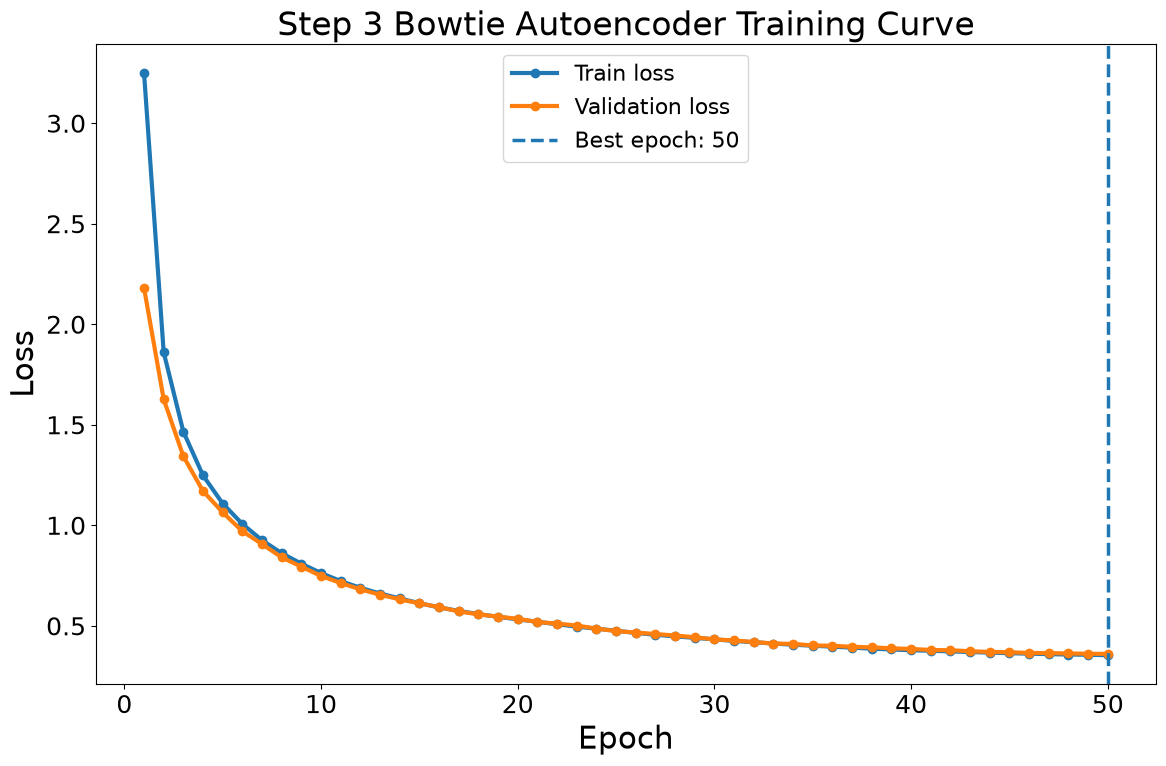

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_train_val_loss_largefont.png


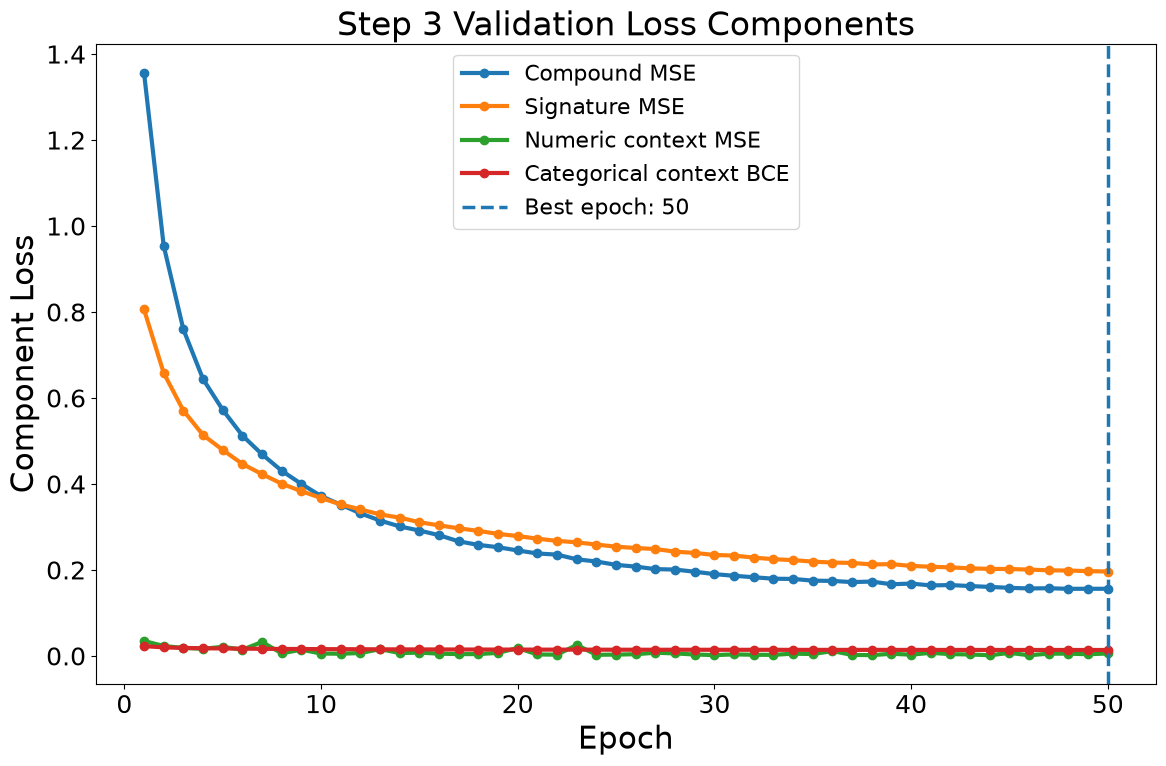

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_validation_component_losses_largefont.png


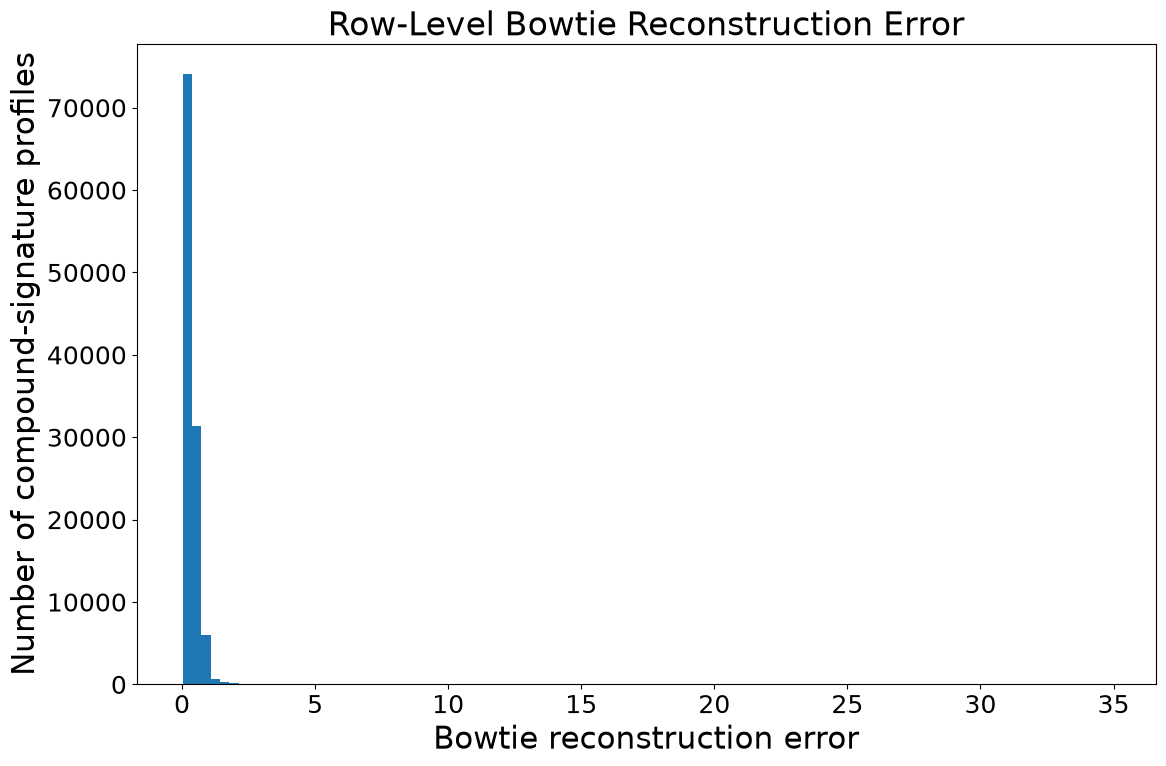

Saved: figures/step3_bowtie_autoencoder/step3_row_total_error_histogram_largefont.png


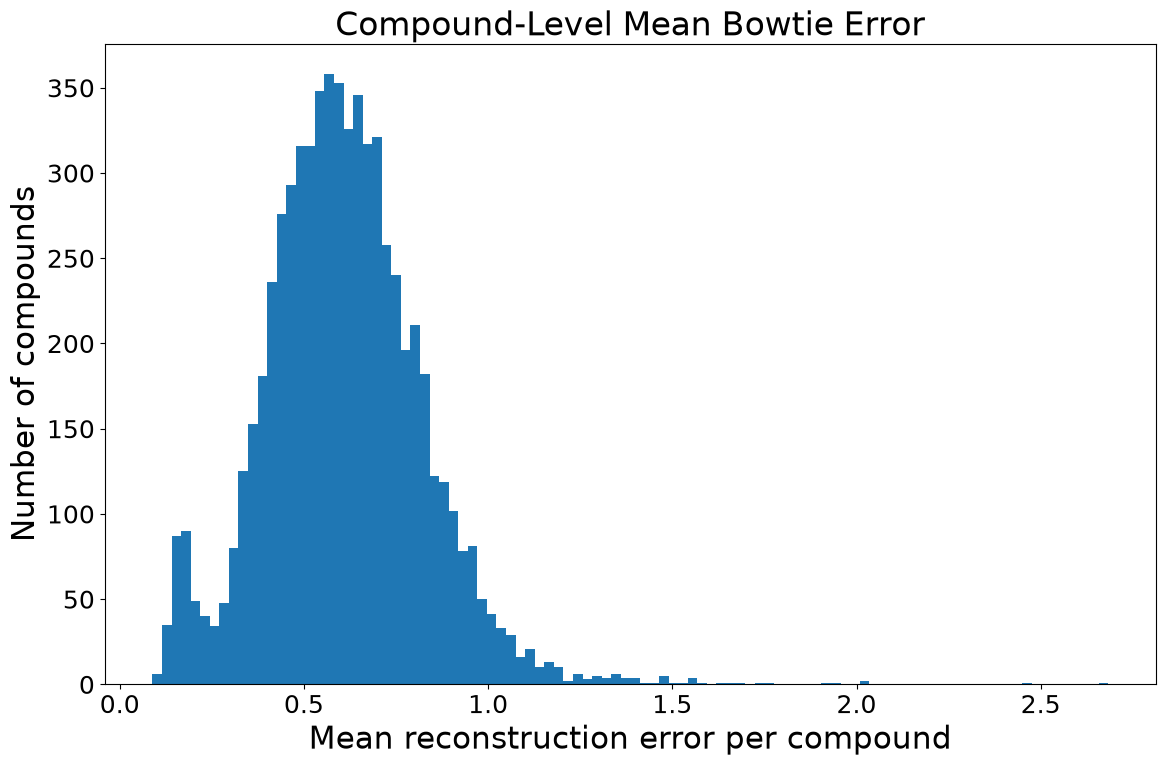

Saved: figures/step3_bowtie_autoencoder/step3_compound_mean_error_histogram_largefont.png


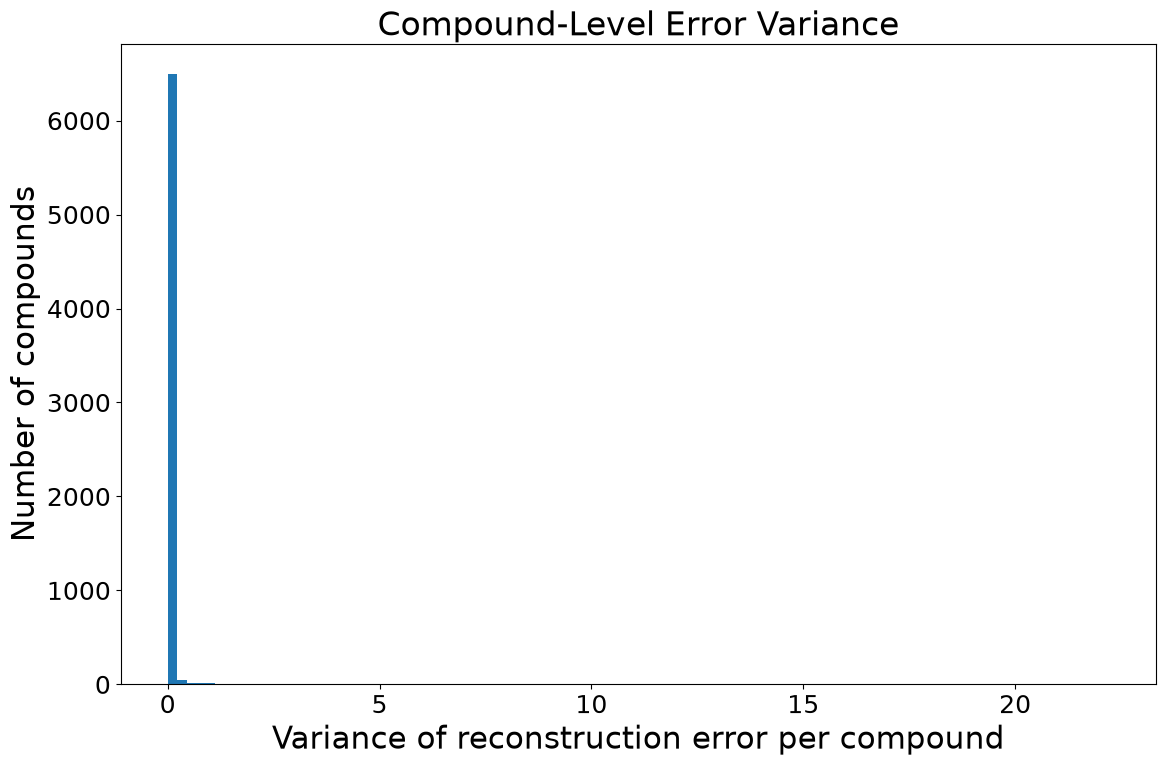

Saved: figures/step3_bowtie_autoencoder/step3_compound_error_variance_histogram_largefont.png


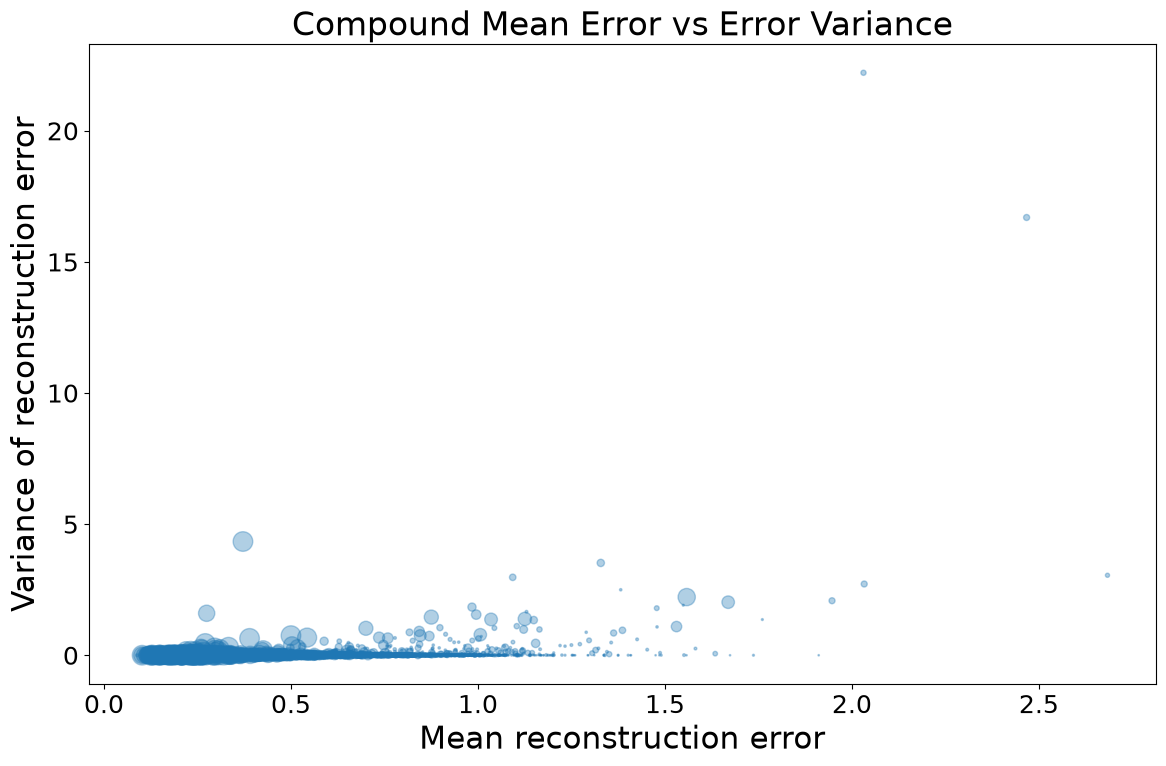

Saved: figures/step3_bowtie_autoencoder/step3_compound_mean_vs_variance_error_largefont.png


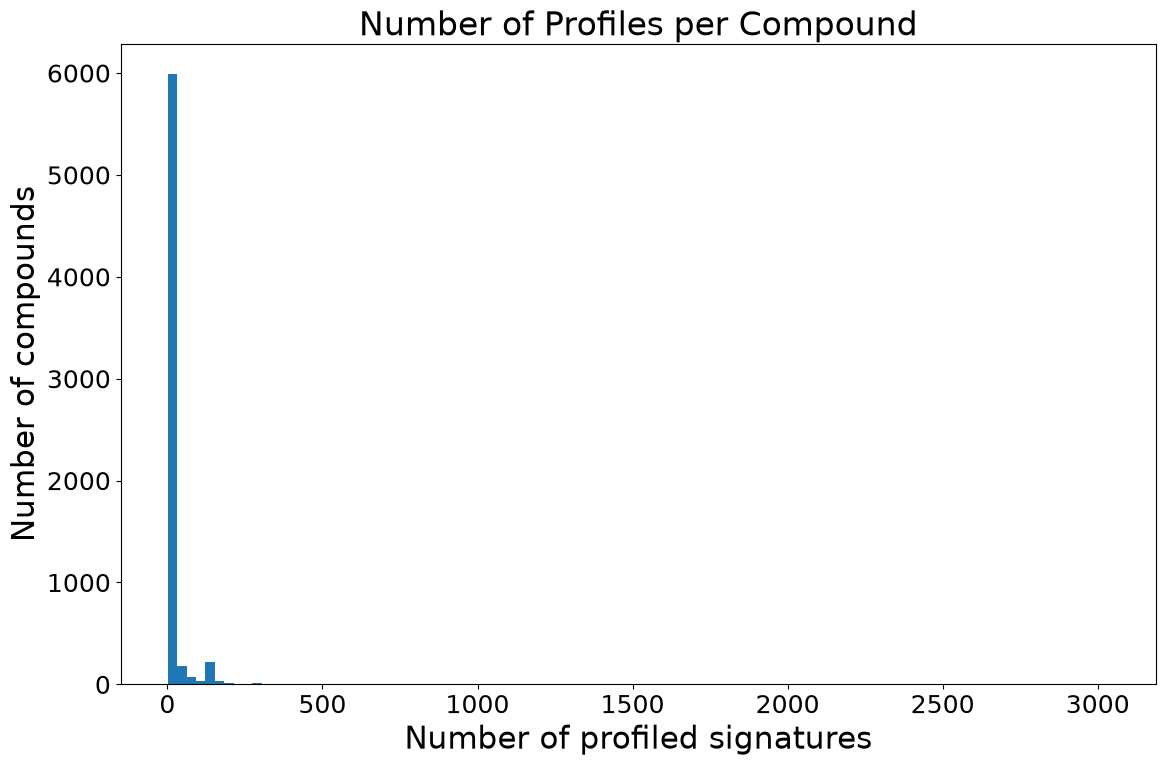

Saved: figures/step3_bowtie_autoencoder/step3_compound_n_profiles_histogram_largefont.png


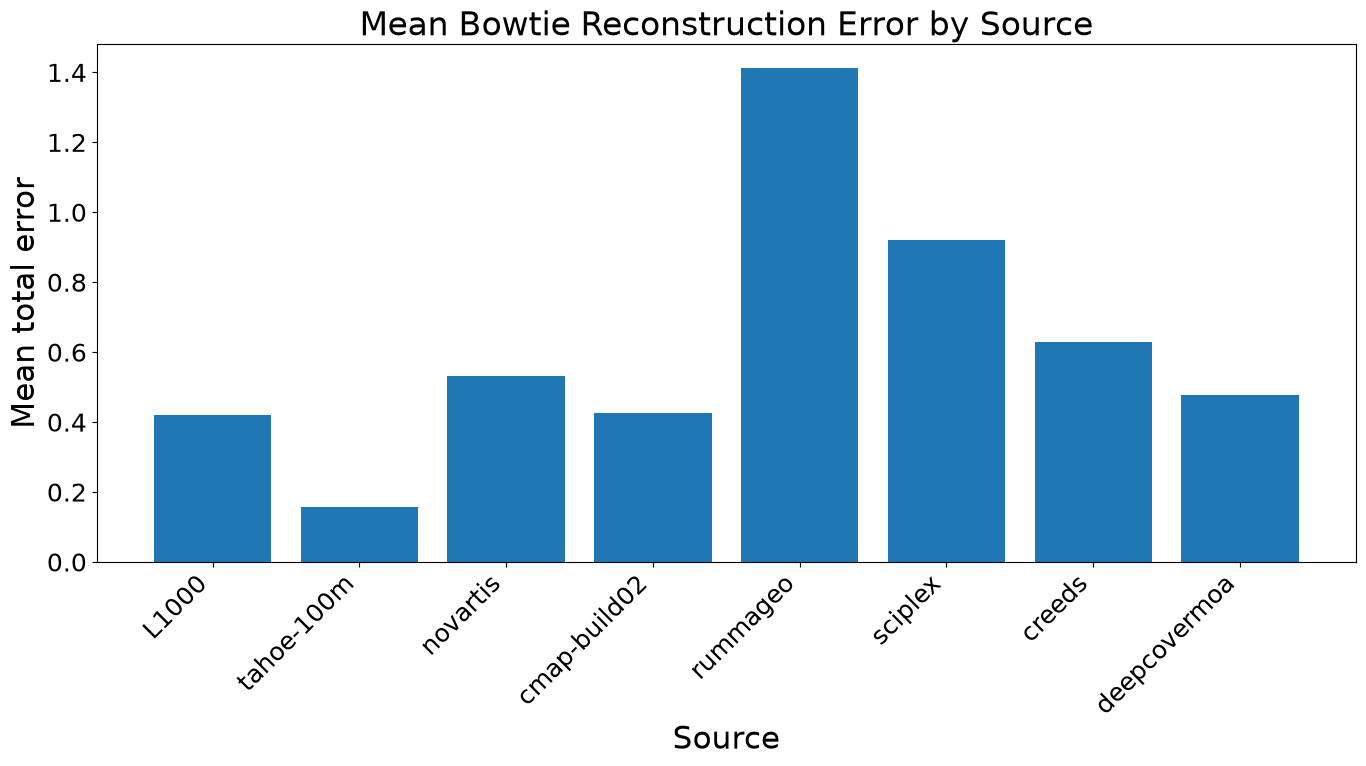

Saved: figures/step3_bowtie_autoencoder/step3_mean_total_error_by_source_largefont.png


,source,n,mean_total_error,mean_signature_error,mean_compound_error
0,L1000,60964,0.419444,0.234367,0.175869
7,tahoe-100m,39606,0.158415,0.087185,0.065695
4,novartis,4554,0.530835,0.118988,0.406707
1,cmap-build02,3945,0.425068,0.129309,0.289688
5,rummageo,1832,1.411559,1.169650,0.233510
6,sciplex,1274,0.920829,0.636939,0.275088
2,creeds,460,0.630120,0.357242,0.260982
3,deepcovermoa,339,0.477037,0.117970,0.345471


Saved top predictable: data/step3_multimodal/step3_top_predictable_compounds_n5_first_pass.csv
Saved least predictable: data/step3_multimodal/step3_least_predictable_compounds_n5_first_pass.csv

Most predictable compounds with n_profiles >= 5:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,mean_compound_error,mean_context_error,mean_signature_reconstruction_loss,mean_compound_reconstruction_bce,mean_signature_sign_accuracy,mean_compound_bitwise_accuracy,error_percentile,predictability_score
1,5198,Mitoxantrone (dihydrochloride); Mitoxantrone H...,144,0.101774,0.000621,0.024921,0.099155,0.075399,0.000587,0.022497,0.007017,0.148834,0.006507,0.983041,0.998095,0.000303,0.999697
2,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.101963,0.000745,0.027303,0.099126,0.073337,0.000638,0.022533,0.011370,0.183230,0.005732,0.973885,0.998681,0.000454,0.999546
3,1571,3-(4-Methylpiperazine-1-carbonyl)-7-oxabicyclo...,130,0.107783,0.000883,0.029717,0.106208,0.081175,0.000865,0.022701,0.006808,0.159247,0.013627,0.978107,0.996483,0.000606,0.999394
5,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.113929,0.000687,0.026202,0.110893,0.071621,0.000614,0.036244,0.010648,0.166981,0.009997,0.979076,0.997215,0.000908,0.999092
6,5217,Pitavastatin (Calcium); Pitavastatin Calcium,142,0.115821,0.000468,0.021632,0.114308,0.071288,0.000412,0.036866,0.012012,0.176623,0.043460,0.974904,0.984318,0.001060,0.998940
7,155,Tirabrutinib,139,0.116393,0.000964,0.031048,0.112444,0.077820,0.000810,0.030683,0.014404,0.153359,0.035599,0.978408,0.988128,0.001211,0.998789
8,5175,Fostamatinib (disodium hexahydrate),135,0.119621,0.000668,0.025844,0.117099,0.068285,0.000539,0.040776,0.019140,0.190910,0.082408,0.976247,0.974498,0.001363,0.998637
9,767,Posaconazole,137,0.119997,0.000636,0.025218,0.121047,0.078803,0.000572,0.034591,0.011468,0.166242,0.042152,0.973705,0.985344,0.001514,0.998486
10,1770,"1-O-[(2S,3S,6R)-4-methoxy-16,18-dioxa-10-azape...",147,0.122730,0.020460,0.143038,0.100679,0.091790,0.016539,0.024110,0.011833,0.155226,0.051410,0.981866,0.982706,0.001665,0.998335
12,643,Glycyrrhizic acid; Glycyrrhizin,140,0.123602,0.000681,0.026096,0.119525,0.077367,0.000604,0.037530,0.015028,0.207034,0.011159,0.967602,0.996629,0.001968,0.998032



Least predictable compounds with n_profiles >= 5:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,mean_compound_error,mean_context_error,mean_signature_reconstruction_loss,mean_compound_reconstruction_bce,mean_signature_sign_accuracy,mean_compound_bitwise_accuracy,error_percentile,predictability_score
6604,4091,inosine,9,2.683278,3.050035,1.746435,3.456688,2.389513,2.840146,0.282233,0.021332,0.186405,0.008019,0.981059,0.997802,1.000000,0.000000
6603,2512,"(5S,8R,9S,10S,13S,14S,17S)-17-hydroxy-10,13,17...",19,2.467006,16.694893,4.085938,0.428504,2.164504,14.912896,0.285743,0.029192,0.183561,0.027486,0.980037,0.991939,0.999849,0.000151
6602,3944,"(1S,2R,9R,17S)-7,13-diazatetracyclo[7.7.1.02,7...",19,2.032778,2.717573,1.648506,1.405146,1.486275,2.467517,0.539221,0.007242,0.274903,0.008909,0.948501,0.997508,0.999697,0.000303
6601,23986,Angiotensin ii,14,2.030854,22.213335,4.713102,0.488509,1.697932,21.540956,0.323516,0.010118,0.285020,0.006031,0.943064,0.998388,0.999546,0.000454
6600,5496,Trehalose; trehalose,19,1.946731,2.079442,1.442027,2.030198,1.626521,1.878523,0.310322,0.013008,0.231902,0.001624,0.966098,0.999853,0.999394,0.000606
6595,3113,Talazoparib; talazoparib,82,1.669063,2.023791,1.422600,1.334686,1.355504,1.700689,0.305804,0.010270,0.208201,0.060566,0.973276,0.979188,0.998637,0.001363
6594,21230,ivosidenib,11,1.634359,0.060971,0.246922,1.551097,0.927515,0.052328,0.695941,0.013545,0.405405,0.028864,0.896011,0.990473,0.998486,0.001514
6592,5116,cisplatin,155,1.558136,2.219083,1.489659,1.063197,1.357085,1.965494,0.194421,0.006216,0.263705,0.003846,0.950562,0.998827,0.998183,0.001817
6588,24002,Palmitic acid,57,1.530910,1.094122,1.046003,1.344727,1.345680,0.991481,0.179728,0.002228,0.154418,0.000840,0.982911,0.999707,0.997578,0.002422
6583,3479,Pomalidomide; pomalidomide,12,1.478017,1.796331,1.340273,0.873669,1.190283,1.492105,0.283944,0.006524,0.386644,0.005334,0.890068,0.998827,0.996821,0.003179


In [7]:
# Step 3 Bowtie Autoencoder: training curves + predictability/error plots

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = MODEL_DIR / "step3_bowtie_autoencoder_first_pass_metrics.csv"
row_errors_path = STEP3_DIR / "step3_bowtie_row_errors_first_pass.csv"
compound_predictability_path = STEP3_DIR / "step3_compound_predictability_first_pass.csv"

metrics = pd.read_csv(metrics_path)
row_errors = pd.read_csv(row_errors_path, low_memory=False)
compound_pred = pd.read_csv(compound_predictability_path, low_memory=False)

print("Metrics:", metrics.shape)
print("Row errors:", row_errors.shape)
print("Compound predictability:", compound_pred.shape)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# 1. Train vs validation total loss
best_epoch = int(metrics.loc[metrics["val_loss"].idxmin(), "epoch"])

plt.figure(figsize=(12, 8))
plt.plot(metrics["epoch"], metrics["train_loss"], marker="o", linewidth=3, label="Train loss")
plt.plot(metrics["epoch"], metrics["val_loss"], marker="o", linewidth=3, label="Validation loss")
plt.axvline(best_epoch, linestyle="--", linewidth=2.5, label=f"Best epoch: {best_epoch}")
plt.title("Step 3 Bowtie Autoencoder Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_show(FIG_DIR / "step3_bowtie_train_val_loss_largefont.png")

# 2. Validation component losses
plt.figure(figsize=(12, 8))
plt.plot(metrics["epoch"], metrics["val_compound_mse"], marker="o", linewidth=3, label="Compound MSE")
plt.plot(metrics["epoch"], metrics["val_signature_mse"], marker="o", linewidth=3, label="Signature MSE")
plt.plot(metrics["epoch"], metrics["val_numeric_mse"], marker="o", linewidth=3, label="Numeric context MSE")
plt.plot(metrics["epoch"], metrics["val_categorical_bce"], marker="o", linewidth=3, label="Categorical context BCE")
plt.axvline(best_epoch, linestyle="--", linewidth=2.5, label=f"Best epoch: {best_epoch}")
plt.title("Step 3 Validation Loss Components")
plt.xlabel("Epoch")
plt.ylabel("Component Loss")
plt.legend()
save_show(FIG_DIR / "step3_bowtie_validation_component_losses_largefont.png")

# 3. Row-level total error histogram
plt.figure(figsize=(12, 8))
plt.hist(row_errors["bowtie_total_error"].dropna(), bins=100)
plt.title("Row-Level Bowtie Reconstruction Error")
plt.xlabel("Bowtie reconstruction error")
plt.ylabel("Number of compound-signature profiles")
save_show(FIG_DIR / "step3_row_total_error_histogram_largefont.png")

# 4. Compound-level mean error histogram
plt.figure(figsize=(12, 8))
plt.hist(compound_pred["mean_total_error"].dropna(), bins=100)
plt.title("Compound-Level Mean Bowtie Error")
plt.xlabel("Mean reconstruction error per compound")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_compound_mean_error_histogram_largefont.png")

# 5. Compound-level variance histogram
plt.figure(figsize=(12, 8))
plt.hist(compound_pred["variance_total_error"].dropna(), bins=100)
plt.title("Compound-Level Error Variance")
plt.xlabel("Variance of reconstruction error per compound")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_compound_error_variance_histogram_largefont.png")

# 6. Mean error vs variance error
plt.figure(figsize=(12, 8))
plt.scatter(
    compound_pred["mean_total_error"],
    compound_pred["variance_total_error"],
    s=np.clip(compound_pred["n_profiles"], 1, 200),
    alpha=0.35,
)
plt.title("Compound Mean Error vs Error Variance")
plt.xlabel("Mean reconstruction error")
plt.ylabel("Variance of reconstruction error")
save_show(FIG_DIR / "step3_compound_mean_vs_variance_error_largefont.png")

# 7. Number of profiles per compound
plt.figure(figsize=(12, 8))
plt.hist(compound_pred["n_profiles"], bins=100)
plt.title("Number of Profiles per Compound")
plt.xlabel("Number of profiled signatures")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_compound_n_profiles_histogram_largefont.png")

# 8. Error by source
source_summary = (
    row_errors
    .groupby("source")
    .agg(
        n=("signature_row_index", "count"),
        mean_total_error=("bowtie_total_error", "mean"),
        mean_signature_error=("bowtie_signature_mse", "mean"),
        mean_compound_error=("bowtie_compound_mse", "mean"),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

source_summary_path = STEP3_DIR / "step3_bowtie_error_summary_by_source.csv"
source_summary.to_csv(source_summary_path, index=False)

plt.figure(figsize=(14, 8))
plt.bar(source_summary["source"], source_summary["mean_total_error"])
plt.title("Mean Bowtie Reconstruction Error by Source")
plt.xlabel("Source")
plt.ylabel("Mean total error")
plt.xticks(rotation=45, ha="right")
save_show(FIG_DIR / "step3_mean_total_error_by_source_largefont.png")

display(source_summary)

# 9. Reliable compound table: require multiple profiles
reliable = compound_pred[compound_pred["n_profiles"] >= 5].copy()

top_predictable = reliable.sort_values("mean_total_error", ascending=True).head(25)
least_predictable = reliable.sort_values("mean_total_error", ascending=False).head(25)

top_path = STEP3_DIR / "step3_top_predictable_compounds_n5_first_pass.csv"
bottom_path = STEP3_DIR / "step3_least_predictable_compounds_n5_first_pass.csv"

top_predictable.to_csv(top_path, index=False)
least_predictable.to_csv(bottom_path, index=False)

print("Saved top predictable:", top_path)
print("Saved least predictable:", bottom_path)

print("\nMost predictable compounds with n_profiles >= 5:")
display(top_predictable)

print("\nLeast predictable compounds with n_profiles >= 5:")
display(least_predictable)

In [8]:
# Step 3 Autoencoder: bottleneck sweep
# Tests latent dimensions 32, 64, 128, 256 for 50 epochs each.

from pathlib import Path
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP3_DIR = DATA_DIR / "step3_multimodal"

MODEL_DIR.mkdir(exist_ok=True)

arrays_path = STEP3_DIR / "step3_bowtie_arrays_first_pass.npz"

sweep_metrics_path = MODEL_DIR / "step3_bowtie_bottleneck_sweep_metrics.csv"
sweep_summary_path = MODEL_DIR / "step3_bowtie_bottleneck_sweep_summary.csv"
sweep_txt_path = MODEL_DIR / "step3_bowtie_bottleneck_sweep_summary.txt"


# Load arrays

arrays = np.load(arrays_path)

X = arrays["X_bowtie"].astype(np.float32)

train_idx = arrays["train_idx"]
val_idx = arrays["val_idx"]
test_idx = arrays["test_idx"]

compound_start = int(arrays["compound_start"])
compound_end = int(arrays["compound_end"])
signature_start = int(arrays["signature_start"])
signature_end = int(arrays["signature_end"])
numeric_start = int(arrays["numeric_context_start"])
numeric_end = int(arrays["numeric_context_end"])
cat_start = int(arrays["categorical_context_start"])
cat_end = int(arrays["categorical_context_end"])

INPUT_DIM = X.shape[1]
BATCH_SIZE = 256
LR = 3e-4
EPOCHS = 50
SEED = 42

latent_dims = [32, 64, 128, 256]

print("X:", X.shape)
print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))
print("Latent dims:", latent_dims)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

rng = np.random.default_rng(SEED)


# Model

class BowtieAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


def make_batch(indices):
    batch = X[indices]
    return torch.from_numpy(batch).to(device)


def bowtie_loss(recon, x):
    compound_loss = F.mse_loss(
        recon[:, compound_start:compound_end],
        x[:, compound_start:compound_end]
    )

    signature_loss = F.mse_loss(
        recon[:, signature_start:signature_end],
        x[:, signature_start:signature_end]
    )

    numeric_loss = F.mse_loss(
        recon[:, numeric_start:numeric_end],
        x[:, numeric_start:numeric_end]
    )

    cat_loss = F.binary_cross_entropy_with_logits(
        recon[:, cat_start:cat_end],
        x[:, cat_start:cat_end]
    )

    total_loss = (
        compound_loss
        + signature_loss
        + 0.2 * numeric_loss
        + 0.5 * cat_loss
    )

    return total_loss, {
        "compound_mse": compound_loss.item(),
        "signature_mse": signature_loss.item(),
        "numeric_mse": numeric_loss.item(),
        "categorical_bce": cat_loss.item(),
    }


def evaluate_model(model, eval_idx):
    model.eval()

    total_loss = 0.0
    total_rows = 0

    component_sums = {
        "compound_mse": 0.0,
        "signature_mse": 0.0,
        "numeric_mse": 0.0,
        "categorical_bce": 0.0,
    }

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_batch(batch_idx)

            recon, _ = model(x)
            loss, parts = bowtie_loss(recon, x)

            n = len(batch_idx)
            total_loss += loss.item() * n
            total_rows += n

            for k in component_sums:
                component_sums[k] += parts[k] * n

    out = {"loss": total_loss / total_rows}
    for k, v in component_sums.items():
        out[k] = v / total_rows

    return out


def train_one_latent_dim(latent_dim):
    print("\n" + "="*90)
    print(f"Training Step 3 bowtie autoencoder | latent_dim={latent_dim}")
    print("="*90)

    model = BowtieAutoencoder(INPUT_DIM, latent_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)

    best_val_loss = float("inf")
    best_epoch = None

    rows = []

    best_path = MODEL_DIR / f"step3_bowtie_autoencoder_latent{latent_dim}_best.pt"
    latest_path = MODEL_DIR / f"step3_bowtie_autoencoder_latent{latent_dim}_latest.pt"

    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        model.train()

        train_epoch_idx = train_idx.copy()
        rng.shuffle(train_epoch_idx)

        train_loss_sum = 0.0
        train_rows = 0

        train_component_sums = {
            "compound_mse": 0.0,
            "signature_mse": 0.0,
            "numeric_mse": 0.0,
            "categorical_bce": 0.0,
        }

        for start in range(0, len(train_epoch_idx), BATCH_SIZE):
            batch_idx = train_epoch_idx[start:start+BATCH_SIZE]
            x = make_batch(batch_idx)

            optimizer.zero_grad(set_to_none=True)

            recon, _ = model(x)
            loss, parts = bowtie_loss(recon, x)

            loss.backward()
            optimizer.step()

            n = len(batch_idx)
            train_loss_sum += loss.item() * n
            train_rows += n

            for k in train_component_sums:
                train_component_sums[k] += parts[k] * n

        train_loss = train_loss_sum / train_rows
        train_parts = {k: v / train_rows for k, v in train_component_sums.items()}

        val_metrics = evaluate_model(model, val_idx)
        elapsed_min = (time.time() - epoch_start) / 60

        improved = val_metrics["loss"] < best_val_loss

        if improved:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch

        row = {
            "latent_dim": latent_dim,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "train_compound_mse": train_parts["compound_mse"],
            "train_signature_mse": train_parts["signature_mse"],
            "train_numeric_mse": train_parts["numeric_mse"],
            "train_categorical_bce": train_parts["categorical_bce"],
            "val_compound_mse": val_metrics["compound_mse"],
            "val_signature_mse": val_metrics["signature_mse"],
            "val_numeric_mse": val_metrics["numeric_mse"],
            "val_categorical_bce": val_metrics["categorical_bce"],
            "elapsed_min": elapsed_min,
            "best_val_loss_so_far": best_val_loss,
            "best_epoch_so_far": best_epoch,
            "batch_size": BATCH_SIZE,
            "lr": LR,
        }

        rows.append(row)

        print(
            f"latent {latent_dim} | epoch {epoch:02d}/{EPOCHS} | "
            f"train {train_loss:.6f} | val {val_metrics['loss']:.6f} | "
            f"val compound {val_metrics['compound_mse']:.6f} | "
            f"val signature {val_metrics['signature_mse']:.6f} | "
            f"val cat {val_metrics['categorical_bce']:.6f} | "
            f"best {best_val_loss:.6f} @ epoch {best_epoch} | "
            f"time {elapsed_min:.2f} min"
        )

        # Save latest
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "input_dim": INPUT_DIM,
            "latent_dim": latent_dim,
            "component_slices": {
                "compound": [compound_start, compound_end],
                "signature": [signature_start, signature_end],
                "numeric_context": [numeric_start, numeric_end],
                "categorical_context": [cat_start, cat_end],
            },
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "loss": "compound_mse + signature_mse + 0.2*numeric_mse + 0.5*categorical_bce",
        }, latest_path)

        # Save best
        if improved:
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "input_dim": INPUT_DIM,
                "latent_dim": latent_dim,
                "component_slices": {
                    "compound": [compound_start, compound_end],
                    "signature": [signature_start, signature_end],
                    "numeric_context": [numeric_start, numeric_end],
                    "categorical_context": [cat_start, cat_end],
                },
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
                "loss": "compound_mse + signature_mse + 0.2*numeric_mse + 0.5*categorical_bce",
            }, best_path)

    del model
    del optimizer
    gc.collect()

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

    return rows



# Run sweep

all_rows = []

for latent_dim in latent_dims:
    rows = train_one_latent_dim(latent_dim)
    all_rows.extend(rows)

    # Save continuously after each latent dim
    sweep_df = pd.DataFrame(all_rows)
    sweep_df.to_csv(sweep_metrics_path, index=False)
    print("Saved partial sweep metrics:", sweep_metrics_path)


# Summarize sweep

sweep_df = pd.DataFrame(all_rows)
sweep_df.to_csv(sweep_metrics_path, index=False)

sweep_summary = (
    sweep_df
    .sort_values("val_loss")
    .groupby("latent_dim", as_index=False)
    .first()
    .sort_values("val_loss")
)

sweep_summary.to_csv(sweep_summary_path, index=False)

with open(sweep_txt_path, "w") as f:
    f.write("Step 3 Bowtie Autoencoder Bottleneck Sweep\n")
    f.write("==========================================\n\n")
    f.write(f"Latent dimensions tested: {latent_dims}\n")
    f.write(f"Epochs per latent dim: {EPOCHS}\n")
    f.write(f"Input dim: {INPUT_DIM}\n")
    f.write(f"Train rows: {len(train_idx)}\n")
    f.write(f"Val rows: {len(val_idx)}\n")
    f.write(f"Test rows: {len(test_idx)}\n\n")
    f.write("Best validation row per latent dimension:\n")
    f.write(sweep_summary.to_string(index=False))

print("\nSaved sweep metrics:", sweep_metrics_path)
print("Saved sweep summary:", sweep_summary_path)
print("Saved text summary:", sweep_txt_path)

display(sweep_summary)

X: (112974, 682)
Train: 79081 Val: 16946 Test: 16947
Latent dims: [32, 64, 128, 256]
Device: mps

Training Step 3 bowtie autoencoder | latent_dim=32
latent 32 | epoch 01/50 | train 3.280074 | val 2.253935 | val compound 1.412991 | val signature 0.817774 | val cat 0.022727 | best 2.253935 @ epoch 1 | time 0.06 min
latent 32 | epoch 02/50 | train 1.984956 | val 1.798023 | val compound 1.047505 | val signature 0.735100 | val cat 0.019943 | best 1.798023 @ epoch 2 | time 0.06 min
latent 32 | epoch 03/50 | train 1.678542 | val 1.598500 | val compound 0.897558 | val signature 0.686125 | val cat 0.018772 | best 1.598500 @ epoch 3 | time 0.06 min
latent 32 | epoch 04/50 | train 1.529373 | val 1.484566 | val compound 0.809372 | val signature 0.661860 | val cat 0.018014 | best 1.484566 @ epoch 4 | time 0.06 min
latent 32 | epoch 05/50 | train 1.434792 | val 1.407764 | val compound 0.745615 | val signature 0.648954 | val cat 0.017589 | best 1.407764 @ epoch 5 | time 0.06 min
latent 32 | epoch 06/

,latent_dim,epoch,train_loss,val_loss,train_compound_mse,train_signature_mse,train_numeric_mse,train_categorical_bce,val_compound_mse,val_signature_mse,val_numeric_mse,val_categorical_bce,elapsed_min,best_val_loss_so_far,best_epoch_so_far,batch_size,lr
3,256,50,0.171863,0.171766,0.058749,0.106333,0.003002,0.012362,0.058287,0.106580,0.001146,0.013340,0.061991,0.171766,50,256,0.0003
2,128,50,0.337012,0.342202,0.146578,0.183527,0.003225,0.012524,0.148740,0.185631,0.005492,0.013466,0.061008,0.342202,50,256,0.0003
1,64,50,0.647095,0.665704,0.275003,0.364224,0.006963,0.012952,0.284101,0.373263,0.006677,0.014007,0.060534,0.665704,50,256,0.0003
0,32,50,0.839738,0.875382,0.319455,0.510690,0.014787,0.013271,0.333381,0.531652,0.015653,0.014438,0.059923,0.875382,50,256,0.0003


,latent_dim,epoch,train_loss,val_loss,train_compound_mse,train_signature_mse,train_numeric_mse,train_categorical_bce,val_compound_mse,val_signature_mse,val_numeric_mse,val_categorical_bce,elapsed_min,best_val_loss_so_far,best_epoch_so_far,batch_size,lr
0,256,50,0.171863,0.171766,0.058749,0.106333,0.003002,0.012362,0.058287,0.106580,0.001146,0.013340,0.061991,0.171766,50,256,0.0003
1,128,50,0.337012,0.342202,0.146578,0.183527,0.003225,0.012524,0.148740,0.185631,0.005492,0.013466,0.061008,0.342202,50,256,0.0003
2,64,50,0.647095,0.665704,0.275003,0.364224,0.006963,0.012952,0.284101,0.373263,0.006677,0.014007,0.060534,0.665704,50,256,0.0003
3,32,50,0.839738,0.875382,0.319455,0.510690,0.014787,0.013271,0.333381,0.531652,0.015653,0.014438,0.059923,0.875382,50,256,0.0003


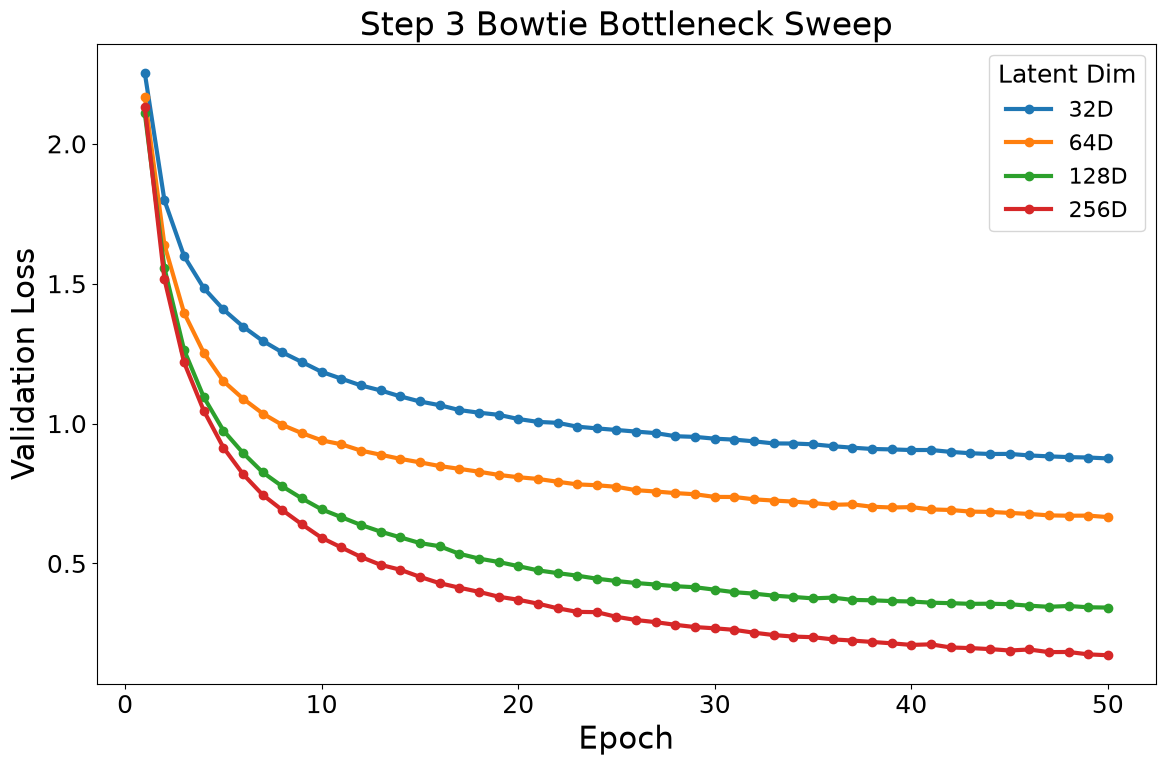

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_bottleneck_sweep_val_loss_largefont.png


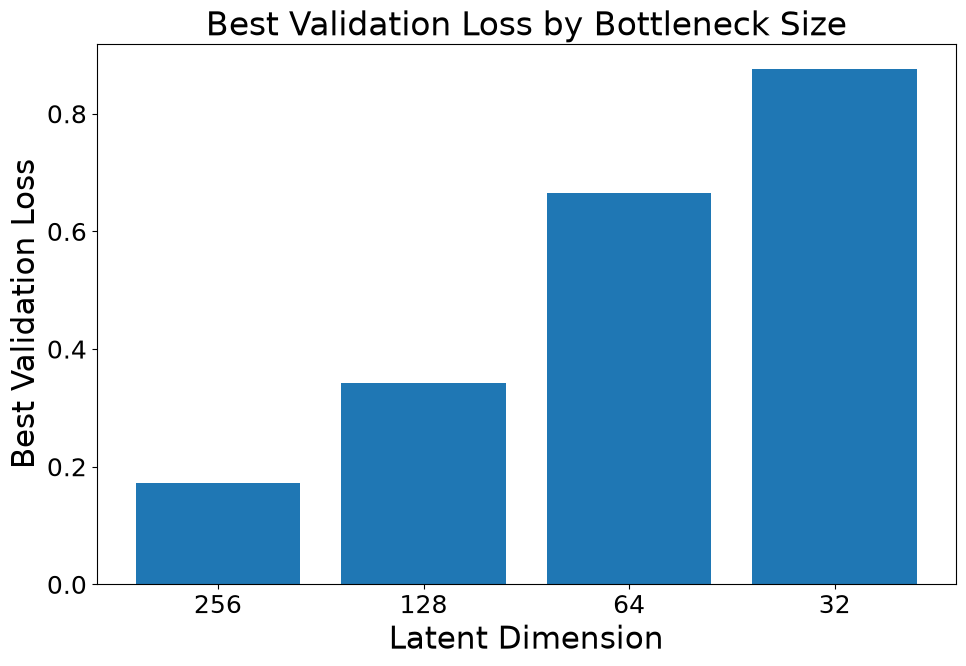

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_bottleneck_best_val_loss_largefont.png


,latent_dim,val_compound_mse,val_signature_mse,val_numeric_mse,val_categorical_bce
0,256,0.058287,0.106580,0.001146,0.013340
1,128,0.148740,0.185631,0.005492,0.013466
2,64,0.284101,0.373263,0.006677,0.014007
3,32,0.333381,0.531652,0.015653,0.014438


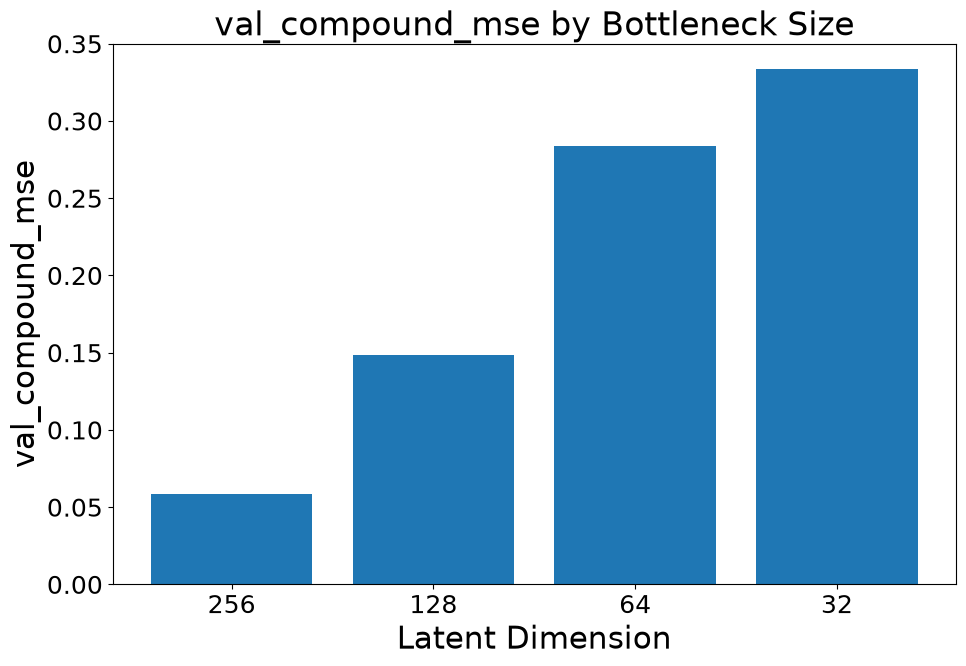

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_bottleneck_val_compound_mse_largefont.png


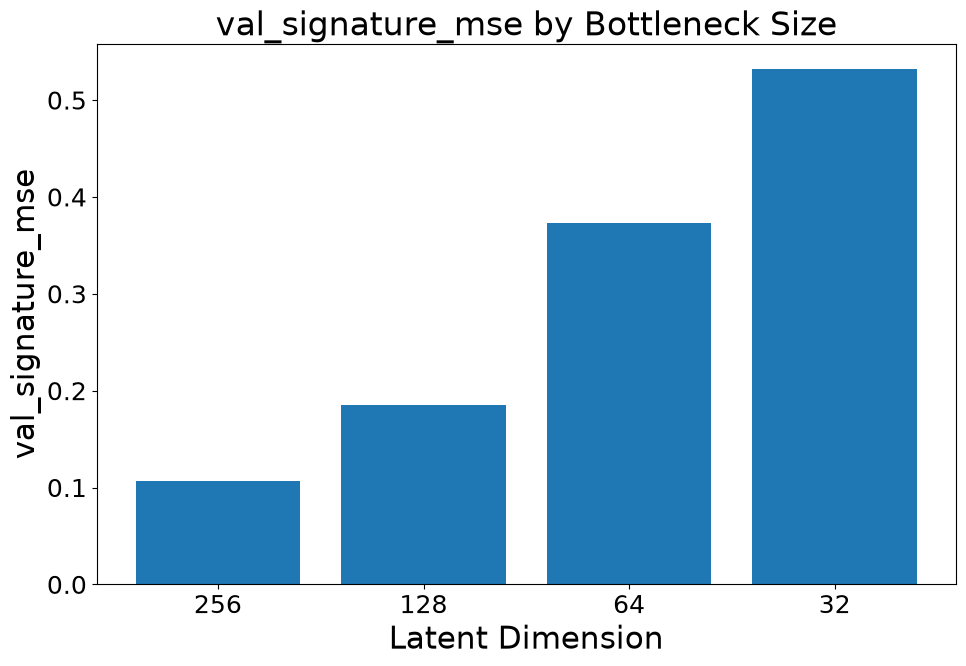

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_bottleneck_val_signature_mse_largefont.png


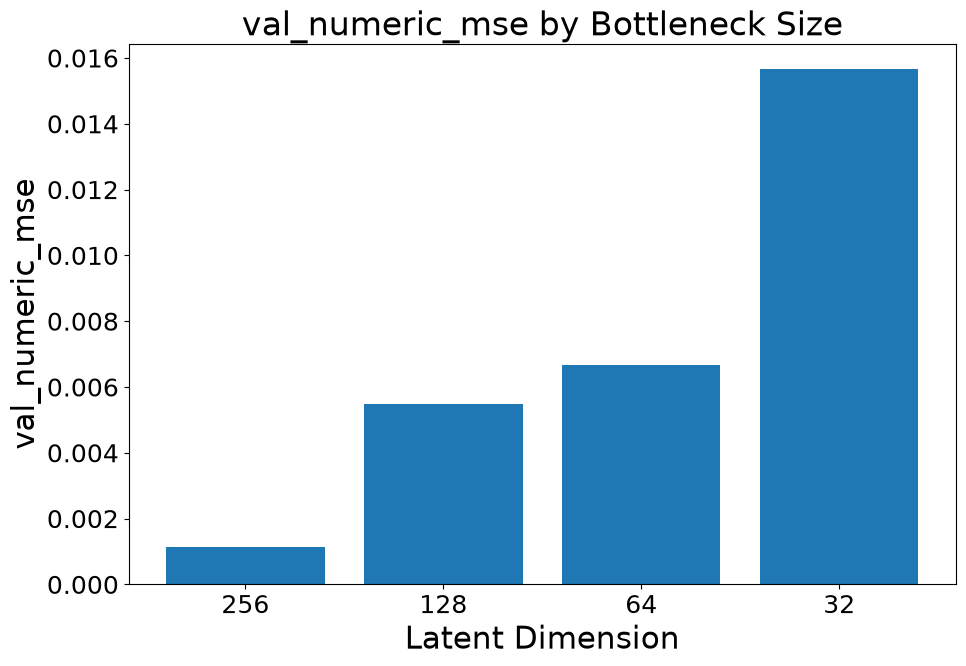

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_bottleneck_val_numeric_mse_largefont.png


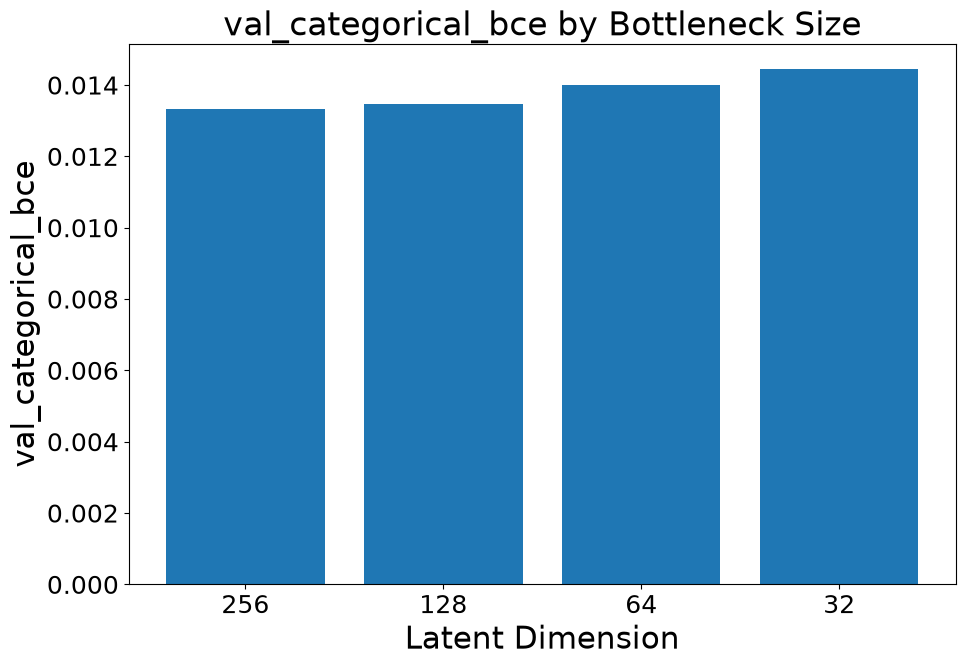

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_bottleneck_val_categorical_bce_largefont.png
Best bottleneck:


,latent_dim,epoch,train_loss,val_loss,train_compound_mse,train_signature_mse,train_numeric_mse,train_categorical_bce,val_compound_mse,val_signature_mse,val_numeric_mse,val_categorical_bce,elapsed_min,best_val_loss_so_far,best_epoch_so_far,batch_size,lr
0,256,50,0.171863,0.171766,0.058749,0.106333,0.003002,0.012362,0.058287,0.10658,0.001146,0.01334,0.061991,0.171766,50,256,0.0003


In [9]:
# Step 3 Autoencoder: bottleneck sweep plots

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

sweep_metrics_path = MODEL_DIR / "step3_bowtie_bottleneck_sweep_metrics.csv"
sweep_summary_path = MODEL_DIR / "step3_bowtie_bottleneck_sweep_summary.csv"

sweep = pd.read_csv(sweep_metrics_path)
summary = pd.read_csv(sweep_summary_path)

display(summary)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# 1. Validation loss by epoch for each bottleneck
plt.figure(figsize=(12, 8))

for latent_dim in sorted(sweep["latent_dim"].unique()):
    df = sweep[sweep["latent_dim"] == latent_dim].sort_values("epoch")
    plt.plot(df["epoch"], df["val_loss"], marker="o", linewidth=3, label=f"{latent_dim}D")

plt.title("Step 3 Bowtie Bottleneck Sweep")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(title="Latent Dim")
save_show(FIG_DIR / "step3_bowtie_bottleneck_sweep_val_loss_largefont.png")

# 2. Best validation loss by bottleneck
plt.figure(figsize=(10, 7))
plt.bar(summary["latent_dim"].astype(str), summary["val_loss"])
plt.title("Best Validation Loss by Bottleneck Size")
plt.xlabel("Latent Dimension")
plt.ylabel("Best Validation Loss")
save_show(FIG_DIR / "step3_bowtie_bottleneck_best_val_loss_largefont.png")

# 3. Component losses for best row per latent dimension
component_cols = [
    "val_compound_mse",
    "val_signature_mse",
    "val_numeric_mse",
    "val_categorical_bce",
]

component_summary = summary[["latent_dim"] + component_cols].copy()

display(component_summary)

for col in component_cols:
    plt.figure(figsize=(10, 7))
    plt.bar(component_summary["latent_dim"].astype(str), component_summary[col])
    plt.title(f"{col} by Bottleneck Size")
    plt.xlabel("Latent Dimension")
    plt.ylabel(col)
    save_show(FIG_DIR / f"step3_bowtie_bottleneck_{col}_largefont.png")

print("Best bottleneck:")
display(summary.sort_values("val_loss").head(1))

In [10]:
# Step 3 Bowtie Autoencoder: continue best 256D model to 100 epochs

from pathlib import Path
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP3_DIR = DATA_DIR / "step3_multimodal"

arrays_path = STEP3_DIR / "step3_bowtie_arrays_first_pass.npz"

latent_dim = 256
TOTAL_EPOCHS = 100
BATCH_SIZE = 256
LR = 3e-4
SEED = 42

metrics_path = MODEL_DIR / f"step3_bowtie_autoencoder_latent{latent_dim}_continued_metrics.csv"
best_path = MODEL_DIR / f"step3_bowtie_autoencoder_latent{latent_dim}_best.pt"
latest_path = MODEL_DIR / f"step3_bowtie_autoencoder_latent{latent_dim}_latest.pt"
summary_path = MODEL_DIR / f"step3_bowtie_autoencoder_latent{latent_dim}_continued_summary.txt"

arrays = np.load(arrays_path)

X = arrays["X_bowtie"].astype(np.float32)

train_idx = arrays["train_idx"]
val_idx = arrays["val_idx"]
test_idx = arrays["test_idx"]

compound_start = int(arrays["compound_start"])
compound_end = int(arrays["compound_end"])
signature_start = int(arrays["signature_start"])
signature_end = int(arrays["signature_end"])
numeric_start = int(arrays["numeric_context_start"])
numeric_end = int(arrays["numeric_context_end"])
cat_start = int(arrays["categorical_context_start"])
cat_end = int(arrays["categorical_context_end"])

INPUT_DIM = X.shape[1]

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("X:", X.shape)
print("Device:", device)
print("Continuing latent_dim:", latent_dim)

rng = np.random.default_rng(SEED)

class BowtieAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


def make_batch(indices):
    return torch.from_numpy(X[indices]).to(device)


def bowtie_loss(recon, x):
    compound_loss = F.mse_loss(
        recon[:, compound_start:compound_end],
        x[:, compound_start:compound_end]
    )

    signature_loss = F.mse_loss(
        recon[:, signature_start:signature_end],
        x[:, signature_start:signature_end]
    )

    numeric_loss = F.mse_loss(
        recon[:, numeric_start:numeric_end],
        x[:, numeric_start:numeric_end]
    )

    cat_loss = F.binary_cross_entropy_with_logits(
        recon[:, cat_start:cat_end],
        x[:, cat_start:cat_end]
    )

    total_loss = compound_loss + signature_loss + 0.2 * numeric_loss + 0.5 * cat_loss

    return total_loss, {
        "compound_mse": compound_loss.item(),
        "signature_mse": signature_loss.item(),
        "numeric_mse": numeric_loss.item(),
        "categorical_bce": cat_loss.item(),
    }


def evaluate_model(model, eval_idx):
    model.eval()

    total_loss = 0.0
    total_rows = 0

    component_sums = {
        "compound_mse": 0.0,
        "signature_mse": 0.0,
        "numeric_mse": 0.0,
        "categorical_bce": 0.0,
    }

    with torch.no_grad():
        for start in range(0, len(eval_idx), BATCH_SIZE):
            batch_idx = eval_idx[start:start+BATCH_SIZE]
            x = make_batch(batch_idx)

            recon, _ = model(x)
            loss, parts = bowtie_loss(recon, x)

            n = len(batch_idx)
            total_loss += loss.item() * n
            total_rows += n

            for k in component_sums:
                component_sums[k] += parts[k] * n

    out = {"loss": total_loss / total_rows}
    for k, v in component_sums.items():
        out[k] = v / total_rows

    return out

# Load latest 256D model from sweep
checkpoint = torch.load(latest_path, map_location="cpu")

model = BowtieAutoencoder(INPUT_DIM, latent_dim)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)

start_epoch = int(checkpoint["epoch"]) + 1
best_val_loss = checkpoint.get("best_val_loss", float("inf"))
best_epoch = checkpoint.get("best_epoch", None)

print("Loaded latest checkpoint:", latest_path)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Resuming from epoch:", start_epoch)
print("Best val loss so far:", best_val_loss)
print("Best epoch so far:", best_epoch)

# Start metrics from existing sweep rows for 256D if available
sweep_metrics_path = MODEL_DIR / "step3_bowtie_bottleneck_sweep_metrics.csv"
if sweep_metrics_path.exists():
    old_metrics = pd.read_csv(sweep_metrics_path)
    metrics = old_metrics[old_metrics["latent_dim"] == latent_dim].to_dict("records")
else:
    metrics = []

for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
    epoch_start = time.time()
    model.train()

    train_epoch_idx = train_idx.copy()
    rng.shuffle(train_epoch_idx)

    train_loss_sum = 0.0
    train_rows = 0

    train_component_sums = {
        "compound_mse": 0.0,
        "signature_mse": 0.0,
        "numeric_mse": 0.0,
        "categorical_bce": 0.0,
    }

    for start in range(0, len(train_epoch_idx), BATCH_SIZE):
        batch_idx = train_epoch_idx[start:start+BATCH_SIZE]
        x = make_batch(batch_idx)

        optimizer.zero_grad(set_to_none=True)

        recon, _ = model(x)
        loss, parts = bowtie_loss(recon, x)

        loss.backward()
        optimizer.step()

        n = len(batch_idx)
        train_loss_sum += loss.item() * n
        train_rows += n

        for k in train_component_sums:
            train_component_sums[k] += parts[k] * n

    train_loss = train_loss_sum / train_rows
    train_parts = {k: v / train_rows for k, v in train_component_sums.items()}

    val_metrics = evaluate_model(model, val_idx)

    elapsed_min = (time.time() - epoch_start) / 60

    improved = val_metrics["loss"] < best_val_loss

    if improved:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch

    row = {
        "latent_dim": latent_dim,
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "train_compound_mse": train_parts["compound_mse"],
        "train_signature_mse": train_parts["signature_mse"],
        "train_numeric_mse": train_parts["numeric_mse"],
        "train_categorical_bce": train_parts["categorical_bce"],
        "val_compound_mse": val_metrics["compound_mse"],
        "val_signature_mse": val_metrics["signature_mse"],
        "val_numeric_mse": val_metrics["numeric_mse"],
        "val_categorical_bce": val_metrics["categorical_bce"],
        "elapsed_min": elapsed_min,
        "best_val_loss_so_far": best_val_loss,
        "best_epoch_so_far": best_epoch,
        "batch_size": BATCH_SIZE,
        "lr": LR,
    }

    metrics.append(row)

    print(
        f"latent {latent_dim} | epoch {epoch:03d}/{TOTAL_EPOCHS} | "
        f"train {train_loss:.6f} | val {val_metrics['loss']:.6f} | "
        f"val compound {val_metrics['compound_mse']:.6f} | "
        f"val signature {val_metrics['signature_mse']:.6f} | "
        f"val cat {val_metrics['categorical_bce']:.6f} | "
        f"best {best_val_loss:.6f} @ epoch {best_epoch} | "
        f"time {elapsed_min:.2f} min"
    )

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "input_dim": INPUT_DIM,
        "latent_dim": latent_dim,
        "component_slices": {
            "compound": [compound_start, compound_end],
            "signature": [signature_start, signature_end],
            "numeric_context": [numeric_start, numeric_end],
            "categorical_context": [cat_start, cat_end],
        },
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "loss": "compound_mse + signature_mse + 0.2*numeric_mse + 0.5*categorical_bce",
    }, latest_path)

    if improved:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "input_dim": INPUT_DIM,
            "latent_dim": latent_dim,
            "component_slices": {
                "compound": [compound_start, compound_end],
                "signature": [signature_start, signature_end],
                "numeric_context": [numeric_start, numeric_end],
                "categorical_context": [cat_start, cat_end],
            },
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "loss": "compound_mse + signature_mse + 0.2*numeric_mse + 0.5*categorical_bce",
        }, best_path)

    pd.DataFrame(metrics).to_csv(metrics_path, index=False)

print("Continued training complete.")
print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)

# Test eval with best checkpoint
checkpoint = torch.load(best_path, map_location="cpu")

best_model = BowtieAutoencoder(INPUT_DIM, latent_dim)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

test_metrics = evaluate_model(best_model, test_idx)

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(k, ":", v)

with open(summary_path, "w") as f:
    f.write("Step 3 Bowtie Autoencoder - Latent 256 Continued Training\n")
    f.write("========================================================\n\n")
    f.write(f"Input dim: {INPUT_DIM}\n")
    f.write(f"Latent dim: {latent_dim}\n")
    f.write(f"Total epochs: {TOTAL_EPOCHS}\n")
    f.write(f"Best epoch: {checkpoint.get('epoch')}\n")
    f.write(f"Best val loss: {checkpoint.get('best_val_loss')}\n\n")
    f.write("Test metrics:\n")
    for k, v in test_metrics.items():
        f.write(f"{k}: {v}\n")

print("Saved continued metrics:", metrics_path)
print("Saved summary:", summary_path)

gc.collect()

if device.type == "mps":
    torch.mps.empty_cache()
elif device.type == "cuda":
    torch.cuda.empty_cache()

X: (112974, 682)
Device: mps
Continuing latent_dim: 256
Loaded latest checkpoint: models/step3_bowtie_autoencoder_latent256_latest.pt
Checkpoint epoch: 50
Resuming from epoch: 51
Best val loss so far: 0.17176618596661347
Best epoch so far: 50
latent 256 | epoch 051/100 | train 0.217861 | val 0.165918 | val compound 0.055302 | val signature 0.103887 | val cat 0.013258 | best 0.165918 @ epoch 51 | time 0.06 min
latent 256 | epoch 052/100 | train 0.163101 | val 0.164218 | val compound 0.054185 | val signature 0.102986 | val cat 0.013285 | best 0.164218 @ epoch 52 | time 0.06 min
latent 256 | epoch 053/100 | train 0.162929 | val 0.164503 | val compound 0.054901 | val signature 0.102459 | val cat 0.013265 | best 0.164218 @ epoch 52 | time 0.06 min
latent 256 | epoch 054/100 | train 0.160877 | val 0.162104 | val compound 0.053679 | val signature 0.101225 | val cat 0.013277 | best 0.162104 @ epoch 54 | time 0.06 min
latent 256 | epoch 055/100 | train 0.158773 | val 0.159173 | val compound 0.0

Best epoch: 100
Best val loss: 0.0910827293930489


,latent_dim,epoch,train_loss,val_loss,train_compound_mse,train_signature_mse,train_numeric_mse,train_categorical_bce,val_compound_mse,val_signature_mse,val_numeric_mse,val_categorical_bce,elapsed_min,best_val_loss_so_far,best_epoch_so_far,batch_size,lr
95,256,96,0.093695,0.095763,0.027253,0.060093,0.002920,0.011531,0.028054,0.061193,0.000798,0.012714,0.060181,0.095763,96,256,0.0003
96,256,97,0.092700,0.094666,0.026756,0.059790,0.002027,0.011499,0.027792,0.060127,0.002086,0.012661,0.061594,0.094666,97,256,0.0003
97,256,98,0.092019,0.094466,0.026580,0.059327,0.001839,0.011488,0.027731,0.060080,0.001533,0.012696,0.062145,0.094466,98,256,0.0003
98,256,99,0.091224,0.094917,0.026160,0.058885,0.002203,0.011476,0.028308,0.059899,0.001835,0.012685,0.061427,0.094466,98,256,0.0003
99,256,100,0.090305,0.091083,0.025774,0.058316,0.002399,0.011468,0.025676,0.058957,0.000510,0.012695,0.061866,0.091083,100,256,0.0003


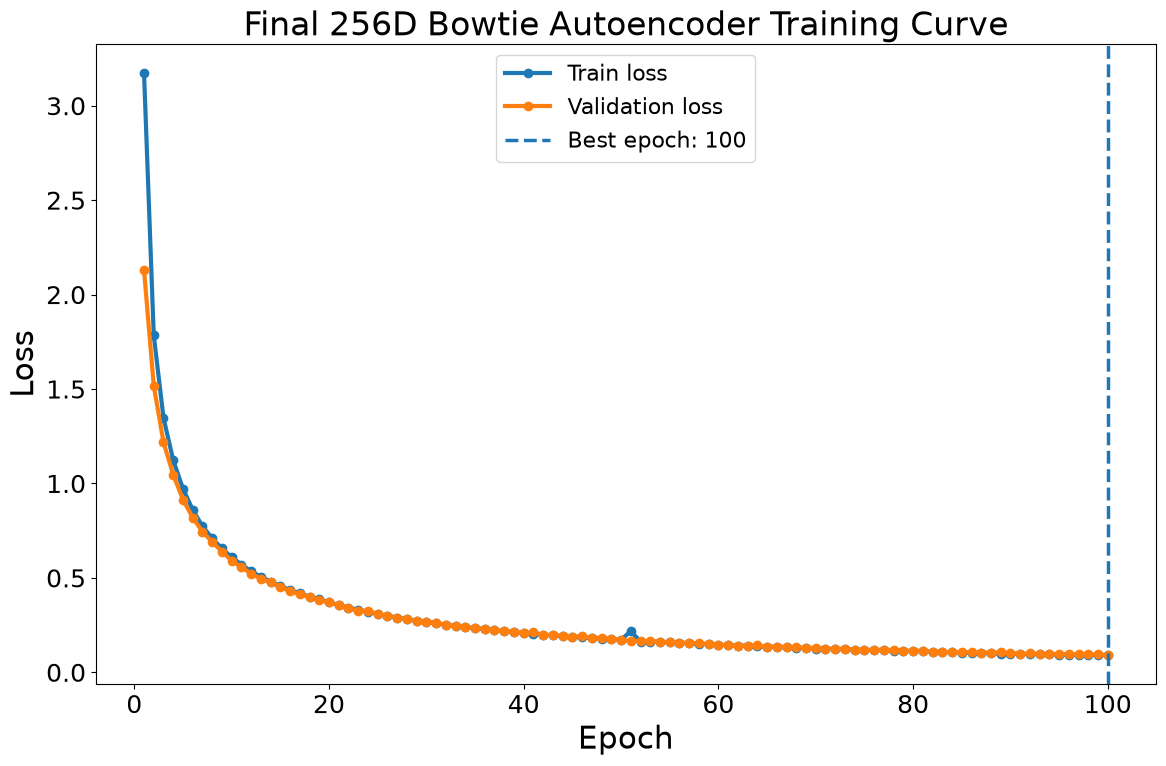

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_latent256_train_val_loss_largefont.png


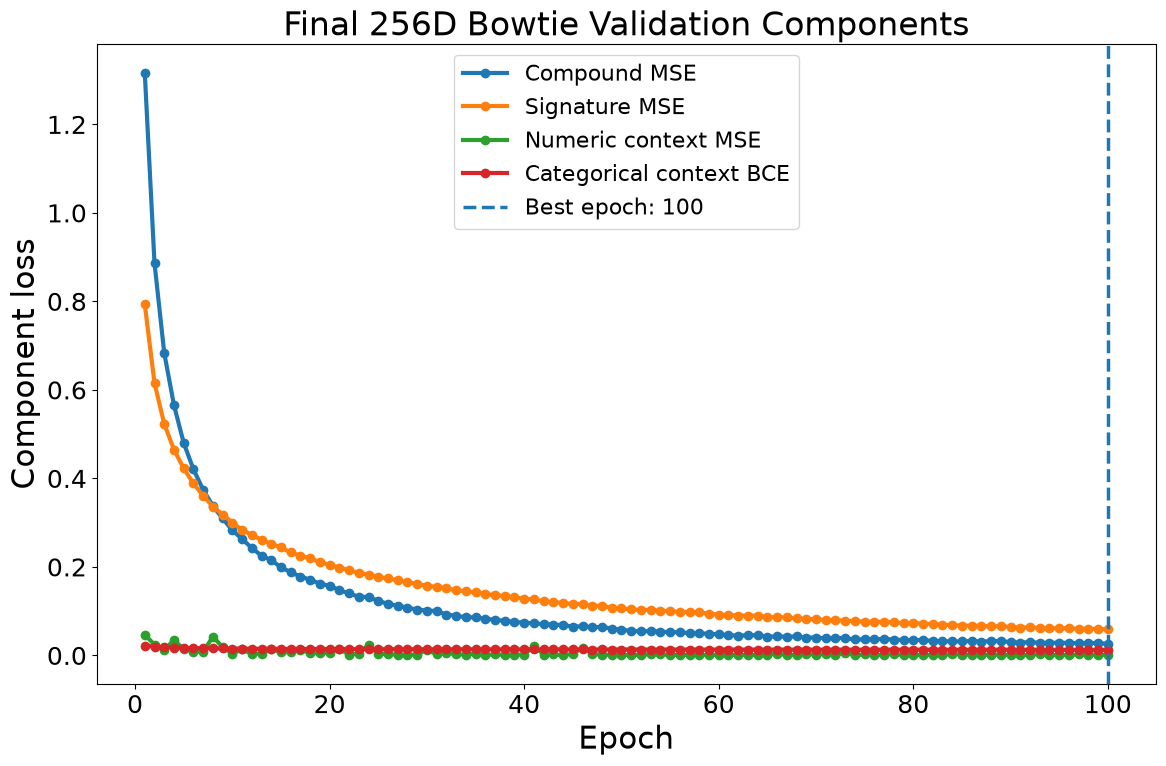

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_latent256_validation_components_largefont.png


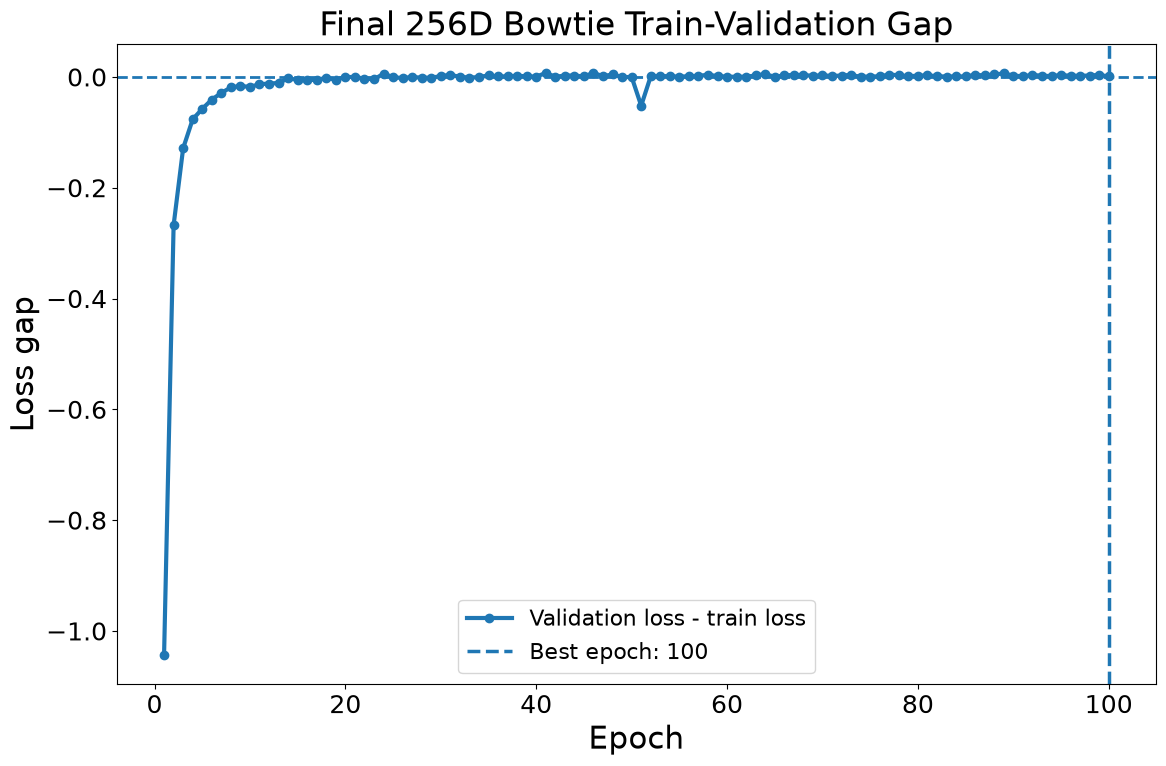

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_latent256_train_val_gap_largefont.png


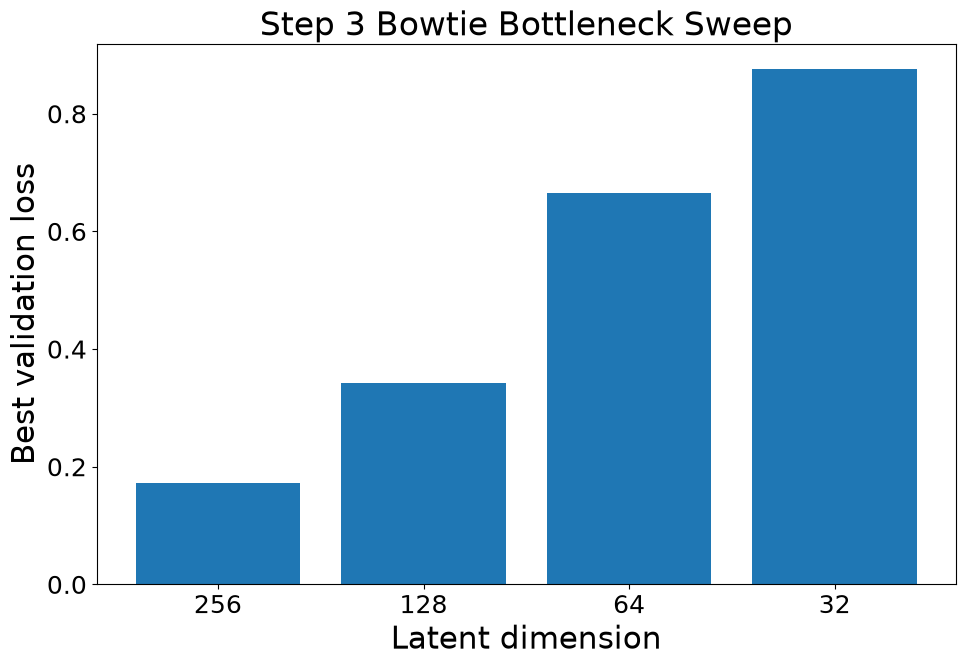

Saved: figures/step3_bowtie_autoencoder/step3_bowtie_bottleneck_best_val_loss_largefont.png


,latent_dim,epoch,train_loss,val_loss,train_compound_mse,train_signature_mse,train_numeric_mse,train_categorical_bce,val_compound_mse,val_signature_mse,val_numeric_mse,val_categorical_bce,elapsed_min,best_val_loss_so_far,best_epoch_so_far,batch_size,lr
0,256,50,0.171863,0.171766,0.058749,0.106333,0.003002,0.012362,0.058287,0.106580,0.001146,0.013340,0.061991,0.171766,50,256,0.0003
1,128,50,0.337012,0.342202,0.146578,0.183527,0.003225,0.012524,0.148740,0.185631,0.005492,0.013466,0.061008,0.342202,50,256,0.0003
2,64,50,0.647095,0.665704,0.275003,0.364224,0.006963,0.012952,0.284101,0.373263,0.006677,0.014007,0.060534,0.665704,50,256,0.0003
3,32,50,0.839738,0.875382,0.319455,0.510690,0.014787,0.013271,0.333381,0.531652,0.015653,0.014438,0.059923,0.875382,50,256,0.0003


In [11]:
# Step 3 Autoencoder: final 256D training plots

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = MODEL_DIR / "step3_bowtie_autoencoder_latent256_continued_metrics.csv"

metrics = pd.read_csv(metrics_path).sort_values("epoch").drop_duplicates("epoch", keep="last")

best = metrics.loc[metrics["val_loss"].idxmin()]
best_epoch = int(best["epoch"])

print("Best epoch:", best_epoch)
print("Best val loss:", best["val_loss"])
display(metrics.tail())

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# 1. Train vs validation loss
plt.figure(figsize=(12, 8))
plt.plot(metrics["epoch"], metrics["train_loss"], marker="o", linewidth=3, label="Train loss")
plt.plot(metrics["epoch"], metrics["val_loss"], marker="o", linewidth=3, label="Validation loss")
plt.axvline(best_epoch, linestyle="--", linewidth=2.5, label=f"Best epoch: {best_epoch}")

plt.title("Final 256D Bowtie Autoencoder Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_show(FIG_DIR / "step3_bowtie_latent256_train_val_loss_largefont.png")

# 2. Validation component losses
plt.figure(figsize=(12, 8))
plt.plot(metrics["epoch"], metrics["val_compound_mse"], marker="o", linewidth=3, label="Compound MSE")
plt.plot(metrics["epoch"], metrics["val_signature_mse"], marker="o", linewidth=3, label="Signature MSE")
plt.plot(metrics["epoch"], metrics["val_numeric_mse"], marker="o", linewidth=3, label="Numeric context MSE")
plt.plot(metrics["epoch"], metrics["val_categorical_bce"], marker="o", linewidth=3, label="Categorical context BCE")
plt.axvline(best_epoch, linestyle="--", linewidth=2.5, label=f"Best epoch: {best_epoch}")

plt.title("Final 256D Bowtie Validation Components")
plt.xlabel("Epoch")
plt.ylabel("Component loss")
plt.legend()
save_show(FIG_DIR / "step3_bowtie_latent256_validation_components_largefont.png")

# 3. Train-validation gap
metrics["train_val_gap"] = metrics["val_loss"] - metrics["train_loss"]

plt.figure(figsize=(12, 8))
plt.plot(metrics["epoch"], metrics["train_val_gap"], marker="o", linewidth=3, label="Validation loss - train loss")
plt.axhline(0, linestyle="--", linewidth=2)
plt.axvline(best_epoch, linestyle="--", linewidth=2.5, label=f"Best epoch: {best_epoch}")

plt.title("Final 256D Bowtie Train-Validation Gap")
plt.xlabel("Epoch")
plt.ylabel("Loss gap")
plt.legend()
save_show(FIG_DIR / "step3_bowtie_latent256_train_val_gap_largefont.png")

# 4. Compare bottleneck sweep best losses
sweep_summary_path = MODEL_DIR / "step3_bowtie_bottleneck_sweep_summary.csv"

if sweep_summary_path.exists():
    sweep_summary = pd.read_csv(sweep_summary_path)

    plt.figure(figsize=(10, 7))
    plt.bar(sweep_summary["latent_dim"].astype(str), sweep_summary["val_loss"])
    plt.title("Step 3 Bowtie Bottleneck Sweep")
    plt.xlabel("Latent dimension")
    plt.ylabel("Best validation loss")
    save_show(FIG_DIR / "step3_bowtie_bottleneck_best_val_loss_largefont.png")

    display(sweep_summary)

In [12]:
# Step 3 Autoencoder: final 256D row-level errors + compound-level predictability

from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
import gc

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP3_DIR = DATA_DIR / "step3_multimodal"

arrays_path = STEP3_DIR / "step3_bowtie_arrays_first_pass.npz"
row_metadata_path = STEP3_DIR / "step3_bowtie_row_metadata_first_pass.csv"

best_model_path = MODEL_DIR / "step3_bowtie_autoencoder_latent256_best.pt"

row_errors_path = STEP3_DIR / "step3_bowtie_row_errors_latent256_final.csv"
compound_predictability_path = STEP3_DIR / "step3_compound_predictability_latent256_final.csv"
summary_path = STEP3_DIR / "step3_compound_predictability_latent256_final_summary.txt"


# Load arrays and metadata

arrays = np.load(arrays_path)
X = arrays["X_bowtie"].astype(np.float32)

train_idx = arrays["train_idx"]
val_idx = arrays["val_idx"]
test_idx = arrays["test_idx"]

compound_start = int(arrays["compound_start"])
compound_end = int(arrays["compound_end"])
signature_start = int(arrays["signature_start"])
signature_end = int(arrays["signature_end"])
numeric_start = int(arrays["numeric_context_start"])
numeric_end = int(arrays["numeric_context_end"])
cat_start = int(arrays["categorical_context_start"])
cat_end = int(arrays["categorical_context_end"])

row_metadata = pd.read_csv(row_metadata_path, low_memory=False)

print("X:", X.shape)
print("Row metadata:", row_metadata.shape)


# Device

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

INPUT_DIM = X.shape[1]
LATENT_DIM = 256
BATCH_SIZE = 512


# Model definition

class BowtieAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z


checkpoint = torch.load(best_model_path, map_location="cpu")

model = BowtieAutoencoder(INPUT_DIM, LATENT_DIM)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Loaded best 256D model:", best_model_path)
print("Best epoch:", checkpoint.get("epoch"))
print("Best val loss:", checkpoint.get("best_val_loss"))


# Compute row-level errors

n = X.shape[0]

total_error = np.zeros(n, dtype=np.float32)
compound_mse = np.zeros(n, dtype=np.float32)
signature_mse = np.zeros(n, dtype=np.float32)
numeric_mse = np.zeros(n, dtype=np.float32)
categorical_bce = np.zeros(n, dtype=np.float32)

with torch.no_grad():
    for start in range(0, n, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n)

        batch = torch.from_numpy(X[start:end]).to(device)
        recon, _ = model(batch)

        compound_err = (
            (recon[:, compound_start:compound_end] - batch[:, compound_start:compound_end]) ** 2
        ).mean(dim=1)

        signature_err = (
            (recon[:, signature_start:signature_end] - batch[:, signature_start:signature_end]) ** 2
        ).mean(dim=1)

        numeric_err = (
            (recon[:, numeric_start:numeric_end] - batch[:, numeric_start:numeric_end]) ** 2
        ).mean(dim=1)

        cat_err = F.binary_cross_entropy_with_logits(
            recon[:, cat_start:cat_end],
            batch[:, cat_start:cat_end],
            reduction="none"
        ).mean(dim=1)

        total = compound_err + signature_err + 0.2 * numeric_err + 0.5 * cat_err

        compound_mse[start:end] = compound_err.cpu().numpy()
        signature_mse[start:end] = signature_err.cpu().numpy()
        numeric_mse[start:end] = numeric_err.cpu().numpy()
        categorical_bce[start:end] = cat_err.cpu().numpy()
        total_error[start:end] = total.cpu().numpy()

        if end % 10000 == 0 or end == n:
            print(f"Processed {end:,}/{n:,} rows")


# Save row-level errors

row_errors = row_metadata.copy()

row_errors["bowtie_total_error"] = total_error
row_errors["bowtie_compound_mse"] = compound_mse
row_errors["bowtie_signature_mse"] = signature_mse
row_errors["bowtie_numeric_mse"] = numeric_mse
row_errors["bowtie_categorical_bce"] = categorical_bce
row_errors["bowtie_latent_dim"] = LATENT_DIM
row_errors["bowtie_checkpoint_epoch"] = checkpoint.get("epoch")

row_errors.to_csv(row_errors_path, index=False)

print("Saved final 256D row errors:", row_errors_path)


# Aggregate by compound

compound_predictability = (
    row_errors
    .groupby(["compound_embedding_row_index", "compound_name"], dropna=False)
    .agg(
        n_profiles=("signature_row_index", "count"),

        mean_total_error=("bowtie_total_error", "mean"),
        variance_total_error=("bowtie_total_error", "var"),
        std_total_error=("bowtie_total_error", "std"),
        median_total_error=("bowtie_total_error", "median"),

        mean_signature_error=("bowtie_signature_mse", "mean"),
        variance_signature_error=("bowtie_signature_mse", "var"),
        std_signature_error=("bowtie_signature_mse", "std"),

        mean_compound_error=("bowtie_compound_mse", "mean"),
        variance_compound_error=("bowtie_compound_mse", "var"),

        mean_numeric_error=("bowtie_numeric_mse", "mean"),
        mean_categorical_error=("bowtie_categorical_bce", "mean"),

        mean_signature_reconstruction_loss=("signature_reconstruction_loss", "mean"),
        mean_compound_reconstruction_bce=("compound_reconstruction_bce", "mean"),
        mean_signature_sign_accuracy=("signature_nonzero_sign_accuracy", "mean"),
        mean_compound_bitwise_accuracy=("compound_bitwise_accuracy", "mean"),
    )
    .reset_index()
)

# Fill variance/std for compounds with only one profile
for col in [
    "variance_total_error",
    "std_total_error",
    "variance_signature_error",
    "std_signature_error",
    "variance_compound_error",
]:
    compound_predictability[col] = compound_predictability[col].fillna(0)

# Higher score = lower error
compound_predictability["error_percentile"] = compound_predictability["mean_total_error"].rank(pct=True)
compound_predictability["predictability_score"] = 1 - compound_predictability["error_percentile"]

compound_predictability = compound_predictability.sort_values(
    ["predictability_score", "n_profiles"],
    ascending=[False, False]
)

compound_predictability.to_csv(compound_predictability_path, index=False)

print("Saved final 256D compound predictability:", compound_predictability_path)


# Save summary

with open(summary_path, "w") as f:
    f.write("Step 3 compound-level predictability values - final 256D model\n")
    f.write("=============================================================\n\n")
    f.write(f"Best bowtie model: {best_model_path.name}\n")
    f.write(f"Best epoch: {checkpoint.get('epoch')}\n")
    f.write(f"Best validation loss: {checkpoint.get('best_val_loss')}\n")
    f.write(f"Latent dimension: {LATENT_DIM}\n\n")
    f.write(f"Row-level observations: {len(row_errors)}\n")
    f.write(f"Unique compounds: {len(compound_predictability)}\n\n")
    f.write("For each compound, errors were aggregated across all matched profiled signatures.\n")
    f.write("Mean error is the average bowtie reconstruction error across contexts.\n")
    f.write("Variance of error measures how much reconstruction error changes across contexts.\n")
    f.write("Predictability score is defined as 1 - percentile rank of mean_total_error.\n")
    f.write("Higher predictability_score means lower average error and therefore more predictable.\n\n")
    f.write("Top rows:\n")
    f.write(compound_predictability.head(20).to_string(index=False))

print("Saved final 256D summary:", summary_path)

display(compound_predictability.head(20))
display(compound_predictability.describe())

gc.collect()

if device.type == "mps":
    torch.mps.empty_cache()
elif device.type == "cuda":
    torch.cuda.empty_cache()

X: (112974, 682)
Row metadata: (112974, 20)
Device: mps
Loaded best 256D model: models/step3_bowtie_autoencoder_latent256_best.pt
Best epoch: 100
Best val loss: 0.09108272939304893
Processed 112,974/112,974 rows
Saved final 256D row errors: data/step3_multimodal/step3_bowtie_row_errors_latent256_final.csv
Saved final 256D compound predictability: data/step3_multimodal/step3_compound_predictability_latent256_final.csv
Saved final 256D summary: data/step3_multimodal/step3_compound_predictability_latent256_final_summary.txt


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,std_signature_error,mean_compound_error,variance_compound_error,mean_numeric_error,mean_categorical_error,mean_signature_reconstruction_loss,mean_compound_reconstruction_bce,mean_signature_sign_accuracy,mean_compound_bitwise_accuracy,error_percentile,predictability_score
1442,1911,"(1R,9S,12S,13R,14S,17R,18E,21S,23S,24R,25S,27R...",2,0.030199,0.000001,0.001093,0.030199,0.015241,0.000002,0.001327,0.012122,9.078240e-07,0.000122,0.005623,0.049116,0.024029,1.000000,0.995603,0.000151,0.999849
1884,2536,"Emate; [(8R,9S,13S,14S)-13-methyl-17-oxo-7,8,9...",2,0.032967,0.000018,0.004273,0.032967,0.017886,0.000046,0.006774,0.012871,3.201538e-06,0.000461,0.004238,0.052129,0.011984,1.000000,0.996043,0.000303,0.999697
2275,3116,"5-[(5-chloro-1H-pyrrolo[2,3-b]pyridin-3-yl)met...",1,0.033087,0.000000,0.000000,0.033087,0.018455,0.000000,0.000000,0.007008,0.000000e+00,0.000112,0.015202,0.038354,0.017386,1.000000,0.993258,0.000454,0.999546
579,761,"Halobetasol Propionate; [(6S,8S,9R,10S,11S,13S...",4,0.034146,0.000026,0.005115,0.033608,0.016936,0.000017,0.004152,0.012826,4.737872e-07,0.000174,0.008697,0.185361,0.020621,0.992718,0.993698,0.000606,0.999394
3311,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.035060,0.000103,0.010144,0.033378,0.026343,0.000096,0.009821,0.003863,4.873465e-07,0.000086,0.009675,0.183230,0.005732,0.973885,0.998681,0.000757,0.999243
3262,5134,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.035564,0.000080,0.008947,0.034380,0.027919,0.000076,0.008724,0.004626,5.647963e-07,0.000106,0.005995,0.131254,0.008397,0.987940,0.997508,0.000908,0.999092
3655,5547,"(3S,6S,9S,12R,15S,18S,21S,24S,30S,33S)-15,30-d...",4,0.036086,0.000107,0.010322,0.031327,0.015834,0.000089,0.009410,0.014511,6.230056e-07,0.000501,0.011283,0.058383,0.010505,0.997807,0.998241,0.001060,0.998940
3277,5150,Doxycycline (monohydrate); Invertin,139,0.036430,0.000094,0.009709,0.036164,0.024624,0.000081,0.008973,0.006119,1.715827e-06,0.000199,0.011294,0.164053,0.039728,0.976575,0.985344,0.001211,0.998789
3265,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.036665,0.000106,0.010287,0.034693,0.026757,0.000097,0.009869,0.005151,7.297209e-07,0.000148,0.009455,0.166981,0.009997,0.979076,0.997215,0.001363,0.998637
2271,3111,Temuterkib,143,0.036769,0.000120,0.010969,0.035420,0.028988,0.000126,0.011237,0.005325,1.213775e-06,0.000431,0.004739,0.130000,0.074382,0.985901,0.976550,0.001514,0.998486


,compound_embedding_row_index,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,std_signature_error,mean_compound_error,variance_compound_error,mean_numeric_error,mean_categorical_error,mean_signature_reconstruction_loss,mean_compound_reconstruction_bce,mean_signature_sign_accuracy,mean_compound_bitwise_accuracy,error_percentile,predictability_score
count,6.605000e+03,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6.605000e+03,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000,6605.000000
mean,7.565896e+03,17.104315,0.141806,0.002051,0.022636,0.138649,0.068755,0.001709,0.020259,0.066768,4.658380e-05,0.000686,0.012292,0.182015,0.018778,0.977329,0.993740,0.500076,0.499924
std,6.230744e+04,70.548126,0.055369,0.023227,0.039224,0.054983,0.034568,0.019106,0.036038,0.039112,3.163762e-04,0.002509,0.007285,0.067396,0.017024,0.021171,0.005903,0.288697,0.288697
min,0.000000e+00,1.000000,0.030199,0.000000,0.000000,0.028897,0.010677,0.000000,0.000000,0.003863,0.000000e+00,0.000003,0.000297,0.005902,0.000260,0.628141,0.923347,0.000151,0.000000
25%,2.195000e+03,2.000000,0.104760,0.000009,0.003062,0.101068,0.051040,0.000006,0.002393,0.038595,8.713141e-07,0.000307,0.007136,0.154028,0.006945,0.971717,0.991353,0.250114,0.249962
50%,5.175000e+03,4.000000,0.134421,0.000299,0.017303,0.131562,0.067388,0.000230,0.015170,0.060767,1.191967e-05,0.000479,0.011021,0.183691,0.013938,0.980245,0.995456,0.500076,0.499924
75%,7.247000e+03,8.000000,0.170700,0.000763,0.027620,0.167955,0.082720,0.000593,0.024344,0.088038,3.820025e-05,0.000750,0.015708,0.210621,0.025416,0.988458,0.997802,0.750038,0.749886
max,2.325590e+06,3036.000000,0.556807,1.345196,1.159826,0.627762,0.445599,1.022225,1.011051,0.340996,2.054098e-02,0.185571,0.115957,0.947191,0.210555,1.000000,1.000000,1.000000,0.999849


Compound predictability: (6605, 20)
Row errors: (112974, 27)


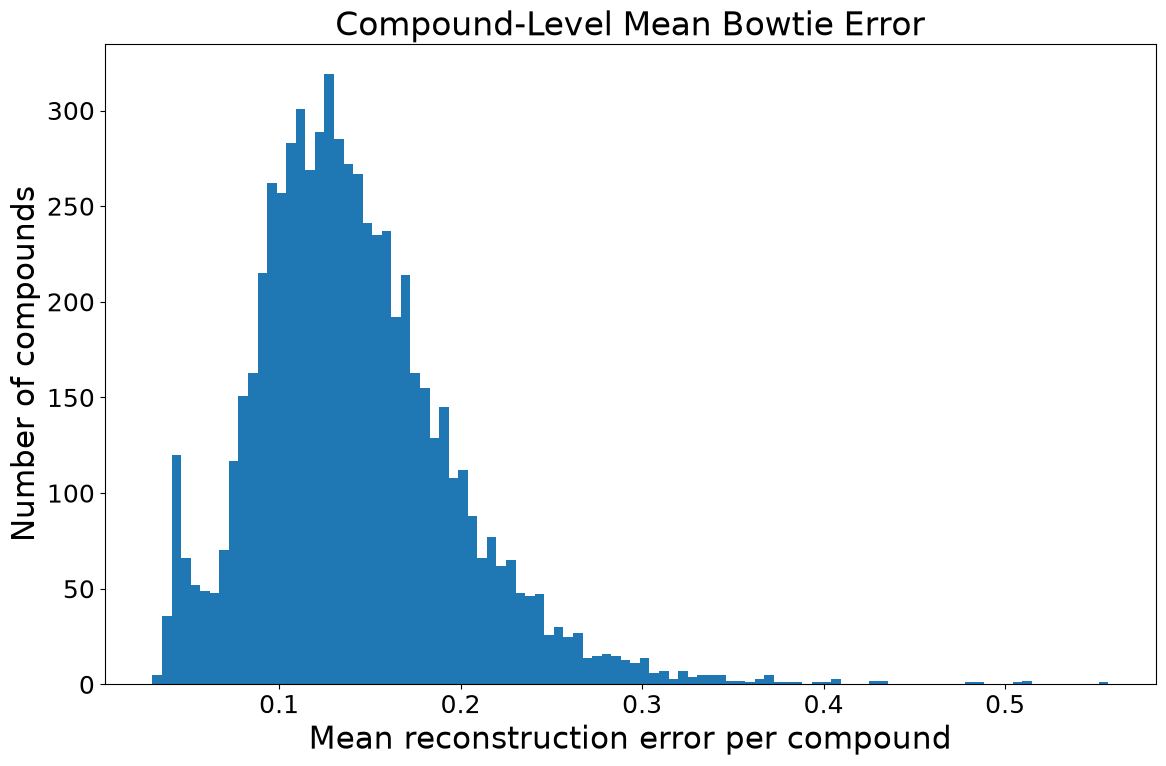

Saved: figures/step3_bowtie_autoencoder/step3_final256_compound_mean_error_histogram.png


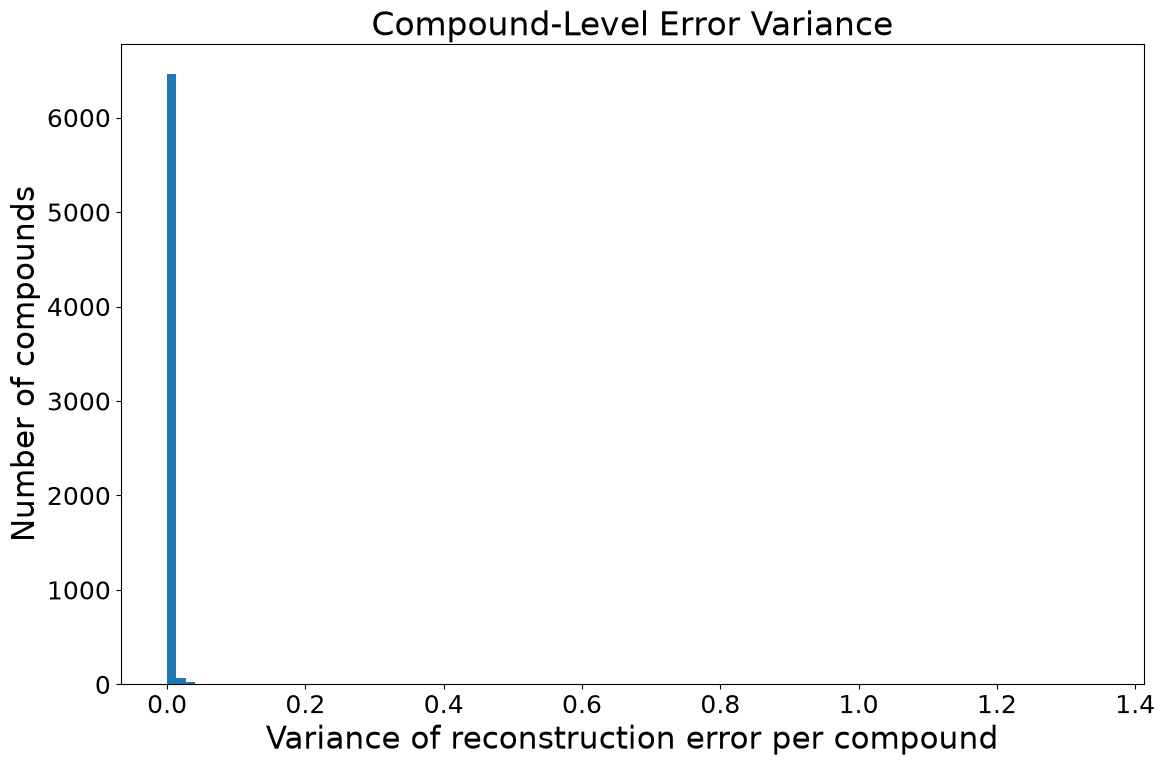

Saved: figures/step3_bowtie_autoencoder/step3_final256_compound_error_variance_histogram.png


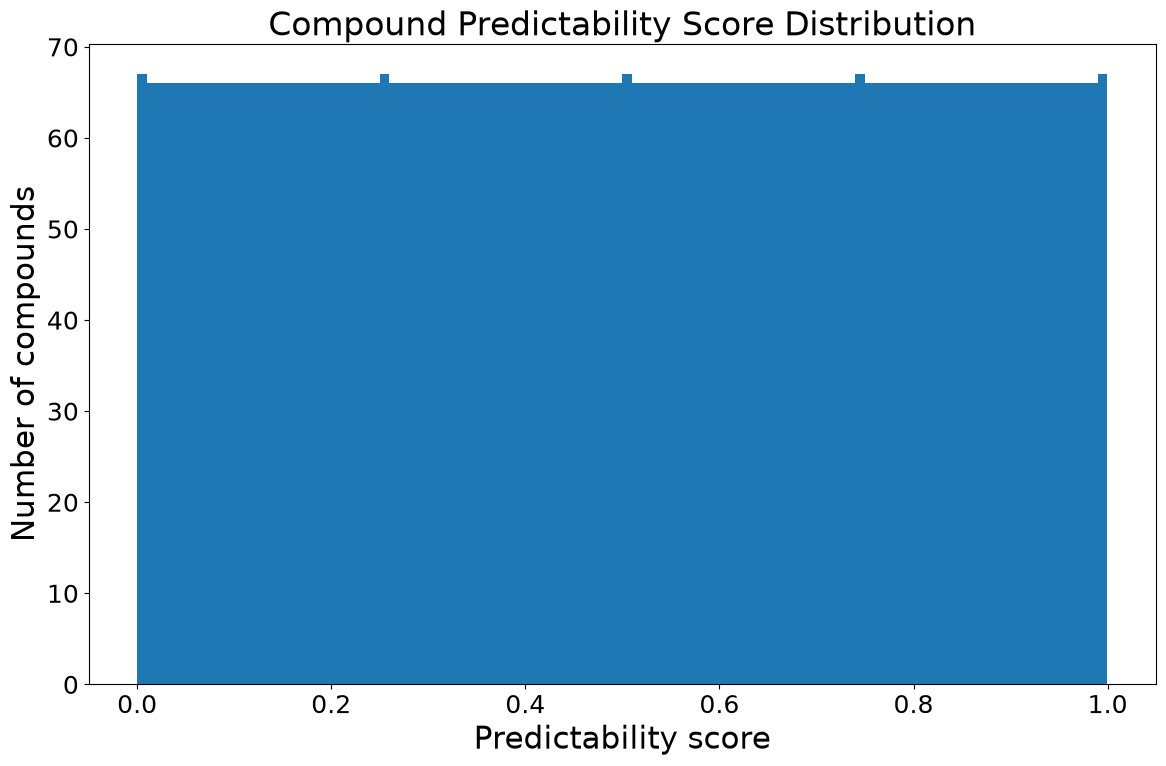

Saved: figures/step3_bowtie_autoencoder/step3_final256_predictability_score_histogram.png


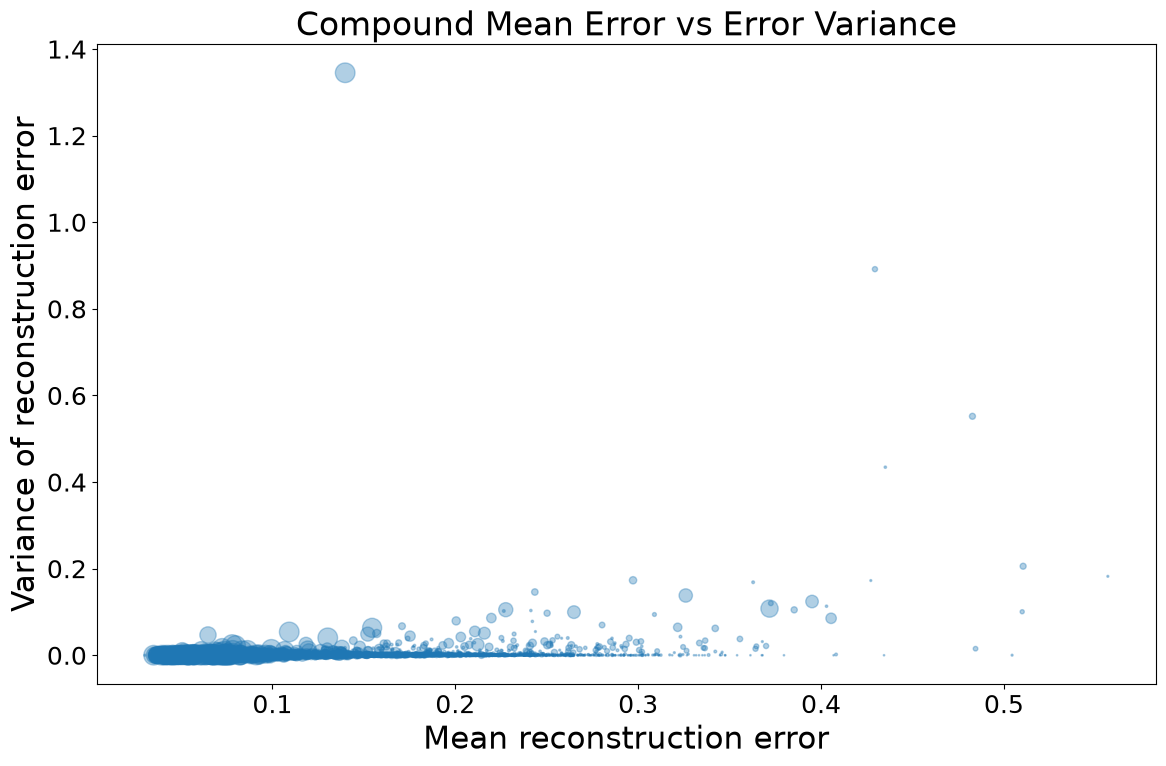

Saved: figures/step3_bowtie_autoencoder/step3_final256_compound_mean_error_vs_variance.png


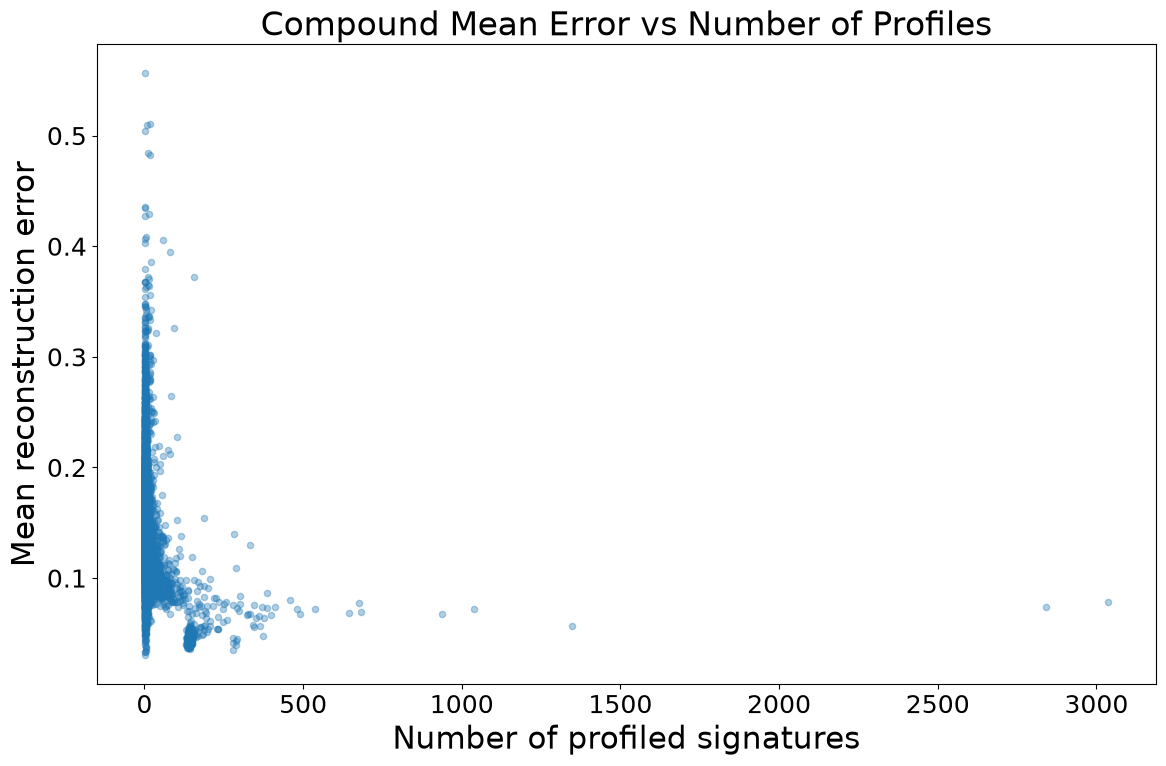

Saved: figures/step3_bowtie_autoencoder/step3_final256_mean_error_vs_n_profiles.png


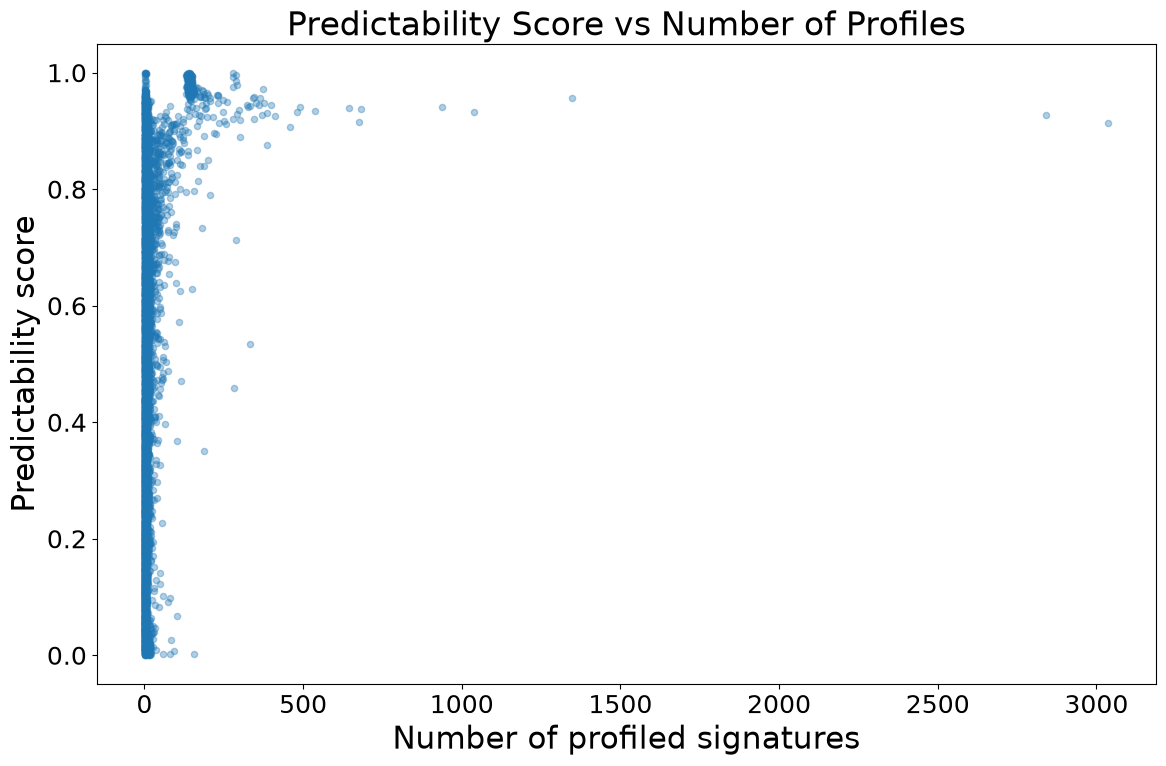

Saved: figures/step3_bowtie_autoencoder/step3_final256_predictability_vs_n_profiles.png


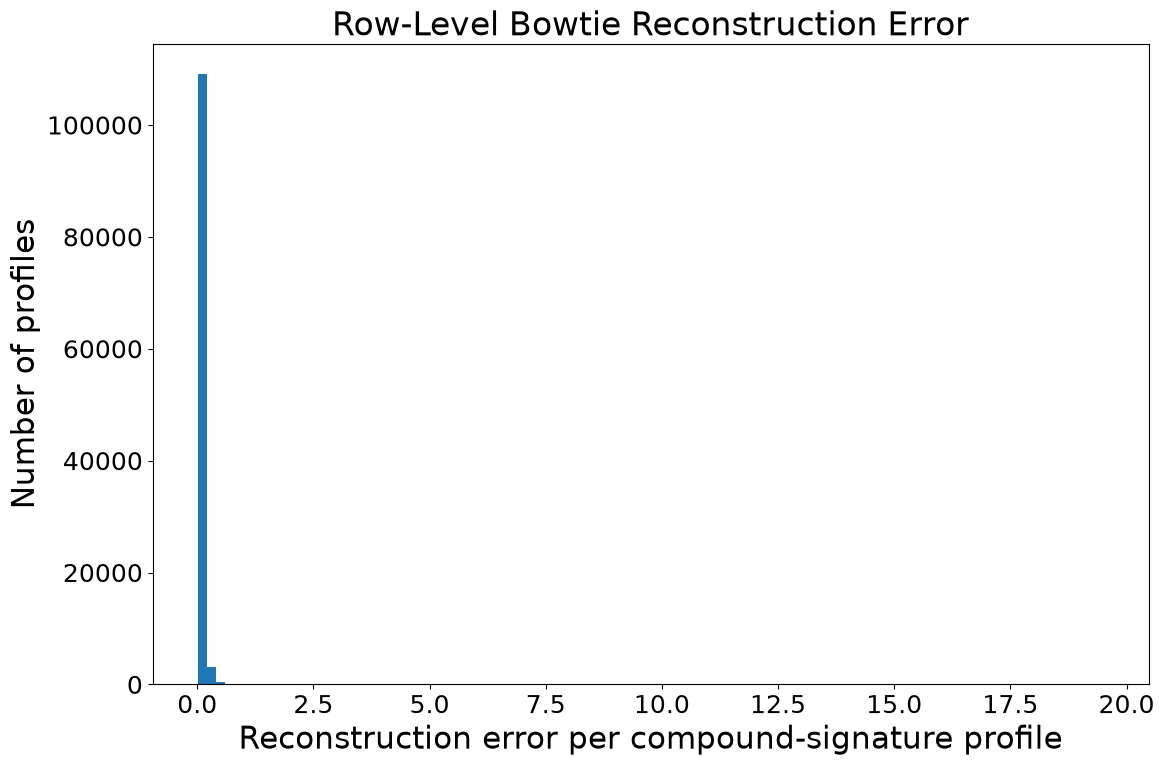

Saved: figures/step3_bowtie_autoencoder/step3_final256_row_total_error_histogram.png


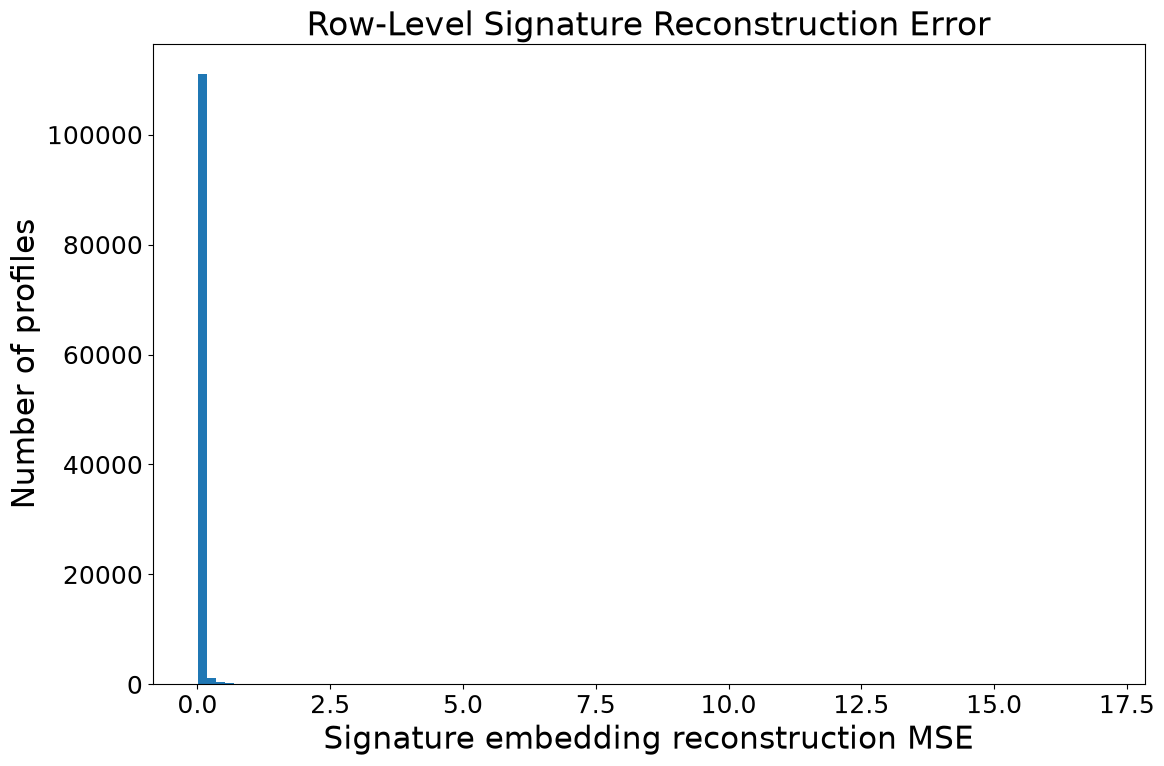

Saved: figures/step3_bowtie_autoencoder/step3_final256_row_signature_error_histogram.png


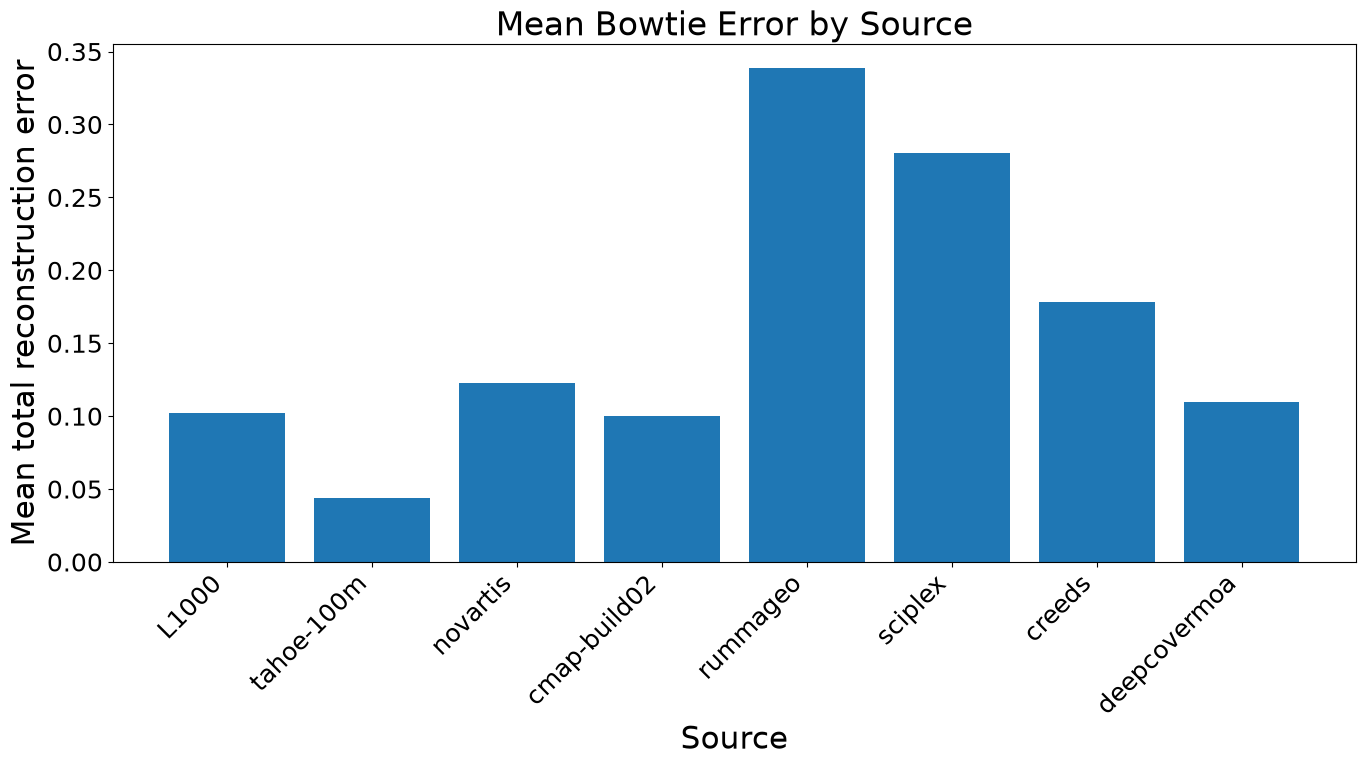

Saved: figures/step3_bowtie_autoencoder/step3_final256_mean_total_error_by_source.png


,source,n,mean_total_error,mean_signature_error,mean_compound_error,mean_categorical_error
0,L1000,60964,0.102338,0.066148,0.028439,0.015305
7,tahoe-100m,39606,0.043698,0.031457,0.008363,0.007647
4,novartis,4554,0.122697,0.045157,0.074224,0.006345
1,cmap-build02,3945,0.100020,0.048648,0.047560,0.007384
5,rummageo,1832,0.338496,0.289022,0.046191,0.005842
6,sciplex,1274,0.280122,0.230778,0.043272,0.011673
2,creeds,460,0.178049,0.116927,0.052179,0.017073
3,deepcovermoa,339,0.109684,0.040862,0.060246,0.016859


Saved most predictable: data/step3_multimodal/step3_final256_most_predictable_compounds_n5.csv
Saved least predictable: data/step3_multimodal/step3_final256_least_predictable_compounds_n5.csv

Most predictable compounds, n_profiles >= 5:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,std_signature_error,mean_compound_error,variance_compound_error,mean_numeric_error,mean_categorical_error,mean_signature_reconstruction_loss,mean_compound_reconstruction_bce,mean_signature_sign_accuracy,mean_compound_bitwise_accuracy,error_percentile,predictability_score
4,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.035060,0.000103,0.010144,0.033378,0.026343,0.000096,0.009821,0.003863,4.873465e-07,0.000086,0.009675,0.183230,0.005732,0.973885,0.998681,0.000757,0.999243
5,5134,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.035564,0.000080,0.008947,0.034380,0.027919,0.000076,0.008724,0.004626,5.647963e-07,0.000106,0.005995,0.131254,0.008397,0.987940,0.997508,0.000908,0.999092
7,5150,Doxycycline (monohydrate); Invertin,139,0.036430,0.000094,0.009709,0.036164,0.024624,0.000081,0.008973,0.006119,1.715827e-06,0.000199,0.011294,0.164053,0.039728,0.976575,0.985344,0.001211,0.998789
8,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.036665,0.000106,0.010287,0.034693,0.026757,0.000097,0.009869,0.005151,7.297209e-07,0.000148,0.009455,0.166981,0.009997,0.979076,0.997215,0.001363,0.998637
9,3111,Temuterkib,143,0.036769,0.000120,0.010969,0.035420,0.028988,0.000126,0.011237,0.005325,1.213775e-06,0.000431,0.004739,0.130000,0.074382,0.985901,0.976550,0.001514,0.998486
10,611,Silodosin,135,0.036897,0.000164,0.012812,0.034347,0.024291,0.000133,0.011511,0.006273,9.803953e-07,0.000269,0.012560,0.181920,0.039619,0.972828,0.986370,0.001665,0.998335
11,2020,Erdafitinib,138,0.037073,0.000097,0.009824,0.036361,0.026791,0.000105,0.010244,0.005715,1.383269e-06,0.000434,0.008961,0.142064,0.005326,0.984799,0.999121,0.001817,0.998183
13,5198,Mitoxantrone (dihydrochloride); Mitoxantrone H...,144,0.037803,0.000086,0.009274,0.036778,0.027325,0.000084,0.009143,0.007804,1.648336e-06,0.000313,0.005222,0.148834,0.006507,0.983041,0.998095,0.002120,0.997880
15,5181,Simotinib,135,0.038178,0.000084,0.009155,0.037471,0.021847,0.000069,0.008317,0.007829,1.057912e-06,0.000178,0.016934,0.246690,0.051505,0.962093,0.983878,0.002422,0.997578
16,3445,Bimiralisib,145,0.038226,0.000090,0.009480,0.038377,0.028734,0.000091,0.009541,0.006763,1.750021e-06,0.000187,0.005383,0.145327,0.014508,0.985015,0.995310,0.002574,0.997426



Least predictable compounds, n_profiles >= 5:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,std_signature_error,mean_compound_error,variance_compound_error,mean_numeric_error,mean_categorical_error,mean_signature_reconstruction_loss,mean_compound_reconstruction_bce,mean_signature_sign_accuracy,mean_compound_bitwise_accuracy,error_percentile,predictability_score
6603,5496,Trehalose; trehalose,19,0.510485,0.205609,0.453442,0.364698,0.445599,0.178601,0.422612,0.060795,0.001398,0.001437,0.007609,0.231902,0.001624,0.966098,0.999853,0.999849,0.000151
6602,4091,inosine,9,0.509975,0.100490,0.317002,0.627762,0.444913,0.093250,0.305369,0.063088,0.000255,0.000914,0.003580,0.186405,0.008019,0.981059,0.997802,0.999697,0.000303
6600,21230,ivosidenib,11,0.484463,0.015171,0.123171,0.471052,0.321262,0.012897,0.113566,0.158351,0.000174,0.001523,0.009089,0.405405,0.028864,0.896011,0.990473,0.999394,0.000606
6599,2512,"(5S,8R,9S,10S,13S,14S,17S)-17-hydroxy-10,13,17...",19,0.482767,0.551864,0.742875,0.121365,0.424118,0.519003,0.720418,0.045990,0.000773,0.002976,0.024128,0.183561,0.027486,0.980037,0.991939,0.999243,0.000757
6596,23986,Angiotensin ii,14,0.429452,0.891662,0.944279,0.115509,0.344843,0.769234,0.877060,0.080715,0.004760,0.001558,0.007164,0.285020,0.006031,0.943064,0.998388,0.998789,0.001211
6592,24002,Palmitic acid,57,0.405489,0.085353,0.292152,0.327945,0.362336,0.070542,0.265597,0.042175,0.000814,0.002546,0.000938,0.154418,0.000840,0.982911,0.999707,0.998183,0.001817
6590,3113,Talazoparib; talazoparib,82,0.395062,0.124098,0.352275,0.287813,0.340726,0.104670,0.323527,0.050593,0.001659,0.001906,0.006723,0.208201,0.060566,0.973276,0.979188,0.997880,0.002120
6589,1367,6-ethyl-3-[3-methoxy-4-[4-(4-methylpiperazin-1...,20,0.385302,0.104864,0.323827,0.253579,0.298420,0.087739,0.296208,0.085841,0.001140,0.001582,0.001447,0.245149,0.018543,0.953732,0.992232,0.997729,0.002271
6587,3479,Pomalidomide; pomalidomide,12,0.372532,0.120112,0.346571,0.181897,0.293818,0.088124,0.296856,0.076669,0.002798,0.003610,0.002644,0.386644,0.005334,0.890068,0.998827,0.997426,0.002574
6586,5116,cisplatin,155,0.371808,0.107791,0.328315,0.299193,0.324467,0.094995,0.308212,0.045044,0.000657,0.002398,0.003635,0.263705,0.003846,0.950562,0.998827,0.997275,0.002725


Final 256D predictability plots complete.


In [13]:
# Step 3 Autoencoder: final 256D predictability plots

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

compound_path = STEP3_DIR / "step3_compound_predictability_latent256_final.csv"
row_errors_path = STEP3_DIR / "step3_bowtie_row_errors_latent256_final.csv"

compound_pred = pd.read_csv(compound_path, low_memory=False)
row_errors = pd.read_csv(row_errors_path, low_memory=False)

print("Compound predictability:", compound_pred.shape)
print("Row errors:", row_errors.shape)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# 1. Compound mean error distribution

plt.figure(figsize=(12, 8))
plt.hist(compound_pred["mean_total_error"].dropna(), bins=100)
plt.title("Compound-Level Mean Bowtie Error")
plt.xlabel("Mean reconstruction error per compound")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_final256_compound_mean_error_histogram.png")


# 2. Compound error variance distribution

plt.figure(figsize=(12, 8))
plt.hist(compound_pred["variance_total_error"].dropna(), bins=100)
plt.title("Compound-Level Error Variance")
plt.xlabel("Variance of reconstruction error per compound")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_final256_compound_error_variance_histogram.png")


# 3. Predictability score distribution

plt.figure(figsize=(12, 8))
plt.hist(compound_pred["predictability_score"].dropna(), bins=100)
plt.title("Compound Predictability Score Distribution")
plt.xlabel("Predictability score")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_final256_predictability_score_histogram.png")


# 4. Mean error vs variance

plot_df = compound_pred.copy()

# cap point sizes so compounds with thousands of profiles don't dominate
sizes = np.clip(plot_df["n_profiles"], 1, 200)

plt.figure(figsize=(12, 8))
plt.scatter(
    plot_df["mean_total_error"],
    plot_df["variance_total_error"],
    s=sizes,
    alpha=0.35,
)
plt.title("Compound Mean Error vs Error Variance")
plt.xlabel("Mean reconstruction error")
plt.ylabel("Variance of reconstruction error")
save_show(FIG_DIR / "step3_final256_compound_mean_error_vs_variance.png")


# 5. Mean error vs number of profiles

plt.figure(figsize=(12, 8))
plt.scatter(
    compound_pred["n_profiles"],
    compound_pred["mean_total_error"],
    s=20,
    alpha=0.35,
)
plt.title("Compound Mean Error vs Number of Profiles")
plt.xlabel("Number of profiled signatures")
plt.ylabel("Mean reconstruction error")
save_show(FIG_DIR / "step3_final256_mean_error_vs_n_profiles.png")


# 6. Predictability score vs number of profiles

plt.figure(figsize=(12, 8))
plt.scatter(
    compound_pred["n_profiles"],
    compound_pred["predictability_score"],
    s=20,
    alpha=0.35,
)
plt.title("Predictability Score vs Number of Profiles")
plt.xlabel("Number of profiled signatures")
plt.ylabel("Predictability score")
save_show(FIG_DIR / "step3_final256_predictability_vs_n_profiles.png")


# 7. Row-level total error distribution

plt.figure(figsize=(12, 8))
plt.hist(row_errors["bowtie_total_error"].dropna(), bins=100)
plt.title("Row-Level Bowtie Reconstruction Error")
plt.xlabel("Reconstruction error per compound-signature profile")
plt.ylabel("Number of profiles")
save_show(FIG_DIR / "step3_final256_row_total_error_histogram.png")


# 8. Row-level signature error distribution

plt.figure(figsize=(12, 8))
plt.hist(row_errors["bowtie_signature_mse"].dropna(), bins=100)
plt.title("Row-Level Signature Reconstruction Error")
plt.xlabel("Signature embedding reconstruction MSE")
plt.ylabel("Number of profiles")
save_show(FIG_DIR / "step3_final256_row_signature_error_histogram.png")


# 9. Error by source

source_summary = (
    row_errors
    .groupby("source")
    .agg(
        n=("signature_row_index", "count"),
        mean_total_error=("bowtie_total_error", "mean"),
        mean_signature_error=("bowtie_signature_mse", "mean"),
        mean_compound_error=("bowtie_compound_mse", "mean"),
        mean_categorical_error=("bowtie_categorical_bce", "mean"),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)

source_summary_path = STEP3_DIR / "step3_final256_bowtie_error_summary_by_source.csv"
source_summary.to_csv(source_summary_path, index=False)

plt.figure(figsize=(14, 8))
plt.bar(source_summary["source"], source_summary["mean_total_error"])
plt.title("Mean Bowtie Error by Source")
plt.xlabel("Source")
plt.ylabel("Mean total reconstruction error")
plt.xticks(rotation=45, ha="right")
save_show(FIG_DIR / "step3_final256_mean_total_error_by_source.png")

display(source_summary)


# 10. Most and least predictable compounds, requiring >= 5 profiles

reliable = compound_pred[compound_pred["n_profiles"] >= 5].copy()

most_predictable = reliable.sort_values("mean_total_error", ascending=True).head(25)
least_predictable = reliable.sort_values("mean_total_error", ascending=False).head(25)

most_path = STEP3_DIR / "step3_final256_most_predictable_compounds_n5.csv"
least_path = STEP3_DIR / "step3_final256_least_predictable_compounds_n5.csv"

most_predictable.to_csv(most_path, index=False)
least_predictable.to_csv(least_path, index=False)

print("Saved most predictable:", most_path)
print("Saved least predictable:", least_path)

print("\nMost predictable compounds, n_profiles >= 5:")
display(most_predictable)

print("\nLeast predictable compounds, n_profiles >= 5:")
display(least_predictable)

print("Final 256D predictability plots complete.")

Compound predictability: (6605, 20)
Row errors: (112974, 27)
Saved updated compound predictability: data/step3_multimodal/step3_compound_predictability_latent256_final_with_source_normalized.csv
Saved updated row errors: data/step3_multimodal/step3_bowtie_row_errors_latent256_final_with_source_normalized.csv


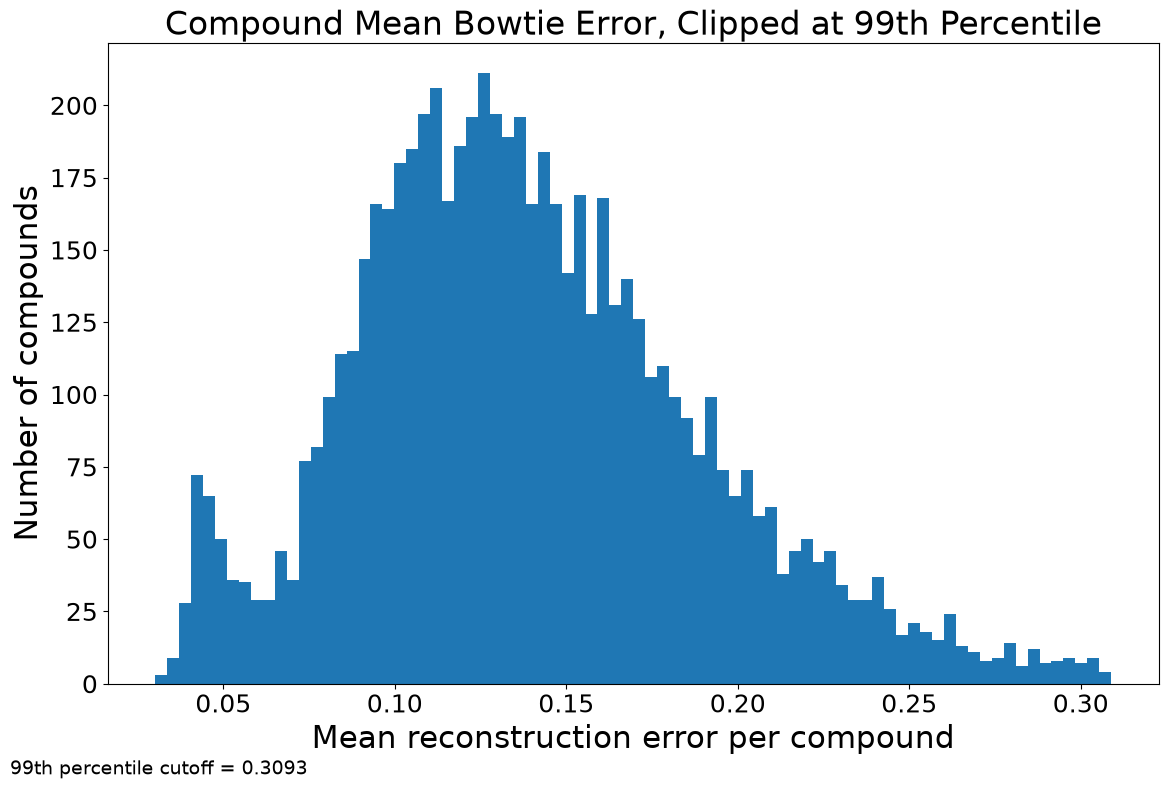

Saved: figures/step3_bowtie_autoencoder/step3_final256_compound_mean_error_clipped99.png


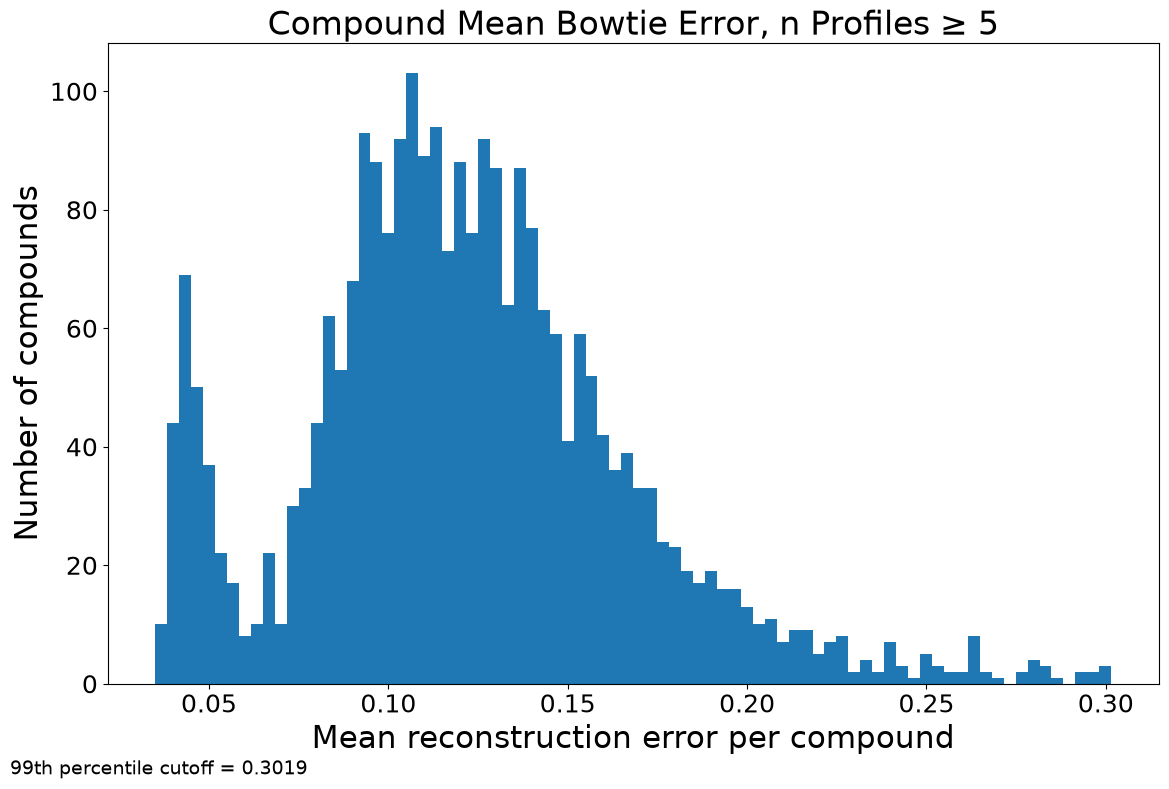

Saved: figures/step3_bowtie_autoencoder/step3_final256_compound_mean_error_n5_clipped99.png


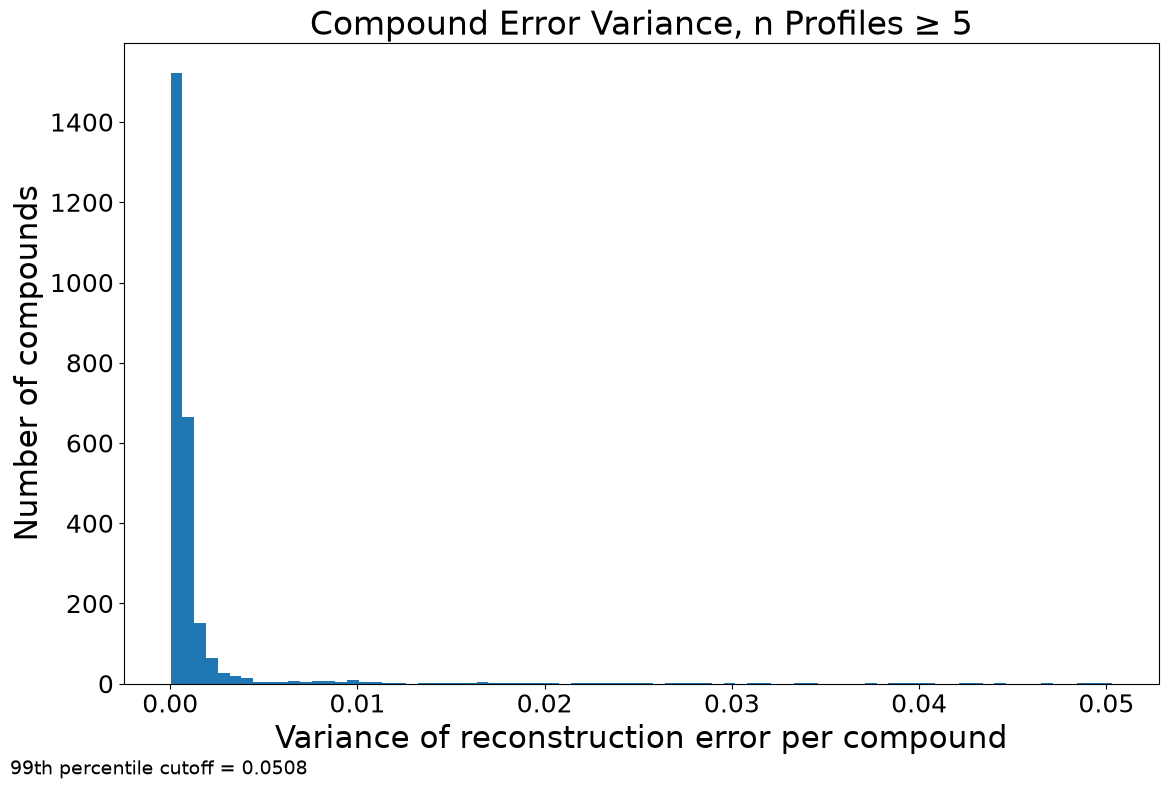

Saved: figures/step3_bowtie_autoencoder/step3_final256_error_variance_n5_clipped99.png


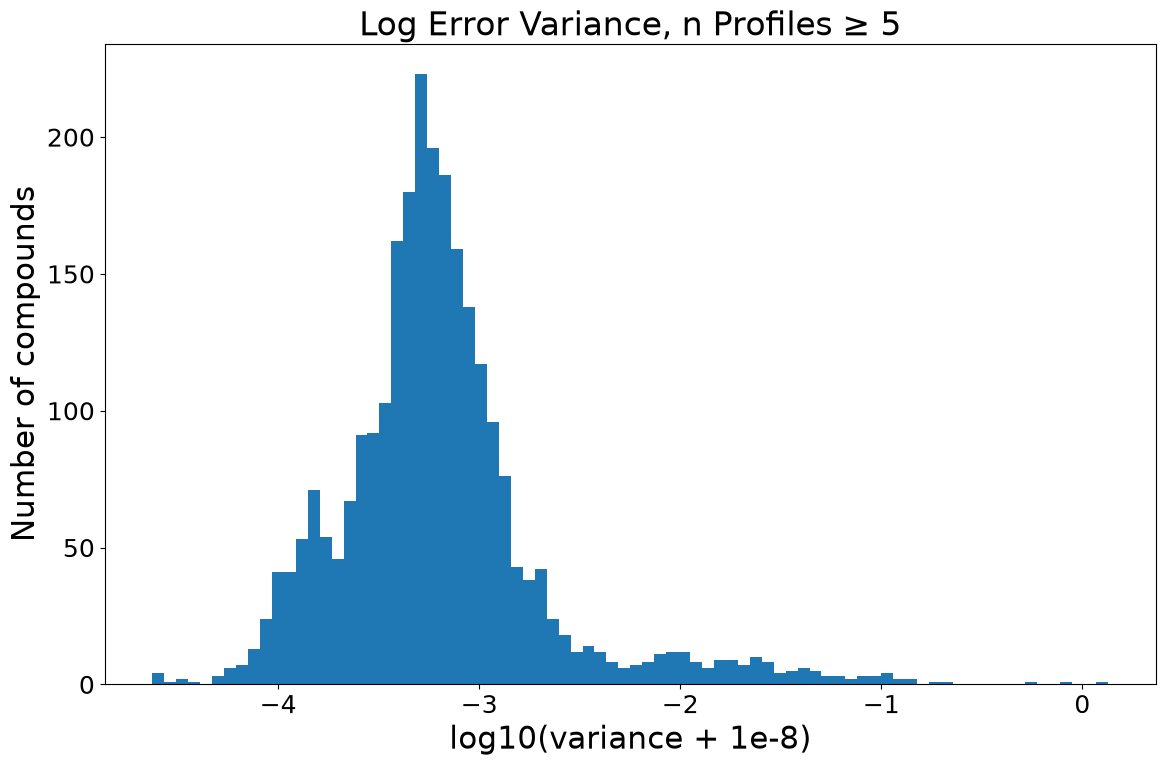

Saved: figures/step3_bowtie_autoencoder/step3_final256_log_error_variance_n5.png


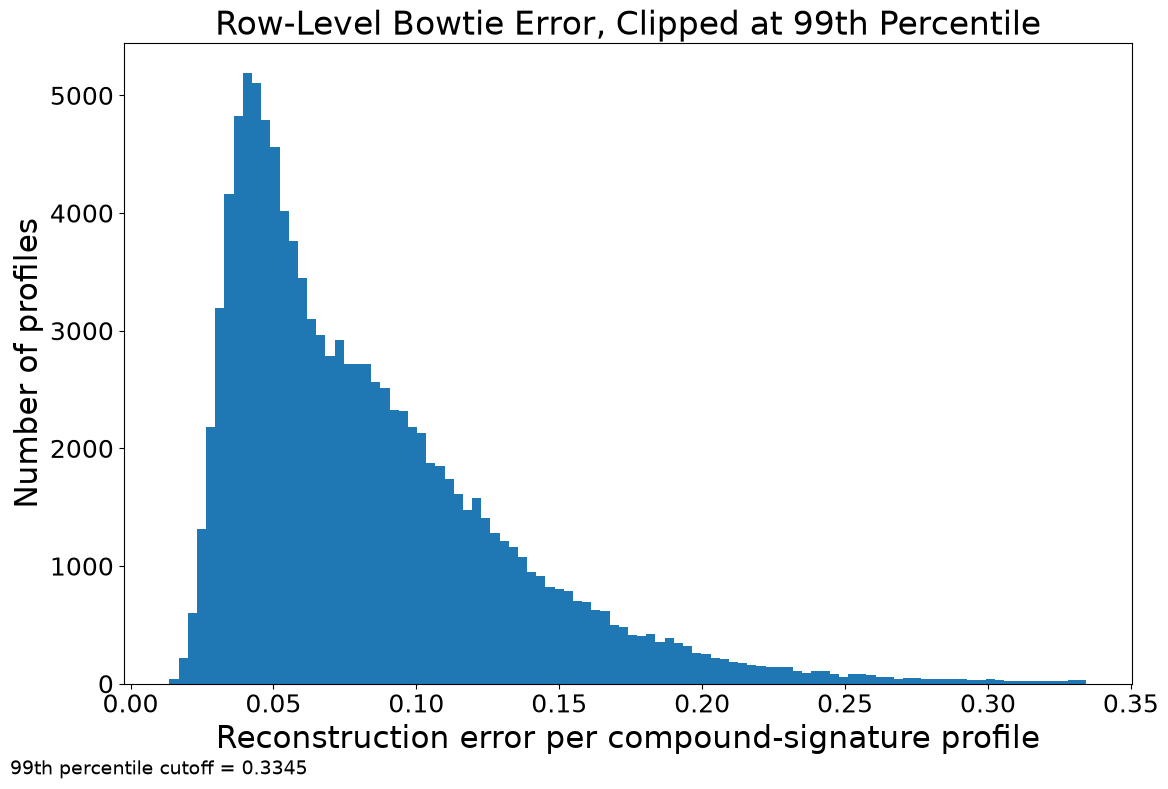

Saved: figures/step3_bowtie_autoencoder/step3_final256_row_total_error_clipped99.png


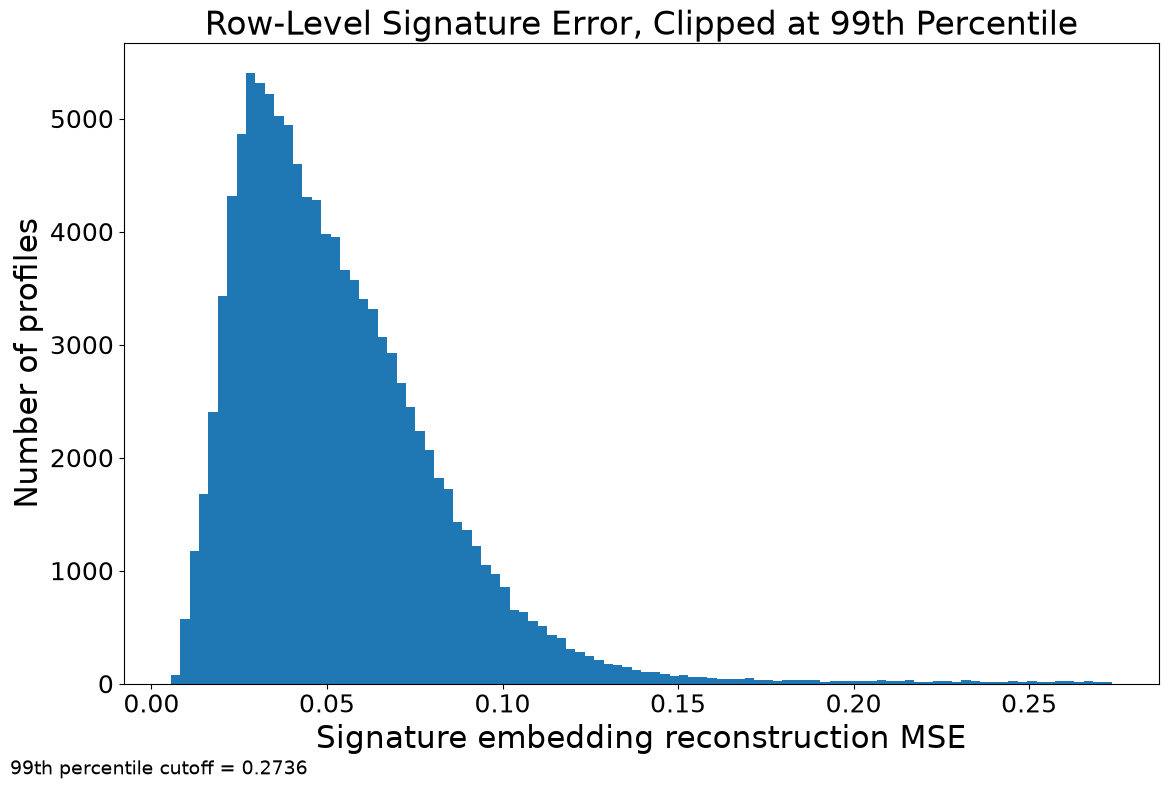

Saved: figures/step3_bowtie_autoencoder/step3_final256_row_signature_error_clipped99.png


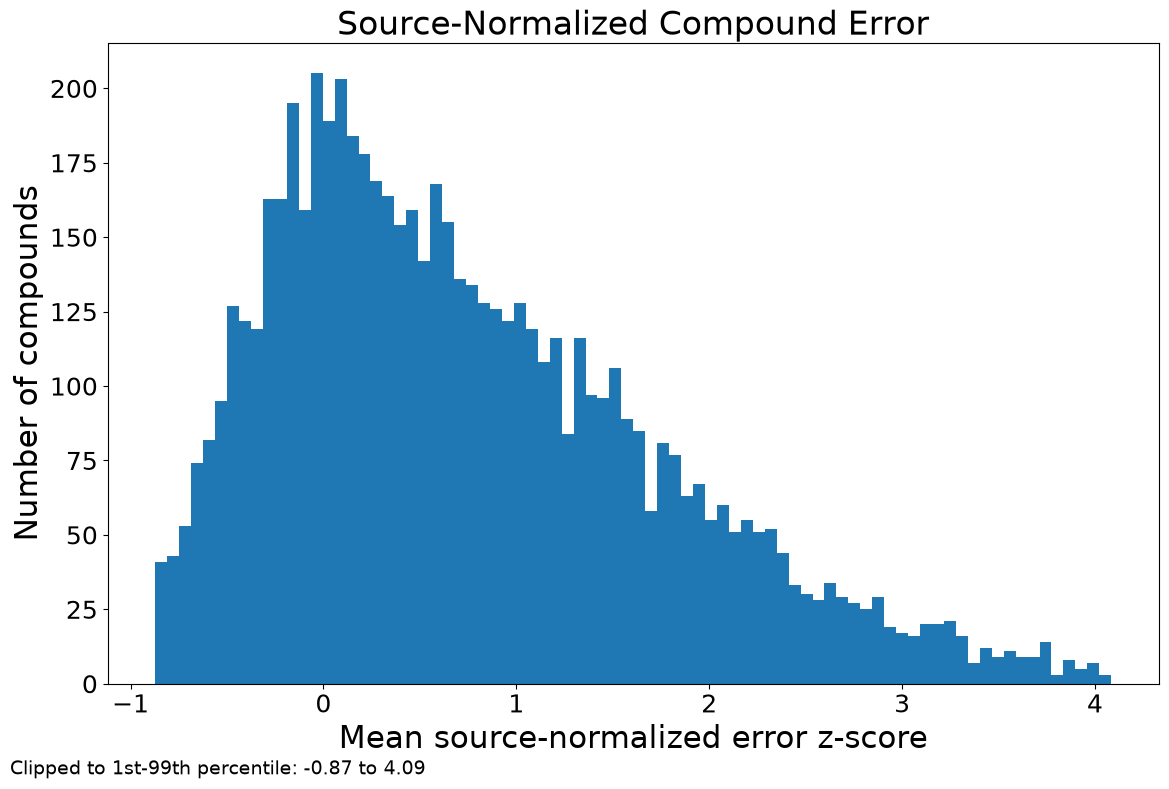

Saved: figures/step3_bowtie_autoencoder/step3_final256_source_normalized_error_histogram.png


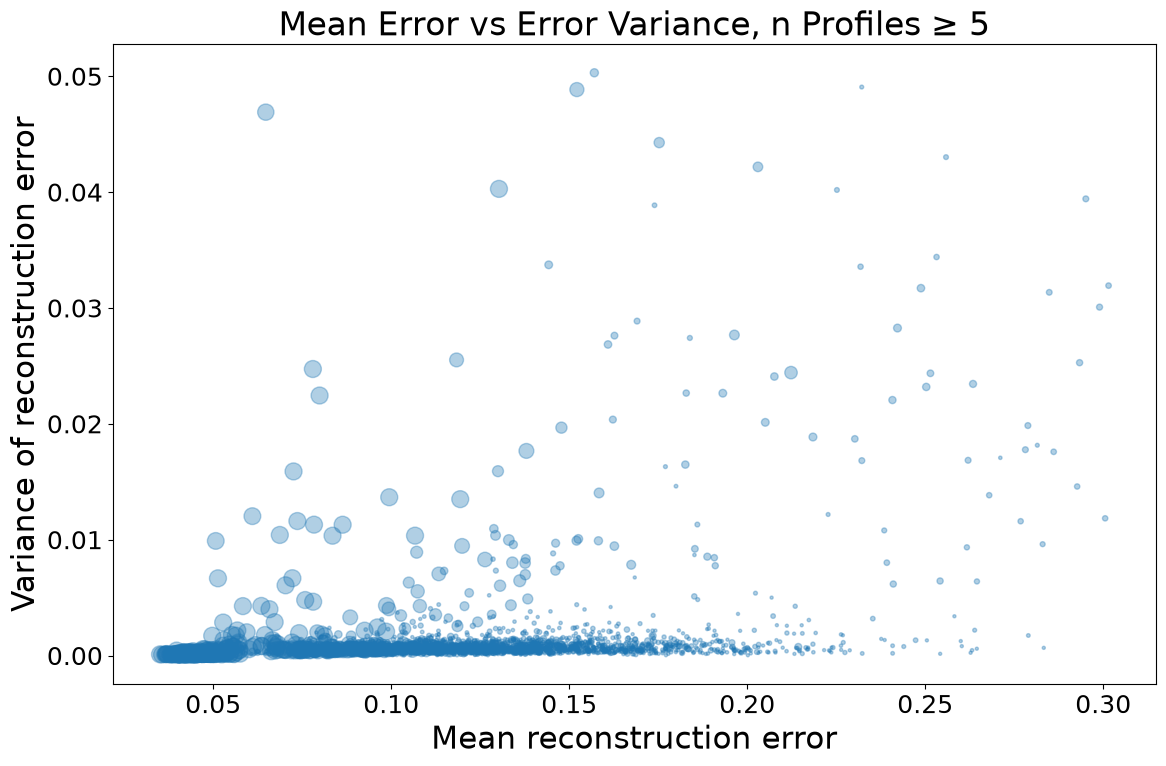

Saved: figures/step3_bowtie_autoencoder/step3_final256_mean_error_vs_variance_n5_clipped99.png


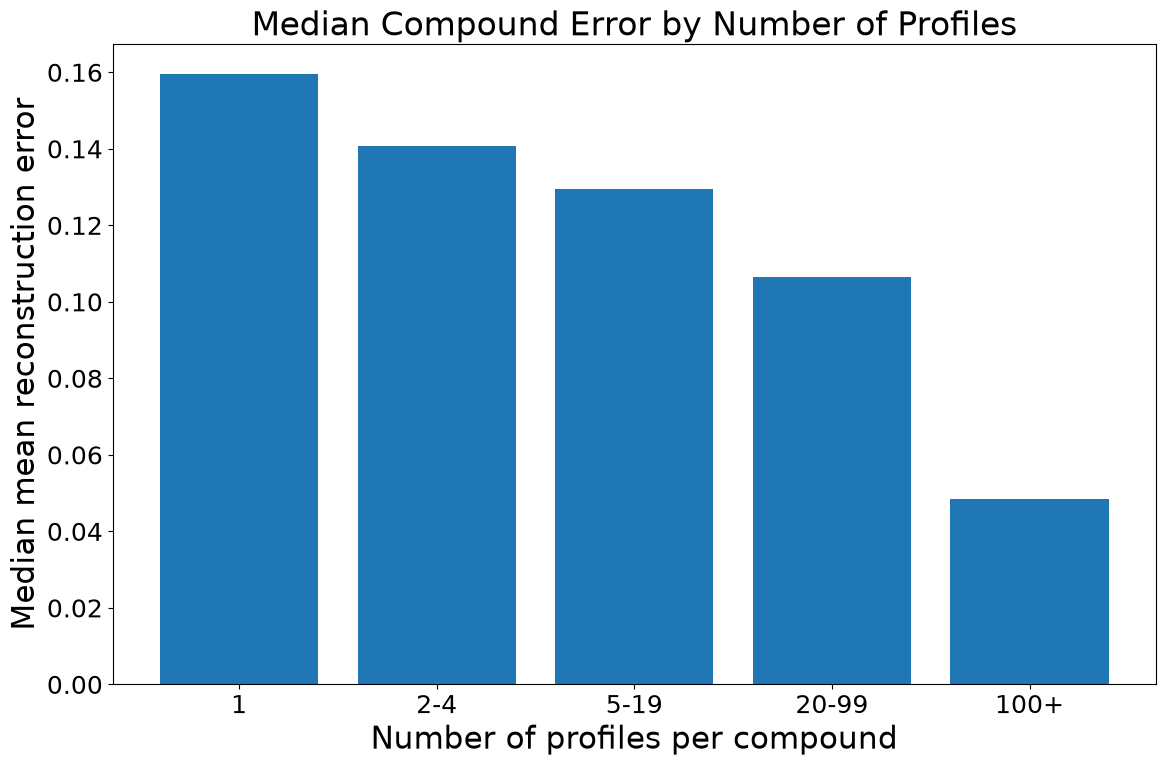

Saved: figures/step3_bowtie_autoencoder/step3_final256_median_error_by_profile_count_bin.png


,profile_count_bin,n_compounds,mean_error,median_error,mean_variance,median_variance,mean_source_normalized_error
0,1,1334,0.166363,0.159509,0.000000,0.000000,1.359477
1,2-4,2647,0.146987,0.140741,0.001645,0.000253,0.796271
2,5-19,1823,0.137606,0.129411,0.002388,0.000583,0.685491
3,20-99,452,0.120467,0.106492,0.005802,0.000641,0.068896
4,100+,349,0.058215,0.048475,0.006344,0.000185,-0.118555


Saved profile-count bin summary: data/step3_multimodal/step3_final256_error_summary_by_profile_count_bin.csv


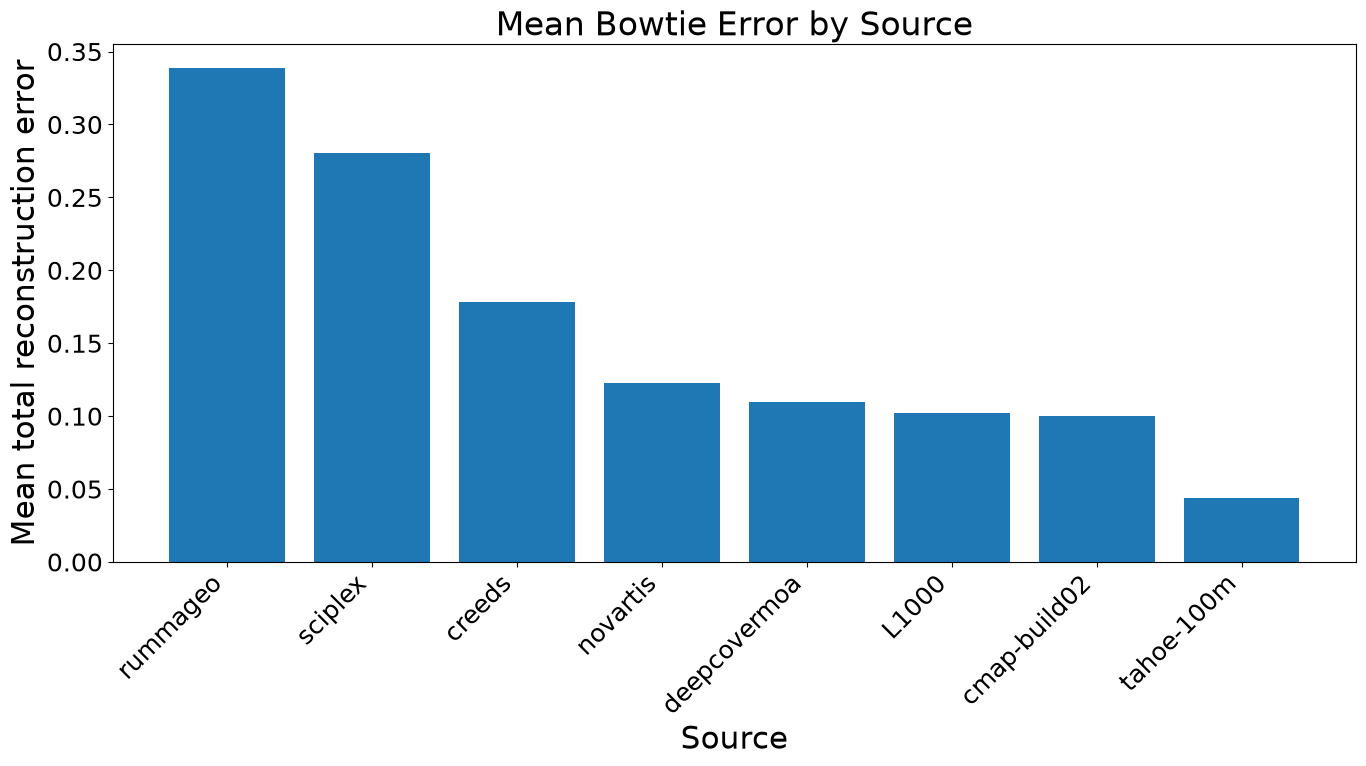

Saved: figures/step3_bowtie_autoencoder/step3_final256_mean_total_error_by_source_improved.png


,source,n_profiles,mean_total_error,median_total_error,mean_signature_error,mean_source_normalized_error,std_total_error
5,rummageo,1832,0.338496,0.232274,0.289022,1.262939e-16,0.340576
6,sciplex,1274,0.280122,0.255742,0.230778,1.742893e-17,0.123116
2,creeds,460,0.178049,0.124226,0.116927,1.369677e-17,0.911995
4,novartis,4554,0.122697,0.108786,0.045157,-1.052201e-16,0.072165
3,deepcovermoa,339,0.109684,0.106546,0.040862,1.022617e-16,0.049422
0,L1000,60964,0.102338,0.093242,0.066148,-2.460878e-16,0.043142
1,cmap-build02,3945,0.100020,0.097250,0.048648,3.934326e-17,0.039299
7,tahoe-100m,39606,0.043698,0.042466,0.031457,-3.533394e-16,0.012012


Saved improved source summary: data/step3_multimodal/step3_final256_error_summary_by_source_improved.csv
Saved n>=20 most predictable: data/step3_multimodal/step3_final256_most_predictable_compounds_n20.csv
Saved n>=20 least predictable: data/step3_multimodal/step3_final256_least_predictable_compounds_n20.csv
Saved source-normalized n>=20 most predictable: data/step3_multimodal/step3_final256_most_predictable_source_normalized_n20.csv
Saved source-normalized n>=20 least predictable: data/step3_multimodal/step3_final256_least_predictable_source_normalized_n20.csv

Most predictable compounds, n_profiles >= 20:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,std_signature_error,...,error_percentile,predictability_score,mean_source_normalized_error_z,variance_source_normalized_error_z,std_source_normalized_error_z,median_source_normalized_error_z,n_sources,source_normalized_error_percentile,source_normalized_predictability_score,profile_count_bin
4,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.035060,0.000103,0.010144,0.033378,0.026343,0.000096,0.009821,...,0.000757,0.999243,-0.719053,0.713194,0.844508,-0.859132,1,0.025284,0.974716,100+
5,5134,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.035564,0.000080,0.008947,0.034380,0.027919,0.000076,0.008724,...,0.000908,0.999092,-0.677140,0.554794,0.744845,-0.775715,1,0.032702,0.967298,100+
7,5150,Doxycycline (monohydrate); Invertin,139,0.036430,0.000094,0.009709,0.036164,0.024624,0.000081,0.008973,...,0.001211,0.998789,-0.605014,0.653283,0.808259,-0.627196,1,0.046480,0.953520,100+
8,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.036665,0.000106,0.010287,0.034693,0.026757,0.000097,0.009869,...,0.001363,0.998637,-0.585465,0.733423,0.856401,-0.749596,1,0.050114,0.949886,100+
9,3111,Temuterkib,143,0.036769,0.000120,0.010969,0.035420,0.028988,0.000126,0.011237,...,0.001514,0.998486,-0.576776,0.833880,0.913170,-0.689149,1,0.051779,0.948221,100+
10,611,Silodosin,135,0.036897,0.000164,0.012812,0.034347,0.024291,0.000133,0.011511,...,0.001665,0.998335,-0.586386,1.094434,1.046152,-0.794216,2,0.049508,0.950492,100+
11,2020,Erdafitinib,138,0.037073,0.000097,0.009824,0.036361,0.026791,0.000105,0.010244,...,0.001817,0.998183,-0.551491,0.668821,0.817815,-0.610807,1,0.058441,0.941559,100+
13,5198,Mitoxantrone (dihydrochloride); Mitoxantrone H...,144,0.037803,0.000086,0.009274,0.036778,0.027325,0.000084,0.009143,...,0.002120,0.997880,-0.490696,0.596115,0.772085,-0.576087,1,0.070855,0.929145,100+
15,5181,Simotinib,135,0.038178,0.000084,0.009155,0.037471,0.021847,0.000069,0.008317,...,0.002422,0.997578,-0.459517,0.580854,0.762138,-0.518393,1,0.081453,0.918547,100+
16,3445,Bimiralisib,145,0.038226,0.000090,0.009480,0.038377,0.028734,0.000091,0.009541,...,0.002574,0.997426,-0.455532,0.622792,0.789172,-0.442953,1,0.082362,0.917638,100+



Least predictable compounds, n_profiles >= 20:


...


Most predictable source-normalized compounds, n_profiles >= 20:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,std_signature_error,...,error_percentile,predictability_score,mean_source_normalized_error_z,variance_source_normalized_error_z,std_source_normalized_error_z,median_source_normalized_error_z,n_sources,source_normalized_error_percentile,source_normalized_predictability_score,profile_count_bin
284,592,BRD-K68202742; Trichostatin A,1346,0.056888,0.000973,0.031188,0.051405,0.043620,0.000768,0.027706,...,0.043149,0.956851,-1.093211,0.228813,0.478344,-1.193037,4,0.001968,0.998032,100+
318,6647,Cephaeline; cephaeline,22,0.060955,0.000356,0.018877,0.059405,0.041142,0.000262,0.016185,...,0.048297,0.951703,-0.978122,0.212379,0.460846,-0.995163,2,0.004239,0.995761,20-99
396,132,"Tanespimycin; [(4E,6Z,8S,9S,10E,12S,13R,14S,16...",645,0.068112,0.000978,0.031266,0.062103,0.054584,0.000839,0.028965,...,0.060106,0.939894,-0.850113,0.275951,0.525310,-0.933319,4,0.012566,0.987434,100+
384,2278,"(7R,9S)-9-acetyl-7-[[(2R,4S,5S,6S)-4-amino-5-h...",325,0.067414,0.001074,0.032764,0.064038,0.053750,0.000877,0.029619,...,0.058289,0.941711,-0.840108,0.211075,0.459429,-0.887781,3,0.013323,0.986677,100+
366,6642,XL-888; XL888,181,0.066252,0.000377,0.019417,0.063336,0.047999,0.000324,0.018011,...,0.055564,0.944436,-0.836460,0.202568,0.450075,-0.904052,1,0.013475,0.986525,100+
380,2431,"3-[(1R,3R,5S,8R,9S,10R,11R,13R,14S,17R)-1,5,11...",79,0.067299,0.000417,0.020413,0.064534,0.050372,0.000340,0.018451,...,0.057684,0.942316,-0.816064,0.228872,0.478406,-0.876264,2,0.015746,0.984254,20-99
389,4527,topotecan,151,0.067821,0.000685,0.026168,0.061191,0.051405,0.000575,0.023980,...,0.059046,0.940954,-0.812614,0.289954,0.538474,-0.926552,3,0.016048,0.983952,100+
385,1827,Geldanamycin; geldanamycin,938,0.067444,0.000427,0.020658,0.064359,0.055316,0.000365,0.019109,...,0.058441,0.941559,-0.810345,0.231831,0.481488,-0.880322,2,0.016200,0.983800,100+
400,2275,Epirubicin; epirubicin,194,0.068225,0.000497,0.022295,0.065583,0.054796,0.000438,0.020920,...,0.060712,0.939288,-0.790719,0.267057,0.516776,-0.851960,1,0.018168,0.981832,100+
661,1471,Abexinostat; PCI-24781,117,0.081388,0.001749,0.041823,0.069102,0.057966,0.001374,0.037070,...,0.100227,0.899773,-0.767927,0.178718,0.422751,-0.853841,2,0.020439,0.979561,100+



Least predictable source-normalized compounds, n_profiles >= 20:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_signature_error,variance_signature_error,std_signature_error,...,error_percentile,predictability_score,mean_source_normalized_error_z,variance_source_normalized_error_z,std_source_normalized_error_z,median_source_normalized_error_z,n_sources,source_normalized_error_percentile,source_normalized_predictability_score,profile_count_bin
5979,7866,BRD-K09991945; GSK-3 Inhibitor II,25,0.214337,0.000744,0.027268,0.216921,0.100151,0.000570,0.023880,...,0.905375,0.094625,2.596076,0.399501,0.632061,2.655983,1,0.933687,0.066313,20-99
5256,2174,"1-(2,4-dimethoxyphenyl)-3-(2,6-dimethylphenyl)...",22,0.180227,0.000852,0.029197,0.176794,0.079654,0.000823,0.028691,...,0.795912,0.204088,1.805427,0.458028,0.676778,1.725849,1,0.836942,0.163058,20-99
5201,5896,4-tert-butyl-N-[2-methyl-3-[4-methyl-6-[4-(mor...,20,0.178439,0.000591,0.024318,0.176473,0.080750,0.000428,0.020688,...,0.787585,0.212415,1.763997,0.317743,0.563687,1.718421,1,0.828917,0.171083,20-99
5020,497,PU-H71; Zelavespib,20,0.172672,0.000733,0.027081,0.169469,0.084931,0.000634,0.025178,...,0.760182,0.239818,1.630305,0.394027,0.627716,1.556073,1,0.803634,0.196366,20-99
5050,1599,6-cyclopropyl-8-fluoro-2-[2-(hydroxymethyl)-3-...,25,0.173434,0.001712,0.041375,0.170279,0.069674,0.001204,0.034693,...,0.764724,0.235276,1.596176,1.087231,1.042704,1.574852,3,0.797123,0.202877,20-99
4846,6226,N-[2-methyl-5-[oxo-[3-(1-oxoprop-2-enylamino)-...,29,0.168157,0.000955,0.030901,0.160495,0.080033,0.000831,0.028831,...,0.733838,0.266162,1.525648,0.513036,0.716265,1.348048,1,0.780167,0.219833,20-99
4831,24208,"2,7-bis(piperidin-1-ylsulfonyl)-9H-fluoren-9-o...",24,0.167789,0.000497,0.022295,0.162156,0.066997,0.000348,0.018652,...,0.731567,0.268433,1.517131,0.267071,0.516789,1.386560,1,0.777290,0.222710,20-99
4728,4491,rimcazole,26,0.165139,0.000453,0.021286,0.164160,0.065729,0.000357,0.018896,...,0.715973,0.284027,1.312633,0.291766,0.540154,1.203530,2,0.725965,0.274035,20-99
294,5179,BI-3406,143,0.057567,0.000148,0.012159,0.055808,0.035917,0.000148,0.012156,...,0.044663,0.955337,1.154600,1.024653,1.012251,1.008189,1,0.687207,0.312793,100+
4147,698,4-(4-(trifluoromethyl)phenyl)-N-(6-fluoro-1H-i...,29,0.151712,0.000763,0.027616,0.153610,0.080145,0.000646,0.025413,...,0.628009,0.371991,1.136678,0.420203,0.648230,1.188475,2,0.682967,0.317033,20-99


Improved final 256D diagnostics complete.


In [14]:
# Step 3 final 256D: improved diagnostics + source-normalized predictability plots

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

compound_path = STEP3_DIR / "step3_compound_predictability_latent256_final.csv"
row_errors_path = STEP3_DIR / "step3_bowtie_row_errors_latent256_final.csv"

compound_pred = pd.read_csv(compound_path, low_memory=False)
row_errors = pd.read_csv(row_errors_path, low_memory=False)

print("Compound predictability:", compound_pred.shape)
print("Row errors:", row_errors.shape)


# Add source-normalized row error

source_stats = (
    row_errors
    .groupby("source")
    .agg(
        source_mean_total_error=("bowtie_total_error", "mean"),
        source_std_total_error=("bowtie_total_error", "std"),
        source_n=("bowtie_total_error", "count"),
    )
    .reset_index()
)

row_errors_norm = row_errors.merge(source_stats, on="source", how="left")
row_errors_norm["source_std_total_error"] = row_errors_norm["source_std_total_error"].replace(0, np.nan)

row_errors_norm["source_normalized_total_error_z"] = (
    (row_errors_norm["bowtie_total_error"] - row_errors_norm["source_mean_total_error"])
    / row_errors_norm["source_std_total_error"]
)

# Fallback if a source has std 0
row_errors_norm["source_normalized_total_error_z"] = row_errors_norm["source_normalized_total_error_z"].fillna(0)


# Aggregate source-normalized errors by compound

compound_source_norm = (
    row_errors_norm
    .groupby(["compound_embedding_row_index", "compound_name"], dropna=False)
    .agg(
        n_profiles=("signature_row_index", "count"),
        mean_source_normalized_error_z=("source_normalized_total_error_z", "mean"),
        variance_source_normalized_error_z=("source_normalized_total_error_z", "var"),
        std_source_normalized_error_z=("source_normalized_total_error_z", "std"),
        median_source_normalized_error_z=("source_normalized_total_error_z", "median"),
        n_sources=("source", "nunique"),
    )
    .reset_index()
)

for col in ["variance_source_normalized_error_z", "std_source_normalized_error_z"]:
    compound_source_norm[col] = compound_source_norm[col].fillna(0)

# merge onto compound table
compound_pred2 = compound_pred.merge(
    compound_source_norm,
    on=["compound_embedding_row_index", "compound_name", "n_profiles"],
    how="left"
)

# Lower source-normalized error = more predictable relative to source
compound_pred2["source_normalized_error_percentile"] = (
    compound_pred2["mean_source_normalized_error_z"].rank(pct=True)
)

compound_pred2["source_normalized_predictability_score"] = (
    1 - compound_pred2["source_normalized_error_percentile"]
)

# Profile-count bins
bins = [0, 1, 4, 19, 99, np.inf]
labels = ["1", "2-4", "5-19", "20-99", "100+"]

compound_pred2["profile_count_bin"] = pd.cut(
    compound_pred2["n_profiles"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Save updated tables
updated_compound_path = STEP3_DIR / "step3_compound_predictability_latent256_final_with_source_normalized.csv"
updated_row_path = STEP3_DIR / "step3_bowtie_row_errors_latent256_final_with_source_normalized.csv"

compound_pred2.to_csv(updated_compound_path, index=False)
row_errors_norm.to_csv(updated_row_path, index=False)

print("Saved updated compound predictability:", updated_compound_path)
print("Saved updated row errors:", updated_row_path)


# Plot settings

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

def clipped_series(s, q=0.99):
    s = s.dropna()
    upper = s.quantile(q)
    return s[s <= upper], upper


# 1. Mean total error: all compounds, clipped

mean_clipped, mean_q99 = clipped_series(compound_pred2["mean_total_error"], 0.99)

plt.figure(figsize=(12, 8))
plt.hist(mean_clipped, bins=80)
plt.title("Compound Mean Bowtie Error, Clipped at 99th Percentile")
plt.xlabel("Mean reconstruction error per compound")
plt.ylabel("Number of compounds")
plt.figtext(0.02, 0.01, f"99th percentile cutoff = {mean_q99:.4f}", fontsize=14)
save_show(FIG_DIR / "step3_final256_compound_mean_error_clipped99.png")


# 2. Mean total error: reliable compounds only

reliable5 = compound_pred2[compound_pred2["n_profiles"] >= 5].copy()
mean_reliable_clipped, mean_rel_q99 = clipped_series(reliable5["mean_total_error"], 0.99)

plt.figure(figsize=(12, 8))
plt.hist(mean_reliable_clipped, bins=80)
plt.title("Compound Mean Bowtie Error, n Profiles ≥ 5")
plt.xlabel("Mean reconstruction error per compound")
plt.ylabel("Number of compounds")
plt.figtext(0.02, 0.01, f"99th percentile cutoff = {mean_rel_q99:.4f}", fontsize=14)
save_show(FIG_DIR / "step3_final256_compound_mean_error_n5_clipped99.png")


# 3. Variance: only compounds with n_profiles >= 5, clipped

var_reliable_clipped, var_rel_q99 = clipped_series(reliable5["variance_total_error"], 0.99)

plt.figure(figsize=(12, 8))
plt.hist(var_reliable_clipped, bins=80)
plt.title("Compound Error Variance, n Profiles ≥ 5")
plt.xlabel("Variance of reconstruction error per compound")
plt.ylabel("Number of compounds")
plt.figtext(0.02, 0.01, f"99th percentile cutoff = {var_rel_q99:.4f}", fontsize=14)
save_show(FIG_DIR / "step3_final256_error_variance_n5_clipped99.png")


# 4. Log variance: n_profiles >= 5

plt.figure(figsize=(12, 8))
plt.hist(np.log10(reliable5["variance_total_error"].fillna(0) + 1e-8), bins=80)
plt.title("Log Error Variance, n Profiles ≥ 5")
plt.xlabel("log10(variance + 1e-8)")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_final256_log_error_variance_n5.png")


# 5. Row-level total error, clipped

row_total_clipped, row_total_q99 = clipped_series(row_errors_norm["bowtie_total_error"], 0.99)

plt.figure(figsize=(12, 8))
plt.hist(row_total_clipped, bins=100)
plt.title("Row-Level Bowtie Error, Clipped at 99th Percentile")
plt.xlabel("Reconstruction error per compound-signature profile")
plt.ylabel("Number of profiles")
plt.figtext(0.02, 0.01, f"99th percentile cutoff = {row_total_q99:.4f}", fontsize=14)
save_show(FIG_DIR / "step3_final256_row_total_error_clipped99.png")


# 6. Row-level signature error, clipped

row_sig_clipped, row_sig_q99 = clipped_series(row_errors_norm["bowtie_signature_mse"], 0.99)

plt.figure(figsize=(12, 8))
plt.hist(row_sig_clipped, bins=100)
plt.title("Row-Level Signature Error, Clipped at 99th Percentile")
plt.xlabel("Signature embedding reconstruction MSE")
plt.ylabel("Number of profiles")
plt.figtext(0.02, 0.01, f"99th percentile cutoff = {row_sig_q99:.4f}", fontsize=14)
save_show(FIG_DIR / "step3_final256_row_signature_error_clipped99.png")


# 7. Source-normalized mean error distribution

source_norm_clipped, source_norm_q99 = clipped_series(
    compound_pred2["mean_source_normalized_error_z"],
    0.99
)

# also remove extreme low tail for readability
source_norm_q01 = compound_pred2["mean_source_normalized_error_z"].quantile(0.01)
source_norm_plot = compound_pred2[
    (compound_pred2["mean_source_normalized_error_z"] >= source_norm_q01)
    & (compound_pred2["mean_source_normalized_error_z"] <= source_norm_q99)
]["mean_source_normalized_error_z"]

plt.figure(figsize=(12, 8))
plt.hist(source_norm_plot.dropna(), bins=80)
plt.title("Source-Normalized Compound Error")
plt.xlabel("Mean source-normalized error z-score")
plt.ylabel("Number of compounds")
plt.figtext(
    0.02,
    0.01,
    f"Clipped to 1st-99th percentile: {source_norm_q01:.2f} to {source_norm_q99:.2f}",
    fontsize=14
)
save_show(FIG_DIR / "step3_final256_source_normalized_error_histogram.png")


# 8. Mean error vs variance, n_profiles >= 5 and clipped

scatter_df = reliable5[
    (reliable5["mean_total_error"] <= mean_rel_q99)
    & (reliable5["variance_total_error"] <= var_rel_q99)
].copy()

plt.figure(figsize=(12, 8))
plt.scatter(
    scatter_df["mean_total_error"],
    scatter_df["variance_total_error"],
    s=np.clip(scatter_df["n_profiles"], 5, 150),
    alpha=0.35,
)
plt.title("Mean Error vs Error Variance, n Profiles ≥ 5")
plt.xlabel("Mean reconstruction error")
plt.ylabel("Variance of reconstruction error")
save_show(FIG_DIR / "step3_final256_mean_error_vs_variance_n5_clipped99.png")


# 9. Mean error by profile-count bin

profile_bin_summary = (
    compound_pred2
    .groupby("profile_count_bin", observed=True)
    .agg(
        n_compounds=("compound_embedding_row_index", "count"),
        mean_error=("mean_total_error", "mean"),
        median_error=("mean_total_error", "median"),
        mean_variance=("variance_total_error", "mean"),
        median_variance=("variance_total_error", "median"),
        mean_source_normalized_error=("mean_source_normalized_error_z", "mean"),
    )
    .reset_index()
)

profile_bin_path = STEP3_DIR / "step3_final256_error_summary_by_profile_count_bin.csv"
profile_bin_summary.to_csv(profile_bin_path, index=False)

plt.figure(figsize=(12, 8))
plt.bar(profile_bin_summary["profile_count_bin"].astype(str), profile_bin_summary["median_error"])
plt.title("Median Compound Error by Number of Profiles")
plt.xlabel("Number of profiles per compound")
plt.ylabel("Median mean reconstruction error")
save_show(FIG_DIR / "step3_final256_median_error_by_profile_count_bin.png")

display(profile_bin_summary)
print("Saved profile-count bin summary:", profile_bin_path)


# 10. Source-level raw vs source-normalized summaries

source_summary = (
    row_errors_norm
    .groupby("source")
    .agg(
        n_profiles=("signature_row_index", "count"),
        mean_total_error=("bowtie_total_error", "mean"),
        median_total_error=("bowtie_total_error", "median"),
        mean_signature_error=("bowtie_signature_mse", "mean"),
        mean_source_normalized_error=("source_normalized_total_error_z", "mean"),
        std_total_error=("bowtie_total_error", "std"),
    )
    .reset_index()
    .sort_values("mean_total_error", ascending=False)
)

source_summary_path = STEP3_DIR / "step3_final256_error_summary_by_source_improved.csv"
source_summary.to_csv(source_summary_path, index=False)

plt.figure(figsize=(14, 8))
plt.bar(source_summary["source"], source_summary["mean_total_error"])
plt.title("Mean Bowtie Error by Source")
plt.xlabel("Source")
plt.ylabel("Mean total reconstruction error")
plt.xticks(rotation=45, ha="right")
save_show(FIG_DIR / "step3_final256_mean_total_error_by_source_improved.png")

display(source_summary)
print("Saved improved source summary:", source_summary_path)


# 11. Most/least predictable with stronger reliability filters

reliable20 = compound_pred2[compound_pred2["n_profiles"] >= 20].copy()
reliable50 = compound_pred2[compound_pred2["n_profiles"] >= 50].copy()

most_n20 = reliable20.sort_values("mean_total_error", ascending=True).head(25)
least_n20 = reliable20.sort_values("mean_total_error", ascending=False).head(25)

most_source_norm_n20 = reliable20.sort_values("mean_source_normalized_error_z", ascending=True).head(25)
least_source_norm_n20 = reliable20.sort_values("mean_source_normalized_error_z", ascending=False).head(25)

most_n20_path = STEP3_DIR / "step3_final256_most_predictable_compounds_n20.csv"
least_n20_path = STEP3_DIR / "step3_final256_least_predictable_compounds_n20.csv"
most_source_norm_n20_path = STEP3_DIR / "step3_final256_most_predictable_source_normalized_n20.csv"
least_source_norm_n20_path = STEP3_DIR / "step3_final256_least_predictable_source_normalized_n20.csv"

most_n20.to_csv(most_n20_path, index=False)
least_n20.to_csv(least_n20_path, index=False)
most_source_norm_n20.to_csv(most_source_norm_n20_path, index=False)
least_source_norm_n20.to_csv(least_source_norm_n20_path, index=False)

print("Saved n>=20 most predictable:", most_n20_path)
print("Saved n>=20 least predictable:", least_n20_path)
print("Saved source-normalized n>=20 most predictable:", most_source_norm_n20_path)
print("Saved source-normalized n>=20 least predictable:", least_source_norm_n20_path)

print("\nMost predictable compounds, n_profiles >= 20:")
display(most_n20)

print("\nLeast predictable compounds, n_profiles >= 20:")
display(least_n20)

print("\nMost predictable source-normalized compounds, n_profiles >= 20:")
display(most_source_norm_n20)

print("\nLeast predictable source-normalized compounds, n_profiles >= 20:")
display(least_source_norm_n20)

print("Improved final 256D diagnostics complete.")

In [15]:
# Step 3 final 256D: profile-count confound diagnostics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

compound_path = STEP3_DIR / "step3_compound_predictability_latent256_final_with_source_normalized.csv"
compound_pred = pd.read_csv(compound_path, low_memory=False)

print("Compound predictability:", compound_pred.shape)


# Make profile count bins if needed

bins = [0, 1, 4, 19, 99, np.inf]
labels = ["1", "2-4", "5-19", "20-99", "100+"]

compound_pred["profile_count_bin"] = pd.cut(
    compound_pred["n_profiles"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


# Summary table by profile-count bin

profile_bin_summary = (
    compound_pred
    .groupby("profile_count_bin", observed=True)
    .agg(
        n_compounds=("compound_embedding_row_index", "count"),
        median_n_profiles=("n_profiles", "median"),

        mean_error=("mean_total_error", "mean"),
        median_error=("mean_total_error", "median"),
        q25_error=("mean_total_error", lambda x: x.quantile(0.25)),
        q75_error=("mean_total_error", lambda x: x.quantile(0.75)),

        mean_source_normalized_error=("mean_source_normalized_error_z", "mean"),
        median_source_normalized_error=("mean_source_normalized_error_z", "median"),
        q25_source_normalized_error=("mean_source_normalized_error_z", lambda x: x.quantile(0.25)),
        q75_source_normalized_error=("mean_source_normalized_error_z", lambda x: x.quantile(0.75)),

        median_variance=("variance_total_error", "median"),
        mean_variance=("variance_total_error", "mean"),
    )
    .reset_index()
)

summary_path = STEP3_DIR / "step3_final256_profile_count_confound_summary.csv"
profile_bin_summary.to_csv(summary_path, index=False)

display(profile_bin_summary)
print("Saved profile-count confound summary:", summary_path)


# Correlations

corr_summary = pd.DataFrame([
    {
        "comparison": "n_profiles vs mean_total_error",
        "pearson": compound_pred["n_profiles"].corr(compound_pred["mean_total_error"], method="pearson"),
        "spearman": compound_pred["n_profiles"].corr(compound_pred["mean_total_error"], method="spearman"),
    },
    {
        "comparison": "n_profiles vs source_normalized_error",
        "pearson": compound_pred["n_profiles"].corr(compound_pred["mean_source_normalized_error_z"], method="pearson"),
        "spearman": compound_pred["n_profiles"].corr(compound_pred["mean_source_normalized_error_z"], method="spearman"),
    },
    {
        "comparison": "n_profiles vs variance_total_error",
        "pearson": compound_pred["n_profiles"].corr(compound_pred["variance_total_error"], method="pearson"),
        "spearman": compound_pred["n_profiles"].corr(compound_pred["variance_total_error"], method="spearman"),
    },
])

corr_path = STEP3_DIR / "step3_final256_profile_count_correlations.csv"
corr_summary.to_csv(corr_path, index=False)

display(corr_summary)
print("Saved correlations:", corr_path)


# Plot settings

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# 1. Boxplot: raw mean error by profile-count bin

box_data = [
    compound_pred.loc[compound_pred["profile_count_bin"] == label, "mean_total_error"].dropna()
    for label in labels
]

plt.figure(figsize=(12, 8))
plt.boxplot(box_data, labels=labels, showfliers=False)
plt.title("Compound Mean Error by Number of Profiles")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Mean reconstruction error")
save_show(FIG_DIR / "step3_final256_boxplot_mean_error_by_profile_count_bin.png")


# 2. Boxplot: source-normalized error by profile-count bin

box_data_norm = [
    compound_pred.loc[compound_pred["profile_count_bin"] == label, "mean_source_normalized_error_z"].dropna()
    for label in labels
]

plt.figure(figsize=(12, 8))
plt.boxplot(box_data_norm, labels=labels, showfliers=False)
plt.axhline(0, linestyle="--", linewidth=2)
plt.title("Source-Normalized Error by Number of Profiles")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Mean source-normalized error z-score")
save_show(FIG_DIR / "step3_final256_boxplot_source_normalized_error_by_profile_count_bin.png")


# 3. Median raw error with IQR by profile-count bin

x = np.arange(len(profile_bin_summary))

plt.figure(figsize=(12, 8))
plt.errorbar(
    x,
    profile_bin_summary["median_error"],
    yerr=[
        profile_bin_summary["median_error"] - profile_bin_summary["q25_error"],
        profile_bin_summary["q75_error"] - profile_bin_summary["median_error"],
    ],
    marker="o",
    linewidth=3,
    capsize=6,
)
plt.xticks(x, profile_bin_summary["profile_count_bin"].astype(str))
plt.title("Median Compound Error Declines with More Profiles")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Median mean reconstruction error")
save_show(FIG_DIR / "step3_final256_median_error_iqr_by_profile_count_bin.png")


# 4. Median source-normalized error with IQR by profile-count bin

plt.figure(figsize=(12, 8))
plt.errorbar(
    x,
    profile_bin_summary["median_source_normalized_error"],
    yerr=[
        profile_bin_summary["median_source_normalized_error"] - profile_bin_summary["q25_source_normalized_error"],
        profile_bin_summary["q75_source_normalized_error"] - profile_bin_summary["median_source_normalized_error"],
    ],
    marker="o",
    linewidth=3,
    capsize=6,
)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xticks(x, profile_bin_summary["profile_count_bin"].astype(str))
plt.title("Median Source-Normalized Error by Profile Count")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Median source-normalized error z-score")
save_show(FIG_DIR / "step3_final256_median_source_normalized_error_iqr_by_profile_count_bin.png")


# 5. Scatter: mean error vs n_profiles with log x-axis

plt.figure(figsize=(12, 8))
plt.scatter(
    compound_pred["n_profiles"],
    compound_pred["mean_total_error"],
    s=16,
    alpha=0.3,
)
plt.xscale("log")
plt.title("Compound Error vs Number of Profiles")
plt.xlabel("Number of profiled signatures, log scale")
plt.ylabel("Mean reconstruction error")
save_show(FIG_DIR / "step3_final256_mean_error_vs_n_profiles_logx.png")


# 6. Scatter: source-normalized error vs n_profiles with log x-axis

plt.figure(figsize=(12, 8))
plt.scatter(
    compound_pred["n_profiles"],
    compound_pred["mean_source_normalized_error_z"],
    s=16,
    alpha=0.3,
)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xscale("log")
plt.title("Source-Normalized Error vs Number of Profiles")
plt.xlabel("Number of profiled signatures, log scale")
plt.ylabel("Mean source-normalized error z-score")
save_show(FIG_DIR / "step3_final256_source_normalized_error_vs_n_profiles_logx.png")


# 7. How many compounds are in each profile bin

plt.figure(figsize=(12, 8))
plt.bar(
    profile_bin_summary["profile_count_bin"].astype(str),
    profile_bin_summary["n_compounds"]
)
plt.title("Compound Counts by Number of Profiles")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_final256_compound_counts_by_profile_count_bin.png")

print("Profile-count confound diagnostics complete.")

Compound predictability: (6605, 28)


,profile_count_bin,n_compounds,median_n_profiles,mean_error,median_error,q25_error,q75_error,mean_source_normalized_error,median_source_normalized_error,q25_source_normalized_error,q75_source_normalized_error,median_variance,mean_variance
0,1,1334,1.0,0.166363,0.159509,0.127499,0.198096,1.359477,1.196747,0.376888,2.143061,0.000000,0.000000
1,2-4,2647,3.0,0.146987,0.140741,0.109748,0.175922,0.796271,0.622324,-0.041590,1.520808,0.000253,0.001645
2,5-19,1823,8.0,0.137606,0.129411,0.108137,0.156011,0.685491,0.575340,0.096217,1.158463,0.000583,0.002388
3,20-99,452,36.0,0.120467,0.106492,0.093898,0.129448,0.068896,0.002616,-0.246553,0.289581,0.000641,0.005802
4,100+,349,143.0,0.058215,0.048475,0.043383,0.067444,-0.118555,-0.176079,-0.394176,0.124345,0.000185,0.006344


Saved profile-count confound summary: data/step3_multimodal/step3_final256_profile_count_confound_summary.csv


,comparison,pearson,spearman
0,n_profiles vs mean_total_error,-0.232642,-0.380821
1,n_profiles vs source_normalized_error,-0.175379,-0.337049
2,n_profiles vs variance_total_error,0.047642,0.621124


Saved correlations: data/step3_multimodal/step3_final256_profile_count_correlations.csv


<Figure size 1200x800 with 0 Axes>

,profile_count_bin,n_compounds,median_n_profiles,mean_error,median_error,q25_error,q75_error,mean_source_normalized_error,median_source_normalized_error,q25_source_normalized_error,q75_source_normalized_error,median_variance,mean_variance
0,1,1334,1.0,0.166363,0.159509,0.127499,0.198096,1.359477,1.196747,0.376888,2.143061,0.000000,0.000000
1,2-4,2647,3.0,0.146987,0.140741,0.109748,0.175922,0.796271,0.622324,-0.041590,1.520808,0.000253,0.001645
2,5-19,1823,8.0,0.137606,0.129411,0.108137,0.156011,0.685491,0.575340,0.096217,1.158463,0.000583,0.002388
3,20-99,452,36.0,0.120467,0.106492,0.093898,0.129448,0.068896,0.002616,-0.246553,0.289581,0.000641,0.005802
4,100+,349,143.0,0.058215,0.048475,0.043383,0.067444,-0.118555,-0.176079,-0.394176,0.124345,0.000185,0.006344


,comparison,pearson,spearman
0,n_profiles vs mean_total_error,-0.232642,-0.380821
1,n_profiles vs source_normalized_error,-0.175379,-0.337049
2,n_profiles vs variance_total_error,0.047642,0.621124


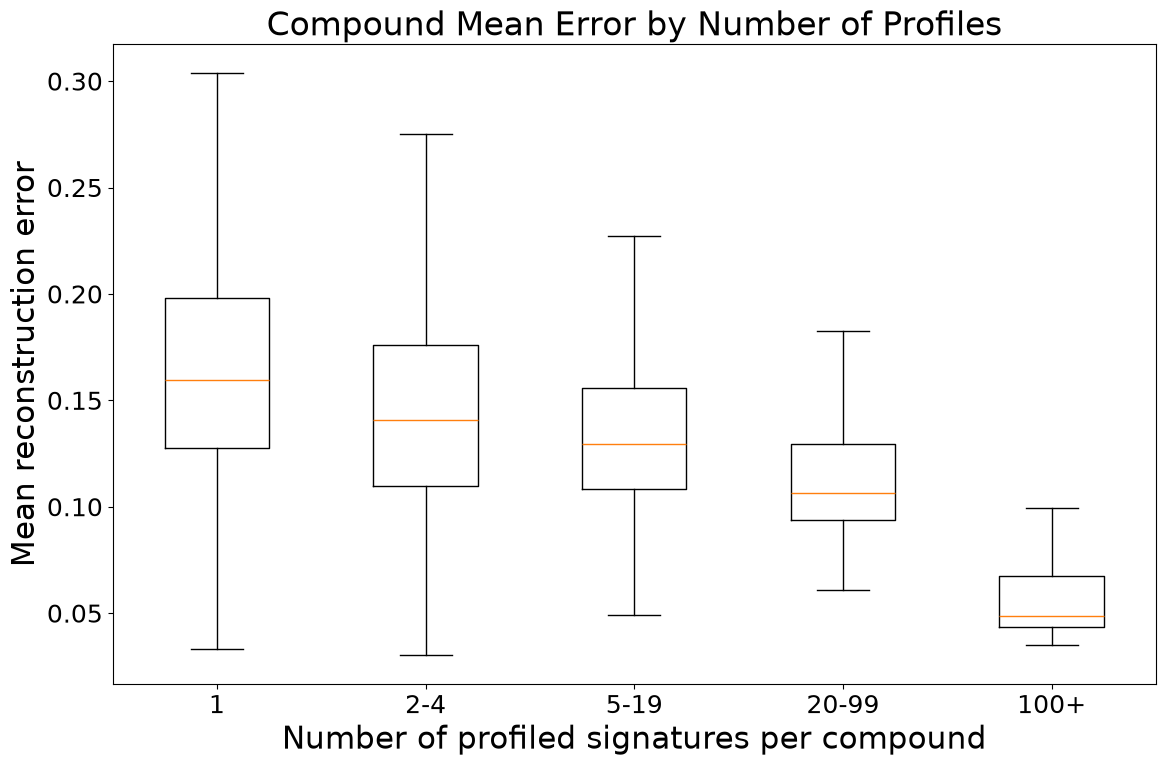

Saved: figures/step3_bowtie_autoencoder/step3_final256_boxplot_mean_error_by_profile_count_bin.png


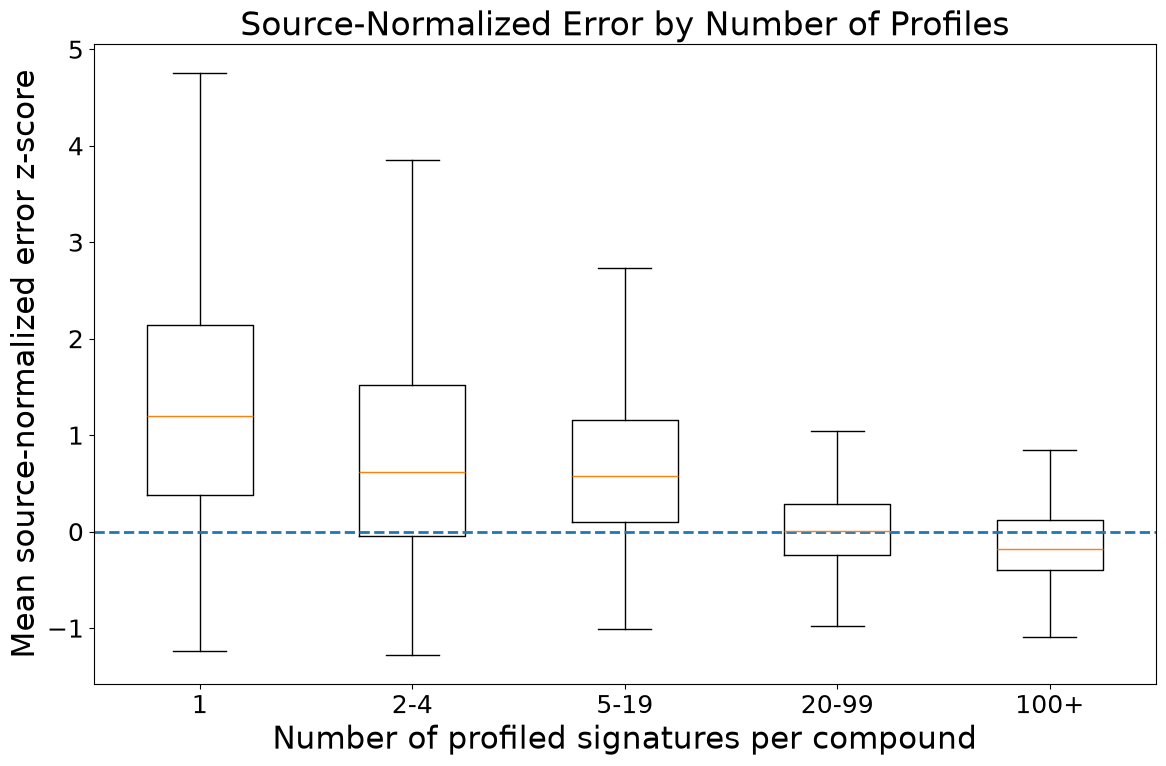

Saved: figures/step3_bowtie_autoencoder/step3_final256_boxplot_source_normalized_error_by_profile_count_bin.png


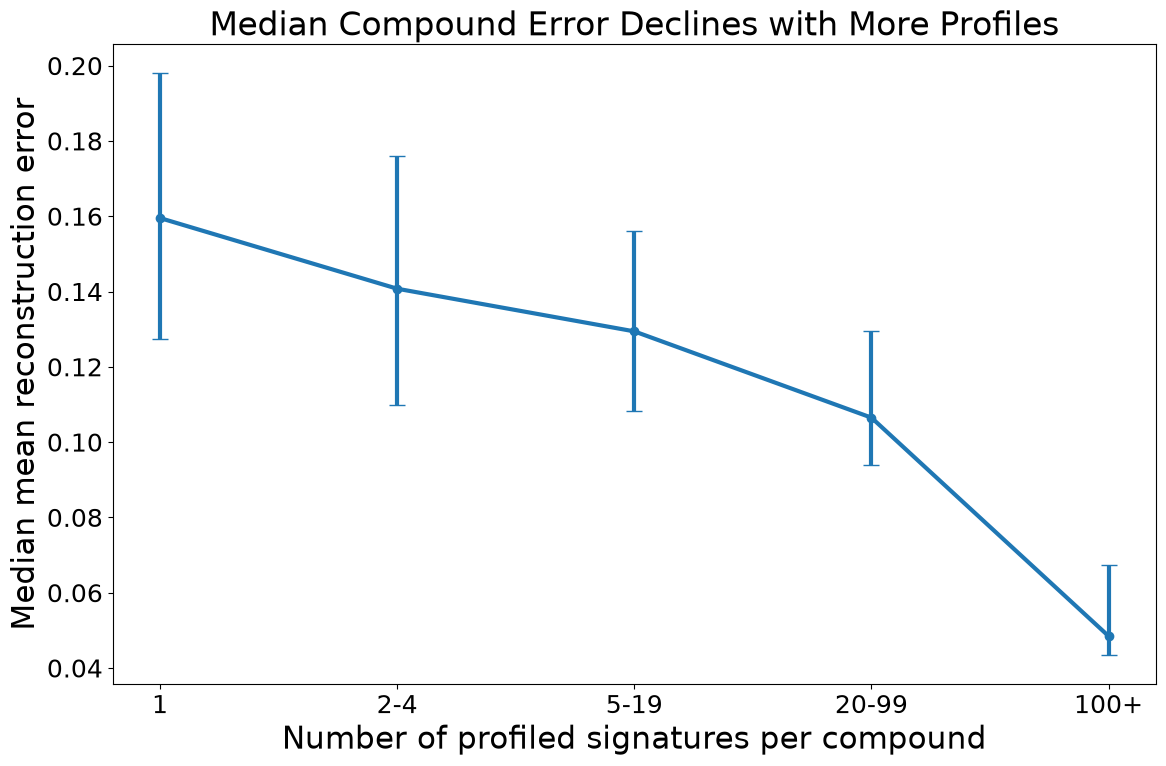

Saved: figures/step3_bowtie_autoencoder/step3_final256_median_error_iqr_by_profile_count_bin.png


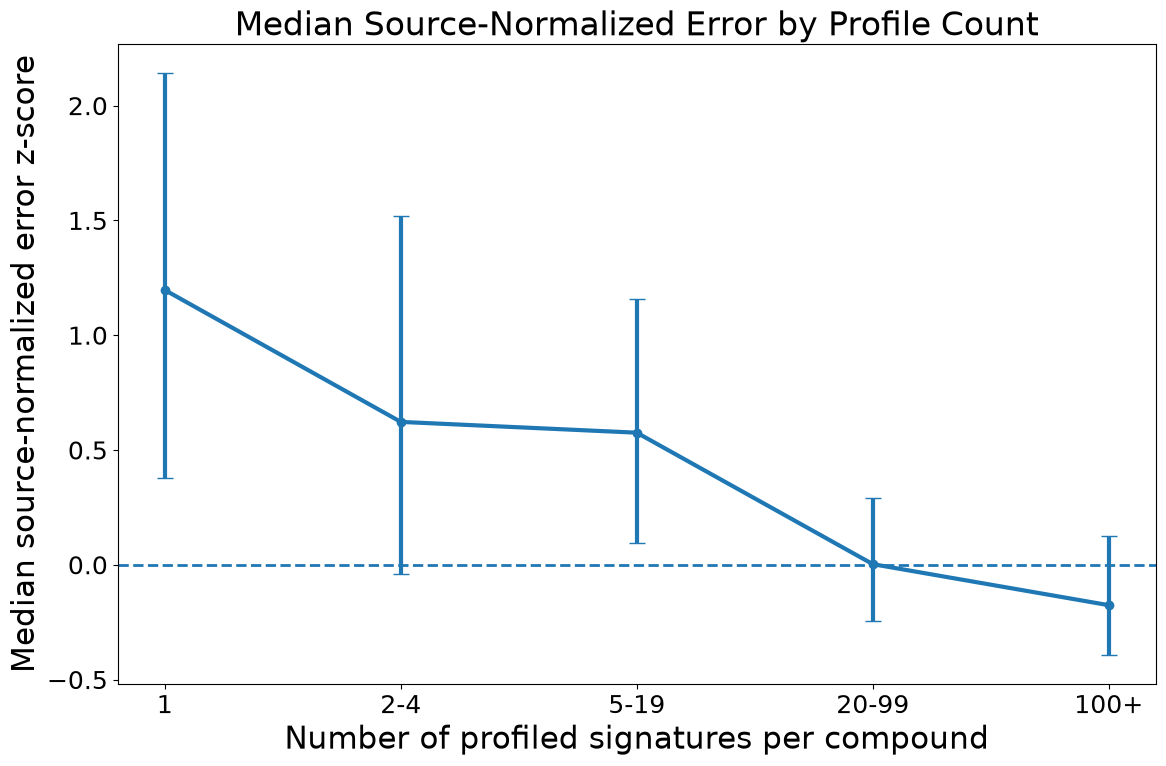

Saved: figures/step3_bowtie_autoencoder/step3_final256_median_source_normalized_error_iqr_by_profile_count_bin.png


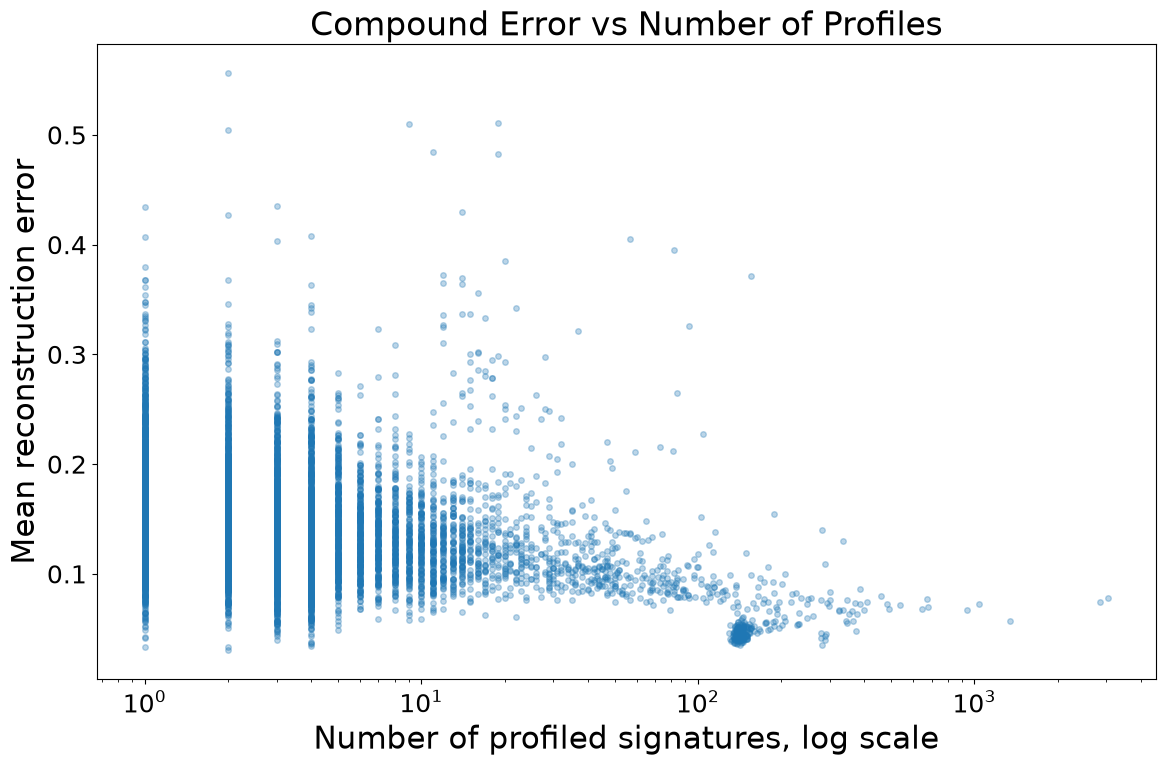

Saved: figures/step3_bowtie_autoencoder/step3_final256_mean_error_vs_n_profiles_logx.png


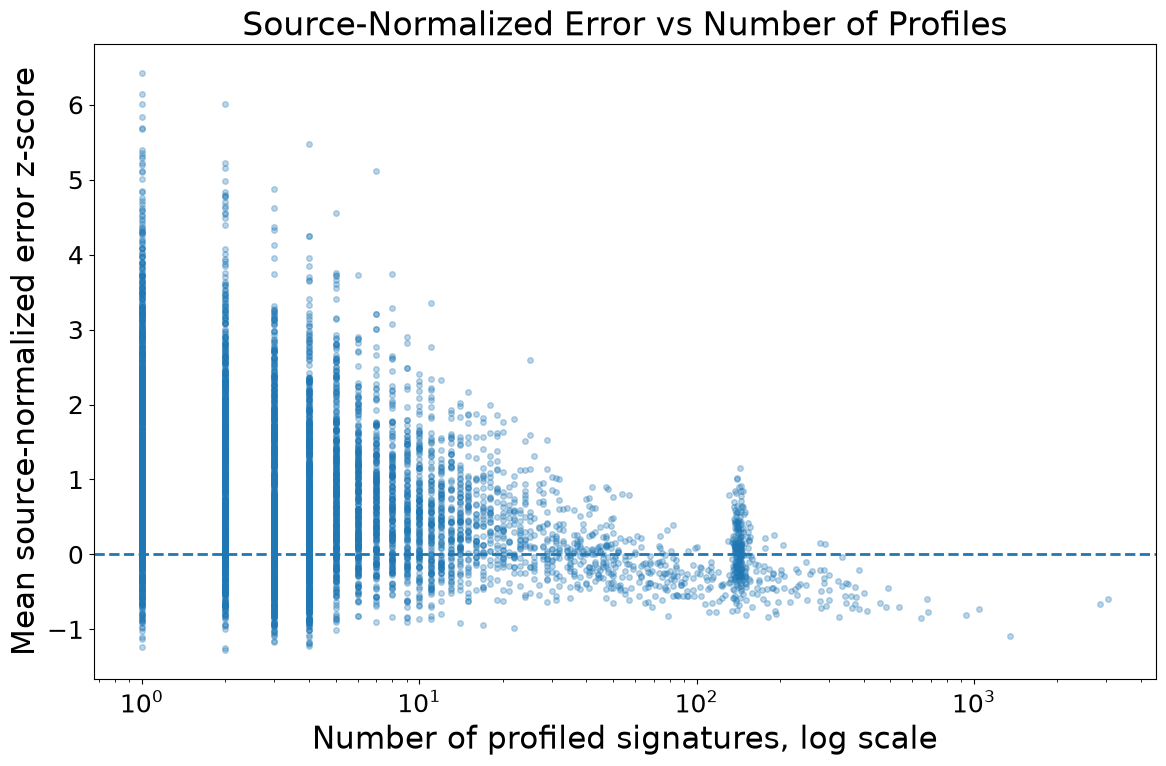

Saved: figures/step3_bowtie_autoencoder/step3_final256_source_normalized_error_vs_n_profiles_logx.png


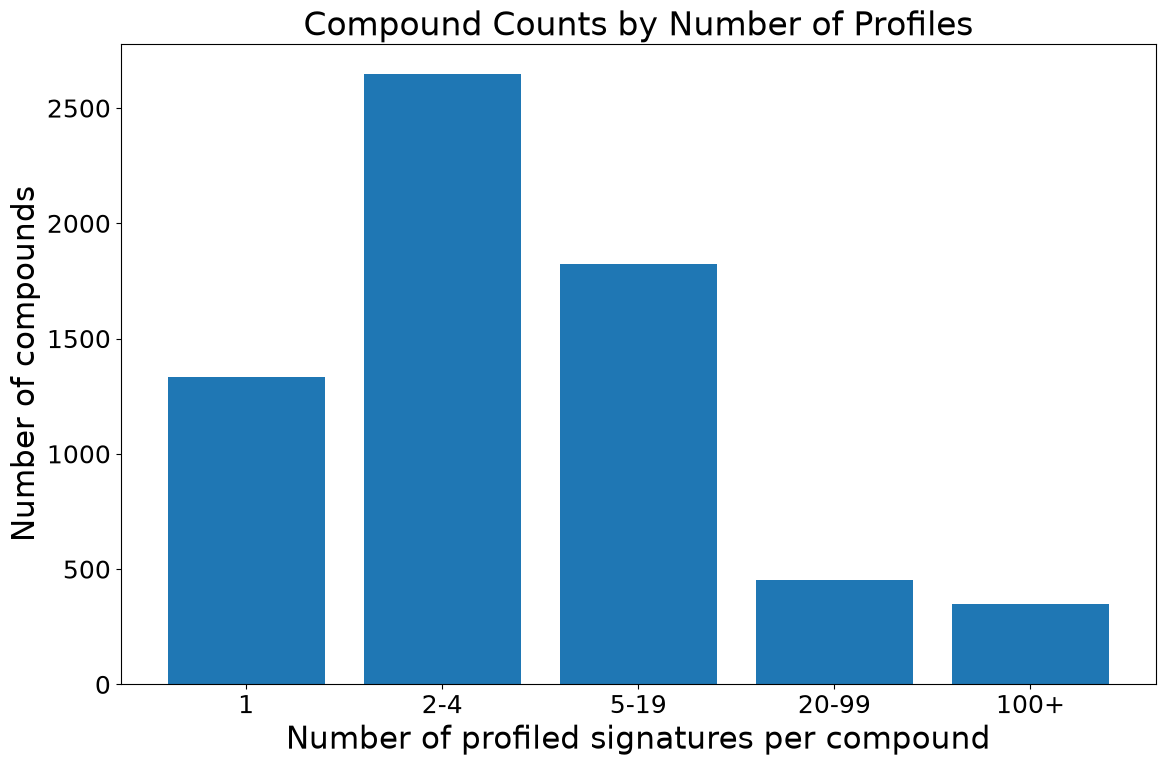

Saved: figures/step3_bowtie_autoencoder/step3_final256_compound_counts_by_profile_count_bin.png
Profile-count confound diagnostics plots complete.


In [16]:
# Continue profile-count confound diagnostics after boxplot labels error

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Reload if needed
compound_path = STEP3_DIR / "step3_compound_predictability_latent256_final_with_source_normalized.csv"
compound_pred = pd.read_csv(compound_path, low_memory=False)

bins = [0, 1, 4, 19, 99, np.inf]
labels = ["1", "2-4", "5-19", "20-99", "100+"]

compound_pred["profile_count_bin"] = pd.cut(
    compound_pred["n_profiles"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

profile_bin_summary_path = STEP3_DIR / "step3_final256_profile_count_confound_summary.csv"
profile_bin_summary = pd.read_csv(profile_bin_summary_path)

corr_path = STEP3_DIR / "step3_final256_profile_count_correlations.csv"
corr_summary = pd.read_csv(corr_path)

display(profile_bin_summary)
display(corr_summary)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# 1. Boxplot: raw mean error by profile-count bin

box_data = [
    compound_pred.loc[compound_pred["profile_count_bin"] == label, "mean_total_error"].dropna()
    for label in labels
]

plt.figure(figsize=(12, 8))
plt.boxplot(box_data, tick_labels=labels, showfliers=False)
plt.title("Compound Mean Error by Number of Profiles")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Mean reconstruction error")
save_show(FIG_DIR / "step3_final256_boxplot_mean_error_by_profile_count_bin.png")


# 2. Boxplot: source-normalized error by profile-count bin

box_data_norm = [
    compound_pred.loc[compound_pred["profile_count_bin"] == label, "mean_source_normalized_error_z"].dropna()
    for label in labels
]

plt.figure(figsize=(12, 8))
plt.boxplot(box_data_norm, tick_labels=labels, showfliers=False)
plt.axhline(0, linestyle="--", linewidth=2)
plt.title("Source-Normalized Error by Number of Profiles")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Mean source-normalized error z-score")
save_show(FIG_DIR / "step3_final256_boxplot_source_normalized_error_by_profile_count_bin.png")


# 3. Median raw error with IQR by profile-count bin

x = np.arange(len(profile_bin_summary))

plt.figure(figsize=(12, 8))
plt.errorbar(
    x,
    profile_bin_summary["median_error"],
    yerr=[
        profile_bin_summary["median_error"] - profile_bin_summary["q25_error"],
        profile_bin_summary["q75_error"] - profile_bin_summary["median_error"],
    ],
    marker="o",
    linewidth=3,
    capsize=6,
)
plt.xticks(x, profile_bin_summary["profile_count_bin"].astype(str))
plt.title("Median Compound Error Declines with More Profiles")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Median mean reconstruction error")
save_show(FIG_DIR / "step3_final256_median_error_iqr_by_profile_count_bin.png")


# 4. Median source-normalized error with IQR by profile-count bin

plt.figure(figsize=(12, 8))
plt.errorbar(
    x,
    profile_bin_summary["median_source_normalized_error"],
    yerr=[
        profile_bin_summary["median_source_normalized_error"] - profile_bin_summary["q25_source_normalized_error"],
        profile_bin_summary["q75_source_normalized_error"] - profile_bin_summary["median_source_normalized_error"],
    ],
    marker="o",
    linewidth=3,
    capsize=6,
)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xticks(x, profile_bin_summary["profile_count_bin"].astype(str))
plt.title("Median Source-Normalized Error by Profile Count")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Median source-normalized error z-score")
save_show(FIG_DIR / "step3_final256_median_source_normalized_error_iqr_by_profile_count_bin.png")


# 5. Scatter: mean error vs n_profiles with log x-axis

plt.figure(figsize=(12, 8))
plt.scatter(
    compound_pred["n_profiles"],
    compound_pred["mean_total_error"],
    s=16,
    alpha=0.3,
)
plt.xscale("log")
plt.title("Compound Error vs Number of Profiles")
plt.xlabel("Number of profiled signatures, log scale")
plt.ylabel("Mean reconstruction error")
save_show(FIG_DIR / "step3_final256_mean_error_vs_n_profiles_logx.png")


# 6. Scatter: source-normalized error vs n_profiles with log x-axis

plt.figure(figsize=(12, 8))
plt.scatter(
    compound_pred["n_profiles"],
    compound_pred["mean_source_normalized_error_z"],
    s=16,
    alpha=0.3,
)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xscale("log")
plt.title("Source-Normalized Error vs Number of Profiles")
plt.xlabel("Number of profiled signatures, log scale")
plt.ylabel("Mean source-normalized error z-score")
save_show(FIG_DIR / "step3_final256_source_normalized_error_vs_n_profiles_logx.png")


# 7. Compound counts by profile bin

plt.figure(figsize=(12, 8))
plt.bar(
    profile_bin_summary["profile_count_bin"].astype(str),
    profile_bin_summary["n_compounds"]
)
plt.title("Compound Counts by Number of Profiles")
plt.xlabel("Number of profiled signatures per compound")
plt.ylabel("Number of compounds")
save_show(FIG_DIR / "step3_final256_compound_counts_by_profile_count_bin.png")

print("Profile-count confound diagnostics plots complete.")

All compounds: (6605, 28)
n_profiles >= 20: (801, 28)
n_profiles >= 100: (349, 28)


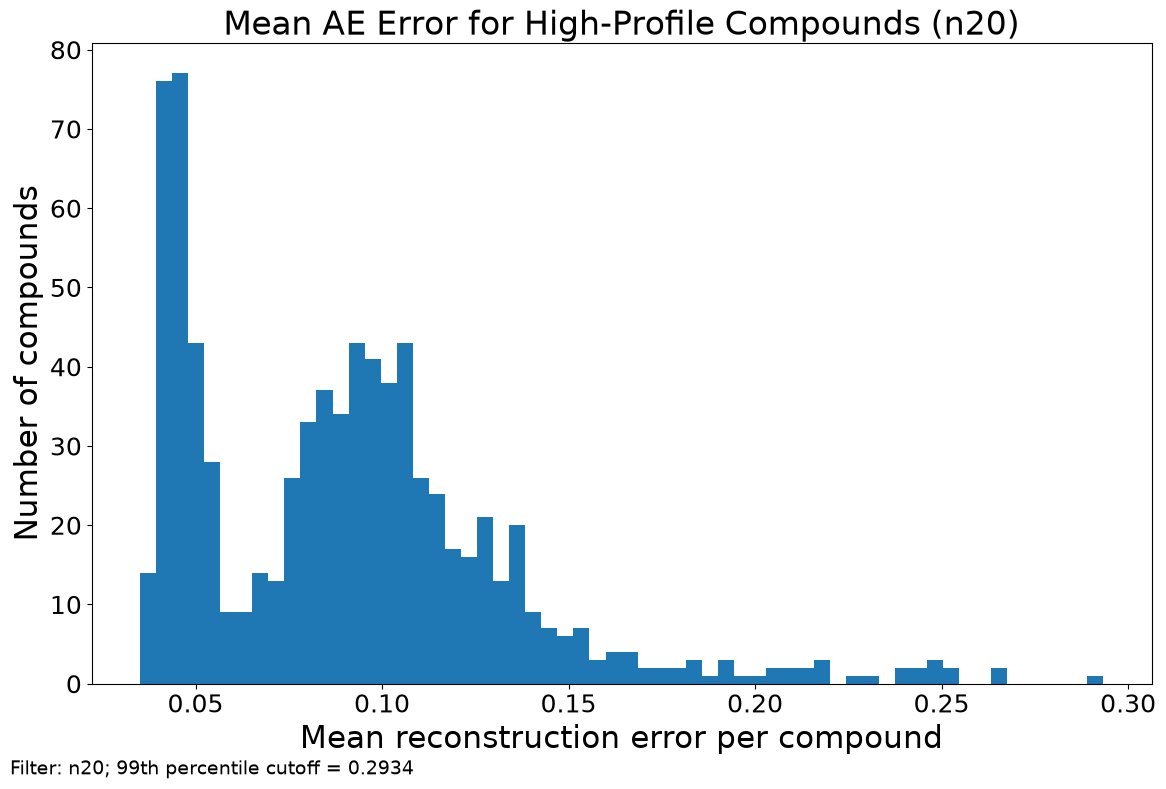

Saved: figures/step3_bowtie_autoencoder/step3_final256_highconf_n20_mean_error_histogram.png


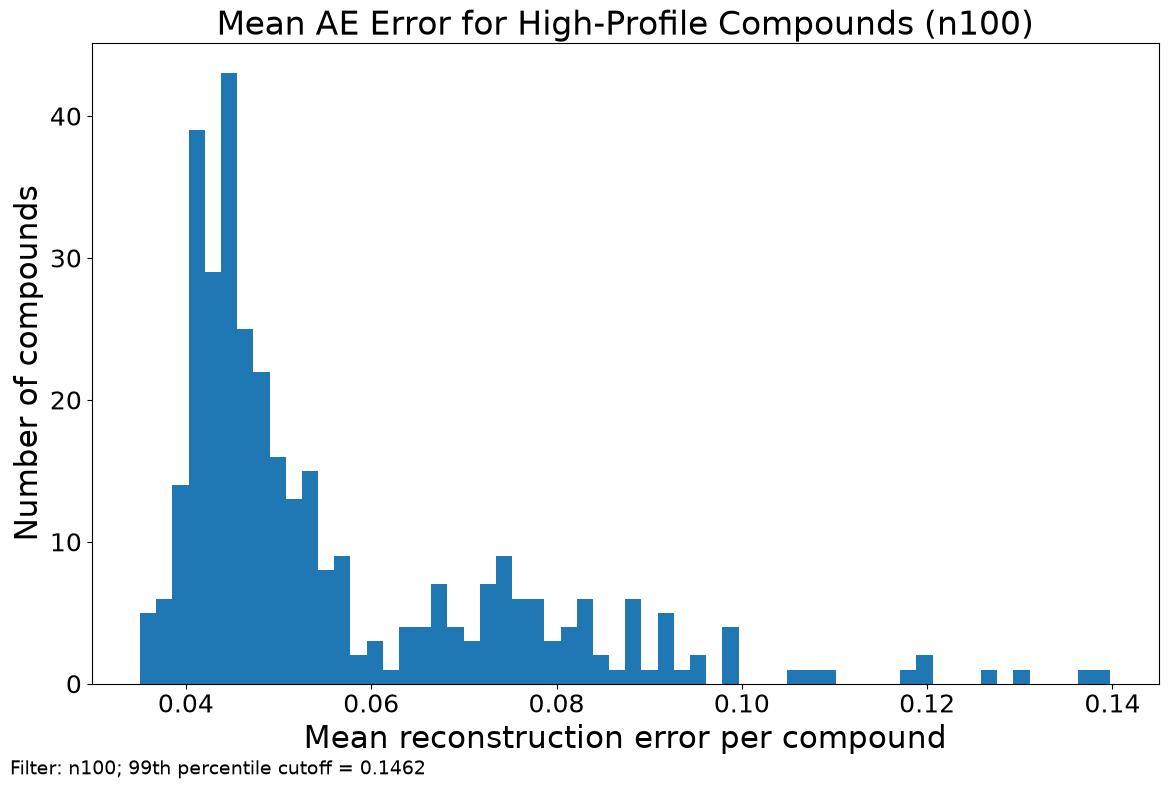

Saved: figures/step3_bowtie_autoencoder/step3_final256_highconf_n100_mean_error_histogram.png


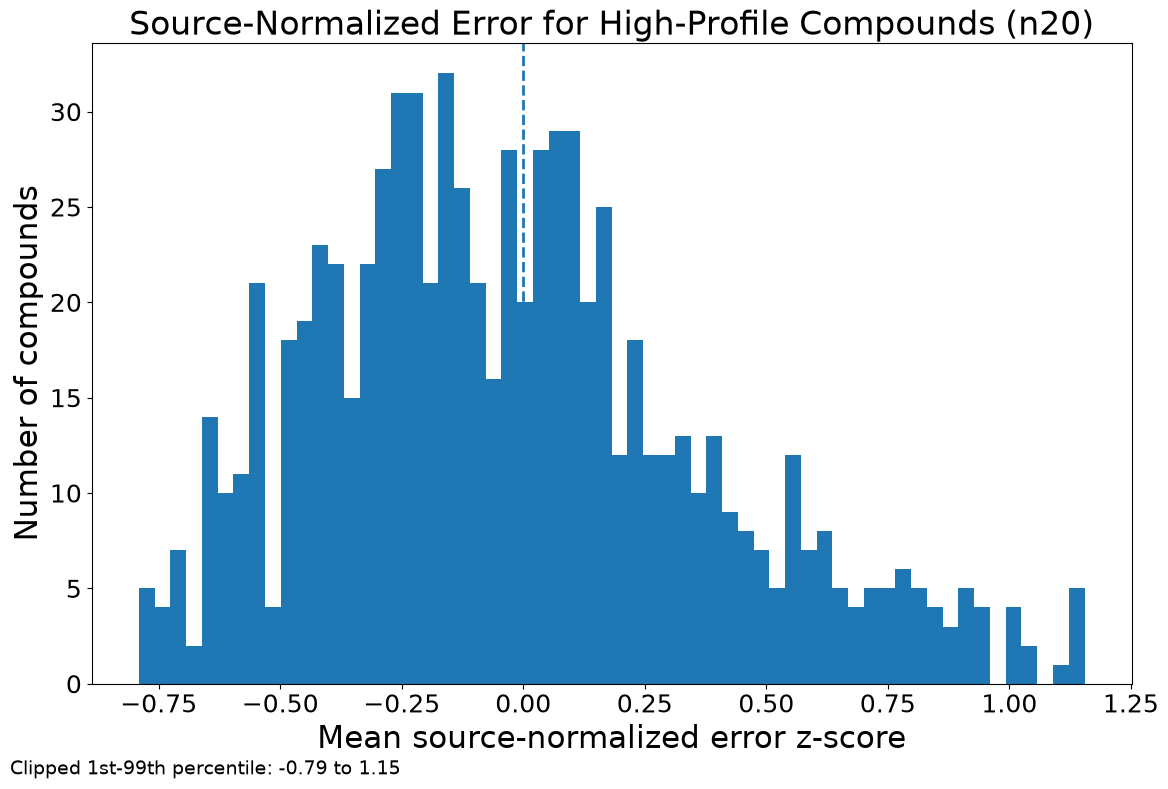

Saved: figures/step3_bowtie_autoencoder/step3_final256_highconf_n20_source_normalized_error_histogram.png


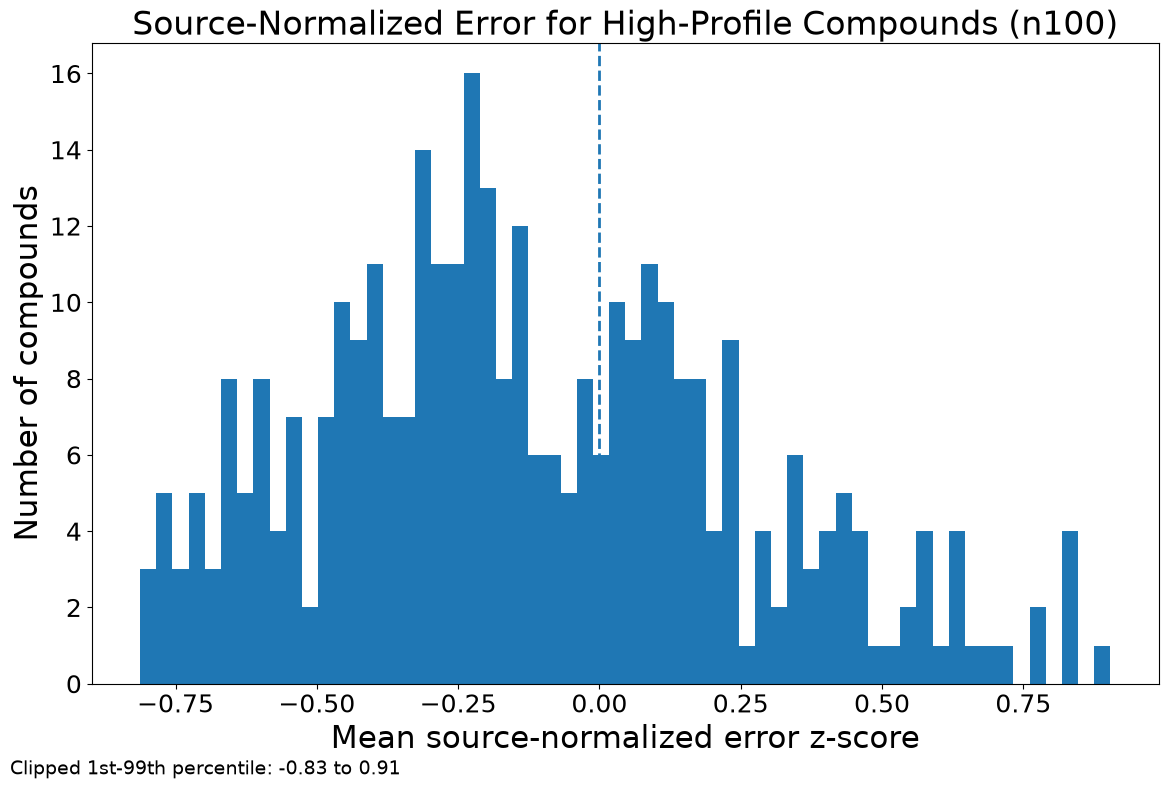

Saved: figures/step3_bowtie_autoencoder/step3_final256_highconf_n100_source_normalized_error_histogram.png


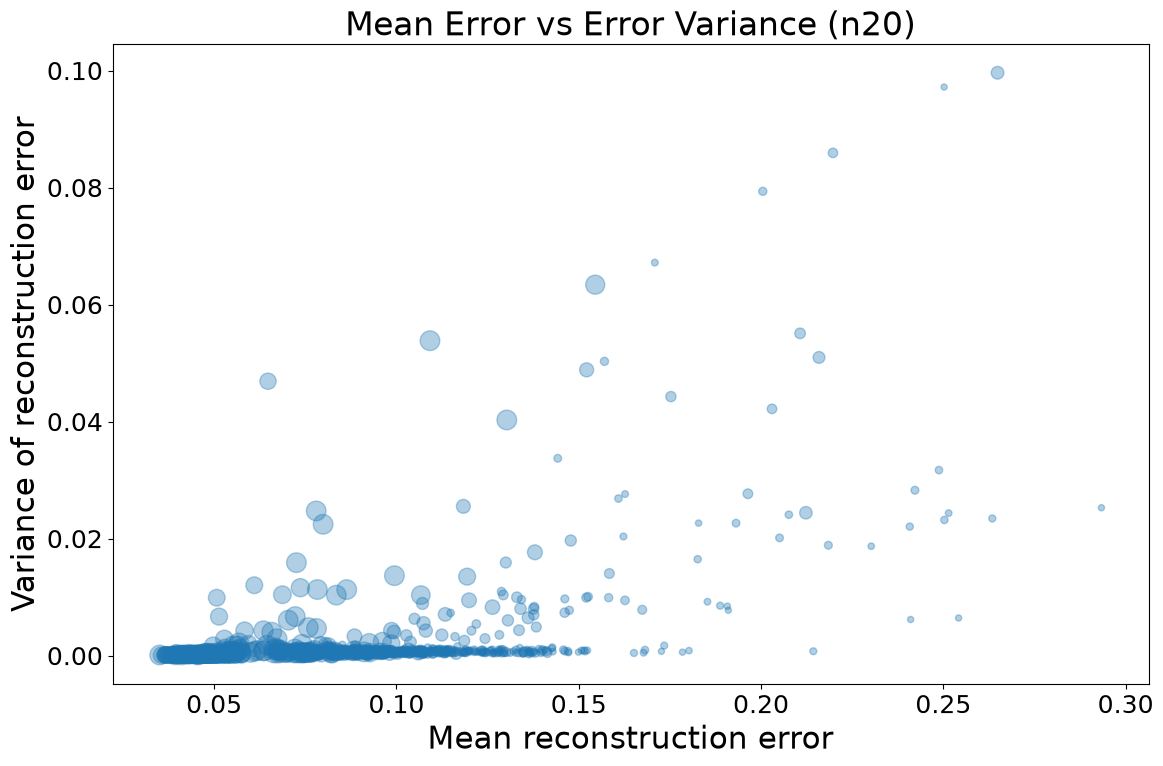

Saved: figures/step3_bowtie_autoencoder/step3_final256_highconf_n20_mean_error_vs_variance.png


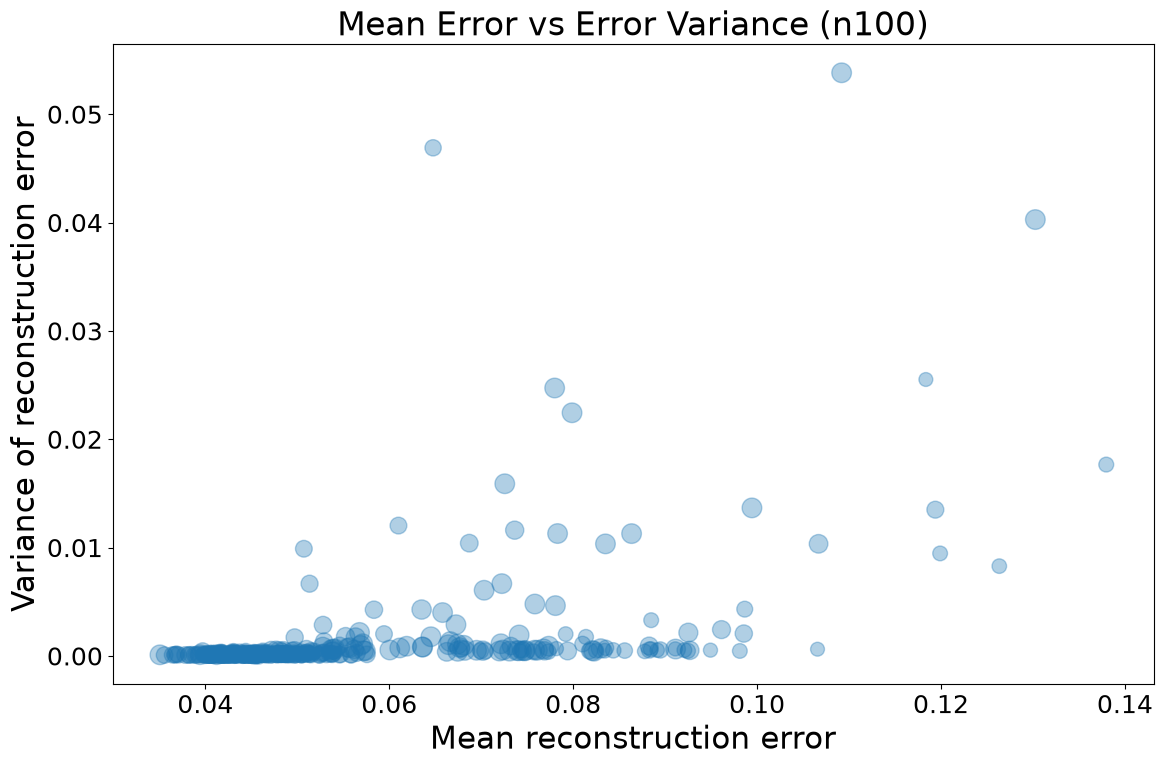

Saved: figures/step3_bowtie_autoencoder/step3_final256_highconf_n100_mean_error_vs_variance.png
Saved most_raw_n20: data/step3_multimodal/step3_final256_highconf_most_predictable_raw_n20.csv
Saved least_raw_n20: data/step3_multimodal/step3_final256_highconf_least_predictable_raw_n20.csv
Saved most_norm_n20: data/step3_multimodal/step3_final256_highconf_most_predictable_source_normalized_n20.csv
Saved least_norm_n20: data/step3_multimodal/step3_final256_highconf_least_predictable_source_normalized_n20.csv
Saved most_raw_n100: data/step3_multimodal/step3_final256_highconf_most_predictable_raw_n100.csv
Saved least_raw_n100: data/step3_multimodal/step3_final256_highconf_least_predictable_raw_n100.csv

Most predictable, raw error, n_profiles >= 20:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_source_normalized_error_z,variance_source_normalized_error_z,source_normalized_predictability_score
4,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.035060,0.000103,0.010144,0.033378,-0.719053,0.713194,0.974716
5,5134,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.035564,0.000080,0.008947,0.034380,-0.677140,0.554794,0.967298
7,5150,Doxycycline (monohydrate); Invertin,139,0.036430,0.000094,0.009709,0.036164,-0.605014,0.653283,0.953520
8,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.036665,0.000106,0.010287,0.034693,-0.585465,0.733423,0.949886
9,3111,Temuterkib,143,0.036769,0.000120,0.010969,0.035420,-0.576776,0.833880,0.948221
10,611,Silodosin,135,0.036897,0.000164,0.012812,0.034347,-0.586386,1.094434,0.950492
11,2020,Erdafitinib,138,0.037073,0.000097,0.009824,0.036361,-0.551491,0.668821,0.941559
13,5198,Mitoxantrone (dihydrochloride); Mitoxantrone H...,144,0.037803,0.000086,0.009274,0.036778,-0.490696,0.596115,0.929145
15,5181,Simotinib,135,0.038178,0.000084,0.009155,0.037471,-0.459517,0.580854,0.918547
16,3445,Bimiralisib,145,0.038226,0.000090,0.009480,0.038377,-0.455532,0.622792,0.917638



Least predictable, raw error, n_profiles >= 20:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_source_normalized_error_z,variance_source_normalized_error_z,source_normalized_predictability_score
6592,24002,Palmitic acid,57,0.405489,0.085353,0.292152,0.327945,0.206430,0.725394,0.644058
6590,3113,Talazoparib; talazoparib,82,0.395062,0.124098,0.352275,0.287813,0.387278,0.923121,0.569114
6589,1367,6-ethyl-3-[3-methoxy-4-[4-(4-methylpiperazin-1...,20,0.385302,0.104864,0.323827,0.253579,0.312637,0.899779,0.597729
6586,5116,cisplatin,155,0.371808,0.107791,0.328315,0.299193,0.189850,0.822539,0.650719
6569,21252,glutamine,22,0.342127,0.062105,0.249208,0.306490,0.010664,0.535421,0.734595
6555,3298,Nicotinamide; nicotinamide,93,0.326007,0.138007,0.371493,0.193111,0.043531,1.186315,0.719304
6548,3413,"(1R,2S)-Tranylcypromine; tranylcypromine",37,0.321604,0.064570,0.254106,0.263596,0.045184,0.615281,0.718698
6515,2508,"(8S,9S,10R,11S,13S,14R,17R)-11,17-dihydroxy-17...",28,0.297177,0.173164,0.416130,0.154525,0.118251,1.599685,0.682967
6506,2344,Eed226; N-(furan-2-ylmethyl)-8-(4-methylsulfon...,20,0.293354,0.025276,0.158984,0.275675,0.341265,1.141303,0.586374
6429,1403,"3-(diaminomethylidene)-1,1-dimethylguanidine; ...",84,0.264869,0.099618,0.315623,0.116079,-0.071337,0.952383,0.774565



Most predictable, source-normalized, n_profiles >= 20:


...


Most predictable, raw error, n_profiles >= 100:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_source_normalized_error_z,variance_source_normalized_error_z,source_normalized_predictability_score
4,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.035060,0.000103,0.010144,0.033378,-0.719053,0.713194,0.974716
5,5134,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.035564,0.000080,0.008947,0.034380,-0.677140,0.554794,0.967298
7,5150,Doxycycline (monohydrate); Invertin,139,0.036430,0.000094,0.009709,0.036164,-0.605014,0.653283,0.953520
8,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.036665,0.000106,0.010287,0.034693,-0.585465,0.733423,0.949886
9,3111,Temuterkib,143,0.036769,0.000120,0.010969,0.035420,-0.576776,0.833880,0.948221
10,611,Silodosin,135,0.036897,0.000164,0.012812,0.034347,-0.586386,1.094434,0.950492
11,2020,Erdafitinib,138,0.037073,0.000097,0.009824,0.036361,-0.551491,0.668821,0.941559
13,5198,Mitoxantrone (dihydrochloride); Mitoxantrone H...,144,0.037803,0.000086,0.009274,0.036778,-0.490696,0.596115,0.929145
15,5181,Simotinib,135,0.038178,0.000084,0.009155,0.037471,-0.459517,0.580854,0.918547
16,3445,Bimiralisib,145,0.038226,0.000090,0.009480,0.038377,-0.455532,0.622792,0.917638



Least predictable, raw error, n_profiles >= 100:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,std_total_error,median_total_error,mean_source_normalized_error_z,variance_source_normalized_error_z,source_normalized_predictability_score
6586,5116,cisplatin,155,0.371808,0.107791,0.328315,0.299193,0.189850,0.822539,0.650719
6159,2502,"(2Z,4S,4aR,5S,5aR,6R,12aS)-2-[amino(hydroxy)me...",104,0.227590,0.105212,0.324364,0.102436,-0.183216,0.918053,0.822710
4284,4724,sorafenib,189,0.154515,0.063401,0.251796,0.087395,-0.244007,0.710232,0.846934
4172,2028,Etoposide; etoposide,103,0.152150,0.048846,0.221011,0.081754,-0.431813,0.596293,0.909614
3578,2533,"(1S,9R,11S,14S,15S)-15-methyl-9-[9-(4,4,5,5,5-...",282,0.139784,1.345196,1.159826,0.046034,-0.484769,2.378187,0.927328
3498,639,4-Hydroxytamoxifen; tamoxifen,115,0.137968,0.017660,0.132891,0.089631,-0.297477,0.353634,0.868736
3072,251,Dexamethasone Acetate; dexamethasone,334,0.130257,0.040276,0.200688,0.061960,-0.039905,0.863546,0.758516
2830,3159,Ruxolitinib; ruxolitinib,110,0.126335,0.008287,0.091035,0.097080,-0.210967,0.355317,0.834217
2475,2781,Linifanib; linifanib,113,0.119902,0.009462,0.097271,0.088303,-0.172559,0.548965,0.817108
2447,99,Ibrutinib; ibrutinib,149,0.119383,0.013497,0.116175,0.095278,-0.165121,0.370134,0.812718


Saved interpretation summary: data/step3_multimodal/step3_final256_high_confidence_predictability_interpretation.txt
High-confidence analysis complete.


In [18]:
# Step 3 final 256D: high-confidence compound analysis
# Focuses on compounds with enough profiles to make mean/variance estimates more reliable.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

compound_path = STEP3_DIR / "step3_compound_predictability_latent256_final_with_source_normalized.csv"
compound_pred = pd.read_csv(compound_path, low_memory=False)

print("All compounds:", compound_pred.shape)

high20 = compound_pred[compound_pred["n_profiles"] >= 20].copy()
high100 = compound_pred[compound_pred["n_profiles"] >= 100].copy()

print("n_profiles >= 20:", high20.shape)
print("n_profiles >= 100:", high100.shape)

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

def clipped(s, q=0.99):
    s = s.dropna()
    cutoff = s.quantile(q)
    return s[s <= cutoff], cutoff


# 1. Mean error distribution for high-confidence compounds

for label, df in [("n20", high20), ("n100", high100)]:
    vals, cutoff = clipped(df["mean_total_error"], 0.99)

    plt.figure(figsize=(12, 8))
    plt.hist(vals, bins=60)
    plt.title(f"Mean AE Error for High-Profile Compounds ({label})")
    plt.xlabel("Mean reconstruction error per compound")
    plt.ylabel("Number of compounds")
    plt.figtext(0.02, 0.01, f"Filter: {label}; 99th percentile cutoff = {cutoff:.4f}", fontsize=14)
    save_show(FIG_DIR / f"step3_final256_highconf_{label}_mean_error_histogram.png")


# 2. Source-normalized error distribution for high-confidence compounds

for label, df in [("n20", high20), ("n100", high100)]:
    q01 = df["mean_source_normalized_error_z"].quantile(0.01)
    q99 = df["mean_source_normalized_error_z"].quantile(0.99)

    vals = df[
        (df["mean_source_normalized_error_z"] >= q01)
        & (df["mean_source_normalized_error_z"] <= q99)
    ]["mean_source_normalized_error_z"]

    plt.figure(figsize=(12, 8))
    plt.hist(vals.dropna(), bins=60)
    plt.axvline(0, linestyle="--", linewidth=2)
    plt.title(f"Source-Normalized Error for High-Profile Compounds ({label})")
    plt.xlabel("Mean source-normalized error z-score")
    plt.ylabel("Number of compounds")
    plt.figtext(0.02, 0.01, f"Clipped 1st-99th percentile: {q01:.2f} to {q99:.2f}", fontsize=14)
    save_show(FIG_DIR / f"step3_final256_highconf_{label}_source_normalized_error_histogram.png")


# 3. Mean error vs variance for high-confidence compounds

for label, df in [("n20", high20), ("n100", high100)]:
    mean_cut = df["mean_total_error"].quantile(0.99)
    var_cut = df["variance_total_error"].quantile(0.99)

    plot_df = df[
        (df["mean_total_error"] <= mean_cut)
        & (df["variance_total_error"] <= var_cut)
    ].copy()

    plt.figure(figsize=(12, 8))
    plt.scatter(
        plot_df["mean_total_error"],
        plot_df["variance_total_error"],
        s=np.clip(plot_df["n_profiles"], 20, 200),
        alpha=0.35,
    )
    plt.title(f"Mean Error vs Error Variance ({label})")
    plt.xlabel("Mean reconstruction error")
    plt.ylabel("Variance of reconstruction error")
    save_show(FIG_DIR / f"step3_final256_highconf_{label}_mean_error_vs_variance.png")


# 4. High-confidence rankings

rank_cols = [
    "compound_embedding_row_index",
    "compound_name",
    "n_profiles",
    "mean_total_error",
    "variance_total_error",
    "std_total_error",
    "median_total_error",
    "mean_source_normalized_error_z",
    "variance_source_normalized_error_z",
    "source_normalized_predictability_score",
]

rank_cols = [c for c in rank_cols if c in compound_pred.columns]

most_raw_n20 = high20.sort_values("mean_total_error", ascending=True)[rank_cols].head(30)
least_raw_n20 = high20.sort_values("mean_total_error", ascending=False)[rank_cols].head(30)

most_norm_n20 = high20.sort_values("mean_source_normalized_error_z", ascending=True)[rank_cols].head(30)
least_norm_n20 = high20.sort_values("mean_source_normalized_error_z", ascending=False)[rank_cols].head(30)

most_raw_n100 = high100.sort_values("mean_total_error", ascending=True)[rank_cols].head(30)
least_raw_n100 = high100.sort_values("mean_total_error", ascending=False)[rank_cols].head(30)

# Save ranking tables
paths = {
    "most_raw_n20": STEP3_DIR / "step3_final256_highconf_most_predictable_raw_n20.csv",
    "least_raw_n20": STEP3_DIR / "step3_final256_highconf_least_predictable_raw_n20.csv",
    "most_norm_n20": STEP3_DIR / "step3_final256_highconf_most_predictable_source_normalized_n20.csv",
    "least_norm_n20": STEP3_DIR / "step3_final256_highconf_least_predictable_source_normalized_n20.csv",
    "most_raw_n100": STEP3_DIR / "step3_final256_highconf_most_predictable_raw_n100.csv",
    "least_raw_n100": STEP3_DIR / "step3_final256_highconf_least_predictable_raw_n100.csv",
}

most_raw_n20.to_csv(paths["most_raw_n20"], index=False)
least_raw_n20.to_csv(paths["least_raw_n20"], index=False)
most_norm_n20.to_csv(paths["most_norm_n20"], index=False)
least_norm_n20.to_csv(paths["least_norm_n20"], index=False)
most_raw_n100.to_csv(paths["most_raw_n100"], index=False)
least_raw_n100.to_csv(paths["least_raw_n100"], index=False)

for name, path in paths.items():
    print(f"Saved {name}:", path)

print("\nMost predictable, raw error, n_profiles >= 20:")
display(most_raw_n20.head(20))

print("\nLeast predictable, raw error, n_profiles >= 20:")
display(least_raw_n20.head(20))

print("\nMost predictable, source-normalized, n_profiles >= 20:")
display(most_norm_n20.head(20))

print("\nLeast predictable, source-normalized, n_profiles >= 20:")
display(least_norm_n20.head(20))

print("\nMost predictable, raw error, n_profiles >= 100:")
display(most_raw_n100.head(20))

print("\nLeast predictable, raw error, n_profiles >= 100:")
display(least_raw_n100.head(20))


# 5. Save written interpretation summary

summary_path = STEP3_DIR / "step3_final256_high_confidence_predictability_interpretation.txt"

with open(summary_path, "w") as f:
    f.write("Step 3 final 256D high-confidence predictability interpretation\n")
    f.write("==============================================================\n\n")
    f.write(f"Total compounds: {len(compound_pred)}\n")
    f.write(f"Compounds with n_profiles >= 20: {len(high20)}\n")
    f.write(f"Compounds with n_profiles >= 100: {len(high100)}\n\n")

    f.write("Main interpretation:\n")
    f.write("- Compound-level reconstruction error varies meaningfully across compounds.\n")
    f.write("- Compounds with more profiled signatures tend to have lower mean reconstruction error.\n")
    f.write("- This profile-count relationship remains even after source normalization.\n")
    f.write("- Therefore, raw predictability rankings should be interpreted cautiously.\n")
    f.write("- More reliable rankings should filter or stratify by n_profiles and consider source-normalized error.\n\n")

    f.write("Recommended high-confidence filters:\n")
    f.write("- n_profiles >= 20 for broader high-confidence analysis.\n")
    f.write("- n_profiles >= 100 for stricter, well-profiled compound analysis.\n\n")

    f.write("Most predictable compounds, raw error, n_profiles >= 20:\n")
    f.write(most_raw_n20.head(20).to_string(index=False))
    f.write("\n\nLeast predictable compounds, raw error, n_profiles >= 20:\n")
    f.write(least_raw_n20.head(20).to_string(index=False))
    f.write("\n\nMost predictable compounds, source-normalized, n_profiles >= 20:\n")
    f.write(most_norm_n20.head(20).to_string(index=False))
    f.write("\n\nLeast predictable compounds, source-normalized, n_profiles >= 20:\n")
    f.write(least_norm_n20.head(20).to_string(index=False))

print("Saved interpretation summary:", summary_path)
print("High-confidence analysis complete.")

Compound table: (6605, 28)
Saved updated score table: data/step3_multimodal/step3_compound_predictability_latent256_final_scores.csv


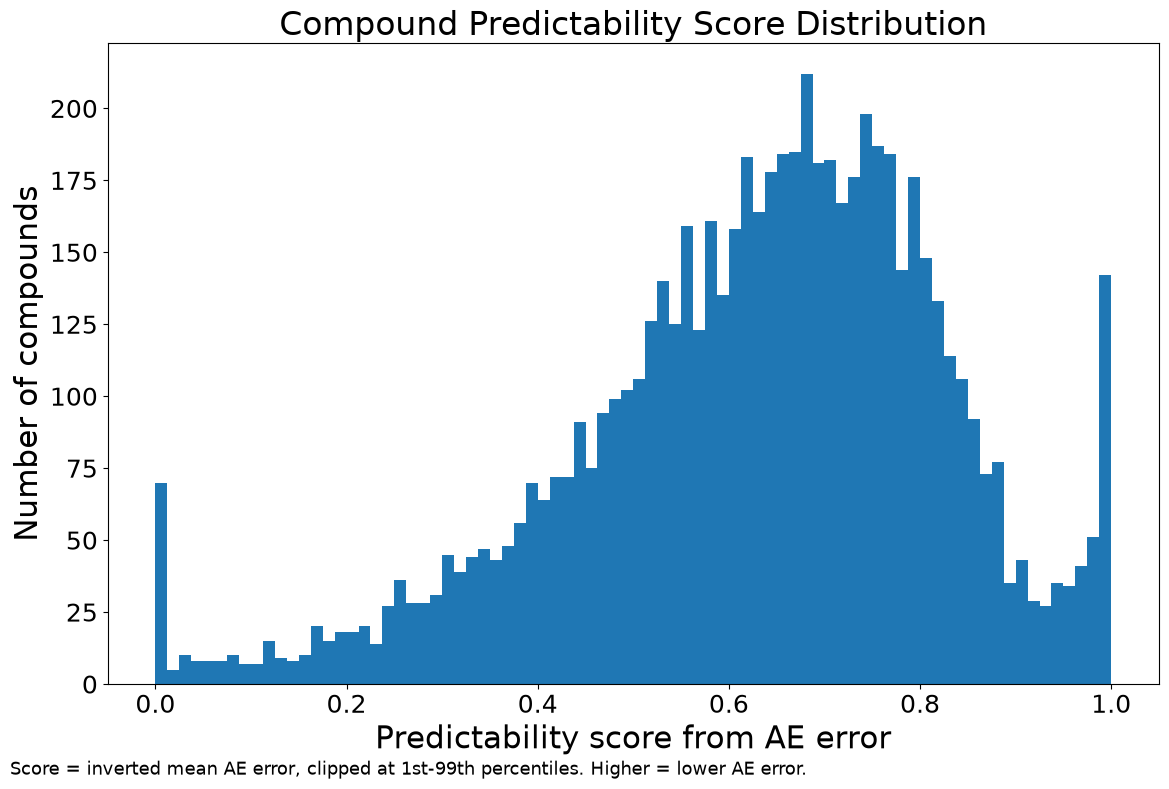

Saved: figures/step3_bowtie_autoencoder/step3_final256_predictability_score_raw_inverted_distribution.png


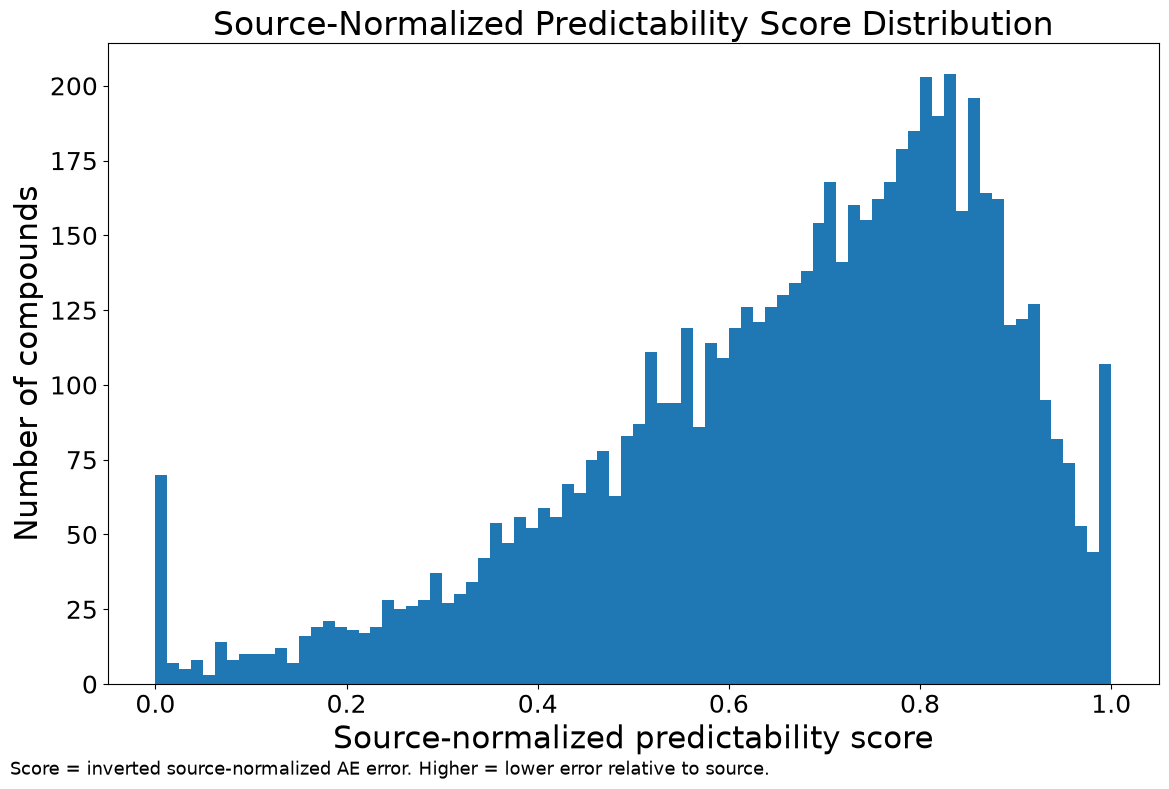

Saved: figures/step3_bowtie_autoencoder/step3_final256_source_normalized_predictability_score_distribution.png


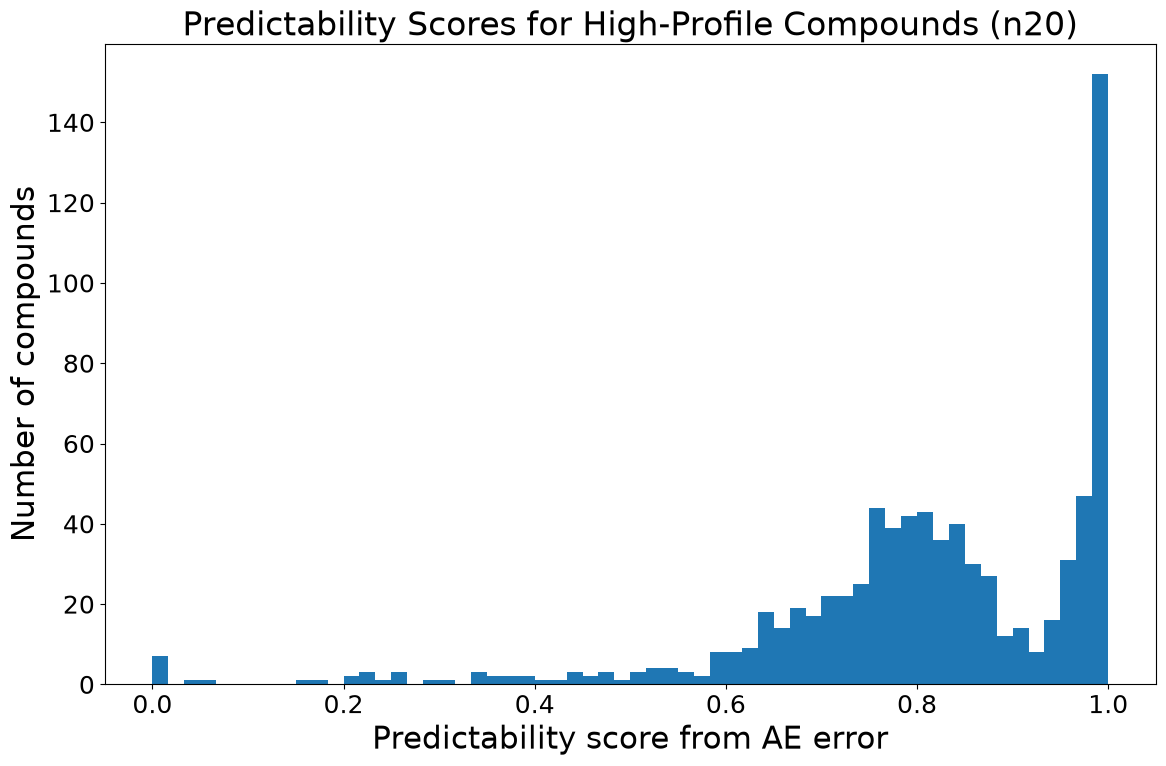

Saved: figures/step3_bowtie_autoencoder/step3_final256_predictability_score_highconf_n20.png


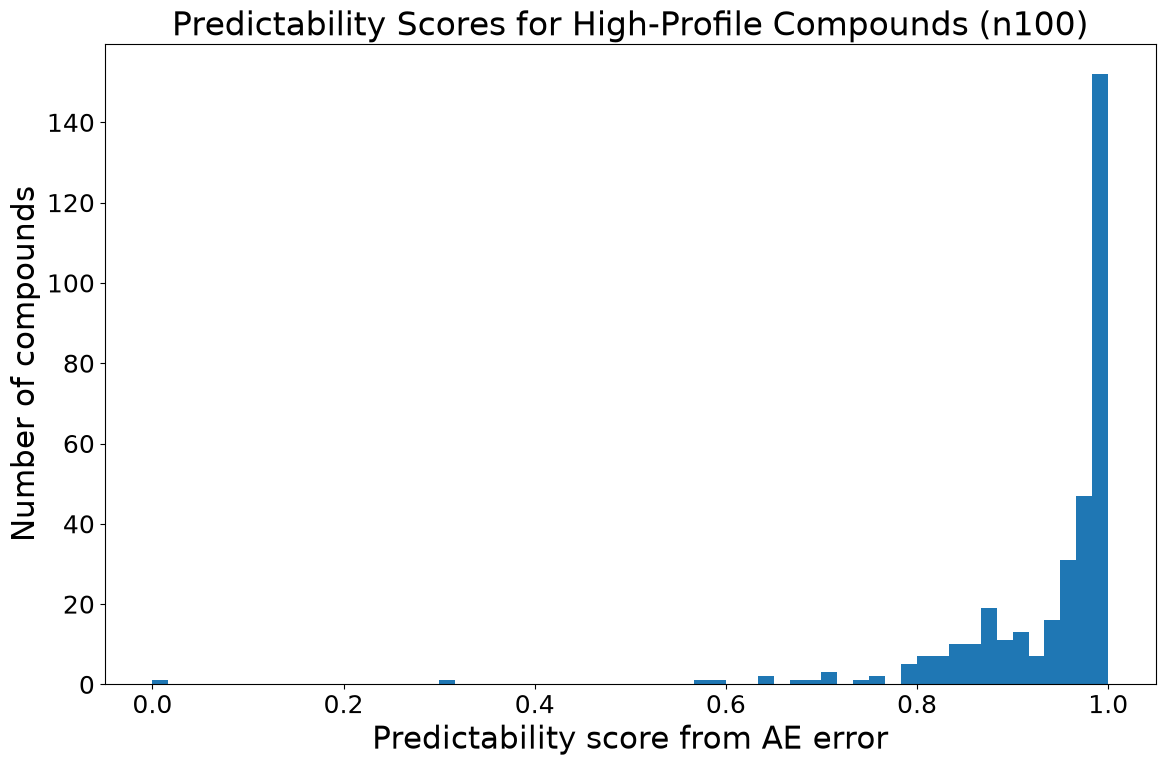

Saved: figures/step3_bowtie_autoencoder/step3_final256_predictability_score_highconf_n100.png


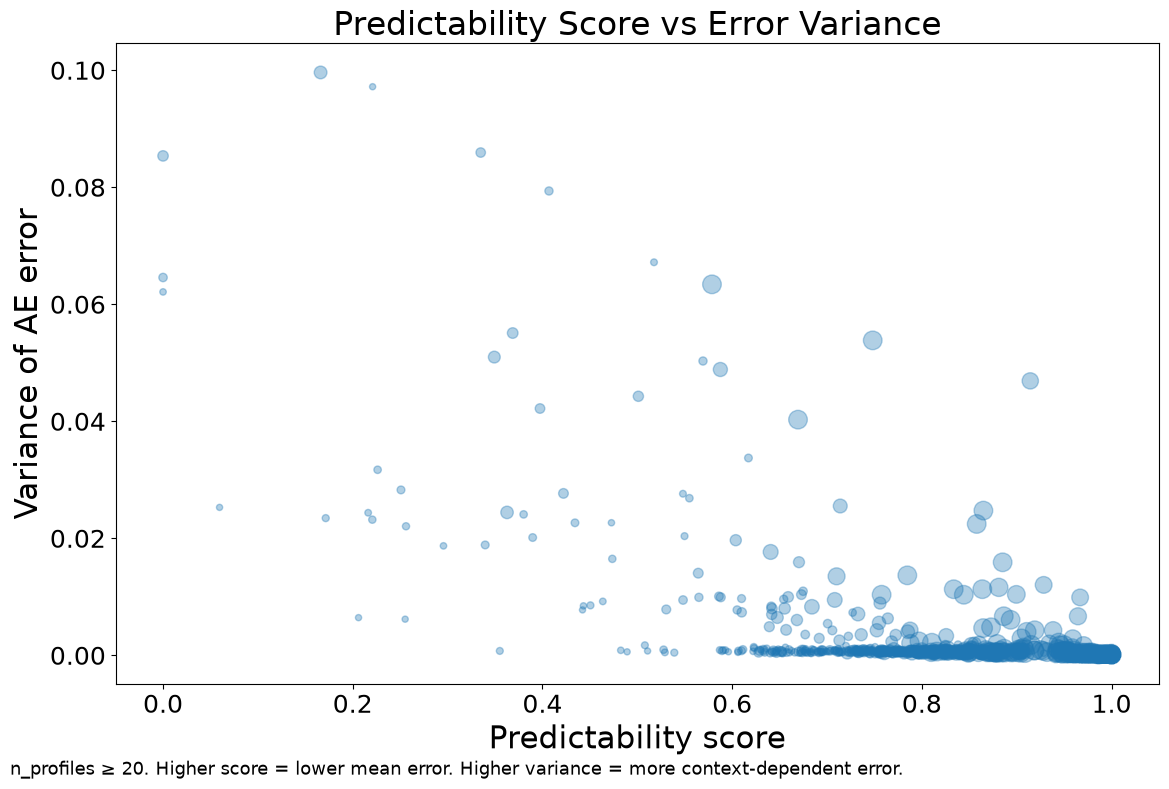

Saved: figures/step3_bowtie_autoencoder/step3_final256_predictability_score_vs_error_variance_n20.png


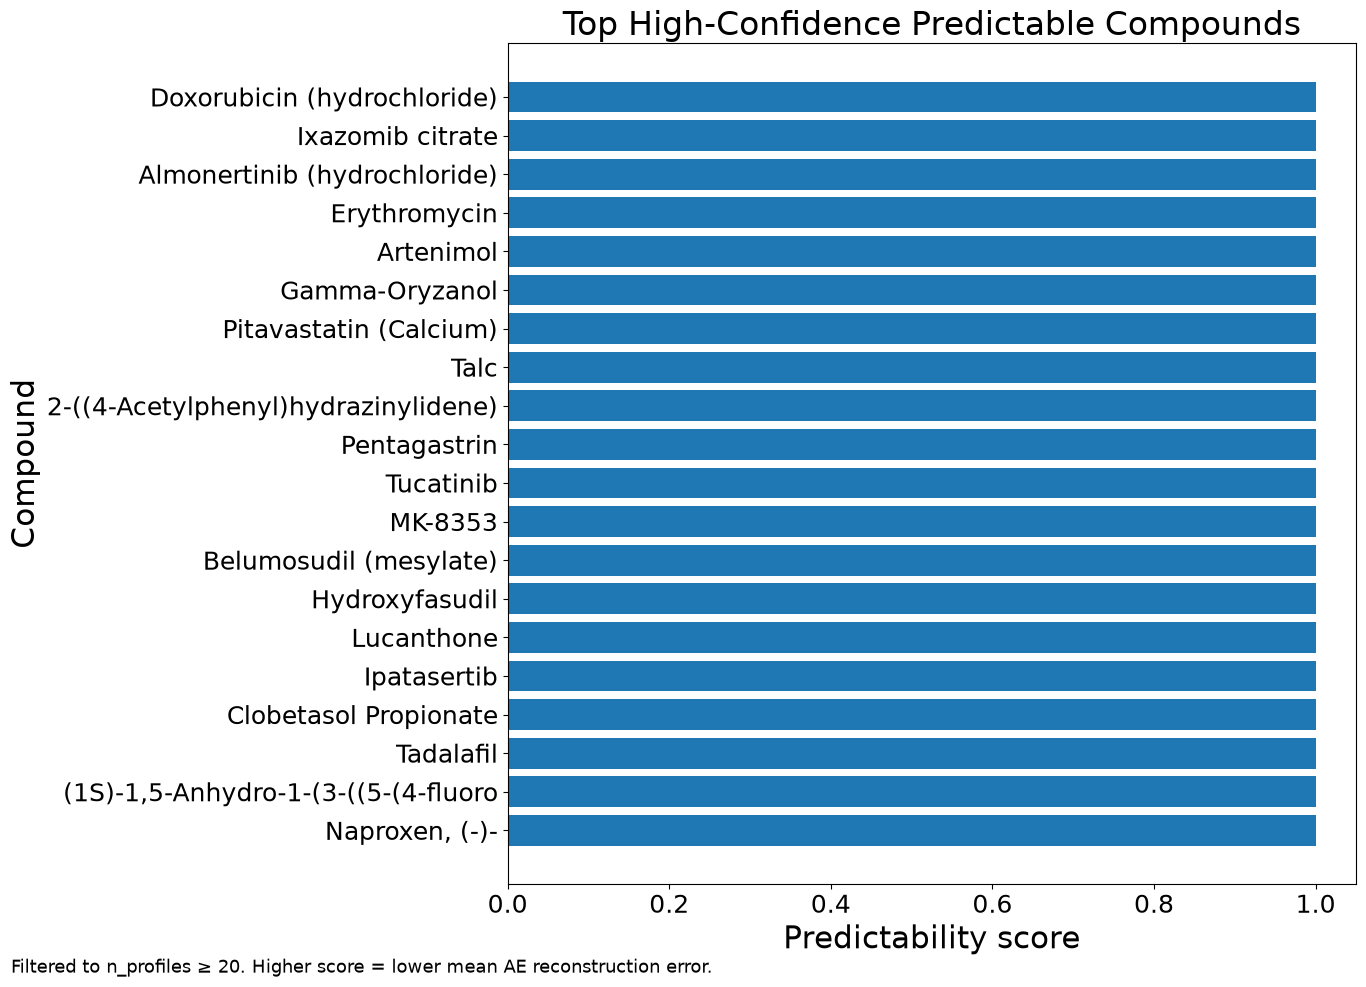

Saved: figures/step3_bowtie_autoencoder/step3_final256_top20_highconf_predictability_scores.png


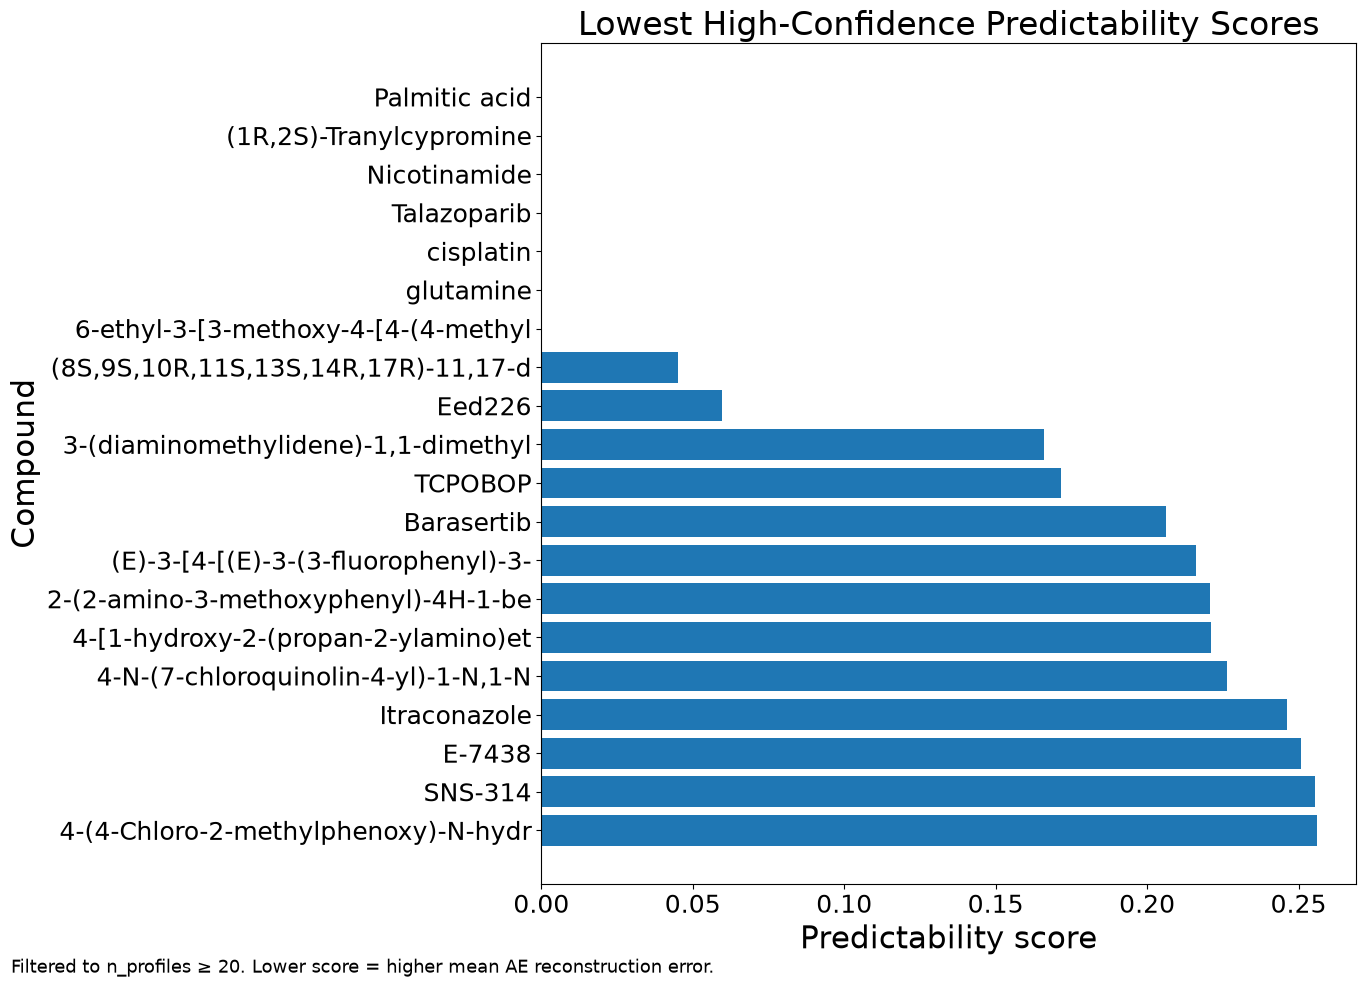

Saved: figures/step3_bowtie_autoencoder/step3_final256_bottom20_highconf_predictability_scores.png
Saved report table: data/step3_multimodal/step3_final256_predictability_scores_report_table.csv

Top high-confidence compounds:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,raw_error_inverted_score,mean_source_normalized_error_z,source_normalized_inverted_score,predictability_score,source_normalized_predictability_score
4,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.035060,0.000103,1.0,-0.719053,0.969265,0.999243,0.974716
53,430,Ixazomib citrate,143,0.041292,0.000139,1.0,-0.200301,0.864661,0.991824,0.830583
40,5132,Almonertinib (hydrochloride); HS-10296 hydroch...,145,0.040684,0.000120,1.0,-0.250880,0.874860,0.993793,0.850114
41,791,Erythromycin,151,0.040736,0.000198,1.0,-0.432420,0.911467,0.993641,0.909917
42,5280,Artenimol; Dihydroartemisinin,143,0.040785,0.000119,1.0,-0.251217,0.874928,0.993490,0.850416
43,5524,Gamma-Oryzanol; γ-Oryzanol,138,0.040847,0.000113,1.0,-0.237314,0.872124,0.993338,0.843906
44,5217,Pitavastatin (Calcium); Pitavastatin Calcium,142,0.040864,0.000100,1.0,-0.235928,0.871845,0.993187,0.842998
45,5539,Talc,140,0.040880,0.000084,1.0,-0.234534,0.871563,0.993036,0.842695
46,5515,"2-((4-Acetylphenyl)hydrazinylidene)-2-(3,3-dim...",140,0.040886,0.000113,1.0,-0.234074,0.871471,0.992884,0.842392
47,2355,Pentagastrin,144,0.041014,0.000140,1.0,-0.223399,0.869318,0.992733,0.838304



Lowest high-confidence compounds:


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,raw_error_inverted_score,mean_source_normalized_error_z,source_normalized_inverted_score,predictability_score,source_normalized_predictability_score
6592,24002,Palmitic acid,57,0.405489,0.085353,0.000000,0.206430,0.782645,0.001817,0.644058
6548,3413,"(1R,2S)-Tranylcypromine; tranylcypromine",37,0.321604,0.064570,0.000000,0.045184,0.815159,0.008478,0.718698
6555,3298,Nicotinamide; nicotinamide,93,0.326007,0.138007,0.000000,0.043531,0.815493,0.007419,0.719304
6590,3113,Talazoparib; talazoparib,82,0.395062,0.124098,0.000000,0.387278,0.746177,0.002120,0.569114
6586,5116,cisplatin,155,0.371808,0.107791,0.000000,0.189850,0.785988,0.002725,0.650719
6569,21252,glutamine,22,0.342127,0.062105,0.000000,0.010664,0.822120,0.005299,0.734595
6589,1367,6-ethyl-3-[3-methoxy-4-[4-(4-methylpiperazin-1...,20,0.385302,0.104864,0.000000,0.312637,0.761228,0.002271,0.597729
6515,2508,"(8S,9S,10R,11S,13S,14R,17R)-11,17-dihydroxy-17...",28,0.297177,0.173164,0.045288,0.118251,0.800426,0.013475,0.682967
6506,2344,Eed226; N-(furan-2-ylmethyl)-8-(4-methylsulfon...,20,0.293354,0.025276,0.059582,0.341265,0.755456,0.014837,0.586374
6429,1403,"3-(diaminomethylidene)-1,1-dimethylguanidine; ...",84,0.264869,0.099618,0.166093,-0.071337,0.838655,0.026495,0.774565


Predictability score plots complete.


In [19]:
# Step 3 final 256D: clearer predictability score plots

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

FIG_DIR.mkdir(parents=True, exist_ok=True)

compound_path = STEP3_DIR / "step3_compound_predictability_latent256_final_with_source_normalized.csv"
compound_pred = pd.read_csv(compound_path, low_memory=False)

print("Compound table:", compound_pred.shape)


# Create a raw, non-percentile score too

# Percentile score is useful for ranking but has a flat distribution by construction.
# This robust score shows the actual shape of the error distribution.
err = compound_pred["mean_total_error"].copy()

q01 = err.quantile(0.01)
q99 = err.quantile(0.99)

err_clipped = err.clip(lower=q01, upper=q99)

compound_pred["raw_error_inverted_score"] = 1 - (
    (err_clipped - err_clipped.min()) / (err_clipped.max() - err_clipped.min())
)

# Source-normalized robust score
sn = compound_pred["mean_source_normalized_error_z"].copy()

sn_q01 = sn.quantile(0.01)
sn_q99 = sn.quantile(0.99)

sn_clipped = sn.clip(lower=sn_q01, upper=sn_q99)

compound_pred["source_normalized_inverted_score"] = 1 - (
    (sn_clipped - sn_clipped.min()) / (sn_clipped.max() - sn_clipped.min())
)

# Save updated score table
score_path = STEP3_DIR / "step3_compound_predictability_latent256_final_scores.csv"
compound_pred.to_csv(score_path, index=False)
print("Saved updated score table:", score_path)


# Plot settings

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# 1. Raw inverted predictability score distribution

plt.figure(figsize=(12, 8))
plt.hist(compound_pred["raw_error_inverted_score"].dropna(), bins=80)
plt.title("Compound Predictability Score Distribution")
plt.xlabel("Predictability score from AE error")
plt.ylabel("Number of compounds")
plt.figtext(
    0.02,
    0.01,
    "Score = inverted mean AE error, clipped at 1st-99th percentiles. Higher = lower AE error.",
    fontsize=13
)
save_show(FIG_DIR / "step3_final256_predictability_score_raw_inverted_distribution.png")


# 2. Source-normalized predictability score distribution

plt.figure(figsize=(12, 8))
plt.hist(compound_pred["source_normalized_inverted_score"].dropna(), bins=80)
plt.title("Source-Normalized Predictability Score Distribution")
plt.xlabel("Source-normalized predictability score")
plt.ylabel("Number of compounds")
plt.figtext(
    0.02,
    0.01,
    "Score = inverted source-normalized AE error. Higher = lower error relative to source.",
    fontsize=13
)
save_show(FIG_DIR / "step3_final256_source_normalized_predictability_score_distribution.png")


# 3. High-confidence score distribution

high20 = compound_pred[compound_pred["n_profiles"] >= 20].copy()
high100 = compound_pred[compound_pred["n_profiles"] >= 100].copy()

for label, df in [("n20", high20), ("n100", high100)]:
    plt.figure(figsize=(12, 8))
    plt.hist(df["raw_error_inverted_score"].dropna(), bins=60)
    plt.title(f"Predictability Scores for High-Profile Compounds ({label})")
    plt.xlabel("Predictability score from AE error")
    plt.ylabel("Number of compounds")
    save_show(FIG_DIR / f"step3_final256_predictability_score_highconf_{label}.png")


# 4. Predictability score vs error variance

plot_df = high20.copy()

# clip variance for readability
var_cut = plot_df["variance_total_error"].quantile(0.99)
plot_df = plot_df[plot_df["variance_total_error"] <= var_cut]

plt.figure(figsize=(12, 8))
plt.scatter(
    plot_df["raw_error_inverted_score"],
    plot_df["variance_total_error"],
    s=np.clip(plot_df["n_profiles"], 20, 180),
    alpha=0.35,
)
plt.title("Predictability Score vs Error Variance")
plt.xlabel("Predictability score")
plt.ylabel("Variance of AE error")
plt.figtext(
    0.02,
    0.01,
    "n_profiles ≥ 20. Higher score = lower mean error. Higher variance = more context-dependent error.",
    fontsize=13
)
save_show(FIG_DIR / "step3_final256_predictability_score_vs_error_variance_n20.png")


# 5. Top 20 high-confidence predictable compounds

top20 = (
    high20
    .sort_values("raw_error_inverted_score", ascending=False)
    .head(20)
    .copy()
)

# shorten names for plotting
top20["compound_label"] = (
    top20["compound_name"]
    .astype(str)
    .str.replace(r";.*", "", regex=True)
    .str.slice(0, 35)
)

plt.figure(figsize=(14, 10))
plt.barh(top20["compound_label"][::-1], top20["raw_error_inverted_score"][::-1])
plt.title("Top High-Confidence Predictable Compounds")
plt.xlabel("Predictability score")
plt.ylabel("Compound")
plt.figtext(
    0.02,
    0.01,
    "Filtered to n_profiles ≥ 20. Higher score = lower mean AE reconstruction error.",
    fontsize=13
)
save_show(FIG_DIR / "step3_final256_top20_highconf_predictability_scores.png")


# 6. Bottom 20 high-confidence predictable compounds

bottom20 = (
    high20
    .sort_values("raw_error_inverted_score", ascending=True)
    .head(20)
    .copy()
)

bottom20["compound_label"] = (
    bottom20["compound_name"]
    .astype(str)
    .str.replace(r";.*", "", regex=True)
    .str.slice(0, 35)
)

plt.figure(figsize=(14, 10))
plt.barh(bottom20["compound_label"][::-1], bottom20["raw_error_inverted_score"][::-1])
plt.title("Lowest High-Confidence Predictability Scores")
plt.xlabel("Predictability score")
plt.ylabel("Compound")
plt.figtext(
    0.02,
    0.01,
    "Filtered to n_profiles ≥ 20. Lower score = higher mean AE reconstruction error.",
    fontsize=13
)
save_show(FIG_DIR / "step3_final256_bottom20_highconf_predictability_scores.png")


# Save final summary table for report

summary_cols = [
    "compound_embedding_row_index",
    "compound_name",
    "n_profiles",
    "mean_total_error",
    "variance_total_error",
    "raw_error_inverted_score",
    "mean_source_normalized_error_z",
    "source_normalized_inverted_score",
    "predictability_score",
    "source_normalized_predictability_score",
]

summary_cols = [c for c in summary_cols if c in compound_pred.columns]

report_table = compound_pred[summary_cols].copy()

report_path = STEP3_DIR / "step3_final256_predictability_scores_report_table.csv"
report_table.to_csv(report_path, index=False)

print("Saved report table:", report_path)

print("\nTop high-confidence compounds:")
display(top20[summary_cols].head(20))

print("\nLowest high-confidence compounds:")
display(bottom20[summary_cols].head(20))

print("Predictability score plots complete.")

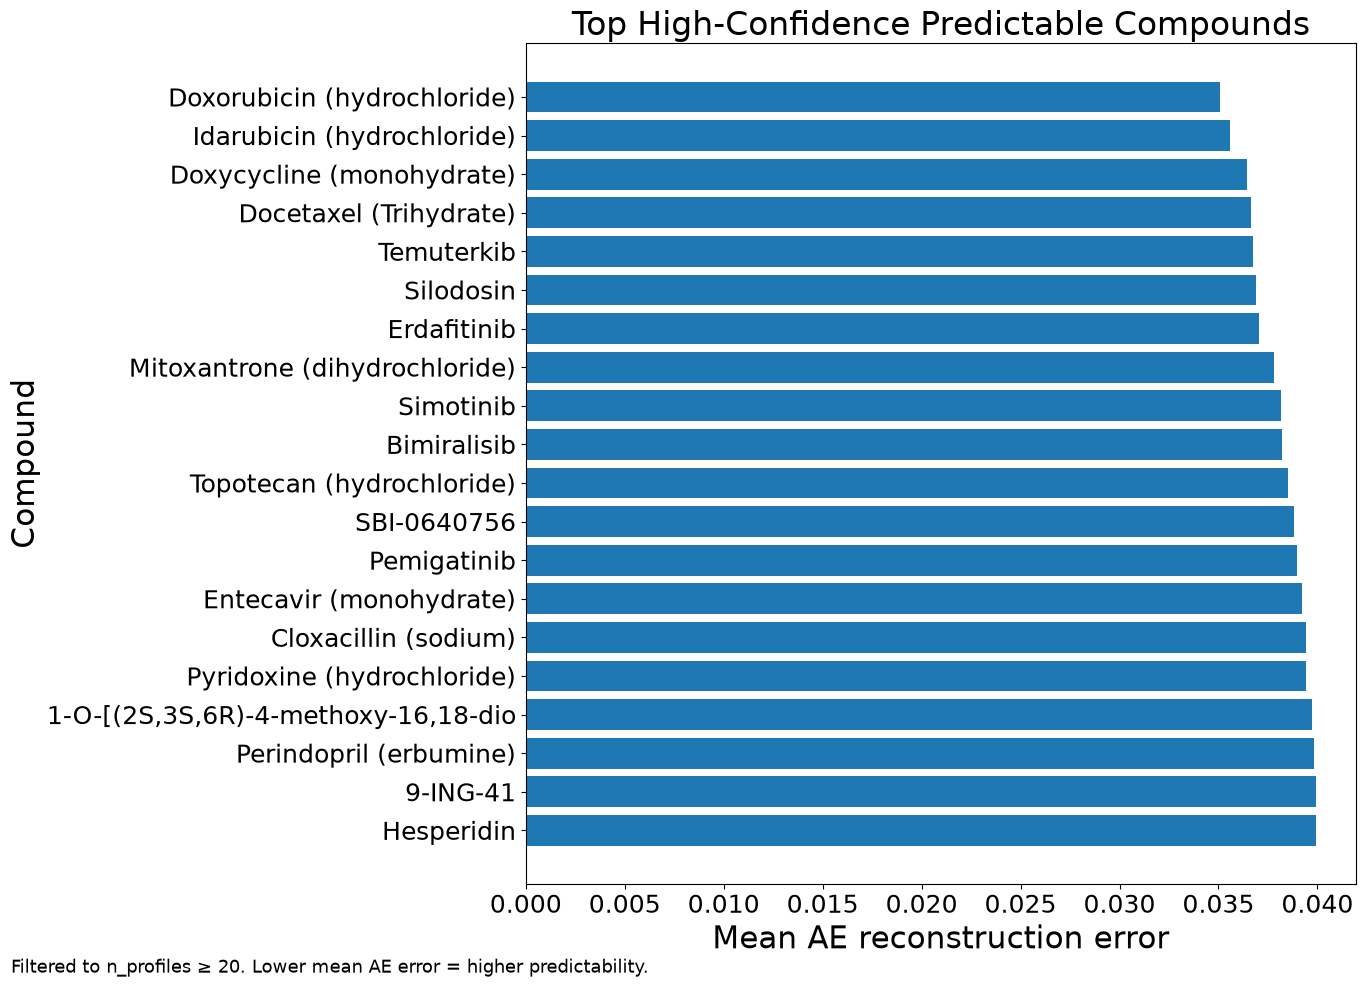

Saved: figures/step3_bowtie_autoencoder/step3_final256_top20_highconf_mean_AE_error.png


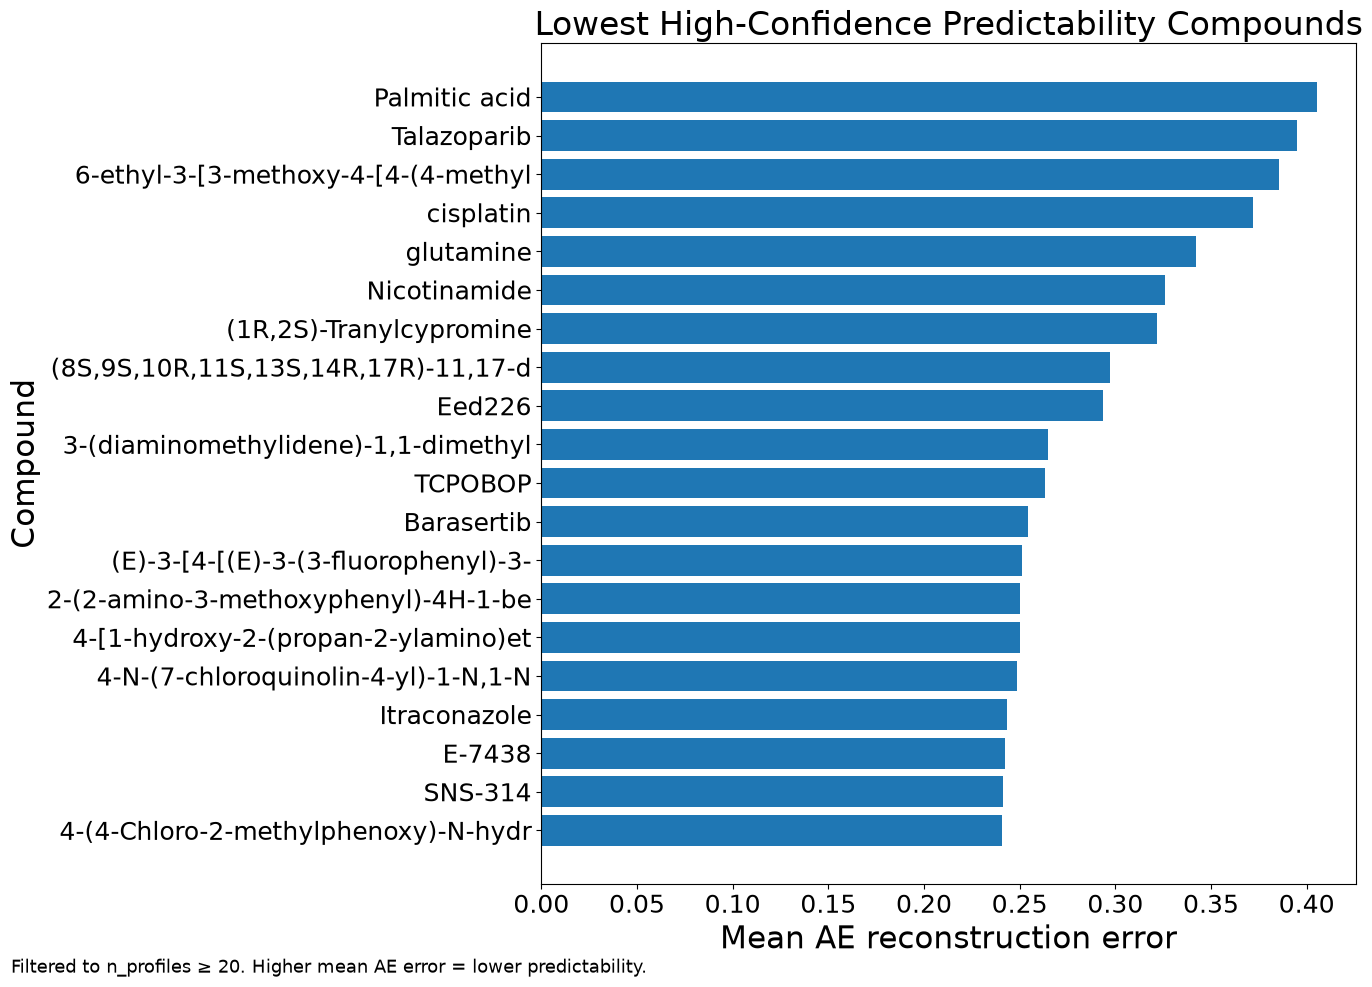

Saved: figures/step3_bowtie_autoencoder/step3_final256_bottom20_highconf_mean_AE_error.png


,compound_name,n_profiles,mean_total_error,variance_total_error,raw_error_inverted_score
4,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.035060,0.000103,1.0
5,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.035564,0.000080,1.0
7,Doxycycline (monohydrate); Invertin,139,0.036430,0.000094,1.0
8,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.036665,0.000106,1.0
9,Temuterkib,143,0.036769,0.000120,1.0
10,Silodosin,135,0.036897,0.000164,1.0
11,Erdafitinib,138,0.037073,0.000097,1.0
13,Mitoxantrone (dihydrochloride); Mitoxantrone H...,144,0.037803,0.000086,1.0
15,Simotinib,135,0.038178,0.000084,1.0
16,Bimiralisib,145,0.038226,0.000090,1.0


,compound_name,n_profiles,mean_total_error,variance_total_error,raw_error_inverted_score
6592,Palmitic acid,57,0.405489,0.085353,0.000000
6590,Talazoparib; talazoparib,82,0.395062,0.124098,0.000000
6589,6-ethyl-3-[3-methoxy-4-[4-(4-methylpiperazin-1...,20,0.385302,0.104864,0.000000
6586,cisplatin,155,0.371808,0.107791,0.000000
6569,glutamine,22,0.342127,0.062105,0.000000
6555,Nicotinamide; nicotinamide,93,0.326007,0.138007,0.000000
6548,"(1R,2S)-Tranylcypromine; tranylcypromine",37,0.321604,0.064570,0.000000
6515,"(8S,9S,10R,11S,13S,14R,17R)-11,17-dihydroxy-17...",28,0.297177,0.173164,0.045288
6506,Eed226; N-(furan-2-ylmethyl)-8-(4-methylsulfon...,20,0.293354,0.025276,0.059582
6429,"3-(diaminomethylidene)-1,1-dimethylguanidine; ...",84,0.264869,0.099618,0.166093


In [20]:
# Cleaner top/bottom high-confidence plots using mean AE error directly

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step3_bowtie_autoencoder"

compound_path = STEP3_DIR / "step3_compound_predictability_latent256_final_scores.csv"
compound_pred = pd.read_csv(compound_path, low_memory=False)

high20 = compound_pred[compound_pred["n_profiles"] >= 20].copy()

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# Top predictable: lowest mean AE error
top20 = high20.sort_values("mean_total_error", ascending=True).head(20).copy()
top20["compound_label"] = (
    top20["compound_name"]
    .astype(str)
    .str.replace(r";.*", "", regex=True)
    .str.slice(0, 35)
)

plt.figure(figsize=(14, 10))
plt.barh(top20["compound_label"][::-1], top20["mean_total_error"][::-1])
plt.title("Top High-Confidence Predictable Compounds")
plt.xlabel("Mean AE reconstruction error")
plt.ylabel("Compound")
plt.figtext(
    0.02,
    0.01,
    "Filtered to n_profiles ≥ 20. Lower mean AE error = higher predictability.",
    fontsize=13
)
save_show(FIG_DIR / "step3_final256_top20_highconf_mean_AE_error.png")

# Least predictable: highest mean AE error
bottom20 = high20.sort_values("mean_total_error", ascending=False).head(20).copy()
bottom20["compound_label"] = (
    bottom20["compound_name"]
    .astype(str)
    .str.replace(r";.*", "", regex=True)
    .str.slice(0, 35)
)

plt.figure(figsize=(14, 10))
plt.barh(bottom20["compound_label"][::-1], bottom20["mean_total_error"][::-1])
plt.title("Lowest High-Confidence Predictability Compounds")
plt.xlabel("Mean AE reconstruction error")
plt.ylabel("Compound")
plt.figtext(
    0.02,
    0.01,
    "Filtered to n_profiles ≥ 20. Higher mean AE error = lower predictability.",
    fontsize=13
)
save_show(FIG_DIR / "step3_final256_bottom20_highconf_mean_AE_error.png")

display(top20[["compound_name", "n_profiles", "mean_total_error", "variance_total_error", "raw_error_inverted_score"]])
display(bottom20[["compound_name", "n_profiles", "mean_total_error", "variance_total_error", "raw_error_inverted_score"]])

In [21]:
# Step 4: Predicting compound predictability from structure alone

In [22]:
# Step 4: Train compound-only models to predict AE-derived predictability scores
# Goal: compound embedding --> predictability/error label
# This is the part that lets us eventually score unprofiled compounds

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP1_EMBED_DIR = DATA_DIR / "step1_embeddings"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step4_predictability_regression"

MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


# Paths

compound_embedding_path = STEP1_EMBED_DIR / "step1_drug_embeddings_128.npy"
predictability_path = STEP3_DIR / "step3_compound_predictability_latent256_final_scores.csv"

metrics_out_path = MODEL_DIR / "step4_predictability_regression_metrics.csv"
predictions_out_path = STEP3_DIR / "step4_predictability_regression_test_predictions.csv"


# Load data

compound_embeddings = np.load(compound_embedding_path, mmap_mode="r")
compound_pred = pd.read_csv(predictability_path, low_memory=False)

print("Compound embeddings:", compound_embeddings.shape)
print("Predictability table:", compound_pred.shape)
print("Columns:", compound_pred.columns.tolist())


# Choose training rows

# Use n_profiles >= 20 because these labels are more stable.
# Later can compare with n_profiles >= 5 or all compounds.
MIN_PROFILES = 20

train_table = compound_pred[
    compound_pred["n_profiles"] >= MIN_PROFILES
].copy()

train_table = train_table.dropna(
    subset=[
        "compound_embedding_row_index",
        "mean_total_error",
        "raw_error_inverted_score",
        "variance_total_error",
        "source_normalized_inverted_score",
    ]
).copy()

train_table["compound_embedding_row_index"] = train_table["compound_embedding_row_index"].astype(int)

print("Training rows after filter:", train_table.shape)
print("Unique compounds:", train_table["compound_embedding_row_index"].nunique())


# Build X

idx = train_table["compound_embedding_row_index"].values
X_embed = compound_embeddings[idx].astype(np.float32)

extra_feature_cols = []

# These are allowed because they come from the compound autoencoder / structure alone,
# not from expression signatures.
if "mean_compound_reconstruction_bce" in train_table.columns:
    extra_feature_cols.append("mean_compound_reconstruction_bce")

if "mean_compound_bitwise_accuracy" in train_table.columns:
    extra_feature_cols.append("mean_compound_bitwise_accuracy")

if len(extra_feature_cols) > 0:
    X_extra = train_table[extra_feature_cols].fillna(train_table[extra_feature_cols].median()).values.astype(np.float32)
    X = np.concatenate([X_embed, X_extra], axis=1)
else:
    X = X_embed

print("X shape:", X.shape)
print("Extra features:", extra_feature_cols)


# Targets 

targets = {
    "mean_total_error": "Mean AE error",
    "raw_error_inverted_score": "Predictability score",
    "variance_total_error": "Error variance",
    "source_normalized_inverted_score": "Source-normalized predictability score",
}


# Models

models = {
    "ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    "random_forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    "hist_gradient_boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=42
    ),
}


# Helper functions

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def safe_spearman(y_true, y_pred):
    out = spearmanr(y_true, y_pred)
    return out.correlation


# Train/evaluate

all_metrics = []
all_predictions = []

for target_col, target_label in targets.items():
    y = train_table[target_col].values.astype(np.float32)

    X_train, X_test, y_train, y_test, table_train, table_test = train_test_split(
        X,
        y,
        train_table,
        test_size=0.20,
        random_state=42
    )

    print("\n" + "="*80)
    print("Target:", target_col, "|", target_label)
    print("Train:", X_train.shape, "Test:", X_test.shape)

    for model_name, model in models.items():
        print("Training:", model_name)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        rmse_val = rmse(y_test, pred)
        spearman_val = safe_spearman(y_test, pred)

        row = {
            "target": target_col,
            "target_label": target_label,
            "model": model_name,
            "min_profiles": MIN_PROFILES,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "r2": r2,
            "mae": mae,
            "rmse": rmse_val,
            "spearman": spearman_val,
            "n_features": X.shape[1],
        }

        all_metrics.append(row)

        pred_df = table_test[
            [
                "compound_embedding_row_index",
                "compound_name",
                "n_profiles",
                "mean_total_error",
                "variance_total_error",
                "raw_error_inverted_score",
                "source_normalized_inverted_score",
            ]
        ].copy()

        pred_df["target"] = target_col
        pred_df["model"] = model_name
        pred_df["actual"] = y_test
        pred_df["predicted"] = pred

        all_predictions.append(pred_df)

        print(
            f"{model_name} | "
            f"R2={r2:.3f} | MAE={mae:.4f} | RMSE={rmse_val:.4f} | Spearman={spearman_val:.3f}"
        )

metrics_df = pd.DataFrame(all_metrics).sort_values(["target", "r2"], ascending=[True, False])
predictions_df = pd.concat(all_predictions, ignore_index=True)

metrics_df.to_csv(metrics_out_path, index=False)
predictions_df.to_csv(predictions_out_path, index=False)

print("\nSaved metrics:", metrics_out_path)
print("Saved predictions:", predictions_out_path)

display(metrics_df)
display(predictions_df.head())

Compound embeddings: (3765890, 128)
Predictability table: (6605, 30)
Columns: ['compound_embedding_row_index', 'compound_name', 'n_profiles', 'mean_total_error', 'variance_total_error', 'std_total_error', 'median_total_error', 'mean_signature_error', 'variance_signature_error', 'std_signature_error', 'mean_compound_error', 'variance_compound_error', 'mean_numeric_error', 'mean_categorical_error', 'mean_signature_reconstruction_loss', 'mean_compound_reconstruction_bce', 'mean_signature_sign_accuracy', 'mean_compound_bitwise_accuracy', 'error_percentile', 'predictability_score', 'mean_source_normalized_error_z', 'variance_source_normalized_error_z', 'std_source_normalized_error_z', 'median_source_normalized_error_z', 'n_sources', 'source_normalized_error_percentile', 'source_normalized_predictability_score', 'profile_count_bin', 'raw_error_inverted_score', 'source_normalized_inverted_score']
Training rows after filter: (801, 30)
Unique compounds: 801
X shape: (801, 130)
Extra features: [

,target,target_label,model,min_profiles,n_train,n_test,r2,mae,rmse,spearman,n_features
1,mean_total_error,Mean AE error,random_forest,20,640,161,0.022240,0.036652,0.056702,0.286062,130
2,mean_total_error,Mean AE error,hist_gradient_boosting,20,640,161,-0.047329,0.037409,0.058685,0.305188,130
0,mean_total_error,Mean AE error,ridge,20,640,161,-0.126255,0.039824,0.060856,0.242584,130
4,raw_error_inverted_score,Predictability score,random_forest,20,640,161,0.032085,0.131509,0.191811,0.306298,130
5,raw_error_inverted_score,Predictability score,hist_gradient_boosting,20,640,161,-0.091113,0.139646,0.203653,0.228922,130
3,raw_error_inverted_score,Predictability score,ridge,20,640,161,-0.134585,0.143052,0.207670,0.242292,130
10,source_normalized_inverted_score,Source-normalized predictability score,random_forest,20,640,161,0.139768,0.062933,0.083218,0.391079,130
11,source_normalized_inverted_score,Source-normalized predictability score,hist_gradient_boosting,20,640,161,0.132002,0.064062,0.083593,0.359741,130
9,source_normalized_inverted_score,Source-normalized predictability score,ridge,20,640,161,0.032433,0.069968,0.088258,0.348906,130
7,variance_total_error,Error variance,random_forest,20,640,161,-0.847667,0.009788,0.026715,-0.090446,130


,compound_embedding_row_index,compound_name,n_profiles,mean_total_error,variance_total_error,raw_error_inverted_score,source_normalized_inverted_score,target,model,actual,predicted
0,15232,WH-4025,24,0.134640,0.000369,0.653034,0.673286,mean_total_error,ridge,0.134640,0.115012
1,938,RP107; aloisine,25,0.126824,0.000606,0.682260,0.709820,mean_total_error,ridge,0.126824,0.105776
2,5192,"5-((6-([1,1'-biphenyl]-4-yl)-5-chloro-1H-benzo...",143,0.041991,0.000100,0.999464,0.852926,mean_total_error,ridge,0.041991,0.098232
3,1892,Danusertib; danusertib,71,0.103847,0.002315,0.768173,0.934833,mean_total_error,ridge,0.103848,0.096158
4,5210,Niclosamide (olamine); Niclosamide ethanolamin...,139,0.042338,0.000121,0.998165,0.847096,mean_total_error,ridge,0.042338,0.062240


,target,target_label,model,min_profiles,n_train,n_test,r2,mae,rmse,spearman,n_features
6,source_normalized_inverted_score,Source-normalized predictability score,random_forest,20,640,161,0.139768,0.062933,0.083218,0.391079,130
7,source_normalized_inverted_score,Source-normalized predictability score,hist_gradient_boosting,20,640,161,0.132002,0.064062,0.083593,0.359741,130
8,source_normalized_inverted_score,Source-normalized predictability score,ridge,20,640,161,0.032433,0.069968,0.088258,0.348906,130
3,raw_error_inverted_score,Predictability score,random_forest,20,640,161,0.032085,0.131509,0.191811,0.306298,130
1,mean_total_error,Mean AE error,hist_gradient_boosting,20,640,161,-0.047329,0.037409,0.058685,0.305188,130
0,mean_total_error,Mean AE error,random_forest,20,640,161,0.022240,0.036652,0.056702,0.286062,130
2,mean_total_error,Mean AE error,ridge,20,640,161,-0.126255,0.039824,0.060856,0.242584,130
5,raw_error_inverted_score,Predictability score,ridge,20,640,161,-0.134585,0.143052,0.207670,0.242292,130
4,raw_error_inverted_score,Predictability score,hist_gradient_boosting,20,640,161,-0.091113,0.139646,0.203653,0.228922,130
9,variance_total_error,Error variance,random_forest,20,640,161,-0.847667,0.009788,0.026715,-0.090446,130


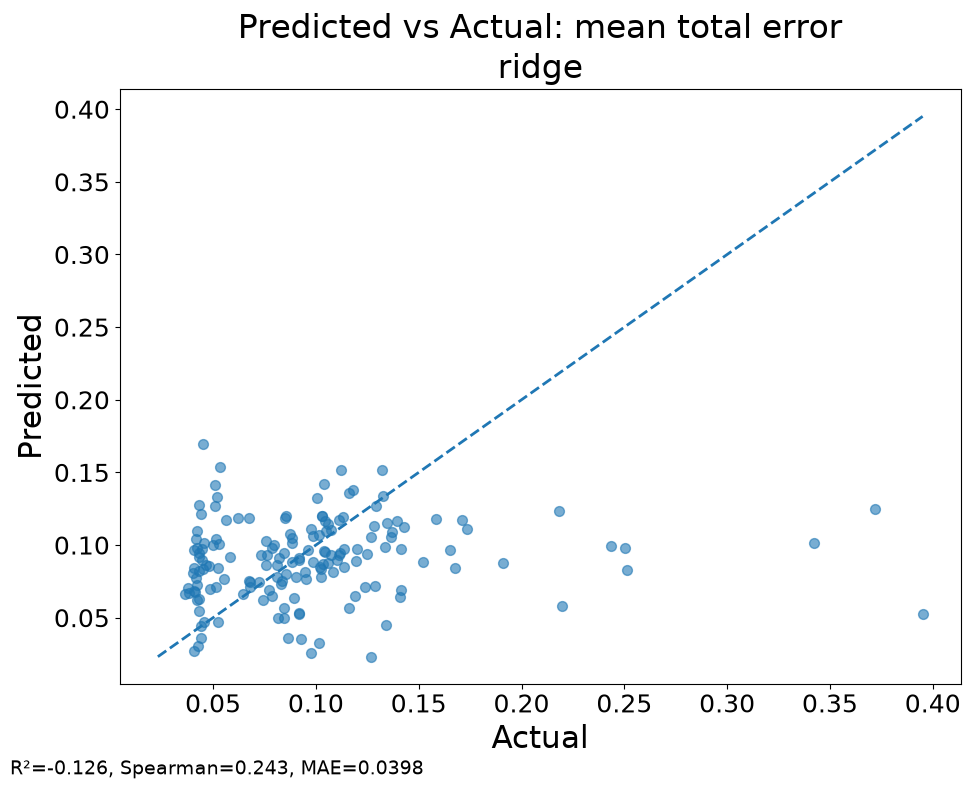

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_mean_total_error_ridge.png


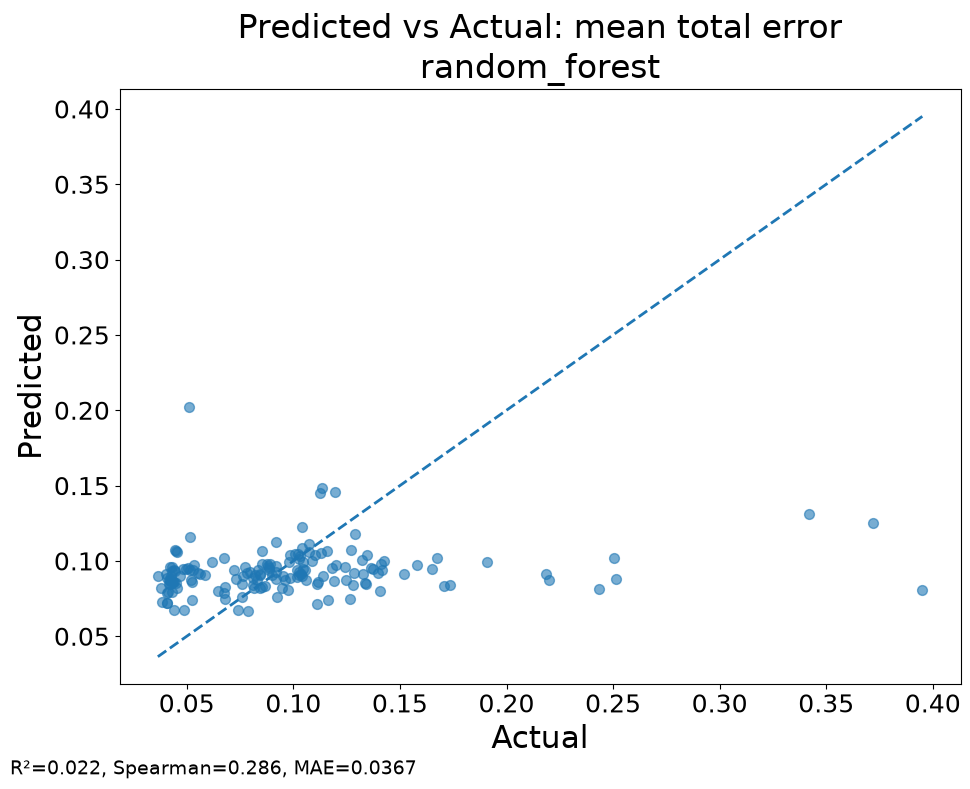

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_mean_total_error_random_forest.png


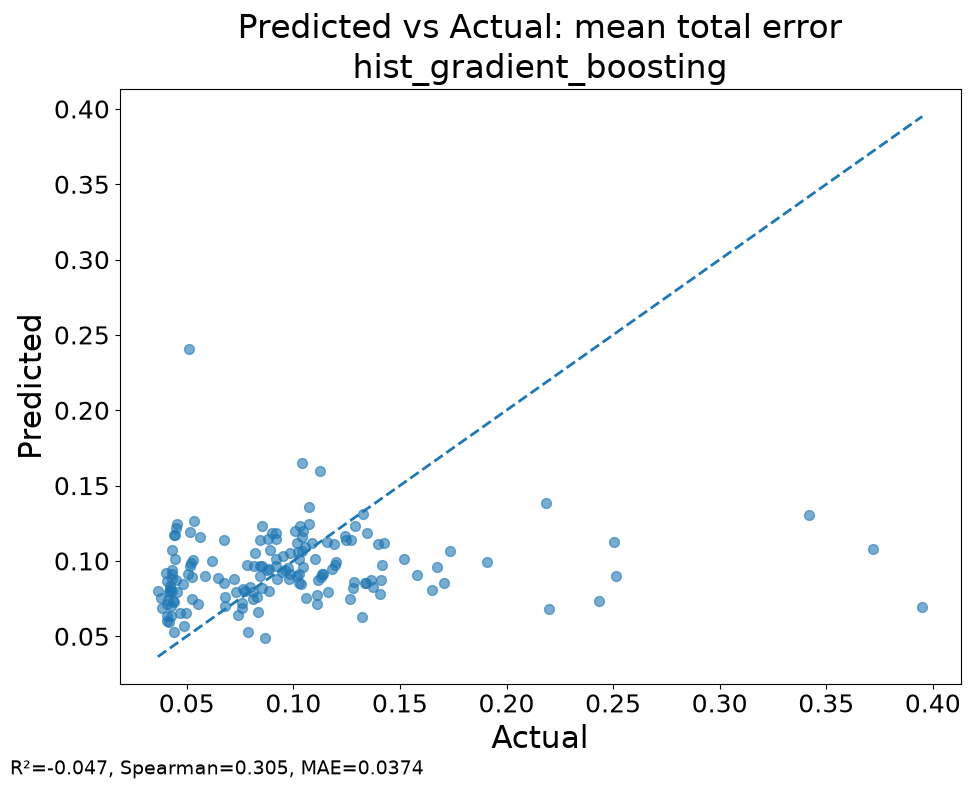

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_mean_total_error_hist_gradient_boosting.png


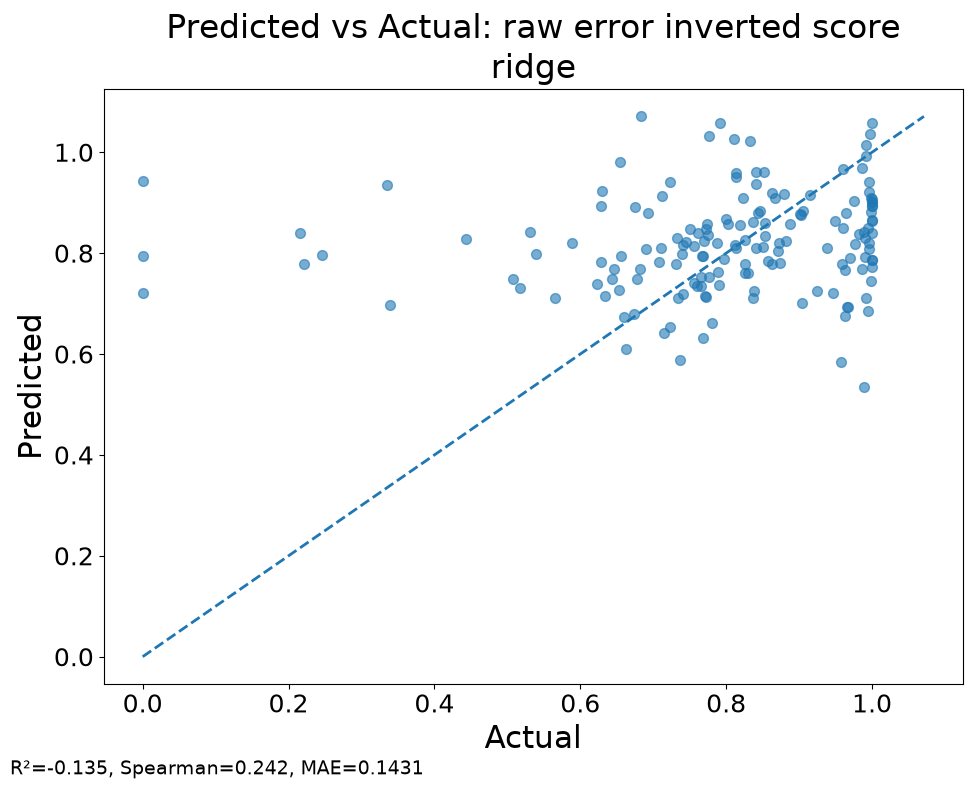

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_raw_error_inverted_score_ridge.png


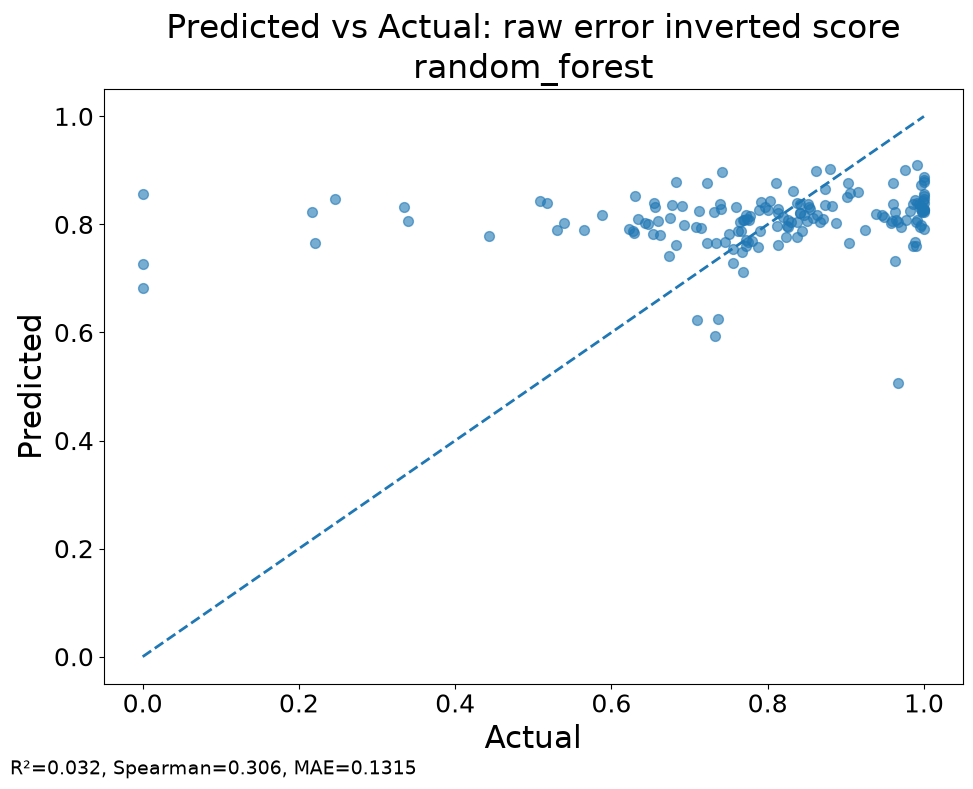

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_raw_error_inverted_score_random_forest.png


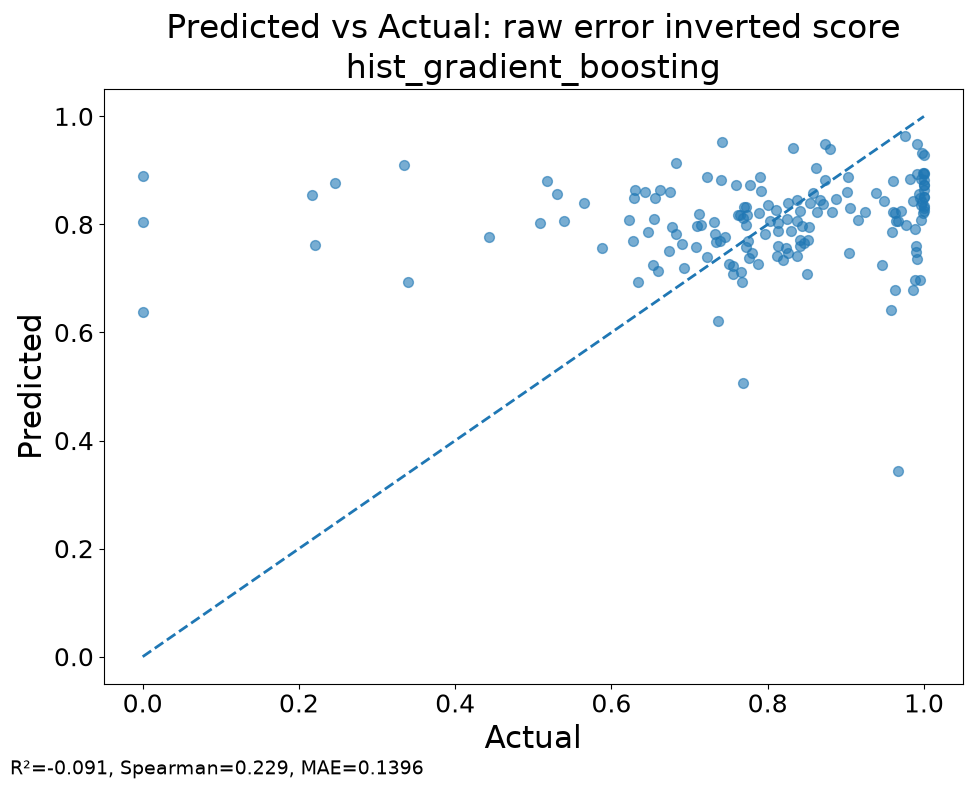

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_raw_error_inverted_score_hist_gradient_boosting.png


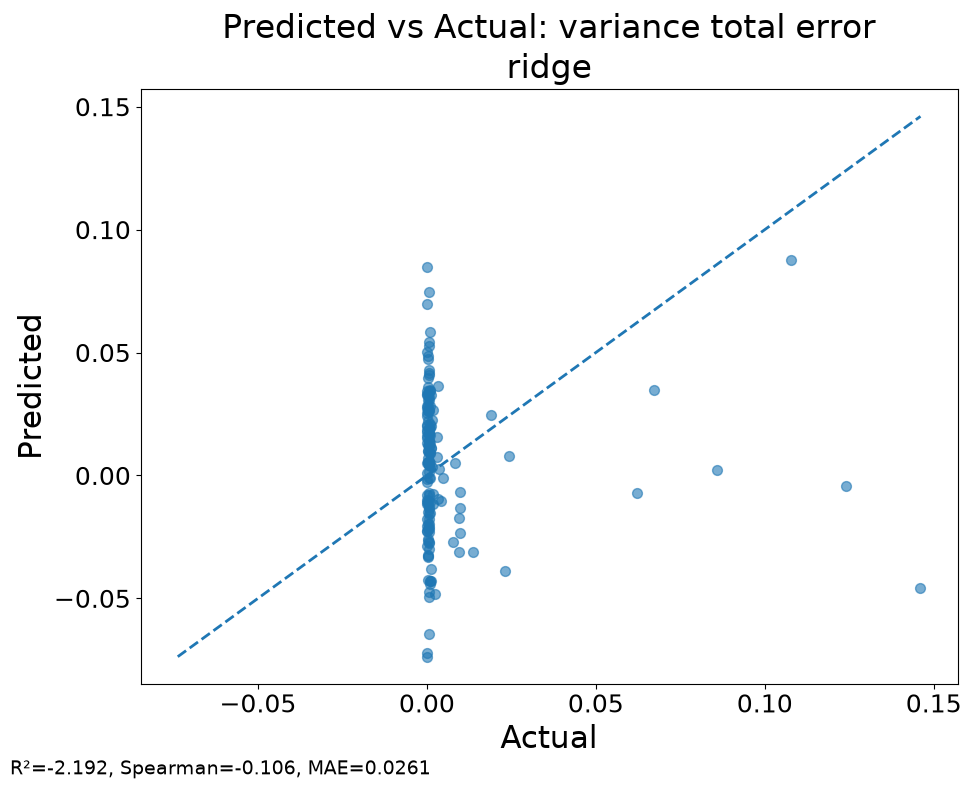

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_variance_total_error_ridge.png


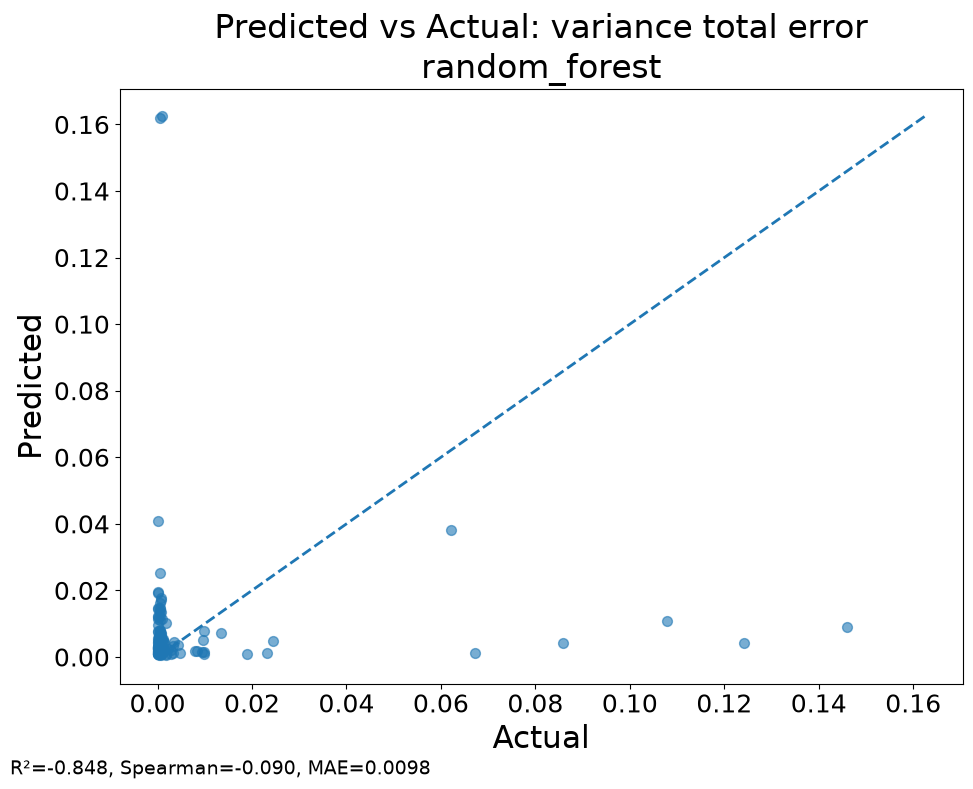

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_variance_total_error_random_forest.png


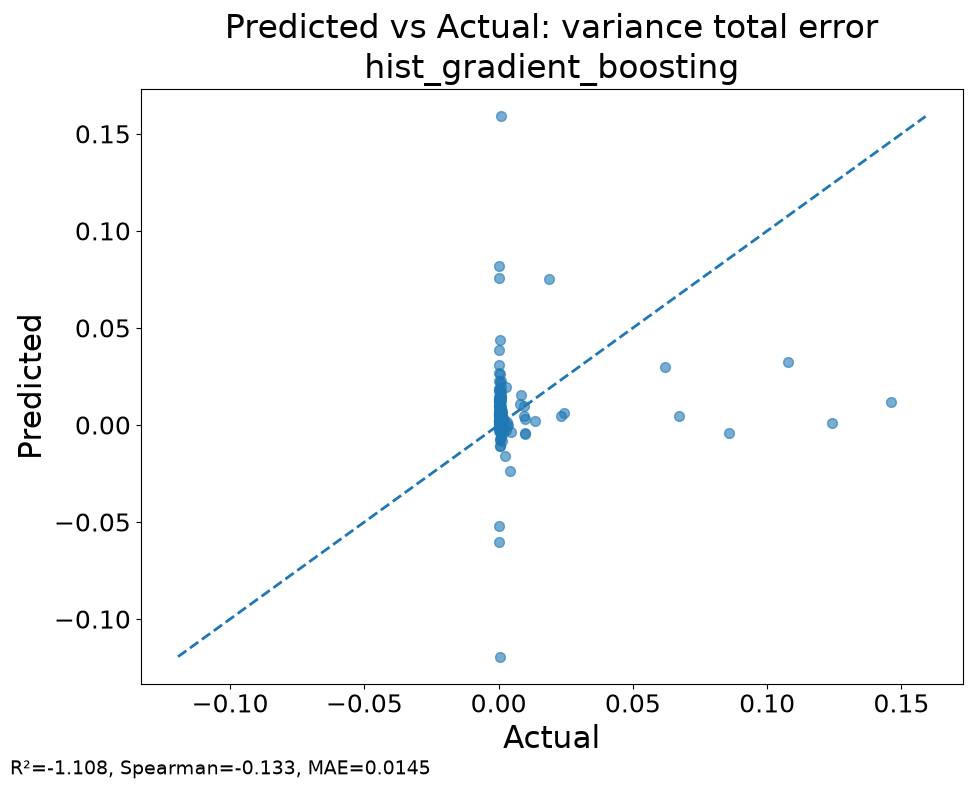

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_variance_total_error_hist_gradient_boosting.png


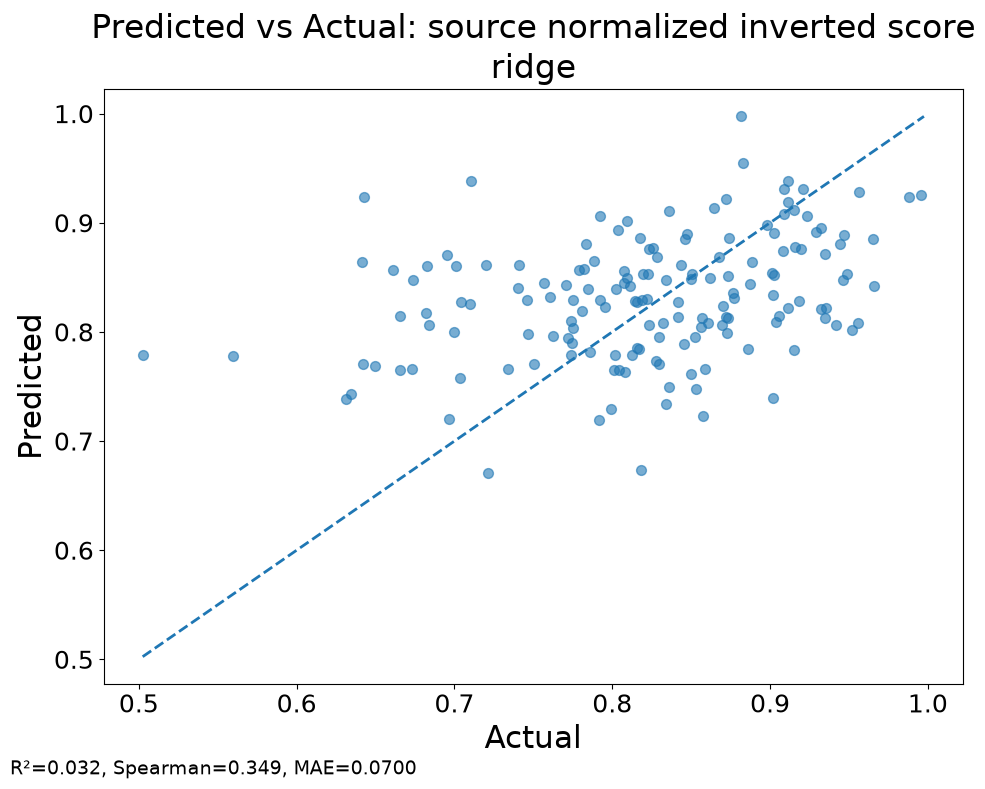

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_source_normalized_inverted_score_ridge.png


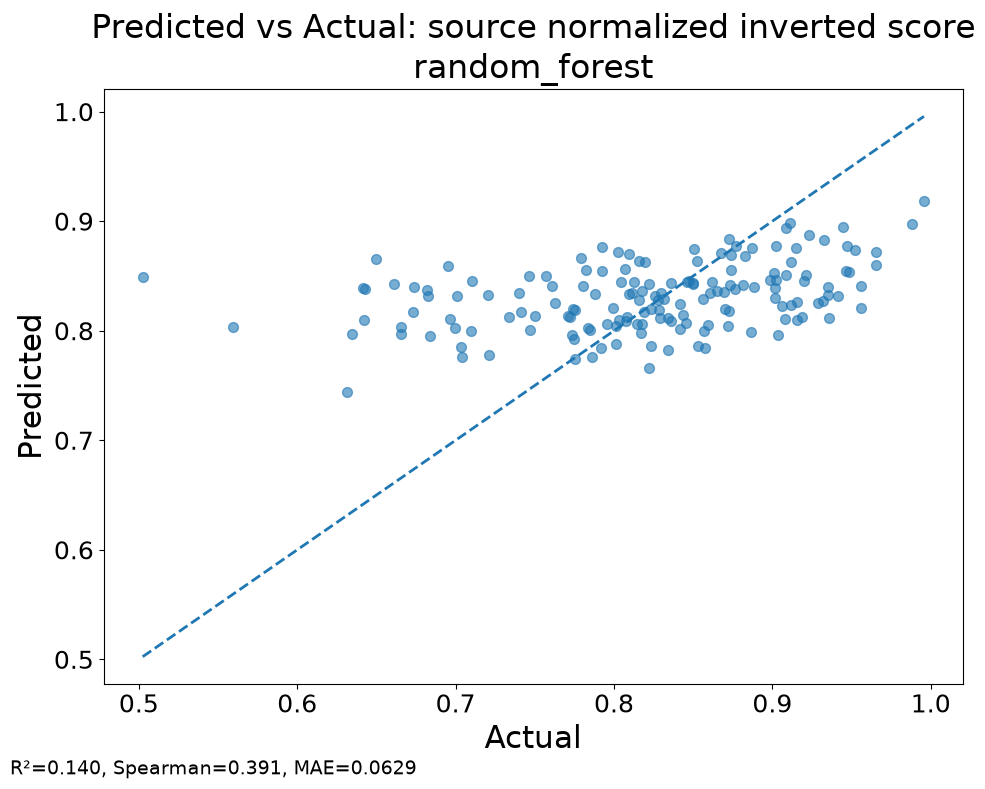

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_source_normalized_inverted_score_random_forest.png


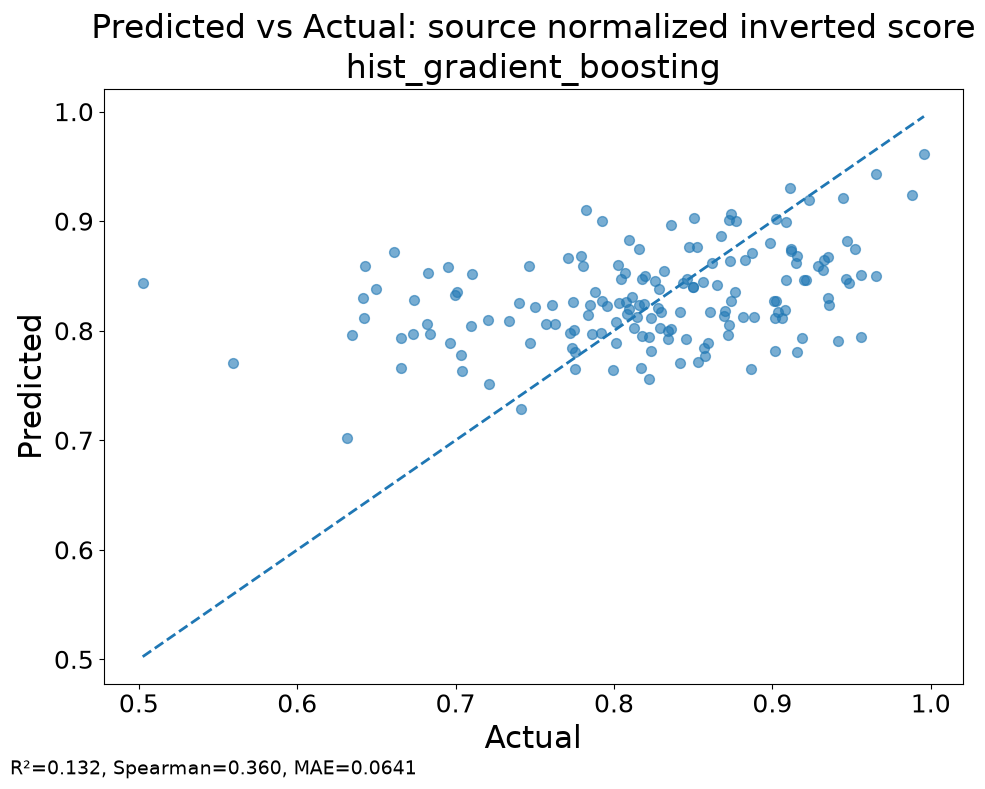

Saved: figures/step4_predictability_regression/step4_pred_vs_actual_source_normalized_inverted_score_hist_gradient_boosting.png
Predicted vs actual plots complete.


In [23]:
# Step 4: predicted vs actual plots from first-pass regression models

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
STEP3_DIR = DATA_DIR / "step3_multimodal"
MODEL_DIR = PROJECT_ROOT / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "step4_predictability_regression"

FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = MODEL_DIR / "step4_predictability_regression_metrics.csv"
predictions_path = STEP3_DIR / "step4_predictability_regression_test_predictions.csv"

metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path, low_memory=False)

display(metrics.sort_values("spearman", ascending=False))

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# Plot each target/model pair
for target in predictions["target"].unique():
    target_df = predictions[predictions["target"] == target].copy()

    for model_name in target_df["model"].unique():
        df = target_df[target_df["model"] == model_name].copy()

        metric_row = metrics[
            (metrics["target"] == target) &
            (metrics["model"] == model_name)
        ].iloc[0]

        r2 = metric_row["r2"]
        spearman = metric_row["spearman"]
        mae = metric_row["mae"]

        plt.figure(figsize=(10, 8))
        plt.scatter(df["actual"], df["predicted"], alpha=0.6, s=50)

        min_val = min(df["actual"].min(), df["predicted"].min())
        max_val = max(df["actual"].max(), df["predicted"].max())
        plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2)

        clean_target = target.replace("_", " ")

        plt.title(f"Predicted vs Actual: {clean_target}\n{model_name}")
        plt.xlabel("Actual")
        plt.ylabel("Predicted")

        plt.figtext(
            0.02,
            0.01,
            f"R²={r2:.3f}, Spearman={spearman:.3f}, MAE={mae:.4f}",
            fontsize=14
        )

        out_path = FIG_DIR / f"step4_pred_vs_actual_{target}_{model_name}.png"
        save_show(out_path)

print("Predicted vs actual plots complete.")

In [24]:
# Step 4: improved predictor sweep
# Target: source-normalized predictability score
# Filters: n_profiles >= 5, 20, 100

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP1_EMBED_DIR = DATA_DIR / "step1_embeddings"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step4_predictability_regression"

MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

compound_embedding_path = STEP1_EMBED_DIR / "step1_drug_embeddings_128.npy"
predictability_path = STEP3_DIR / "step3_compound_predictability_latent256_final_scores.csv"

metrics_out_path = MODEL_DIR / "step4_source_normalized_predictability_filter_sweep_metrics.csv"
predictions_out_path = STEP3_DIR / "step4_source_normalized_predictability_filter_sweep_predictions.csv"
best_model_out_path = MODEL_DIR / "step4_best_source_normalized_predictability_model.joblib"

compound_embeddings = np.load(compound_embedding_path, mmap_mode="r")
compound_pred = pd.read_csv(predictability_path, low_memory=False)

print("Compound embeddings:", compound_embeddings.shape)
print("Compound predictability table:", compound_pred.shape)

TARGET = "source_normalized_inverted_score"
target_label = "Source-normalized predictability score"

profile_filters = [5, 20, 100]

models = {
    "ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    "random_forest": RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    "extra_trees": ExtraTreesRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    "hist_gradient_boosting": HistGradientBoostingRegressor(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=31,
        l2_regularization=0.01,
        random_state=42
    ),
}

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def safe_spearman(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation

all_metrics = []
all_predictions = []

best_spearman = -999
best_model_info = None
best_model_object = None

for min_profiles in profile_filters:
    table = compound_pred[
        compound_pred["n_profiles"] >= min_profiles
    ].copy()

    table = table.dropna(
        subset=[
            "compound_embedding_row_index",
            TARGET,
            "mean_total_error",
            "variance_total_error",
            "raw_error_inverted_score",
        ]
    ).copy()

    table["compound_embedding_row_index"] = table["compound_embedding_row_index"].astype(int)

    idx = table["compound_embedding_row_index"].values
    X_embed = compound_embeddings[idx].astype(np.float32)

    extra_feature_cols = []

    if "mean_compound_reconstruction_bce" in table.columns:
        extra_feature_cols.append("mean_compound_reconstruction_bce")

    if "mean_compound_bitwise_accuracy" in table.columns:
        extra_feature_cols.append("mean_compound_bitwise_accuracy")

    if len(extra_feature_cols) > 0:
        X_extra = table[extra_feature_cols].fillna(table[extra_feature_cols].median()).values.astype(np.float32)
        X = np.concatenate([X_embed, X_extra], axis=1)
    else:
        X = X_embed

    y = table[TARGET].values.astype(np.float32)

    print("\n" + "="*90)
    print(f"Filter: n_profiles >= {min_profiles}")
    print("Rows:", len(table), "| X:", X.shape)

    X_train, X_test, y_train, y_test, table_train, table_test = train_test_split(
        X,
        y,
        table,
        test_size=0.20,
        random_state=42
    )

    for model_name, model in models.items():
        print("Training:", model_name)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        rmse_val = rmse(y_test, pred)
        spearman_val = safe_spearman(y_test, pred)

        row = {
            "target": TARGET,
            "target_label": target_label,
            "model": model_name,
            "min_profiles": min_profiles,
            "n_total": len(table),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "n_features": X.shape[1],
            "r2": r2,
            "mae": mae,
            "rmse": rmse_val,
            "spearman": spearman_val,
        }

        all_metrics.append(row)

        pred_df = table_test[
            [
                "compound_embedding_row_index",
                "compound_name",
                "n_profiles",
                "mean_total_error",
                "variance_total_error",
                "raw_error_inverted_score",
                "source_normalized_inverted_score",
            ]
        ].copy()

        pred_df["min_profiles"] = min_profiles
        pred_df["model"] = model_name
        pred_df["actual"] = y_test
        pred_df["predicted"] = pred

        all_predictions.append(pred_df)

        print(
            f"{model_name} | "
            f"R2={r2:.3f} | MAE={mae:.4f} | RMSE={rmse_val:.4f} | Spearman={spearman_val:.3f}"
        )

        if spearman_val > best_spearman:
            best_spearman = spearman_val
            best_model_info = row.copy()
            best_model_object = model

metrics_df = pd.DataFrame(all_metrics).sort_values("spearman", ascending=False)
predictions_df = pd.concat(all_predictions, ignore_index=True)

metrics_df.to_csv(metrics_out_path, index=False)
predictions_df.to_csv(predictions_out_path, index=False)

joblib.dump(
    {
        "model": best_model_object,
        "best_model_info": best_model_info,
        "target": TARGET,
        "extra_feature_cols": extra_feature_cols,
        "compound_embedding_path": str(compound_embedding_path),
        "predictability_table": str(predictability_path),
    },
    best_model_out_path
)

print("\nSaved metrics:", metrics_out_path)
print("Saved predictions:", predictions_out_path)
print("Saved best model:", best_model_out_path)

print("\nBest model:")
display(pd.DataFrame([best_model_info]))

display(metrics_df)

Compound embeddings: (3765890, 128)
Compound predictability table: (6605, 30)

Filter: n_profiles >= 5
Rows: 2624 | X: (2624, 130)
Training: ridge
ridge | R2=0.025 | MAE=0.1166 | RMSE=0.1530 | Spearman=0.284
Training: random_forest
random_forest | R2=0.152 | MAE=0.1093 | RMSE=0.1426 | Spearman=0.409
Training: extra_trees
extra_trees | R2=0.154 | MAE=0.1087 | RMSE=0.1425 | Spearman=0.406
Training: hist_gradient_boosting
hist_gradient_boosting | R2=0.155 | MAE=0.1080 | RMSE=0.1424 | Spearman=0.405

Filter: n_profiles >= 20
Rows: 801 | X: (801, 130)
Training: ridge
ridge | R2=0.032 | MAE=0.0700 | RMSE=0.0883 | Spearman=0.349
Training: random_forest
random_forest | R2=0.141 | MAE=0.0629 | RMSE=0.0832 | Spearman=0.397
Training: extra_trees
extra_trees | R2=0.154 | MAE=0.0630 | RMSE=0.0825 | Spearman=0.393
Training: hist_gradient_boosting
hist_gradient_boosting | R2=0.127 | MAE=0.0631 | RMSE=0.0838 | Spearman=0.372

Filter: n_profiles >= 100
Rows: 349 | X: (349, 130)
Training: ridge
ridge | 

,target,target_label,model,min_profiles,n_total,n_train,n_test,n_features,r2,mae,rmse,spearman
0,source_normalized_inverted_score,Source-normalized predictability score,extra_trees,100,349,279,70,130,0.305456,0.054045,0.070487,0.598705


,target,target_label,model,min_profiles,n_total,n_train,n_test,n_features,r2,mae,rmse,spearman
10,source_normalized_inverted_score,Source-normalized predictability score,extra_trees,100,349,279,70,130,0.305456,0.054045,0.070487,0.598705
9,source_normalized_inverted_score,Source-normalized predictability score,random_forest,100,349,279,70,130,0.277051,0.055355,0.071914,0.536593
11,source_normalized_inverted_score,Source-normalized predictability score,hist_gradient_boosting,100,349,279,70,130,0.273663,0.058345,0.072082,0.522771
8,source_normalized_inverted_score,Source-normalized predictability score,ridge,100,349,279,70,130,-0.156155,0.070264,0.090943,0.410725
1,source_normalized_inverted_score,Source-normalized predictability score,random_forest,5,2624,2099,525,130,0.152284,0.109316,0.142631,0.409388
2,source_normalized_inverted_score,Source-normalized predictability score,extra_trees,5,2624,2099,525,130,0.153523,0.108736,0.142527,0.406186
3,source_normalized_inverted_score,Source-normalized predictability score,hist_gradient_boosting,5,2624,2099,525,130,0.154524,0.107956,0.142443,0.404982
5,source_normalized_inverted_score,Source-normalized predictability score,random_forest,20,801,640,161,130,0.141118,0.062921,0.083153,0.397126
6,source_normalized_inverted_score,Source-normalized predictability score,extra_trees,20,801,640,161,130,0.153676,0.063037,0.082543,0.393112
7,source_normalized_inverted_score,Source-normalized predictability score,hist_gradient_boosting,20,801,640,161,130,0.127261,0.063127,0.083821,0.372066


,target,target_label,model,min_profiles,n_total,n_train,n_test,n_features,r2,mae,rmse,spearman
0,source_normalized_inverted_score,Source-normalized predictability score,extra_trees,100,349,279,70,130,0.305456,0.054045,0.070487,0.598705
1,source_normalized_inverted_score,Source-normalized predictability score,random_forest,100,349,279,70,130,0.277051,0.055355,0.071914,0.536593
2,source_normalized_inverted_score,Source-normalized predictability score,hist_gradient_boosting,100,349,279,70,130,0.273663,0.058345,0.072082,0.522771
3,source_normalized_inverted_score,Source-normalized predictability score,ridge,100,349,279,70,130,-0.156155,0.070264,0.090943,0.410725
4,source_normalized_inverted_score,Source-normalized predictability score,random_forest,5,2624,2099,525,130,0.152284,0.109316,0.142631,0.409388
5,source_normalized_inverted_score,Source-normalized predictability score,extra_trees,5,2624,2099,525,130,0.153523,0.108736,0.142527,0.406186
6,source_normalized_inverted_score,Source-normalized predictability score,hist_gradient_boosting,5,2624,2099,525,130,0.154524,0.107956,0.142443,0.404982
7,source_normalized_inverted_score,Source-normalized predictability score,random_forest,20,801,640,161,130,0.141118,0.062921,0.083153,0.397126
8,source_normalized_inverted_score,Source-normalized predictability score,extra_trees,20,801,640,161,130,0.153676,0.063037,0.082543,0.393112
9,source_normalized_inverted_score,Source-normalized predictability score,hist_gradient_boosting,20,801,640,161,130,0.127261,0.063127,0.083821,0.372066


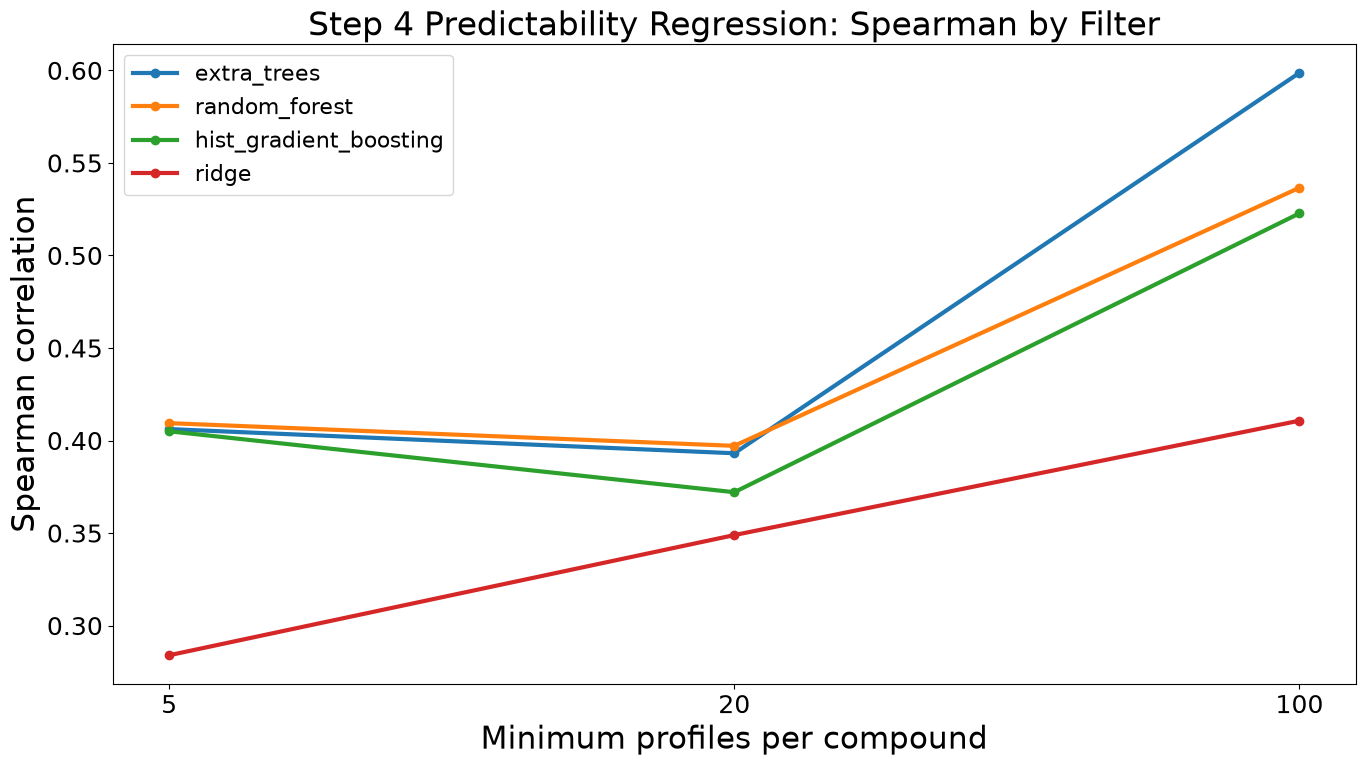

Saved: figures/step4_predictability_regression/step4_source_normalized_spearman_by_filter.png


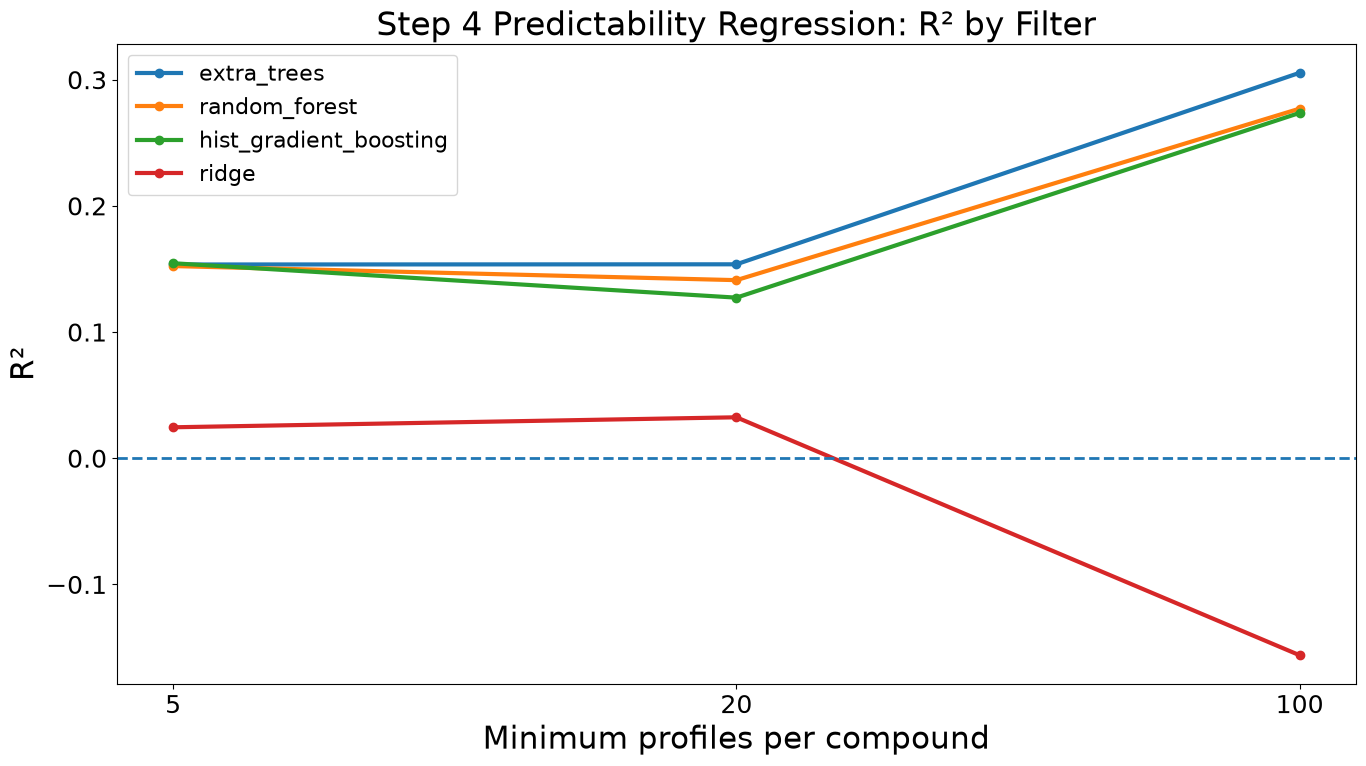

Saved: figures/step4_predictability_regression/step4_source_normalized_r2_by_filter.png


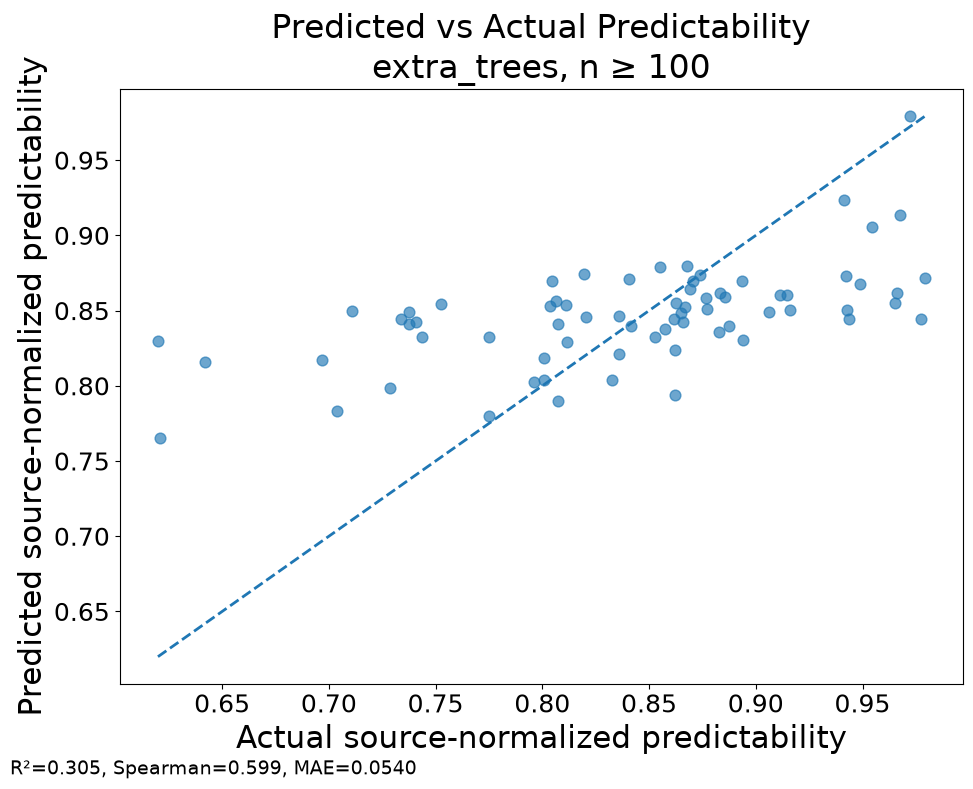

Saved: figures/step4_predictability_regression/step4_best_source_normalized_predicted_vs_actual.png


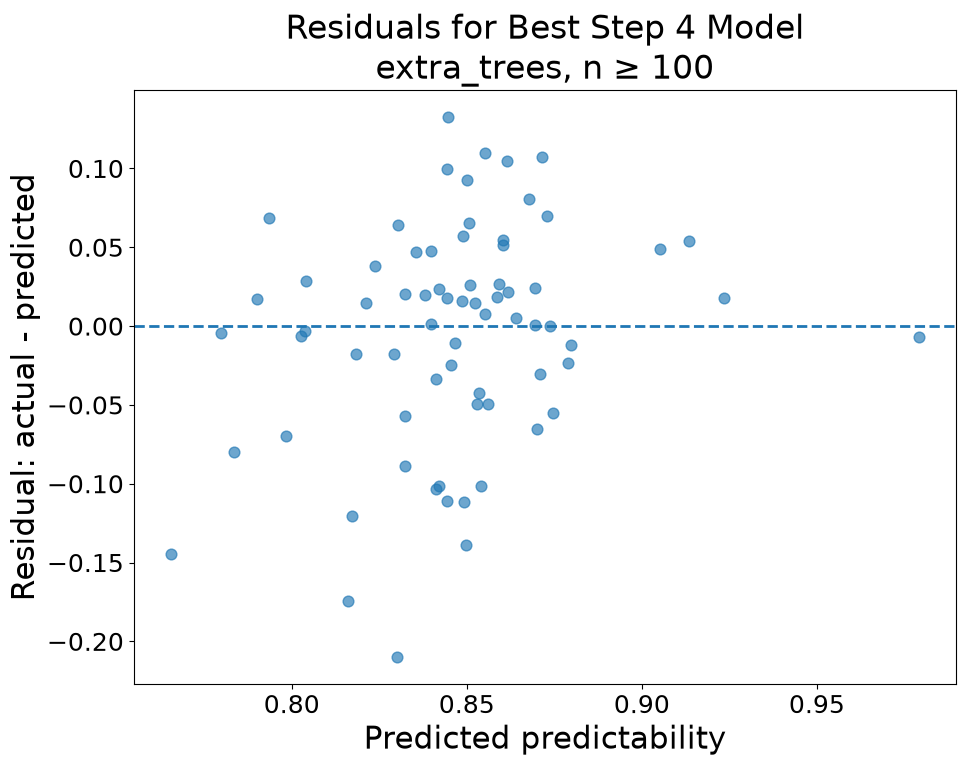

Saved: figures/step4_predictability_regression/step4_best_source_normalized_residuals.png
Improved Step 4 plots complete.


In [25]:
# Step 4: improved sweep plots

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "data" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
STEP3_DIR = DATA_DIR / "step3_multimodal"
FIG_DIR = PROJECT_ROOT / "figures" / "step4_predictability_regression"

FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = MODEL_DIR / "step4_source_normalized_predictability_filter_sweep_metrics.csv"
predictions_path = STEP3_DIR / "step4_source_normalized_predictability_filter_sweep_predictions.csv"

metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path, low_memory=False)

display(metrics.sort_values("spearman", ascending=False))

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

def save_show(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)


# 1. Spearman by model/filter

plt.figure(figsize=(14, 8))

for model_name in metrics["model"].unique():
    df = metrics[metrics["model"] == model_name].sort_values("min_profiles")
    plt.plot(
        df["min_profiles"].astype(str),
        df["spearman"],
        marker="o",
        linewidth=3,
        label=model_name
    )

plt.title("Step 4 Predictability Regression: Spearman by Filter")
plt.xlabel("Minimum profiles per compound")
plt.ylabel("Spearman correlation")
plt.legend()
save_show(FIG_DIR / "step4_source_normalized_spearman_by_filter.png")


# 2. R2 by model/filter

plt.figure(figsize=(14, 8))

for model_name in metrics["model"].unique():
    df = metrics[metrics["model"] == model_name].sort_values("min_profiles")
    plt.plot(
        df["min_profiles"].astype(str),
        df["r2"],
        marker="o",
        linewidth=3,
        label=model_name
    )

plt.axhline(0, linestyle="--", linewidth=2)
plt.title("Step 4 Predictability Regression: R² by Filter")
plt.xlabel("Minimum profiles per compound")
plt.ylabel("R²")
plt.legend()
save_show(FIG_DIR / "step4_source_normalized_r2_by_filter.png")


# 3. Predicted vs actual for best model

best = metrics.sort_values("spearman", ascending=False).iloc[0]

best_model = best["model"]
best_filter = best["min_profiles"]

best_pred = predictions[
    (predictions["model"] == best_model) &
    (predictions["min_profiles"] == best_filter)
].copy()

plt.figure(figsize=(10, 8))
plt.scatter(best_pred["actual"], best_pred["predicted"], alpha=0.65, s=60)

min_val = min(best_pred["actual"].min(), best_pred["predicted"].min())
max_val = max(best_pred["actual"].max(), best_pred["predicted"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2)

plt.title(f"Predicted vs Actual Predictability\n{best_model}, n ≥ {best_filter}")
plt.xlabel("Actual source-normalized predictability")
plt.ylabel("Predicted source-normalized predictability")
plt.figtext(
    0.02,
    0.01,
    f"R²={best['r2']:.3f}, Spearman={best['spearman']:.3f}, MAE={best['mae']:.4f}",
    fontsize=14
)

save_show(FIG_DIR / "step4_best_source_normalized_predicted_vs_actual.png")


# 4. Residuals for best model

best_pred["residual"] = best_pred["actual"] - best_pred["predicted"]

plt.figure(figsize=(10, 8))
plt.scatter(best_pred["predicted"], best_pred["residual"], alpha=0.65, s=60)
plt.axhline(0, linestyle="--", linewidth=2)

plt.title(f"Residuals for Best Step 4 Model\n{best_model}, n ≥ {best_filter}")
plt.xlabel("Predicted predictability")
plt.ylabel("Residual: actual - predicted")

save_show(FIG_DIR / "step4_best_source_normalized_residuals.png")

print("Improved Step 4 plots complete.")